<a href="https://colab.research.google.com/github/shamimalrazi393/SAA-ML-model/blob/main/SAA_after_review_final_revised_corrected_v3_8_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SAA Catalyst ML — Full Reproducible Pipeline (Revised v3.8)


In [ ]:
# Runtime bootstrap guard: deliberately no third-party scientific imports before Step 2.
print('Bootstrap ready. Mount Drive, install the pinned environment, then import libraries.')


Bootstrap ready. Mount Drive, install the pinned environment, then import libraries.


## Step 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
SAVE_DIR = '/content/drive/MyDrive/SAA_ML_PaperAfterReview_Fixed'
for sub in ['','/models','/figures','/results']:
    os.makedirs(f'{SAVE_DIR}{sub}', exist_ok=True)
print('OK Drive mounted. SAVE_DIR =', SAVE_DIR)

Mounted at /content/drive
OK Drive mounted. SAVE_DIR = /content/drive/MyDrive/SAA_ML_PaperAfterReview_Fixed


## Step 2 — Install

In [ ]:
%pip install --quiet --no-cache-dir --upgrade \
    numpy==2.0.2 \
    pandas==2.2.2 \
    scipy==1.14.1 \
    scikit-learn==1.6.1 \
    xgboost==2.1.1 \
    lightgbm==4.5.0 \
    shap==0.46.0 \
    matplotlib==3.9.2 \
    seaborn==0.13.2 \
    joblib==1.4.2 \
    matminer==0.9.3 \
    pymatgen==2024.8.9 \
    tqdm==4.67.1

print(
    "Compatible pinned packages installed. "
    "Restart the Colab session once before running the import cell."
)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 177.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 148.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 150.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 203.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33

## Step 3 — Imports

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import scipy, sklearn, xgboost, shap
import warnings, joblib, time, os, io, hashlib, json, random, sys, platform
import torch
from importlib.metadata import version as package_version
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED); random.seed(SEED)
RUNTIME_ENVIRONMENT = {
    'python_version': sys.version.split()[0],
    'platform': platform.platform(),
    'numpy_version': np.__version__,
    'pandas_version': pd.__version__,
    'scipy_version': scipy.__version__,
    'sklearn_version': sklearn.__version__,
    'xgboost_version': xgboost.__version__,
    'shap_version': shap.__version__,
    'torch_version': torch.__version__,
    'torch_cuda_build': str(torch.version.cuda),
    'cuda_available': bool(torch.cuda.is_available()),
    'cuda_device_count': int(torch.cuda.device_count()),
    'cuda_device_name': (torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU-only runtime'),
    'global_seed': int(SEED),
}
print('OK libraries imported. seed =', SEED)
for _pkg in ['numpy','pandas','scipy','scikit-learn','xgboost','shap','matplotlib','seaborn','joblib','matminer','pymatgen']:
    try:
        print(f'  {_pkg}: {package_version(_pkg)}')
    except Exception:
        print(f'  {_pkg}: version unavailable')
print('  torch:', RUNTIME_ENVIRONMENT['torch_version'])
print('  torch CUDA build:', RUNTIME_ENVIRONMENT['torch_cuda_build'])
print('  CUDA available:', RUNTIME_ENVIRONMENT['cuda_available'])
print('  CUDA device:', RUNTIME_ENVIRONMENT['cuda_device_name'])
print('NOTE: PyTorch uses the Colab runtime build to preserve CUDA compatibility; the exact build is recorded.')


OK libraries imported. seed = 42
  numpy: 2.0.2
  pandas: 2.2.2
  scipy: 1.14.1
  scikit-learn: 1.6.1
  xgboost: 2.1.1
  shap: 0.46.0
  matplotlib: 3.9.2
  seaborn: 0.13.2
  joblib: 1.4.2
  matminer: 0.9.3
  pymatgen: 2024.8.9
  torch: 2.11.0+cpu
  torch CUDA build: None
  CUDA available: False
  CUDA device: CPU-only runtime
NOTE: PyTorch uses the Colab runtime build to preserve CUDA compatibility; the exact build is recorded.


## Step 4 — Checkpoint helpers

In [ ]:
import hashlib, json as _json

FINGERPRINT_META_SUFFIX = '.meta.joblib'
FINGERPRINT_EXEMPT_CHECKPOINTS = {'dataset_fingerprint_raw_safe'}

def _checkpoint_path(name):
    return f'{SAVE_DIR}/results/{name}.joblib'

def _checkpoint_meta_path(name):
    return f'{SAVE_DIR}/results/{name}{FINGERPRINT_META_SUFFIX}'

def _artifact_meta_path(path):
    return f'{path}{FINGERPRINT_META_SUFFIX}'

def _current_dataset_fingerprint():
    fp = globals().get('DATASET_FINGERPRINT')
    return fp if isinstance(fp, dict) else None

def _fingerprint_keys():
    return ('dataset_sha256', 'target_sha256', 'schema_sha256', 'row_order_sha256', 'row_count')

def _file_sha256(path, block_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, 'rb') as fh:
        while True:
            block = fh.read(block_size)
            if not block:
                break
            h.update(block)
    return h.hexdigest()

def _fingerprint_matches(stored, current):
    return (isinstance(stored, dict) and isinstance(current, dict)
            and all(stored.get(k) == current.get(k) for k in _fingerprint_keys()))

def checkpoint_metadata_valid(name, verbose=False):
    """Validate a checkpoint sidecar against the current dataset fingerprint and file hash."""
    current = _current_dataset_fingerprint()
    if current is None or name in FINGERPRINT_EXEMPT_CHECKPOINTS:
        return True
    meta_path = _checkpoint_meta_path(name)
    if not os.path.exists(meta_path):
        if verbose: print(f'  ! {name}: dataset-fingerprint sidecar missing')
        return False
    try:
        meta = joblib.load(meta_path)
    except Exception as exc:
        if verbose: print(f'  ! {name}: unreadable fingerprint sidecar: {exc}')
        return False
    stored = meta.get('dataset_fingerprint') if isinstance(meta, dict) else None
    if not _fingerprint_matches(stored, current):
        if verbose: print(f'  ! {name}: dataset fingerprint mismatch')
        return False
    ck_path = _checkpoint_path(name)
    stored_sha = meta.get('file_sha256')
    if stored_sha and os.path.exists(ck_path) and stored_sha != _file_sha256(ck_path):
        if verbose: print(f'  ! {name}: checkpoint file hash mismatch')
        return False
    return True

def save_checkpoint(obj, name):
    """Save an object plus dataset-fingerprint and file-integrity metadata."""
    path = _checkpoint_path(name)
    joblib.dump(obj, path)
    current = _current_dataset_fingerprint()
    if current is not None and name not in FINGERPRINT_EXEMPT_CHECKPOINTS:
        meta = {
            'checkpoint_name': name,
            'dataset_fingerprint': dict(current),
            'object_type': type(obj).__name__,
            'file_sha256': _file_sha256(path),
            'saved_at_utc': pd.Timestamp.utcnow().isoformat(),
            'runtime_environment': dict(globals().get('RUNTIME_ENVIRONMENT', {})),
        }
        joblib.dump(meta, _checkpoint_meta_path(name))
    print(f'  ✓ Checkpoint saved: {name}')

def load_checkpoint(name):
    """Load only when the file and its metadata match the current dataset."""
    path = _checkpoint_path(name)
    if not os.path.exists(path):
        return None
    if not checkpoint_metadata_valid(name, verbose=True):
        print(f'  ! Checkpoint rejected (wrong dataset, stale, or corrupted): {name}')
        return None
    try:
        obj = joblib.load(path)
    except Exception as exc:
        print(f'  ! Checkpoint unreadable: {name}: {exc}')
        return None
    print(f'  ✓ Checkpoint loaded: {name}')
    return obj

def checkpoint_exists(name):
    path = _checkpoint_path(name)
    return os.path.exists(path) and checkpoint_metadata_valid(name, verbose=False)

def _save_artifact_sidecar(path, artifact_name, artifact_type, extra=None):
    current = _current_dataset_fingerprint()
    if current is None:
        raise RuntimeError(f'Dataset fingerprint is unavailable while saving {artifact_name}.')
    payload = {
        'artifact_name': artifact_name,
        'artifact_type': artifact_type,
        'path_basename': os.path.basename(path),
        'dataset_fingerprint': dict(current),
        'file_sha256': _file_sha256(path),
        'saved_at_utc': pd.Timestamp.utcnow().isoformat(),
        'runtime_environment': dict(globals().get('RUNTIME_ENVIRONMENT', {})),
    }
    if isinstance(extra, dict):
        payload.update(extra)
    joblib.dump(payload, _artifact_meta_path(path))

def artifact_metadata_valid(path, expected_type=None, verbose=False):
    """Verify artifact existence, dataset fingerprint, and exact file hash."""
    if not os.path.exists(path):
        return False
    mp = _artifact_meta_path(path)
    if not os.path.exists(mp):
        if verbose: print(f'  ! sidecar missing: {os.path.basename(path)}')
        return False
    try:
        meta = joblib.load(mp)
    except Exception as exc:
        if verbose: print(f'  ! sidecar unreadable for {path}: {exc}')
        return False
    if expected_type and meta.get('artifact_type') != expected_type:
        return False
    if not _fingerprint_matches(meta.get('dataset_fingerprint'), _current_dataset_fingerprint()):
        return False
    try:
        return meta.get('file_sha256') == _file_sha256(path)
    except Exception:
        return False

def save_figure(fig, name):
    pdf = f'{SAVE_DIR}/figures/{name}.pdf'
    png = f'{SAVE_DIR}/figures/{name}.png'
    fig.savefig(pdf, dpi=300, bbox_inches='tight')
    fig.savefig(png, dpi=200, bbox_inches='tight')
    _save_artifact_sidecar(pdf, name, 'figure_pdf')
    _save_artifact_sidecar(png, name, 'figure_png')
    print(f'  ✓ Figure + fingerprint sidecars saved: {name}.pdf / .png')

def save_csv(df, name):
    path = f'{SAVE_DIR}/results/{name}.csv'
    df = pd.DataFrame(df)
    df.to_csv(path, index=False)
    _save_artifact_sidecar(path, name, 'csv', {
        'row_count': int(len(df)),
        'column_count': int(df.shape[1]),
        'columns': [str(c) for c in df.columns],
    })
    print(f'  ✓ CSV + fingerprint sidecar saved: {name}.csv')

print('✓ Checkpoint, CSV, and figure helpers defined with strict fingerprint/integrity sidecars.')


✓ Checkpoint, CSV, and figure helpers defined with strict fingerprint/integrity sidecars.


## Step 5 — Obsolete-checkpoint blacklist guard  [NEW]
Wraps the checkpoint loader so obsolete pre-revision checkpoints can never be loaded, reused, or silently substituted (reviewer request 3). `require_checkpoint()` raises if a corrected checkpoint is missing.

In [ ]:
print('=' * 55); print('STEP 5 — OBSOLETE-CHECKPOINT BLACKLIST GUARD (round 3)'); print('=' * 55)
# Every checkpoint or model derived from the previous globally-processed feature matrix is
# invalid and must never be loaded. The corrected pipeline rebuilds everything from RAW and
# writes *_raw_safe / *_fully_nested_safe / *_fully_safe outputs. This guard blocks the stale
# names for load AND save; interpretation/screening/deployed stale names are included.
OBSOLETE_CHECKPOINTS = {
    # globally-processed feature intermediates
    'feature_matrix', 'matminer_features', 'preclean_matrix',
    # round-1/2 result checkpoints replaced by *_fully_nested_safe / *_fully_safe
    'results_5f_safe', 'results_xgb_safe', 'results_loho_safe', 'results_loso_safe', 'results_lodo_safe',
    'parity_5f_safe', 'uncertainty_oof', 'uncertainty', 'repeated_cv_5seed_safe',
    'family_out_results_safe', 'active_learning_multi_safe', 'pinn_groupout_nested_safe',
    'pgnn_groupout_nested_fully_safe_v2', 'physics_baselines_groupout_fully_nested_safe',
    'stability_proxy_ranking_safe', 'pgnn_lambda_sweep_supp_safe',
    # stale interpretation/screening checkpoints (built on the old deployed matrix)
    'feature_importance', 'fi_per_surface', 'shap_values_rf', 'shap_values_mlp',
    'shap_dependence_done', 'shap_interaction', 'best_vs_worst', 'hdii', 'hdii_raw_safe',
    'virtual_screening', 'virtual_screening_raw_safe', 'catalyst_map', 'catalyst_map_raw_safe',
    'stability_proxy_ranking_fully_nested_safe', 'design_rules', 'ablation_results',
    'permutation_importance', 'stability_ranking',
    # round-0 originals
    'repeated_cv_safe', 'family_out_results', 'physics_baselines', 'active_learning_multi',
    'pinn_groupout', 'pinn_lambda_sweep', 'results_5f', 'results_loho', 'results_loso',
    'results_lodo', 'uncertainty_calibration',
}
# NOT blocked (corrected deliverables recomputed fresh each run):
# physics_baselines_summary_safe, physics_baselines_groupout_safe (csv), pair_groupkfold_safe,
# descriptor_audit, and every *_raw_safe / *_fully_nested_safe / *_fully_safe name.
_orig_load = load_checkpoint; _orig_save = save_checkpoint; _orig_exists = checkpoint_exists
def load_checkpoint(name):
    if name in OBSOLETE_CHECKPOINTS:
        raise ValueError(f"BLOCKED: '{name}' is obsolete/globally-processed. Use the corrected checkpoint.")
    return _orig_load(name)
def save_checkpoint(obj, name):
    if name in OBSOLETE_CHECKPOINTS:
        raise ValueError(f"BLOCKED: refusing to write obsolete checkpoint name '{name}'.")
    return _orig_save(obj, name)
def checkpoint_exists(name):
    if name in OBSOLETE_CHECKPOINTS: return False
    return _orig_exists(name)
def require_checkpoint(name):
    if name in OBSOLETE_CHECKPOINTS:
        raise ValueError(f"BLOCKED: '{name}' is obsolete; corrected checkpoint required.")
    obj = _orig_load(name)
    if obj is None:
        raise FileNotFoundError(f"Required checkpoint '{name}' not found. Run the corrected "
                                f"producing step (top-to-bottom) before this cell.")
    return obj
print(f'Guard active. {len(OBSOLETE_CHECKPOINTS)} obsolete checkpoint names blocked from load/save.')


STEP 5 — OBSOLETE-CHECKPOINT BLACKLIST GUARD (round 3)
Guard active. 48 obsolete checkpoint names blocked from load/save.


## Step 6 — Back up obsolete files before execution  [NEW]
Obsolete checkpoints, CSVs, and figures are moved (never deleted) to a timestamped backup folder. Safe to re-run; never touches corrected `*_safe` outputs (reviewer request 2).

In [ ]:
print('=' * 55); print('STEP 6 — BACK UP OBSOLETE / STALE OUTPUTS BEFORE EXECUTION'); print('=' * 55)
# Reviewer item 14: MOVE (never delete) obsolete files to a timestamped folder. Idempotent;
# never touches corrected *_raw_safe / *_fully_nested_safe / *_fully_safe outputs. Includes old
# deployed models, stale interpretation/screening checkpoints, and stale CSVs/figures.
import shutil, time as _t
BACKUP_DIR = f'{SAVE_DIR}/obsolete_before_final_static_fix_{_t.strftime("%Y%m%d_%H%M%S")}'
os.makedirs(BACKUP_DIR, exist_ok=True)
_ck_stems = list(OBSOLETE_CHECKPOINTS)
_model_stems = ['rf_barrier_final', 'df_barrier_final', 'mlp_barrier_final']
_stale_files = [
    'top20_heterogeneous_candidates_filtered.csv', 'virtual_screening_top20.csv',
    'virtual_screening_top20.csv.meta.joblib', 'virtual_screening_map.pdf',
    'virtual_screening_map.pdf.meta.joblib', 'virtual_screening_map.png',
    'virtual_screening_map.png.meta.joblib', 'catalyst_design_map.pdf',
    'catalyst_design_map.pdf.meta.joblib', 'catalyst_design_map.png',
    'catalyst_design_map.png.meta.joblib', 'same_element_filter_comparison.pdf',
    'same_element_filter_comparison.png', 'matminer_feature_enrichment.pdf',
    'matminer_feature_enrichment.png', 'stability_proxy_prioritized_candidates_safe.csv',
    'stability_proxy_prioritized_candidates_safe.csv.meta.joblib',
]
# Only explicitly blacklisted/obsolete names are moved. Current versioned *_safe outputs are
# preserved so interrupted runs can resume. Version/schema checks in their producing cells
# decide whether a current-named checkpoint is reusable.
moved = 0; missing = 0; moved_names = []; missing_names = []
for sub in ['results', 'figures', 'models']:
    d = f'{SAVE_DIR}/{sub}'
    if not os.path.isdir(d):
        continue
    targets = []
    for stem in _ck_stems:
        for ext in ['.joblib', '.meta.joblib', '.csv', '.pdf', '.png']:
            targets.append(f'{stem}{ext}')
    for stem in _model_stems:
        targets += [f'{stem}.joblib', f'{stem}_metadata.joblib']
    targets += _stale_files
    dest_dir = f'{BACKUP_DIR}/{sub}'
    os.makedirs(dest_dir, exist_ok=True)
    for fn in sorted(set(targets)):
        src_p = f'{d}/{fn}'
        if os.path.exists(src_p):
            dest_p = f'{dest_dir}/{fn}'
            if os.path.exists(dest_p):
                base, ext = os.path.splitext(fn)
                dest_p = f'{dest_dir}/{base}_{_t.strftime("%H%M%S")}{ext}'
            shutil.move(src_p, dest_p)
            moved += 1; moved_names.append(f'{sub}/{fn}')
        else:
            missing += 1; missing_names.append(f'{sub}/{fn}')
print('files moved   :', moved)
for n in moved_names: print('   moved   ', n)
print('files not found:', missing)
print('backup directory:', BACKUP_DIR)
print('total moved   :', moved)
print('total missing :', missing)
print('Current corrected/versioned outputs are untouched; only explicit obsolete names are moved.')


STEP 6 — BACK UP OBSOLETE / STALE OUTPUTS BEFORE EXECUTION
files moved   : 2
   moved    figures/active_learning_multi_safe.pdf
   moved    figures/active_learning_multi_safe.png
files not found: 787
backup directory: /content/drive/MyDrive/SAA_ML_PaperAfterReview_Fixed/obsolete_before_final_static_fix_20260812_004801
total moved   : 2
total missing : 787
Current corrected/versioned outputs are untouched; only explicit obsolete names are moved.


## Step 7 — Load data + 6 composites  [REVISED]

In [ ]:
from google.colab import files
import hashlib, json
print('Upload your Database.csv file...')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
df = df.drop(columns=['Unnamed: 97','Unnamed: 98','Unnamed: 99'], errors='ignore')
print(f'OK loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')
df['delta_d_band']         = df['doped_d-band_center']           - df['host_d-band_center']
df['delta_electroneg']     = df['doped_electronegativity']       - df['host_electronegativity']
df['delta_efermi']         = df['doped_efermi']                  - df['host_efermi']
df['delta_cohesive']       = df['doped_cohesive_energy']         - df['host_cohesive_energy']
df['delta_surface_energy'] = df['doped_weighted_surface_energy'] - df['host_weighted_surface_energy']
df['rd_rh_sq']             = df['rd/rh'] ** 2
if 'log_rate' not in df.columns:
    df['log_rate'] = np.log10(df['rate_723.15']); print('OK derived log_rate.')
assert df['log_rate'].isna().sum() == 0 and np.isinf(df['log_rate']).sum() == 0

def _stable_frame_sha256(frame, include_index=True):
    """Stable, row-order-sensitive hash over values, missingness, column order and index."""
    hvals = pd.util.hash_pandas_object(frame, index=include_index, categorize=True).values
    return hashlib.sha256(hvals.tobytes()).hexdigest()

schema_payload = [(str(c), str(df[c].dtype)) for c in df.columns]
key_cols = [c for c in ['Host', 'Doped', 'Surface', 'Barrier'] if c in df.columns]
DATASET_FINGERPRINT = {
    'fingerprint_version': 'dataset_fingerprint_v1',
    'source_filename': str(filename),
    'row_count': int(len(df)),
    'column_count': int(df.shape[1]),
    'dataset_sha256': _stable_frame_sha256(df, include_index=True),
    'target_sha256': _stable_frame_sha256(df[['Barrier']], include_index=True),
    'schema_sha256': hashlib.sha256(json.dumps(schema_payload, ensure_ascii=False).encode('utf-8')).hexdigest(),
    'row_order_sha256': _stable_frame_sha256(df[key_cols], include_index=True),
    'key_columns': key_cols,
}

df.to_csv(f'{SAVE_DIR}/Database.csv', index=False)
joblib.dump(DATASET_FINGERPRINT, f'{SAVE_DIR}/results/dataset_fingerprint_raw_safe.joblib')
with open(f'{SAVE_DIR}/results/dataset_fingerprint_raw_safe.json', 'w', encoding='utf-8') as fh:
    json.dump(DATASET_FINGERPRINT, fh, indent=2, ensure_ascii=False)
print('Total columns:', df.shape[1], '| Database.csv cached.')
print('Dataset fingerprint:', DATASET_FINGERPRINT['dataset_sha256'][:16],
      '| target:', DATASET_FINGERPRINT['target_sha256'][:16],
      '| rows:', DATASET_FINGERPRINT['row_count'])
print('Any checkpoint without a matching fingerprint sidecar will be rejected and recomputed.')


# Capture the exact software/GPU environment under the current dataset fingerprint.
save_checkpoint({
    'version': 'runtime_environment_v1',
    '_complete': True,
    'environment': dict(RUNTIME_ENVIRONMENT),
}, 'runtime_environment_safe')
save_csv(pd.DataFrame([RUNTIME_ENVIRONMENT]), 'runtime_environment_safe')


Upload your Database.csv file...


Saving Database.csv to Database.csv
OK loaded: 10,950 rows x 97 cols
OK derived log_rate.
Total columns: 104 | Database.csv cached.
Dataset fingerprint: 848c57f5b8c8fca8 | target: 294c9d41dec20ca6 | rows: 10950
Any checkpoint without a matching fingerprint sidecar will be rejected and recomputed.
  ✓ Checkpoint saved: runtime_environment_safe
  ✓ CSV + fingerprint sidecar saved: runtime_environment_safe.csv


## Step 8 — Exploratory data analysis (descriptive only; does not mutate modelling columns)  [REVISED]


BASIC STRUCTURE
Total rows    : 10,950
Total columns : 104

Column types:
float64    76
int64      24
object      4
Name: count, dtype: int64
MISSING VALUE AUDIT
Columns with missing values: 0
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

No columns exceed 20% missingness.
CATEGORICAL COLUMN AUDIT

Host:
  Unique count : 30
  Values       : ['Ag', 'Au', 'Cd', 'Co', 'Cr', 'Cu', 'Fe', 'Hf', 'Hg', 'Ir', 'Lu', 'Mn', 'Mo', 'Nb', 'Ni', 'Os', 'Pd', 'Pt', 'Re', 'Rh', 'Ru', 'Sc', 'Ta', 'Tc', 'Ti', 'V', 'W', 'Y', 'Zn', 'Zr']
  Top 5 counts :
Host
Ag    390
Au    390
Cu    390
Cr    390
Ir    390

Doped:
  Unique count : 30
  Values       : ['Ag', 'Au', 'Cd', 'Co', 'Cr', 'Cu', 'Fe', 'Hf', 'Hg', 'Ir', 'Lu', 'Mn', 'Mo', 'Nb', 'Ni', 'Os', 'Pd', 'Pt', 'Re', 'Rh', 'Ru', 'Sc', 'Ta', 'Tc', 'Ti', 'V', 'W', 'Y', 'Zn', 'Zr']
  Top 5 counts :
Doped
Ag    365
Au    365
Cd    365
Co    365
Cr    365

Surface:
  Unique count : 19
  Values       : ['_001', '_100', '_101', '_102', '_110', '_11

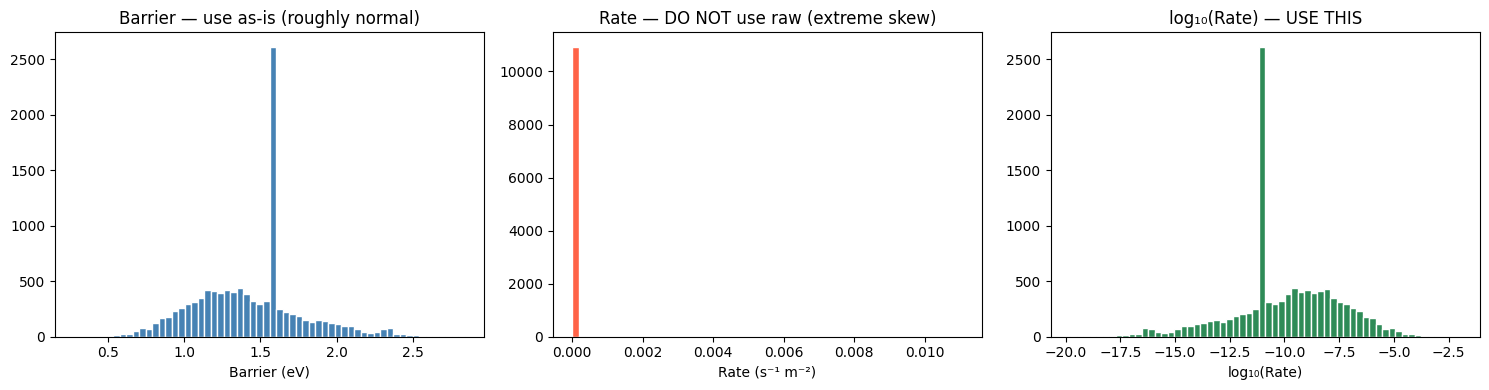


Barrier vs log_rate Pearson r = -1.000000
(Expected: -1.000 — they are a deterministic function of each other)
FEATURE CATEGORISATION
               Group  Count
    Host descriptors     37
  Dopant descriptors     32
Combined descriptors     10
   Coordination (CN)      5
     Site indicators      4
          Engineered      6
       Size mismatch      4

Surface one-hot will add: 19 columns
Total features entering model: ~117
TOP 20 FEATURES CORRELATED WITH BARRIER
  doped_weighted_surface_energy                : -0.6419
  doped_anerage_ionic_radius                   : +0.6039
  doped_efermi                                 : -0.5672
  doped_cohesive_energy                        : +0.5554
  doped_melting_point                          : -0.5342
  doped_boiling_point                          : -0.4724
  doped_atomic_radius                          : +0.4379
  doped_molar_volume                           : +0.4188
  doped_liquid_range                           : -0.3254
  doped_weight

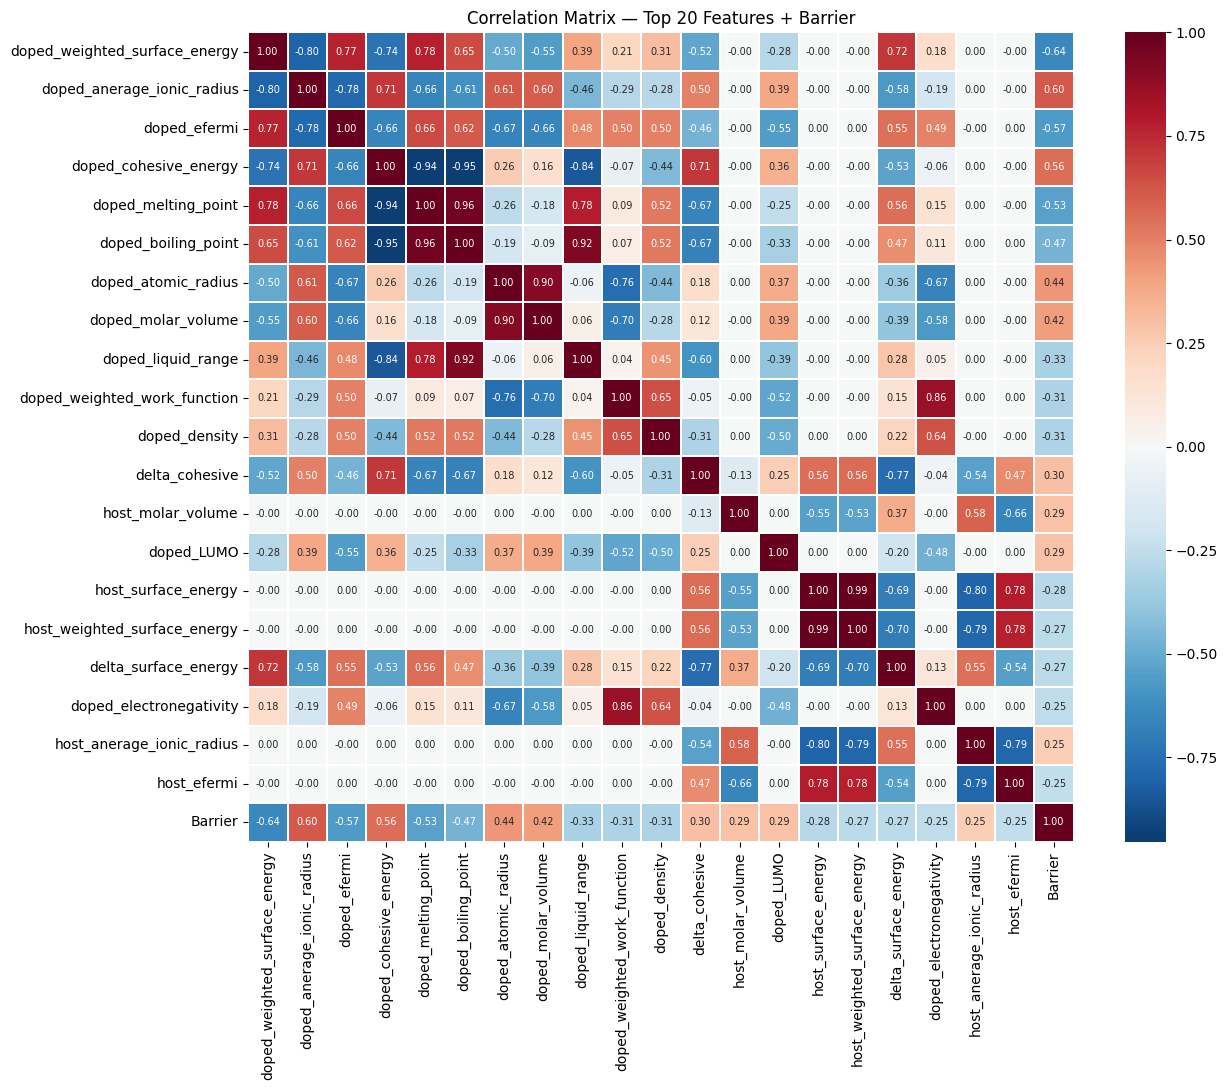

BARRIER STATISTICS BY SURFACE
         count   mean    std    min    max
Surface                                   
_332       450  1.371  0.356  0.672  2.504
_322       450  1.373  0.350  0.552  2.432
_311       420  1.387  0.354  0.620  2.510
_100       870  1.421  0.413  0.281  2.840
_221       870  1.423  0.351  0.559  2.565
_110       900  1.434  0.349  0.434  2.511
_331       450  1.439  0.343  0.601  2.523
_310       450  1.442  0.344  0.542  2.497
_320       450  1.444  0.336  0.712  2.497
_211       870  1.444  0.339  0.509  2.432
_321       450  1.446  0.341  0.586  2.497
_201       420  1.447  0.375  0.648  2.451
_210       870  1.456  0.349  0.614  2.535
_212       420  1.463  0.336  0.729  2.345
_111       900  1.466  0.374  0.684  2.716
_102       420  1.478  0.365  0.652  2.516
_2-12      420  1.500  0.338  0.698  2.471
_101       420  1.503  0.304  0.726  2.495
_001       450  1.542  0.338  0.745  2.835

BARRIER STATISTICS BY HOST
      count   mean    std    min    max

In [ ]:
# ========================================
# --- EDA part 1 ---
print("=" * 55)
print("BASIC STRUCTURE")
print("=" * 55)

print(f"Total rows    : {df.shape[0]:,}")
print(f"Total columns : {df.shape[1]}")
print(f"\nColumn types:")
print(df.dtypes.value_counts())

# --- EDA part 2 ---
print("=" * 55)
print("MISSING VALUE AUDIT")
print("=" * 55)

missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct':   missing_pct
}).query('missing_count > 0').sort_values('missing_count', ascending=False)

print(f"Columns with missing values: {len(missing_report)}")
print(missing_report.to_string())

# Drop any column with more than 20% missing values
threshold = 0.20
cols_drop  = missing_pct[missing_pct > threshold * 100].index.tolist()
if cols_drop:
    print(f"\nEDA flag only — retained {len(cols_drop)} columns above 20% missingness: {cols_drop}")
    print("No modelling column is removed globally; missing-value handling occurs inside each training fold.")
else:
    print("\nNo columns exceed 20% missingness.")

# --- EDA part 3 ---
print("=" * 55)
print("CATEGORICAL COLUMN AUDIT")
print("=" * 55)

cat_cols = ['Host', 'Doped', 'Surface', 'host_symmetry_symbol']
for col in cat_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Unique count : {df[col].nunique()}")
        print(f"  Values       : {sorted(df[col].unique())}")
        print(f"  Top 5 counts :")
        print(df[col].value_counts().head(5).to_string())

# Decision on each categorical column:
# Host                 → DROP  (represented by 37 host_ descriptor columns)
# Doped                → DROP  (represented by 32 doped_ descriptor columns)
# Surface              → KEEP and ONE-HOT ENCODE (geometry not in any numeric col)
# host_symmetry_symbol → DROP  (4 values only, redundant with CN features)

# --- EDA part 4 ---
print("=" * 55)
print("TARGET VARIABLE ANALYSIS")
print("=" * 55)

for t in ['Barrier', 'rate_723.15', 'rate_area_723']:
    print(f"\n{t}:")
    print(f"  Min    : {df[t].min():.6f}")
    print(f"  Max    : {df[t].max():.6f}")
    print(f"  Mean   : {df[t].mean():.6f}")
    print(f"  Median : {df[t].median():.6f}")
    print(f"  Std    : {df[t].std():.6f}")
    print(f"  Zeros  : {(df[t] == 0).sum()}")
    print(f"  Nulls  : {df[t].isnull().sum()}")

# Log-transform the rate — it spans 20 orders of magnitude
# A model trained on raw rates would be dominated by extreme values
df['log_rate'] = np.log10(df['rate_723.15'].replace(0, 1e-30))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['Barrier'],     bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Barrier — use as-is (roughly normal)')
axes[0].set_xlabel('Barrier (eV)')
axes[1].hist(df['rate_723.15'], bins=60, color='tomato',    edgecolor='white')
axes[1].set_title('Rate — DO NOT use raw (extreme skew)')
axes[1].set_xlabel('Rate (s⁻¹ m⁻²)')
axes[2].hist(df['log_rate'],    bins=60, color='seagreen',  edgecolor='white')
axes[2].set_title('log₁₀(Rate) — USE THIS')
axes[2].set_xlabel('log₁₀(Rate)')
plt.tight_layout()
save_figure(fig, 'target_distributions')
plt.show()

corr_br = df[['Barrier', 'log_rate']].corr().iloc[0, 1]
print(f"\nBarrier vs log_rate Pearson r = {corr_br:.6f}")
print("(Expected: -1.000 — they are a deterministic function of each other)")

# --- EDA part 5 ---
print("=" * 55)
print("FEATURE CATEGORISATION")
print("=" * 55)

host_feats  = [c for c in df.columns if c.startswith('host_')]
doped_feats = [c for c in df.columns if c.startswith('doped_')]
com_feats   = [c for c in df.columns if c.startswith('com_')]
cn_feats    = [c for c in df.columns if c.startswith('CN')]
site_feats  = [c for c in df.columns if c.startswith('site')]
eng_feats   = ['delta_d_band','delta_electroneg','delta_efermi',
               'delta_cohesive','delta_surface_energy','rd_rh_sq']
size_feats  = ['area_fraction','rd-rh','rd/rh','rd_rh_sq']

feat_summary = pd.DataFrame({
    'Group':   ['Host descriptors','Dopant descriptors','Combined descriptors',
                'Coordination (CN)','Site indicators','Engineered','Size mismatch'],
    'Count':   [len(host_feats), len(doped_feats), len(com_feats),
                len(cn_feats),   len(site_feats),  len(eng_feats),
                len(size_feats)]
})
print(feat_summary.to_string(index=False))
print(f"\nSurface one-hot will add: 19 columns")
print(f"Total features entering model: ~{sum(feat_summary['Count']) + 19}")

# --- EDA part 6 ---
print("=" * 55)
print("TOP 20 FEATURES CORRELATED WITH BARRIER")
print("=" * 55)

numeric_df  = df.select_dtypes(include=[np.number])
corr        = numeric_df.corr()['Barrier'].drop(
    ['Barrier','rate_723.15','rate_area_723','log_rate'], errors='ignore')
corr_ranked = corr.abs().sort_values(ascending=False)

for feat, val in corr_ranked.head(20).items():
    print(f"  {feat:45s}: {corr[feat]:+.4f}")

print("\nPhysical interpretation:")
print("  Negative = higher descriptor value → lower barrier → more active")
print("  Positive = higher descriptor value → higher barrier → less active")
print("  Dopant-side features dominate — dopant defines the active site")

# Correlation heatmap — top 20 features
top20_feats = corr_ranked.head(20).index.tolist() + ['Barrier']
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(df[top20_feats].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, linewidths=0.3, annot_kws={'size': 7})
ax.set_title('Correlation Matrix — Top 20 Features + Barrier', fontsize=12)
plt.tight_layout()
save_figure(fig, 'correlation_matrix')
plt.show()

# --- EDA part 7 ---
print("=" * 55)
print("BARRIER STATISTICS BY SURFACE")
print("=" * 55)
surf_stats = df.groupby('Surface')['Barrier'].agg(
    count='count', mean='mean', std='std', min='min', max='max'
).round(3).sort_values('mean')
print(surf_stats.to_string())

print("\n" + "=" * 55)
print("BARRIER STATISTICS BY HOST")
print("=" * 55)
host_stats = df.groupby('Host')['Barrier'].agg(
    count='count', mean='mean', std='std', min='min', max='max'
).round(3).sort_values('mean')
print(host_stats.to_string())

save_csv(surf_stats.reset_index(), 'surface_barrier_stats')
save_csv(host_stats.reset_index(), 'host_barrier_stats')

# --- EDA part 8 ---
print("=" * 55)
print("FINAL DATASET DECISION")
print("=" * 55)

print(f"Rows to use   : ALL {len(df):,} — no outlier removal")
print(f"Justification : All rows are valid DFT calculations.")
print(f"                Extreme barriers are real physics, not errors.")
print(f"\n{'='*55}")
print("NUMBERS FOR YOUR PAPER METHODS SECTION")
print("=" * 55)
print(f"  Dataset size          : 10,950 SAA configurations")
print(f"  Host metals           : 30 transition metals")
print(f"  Dopant metals         : 30 transition metals")
print(f"  Surface facets        : 19 crystallographic terminations")
print(f"  Input features        : ~121 (after encoding and engineering)")
print(f"    Host descriptors    : {len(host_feats)}")
print(f"    Dopant descriptors  : {len(doped_feats)}")
print(f"    Combined features   : {len(com_feats)}")
print(f"    CN features         : {len(cn_feats)}")
print(f"    Site indicators     : {len(site_feats)}")
print(f"    Engineered features : {len(eng_feats)}")
print(f"    Size mismatch       : {len(size_feats)}")
print(f"    Surface dummies     : 19")
print(f"  Primary target        : Activation barrier Ea (eV)")
print(f"    Range               : {df['Barrier'].min():.3f} – {df['Barrier'].max():.3f} eV")
print(f"    Mean ± Std          : {df['Barrier'].mean():.3f} ± {df['Barrier'].std():.3f} eV")
print(f"  Secondary target      : log₁₀(rate at 723.15 K)")
print(f"    Range               : {df['log_rate'].min():.1f} to {df['log_rate'].max():.1f}")
print(f"  Missing values        : <0.1% — filled with column medians")


## Step 9 — Build feature matrix  [REVISED]

In [ ]:
print('=' * 55); print('STEP 9 — BUILD RAW FEATURE MATRIX (no global preprocessing)'); print('=' * 55)
# Round-2 reviewer request (item 1): extract raw numerical descriptors, targets and
# labels separately. Missing values are PRESERVED. No global median imputation, no
# outlier clipping, no constant/variance/correlation/target-correlation filtering,
# no log transform, and NO global surface one-hot encoding. The categorical Surface
# column is kept raw; encoding is deferred to the fold-fitted preprocessor.
host_labels    = df['Host'].values.copy()
surface_labels = df['Surface'].astype(str).values.copy()
y_barrier      = df['Barrier'].values.astype(float)
y_rate         = df['log_rate'].values.astype(float) if 'log_rate' in df.columns else np.full(len(df), np.nan)

_drop = ['Host', 'Doped', 'host_symmetry_symbol', 'Surface',
         'Barrier', 'rate_723.15', 'rate_area_723', 'log_rate']
num_df = (df.drop(columns=[c for c in _drop if c in df.columns], errors='ignore')
            .select_dtypes(include=[np.number]).copy())
num_names   = list(num_df.columns)
X_num_raw   = num_df.values.astype(float)          # NaNs preserved
surface_cat = df['Surface'].astype(str).values.reshape(-1, 1)   # raw categorical

_payload = {'X_num_raw': X_num_raw, 'num_names': num_names, 'surface_cat': surface_cat,
            'y_barrier': y_barrier, 'y_rate': y_rate,
            'host_labels': host_labels, 'surface_labels': surface_labels}
save_checkpoint(_payload, 'feature_matrix_raw')
save_checkpoint(_payload, 'feature_matrix_raw_safe')
print(f'Raw numeric descriptors : {X_num_raw.shape}  (NaNs preserved: {int(np.isnan(X_num_raw).sum())})')
print(f'Raw categorical (Surface): kept unencoded, {len(np.unique(surface_cat))} categories')
print(f'Hosts: {len(np.unique(host_labels))} | Surfaces: {len(np.unique(surface_labels))}')
print('Imputation / encoding / filtering are deferred to the fold-fitted preprocessor.')


STEP 9 — BUILD RAW FEATURE MATRIX (no global preprocessing)
  ✓ Checkpoint saved: feature_matrix_raw
  ✓ Checkpoint saved: feature_matrix_raw_safe
Raw numeric descriptors : (10950, 96)  (NaNs preserved: 0)
Raw categorical (Surface): kept unencoded, 19 categories
Hosts: 30 | Surfaces: 19
Imputation / encoding / filtering are deferred to the fold-fitted preprocessor.


## Step 10 — matminer + CALPHAD enrichment  [NOT CHANGED]

In [ ]:
print('=' * 55); print('STEP 10 — RAW MATMINER + CALPHAD FEATURES (NaNs preserved)'); print('=' * 55)
# Round-2 reviewer request (item 1): compute composition-only Magpie descriptors and
# the Miedema (CALPHAD proxy) mixing enthalpy PER ROW. Magpie/Miedema are functions of
# a single row's composition, so per-row computation is not cross-sample leakage.
# Global constant-column removal and global median fill are REMOVED; NaNs are kept and
# handled later inside the fold-fitted preprocessor.
mm = load_checkpoint('matminer_features_raw_safe')
if mm is not None:
    X_matminer_raw = mm['X_matminer_raw']; matminer_names = mm['matminer_names']
    print('OK raw matminer features loaded.')
else:
    import warnings; warnings.filterwarnings('ignore')
    try:
        from matminer.featurizers.composition import ElementProperty, Miedema
        from pymatgen.core import Composition
    except Exception as exc:
        raise ImportError('matminer/pymatgen import failed. Run the pinned installation in Step 2 before Step 3.') from exc
    from tqdm.notebook import tqdm
    ep = ElementProperty.from_preset('magpie'); labels = ep.feature_labels()
    def _magpie(sym):
        try: return ep.featurize(Composition(sym))
        except Exception: return [np.nan] * len(labels)
    hosts = df['Host'].values; dops = df['Doped'].values
    host_magpie  = [_magpie(h) for h in tqdm(hosts, desc='host Magpie', ncols=80)]
    doped_magpie = [_magpie(d) for d in tqdm(dops,  desc='dopant Magpie', ncols=80)]
    host_df  = pd.DataFrame(host_magpie,  columns=[f'host_magpie_{l}'  for l in labels])
    doped_df = pd.DataFrame(doped_magpie, columns=[f'doped_magpie_{l}' for l in labels])
    delta_df = pd.DataFrame({f'delta_magpie_{l}':
                             doped_df[f'doped_magpie_{l}'].values - host_df[f'host_magpie_{l}'].values
                             for l in labels})
    mie = Miedema(); mvals = []
    for h, d in tqdm(zip(hosts, dops), total=len(df), desc='Miedema', ncols=80):
        try:
            mvals.append([0.0] * len(mie.feature_labels()) if h == d
                         else mie.featurize(Composition({h: 0.5, d: 0.5})))
        except Exception:
            mvals.append([np.nan] * len(mie.feature_labels()))
    mie_df = pd.DataFrame(mvals, columns=[f'calphad_{l}' for l in mie.feature_labels()])
    X_mm = pd.concat([host_df, doped_df, delta_df, mie_df], axis=1)
    # RAW: do NOT drop constant columns, do NOT fill NaN
    matminer_names = list(X_mm.columns); X_matminer_raw = X_mm.values.astype(float)
    _p = {'X_matminer_raw': X_matminer_raw, 'matminer_names': matminer_names}
    save_checkpoint(_p, 'matminer_features_raw'); save_checkpoint(_p, 'matminer_features_raw_safe')
    print(f'Raw matminer computed: {X_matminer_raw.shape}  (NaNs preserved: {int(np.isnan(X_matminer_raw).sum())})')
print('No global constant-removal or global NaN fill applied; handled in fold-fitted preprocessor.')


STEP 10 — RAW MATMINER + CALPHAD FEATURES (NaNs preserved)
  ✓ Checkpoint loaded: matminer_features_raw_safe
OK raw matminer features loaded.
No global constant-removal or global NaN fill applied; handled in fold-fitted preprocessor.


## Step 11 — Leakage-safe preprocessor (replaces old global clean)  [NEW/REVISED]

In [ ]:
print('=' * 55); print('STEP 11 — RAW POOL + FOLD-FITTED LEAKAGE-SAFE PREPROCESSOR'); print('=' * 55)
# Round-2 reviewer request (item 1): assemble the RAW descriptor pool (numeric-with-NaN
# + raw categorical Surface) and define a preprocessor that fits EVERY step — median
# imputation, outlier clipping, log transform, duplicate/variance/correlation and
# target-correlation filtering, AND one-hot encoding — using ONLY the data passed to
# fit(). It is called once per outer-training fold, so no test-fold statistic leaks.
from scipy.stats import skew as _skew
from sklearn.preprocessing import OneHotEncoder

_raw = load_checkpoint('preclean_matrix_raw_safe')
if _raw is not None:
    print('OK raw pool loaded.')
else:
    _fm = require_checkpoint('feature_matrix_raw_safe')
    _mm = require_checkpoint('matminer_features_raw_safe')
    X_numeric_raw = np.hstack([_fm['X_num_raw'], _mm['X_matminer_raw']]).astype(float)
    numeric_names = list(_fm['num_names']) + list(_mm['matminer_names'])
    X_cat_raw     = _fm['surface_cat']; cat_names = ['Surface']
    original_feature_set = [f for f in numeric_names
                            if not f.startswith(('host_magpie_', 'doped_magpie_',
                                                 'delta_magpie_', 'calphad_'))]
    _pool = {'X_numeric_raw': X_numeric_raw, 'numeric_names': numeric_names,
             'X_cat_raw': X_cat_raw, 'cat_names': cat_names,
             'original_feature_set': original_feature_set,
             'y_barrier': _fm['y_barrier'], 'host_labels': _fm['host_labels'],
             'surface_labels': _fm['surface_labels']}
    save_checkpoint(_pool, 'preclean_matrix_raw')
    save_checkpoint(_pool, 'preclean_matrix_raw_safe')
    print(f'Raw pool: {X_numeric_raw.shape[0]} rows x {X_numeric_raw.shape[1]} numeric '
          f'+ {len(cat_names)} categorical (unencoded).')

def _make_ohe():
    try:    return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

class LeakageSafePreprocessor:
    """Train-fold-only preprocessor: imputation + clipping + log + filtering + OHE.
    Fit once per outer-training fold; the held-out fold (incl. unseen LOSO surfaces
    via handle_unknown='ignore') never contributes to any fitted statistic."""
    def __init__(self, numeric_cols, categorical_cols, orig,
                 corr_thresh=0.95, target_corr_thresh=0.01, skew_thresh=2.0,
                 clip_sigma=6.0, lowvar_pct=5.0):
        self.numeric_cols = list(numeric_cols); self.categorical_cols = list(categorical_cols)
        self.orig = set(orig); self.corr_thresh = corr_thresh; self.tc_thresh = target_corr_thresh
        self.skew_thresh = skew_thresh; self.clip_sigma = clip_sigma; self.lowvar_pct = lowvar_pct
    def fit(self, X_df, y):
        X_df = pd.DataFrame(X_df)
        d = (X_df[self.numeric_cols].apply(pd.to_numeric, errors='coerce')
                                    .replace([np.inf, -np.inf], np.nan))
        self.medians = d.median(numeric_only=True)
        self.global_median = float(np.nanmedian(self.medians.values)) if len(self.medians) else 0.0
        d = d.fillna(self.medians).fillna(self.global_median)
        mu = d.mean(); sd = d.std().replace(0, 1.0)
        self.clip_low = mu - self.clip_sigma * sd; self.clip_high = mu + self.clip_sigma * sd
        d = d.clip(self.clip_low, self.clip_high, axis=1)
        self.log_cols = [c for c in d.columns if c not in self.orig
                         and d[c].min() > 0 and abs(_skew(d[c].values)) > self.skew_thresh]
        if self.log_cols: d[self.log_cols] = np.log1p(d[self.log_cols])
        s = d.std(); d = d[[c for c in d.columns if s[c] > 1e-6 or c in self.orig]]
        dup = d.T.duplicated().values
        d = d[[c for c, x in zip(d.columns, dup) if not x or c in self.orig]]
        cr = d.corr().abs(); up = cr.where(np.triu(np.ones(cr.shape), k=1).astype(bool))
        d = d.drop(columns=[c for c in up.columns
                            if c not in self.orig and (up[c] > self.corr_thresh).any()])
        v = d.var(); thr = np.percentile(v.values, self.lowvar_pct) if len(v) else 0.0
        d = d[[c for c in d.columns if v[c] > thr or c in self.orig]]
        yv = np.asarray(y, float); drp = []
        for c in d.columns:
            if c in self.orig: continue
            r = np.corrcoef(d[c].values, yv)[0, 1]
            if not np.isfinite(r) or abs(r) < self.tc_thresh: drp.append(c)
        d = d.drop(columns=drp); self.kept_numeric = list(d.columns)
        if self.categorical_cols:
            self.ohe = _make_ohe()
            self.ohe.fit(X_df[self.categorical_cols].astype(str).values)
            self.cat_out = [f'{col}__{cat}' for col, cats in
                            zip(self.categorical_cols, self.ohe.categories_) for cat in cats]
        else:
            self.ohe = None; self.cat_out = []
        self.kept_cols = self.kept_numeric + self.cat_out          # for downstream naming
        self.output_feature_names_ = self.kept_cols
        return self
    def _num(self, X_df):
        d = (pd.DataFrame(X_df)[self.numeric_cols].apply(pd.to_numeric, errors='coerce')
                                                  .replace([np.inf, -np.inf], np.nan))
        d = d.fillna(self.medians).fillna(self.global_median)
        d = d.clip(self.clip_low, self.clip_high, axis=1)
        if self.log_cols: d[self.log_cols] = np.log1p(d[self.log_cols].clip(lower=0))
        return d[self.kept_numeric]
    def transform(self, X_df):
        X_df = pd.DataFrame(X_df)
        num = self._num(X_df).values
        if self.ohe is not None:
            cat = self.ohe.transform(X_df[self.categorical_cols].astype(str).values)
            out = np.hstack([num, cat])
        else:
            out = num
        return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

def load_raw_pool():
    """Return (X_pre_df, numeric_names, cat_names, original_feature_set) from the raw pool.
    X_pre_df holds raw numeric columns (with NaN) plus the raw categorical Surface column."""
    raw = require_checkpoint('preclean_matrix_raw_safe')
    Xn = np.asarray(raw['X_numeric_raw'], float); nm = list(raw['numeric_names'])
    Xc = np.asarray(raw['X_cat_raw']);            cn = list(raw['cat_names'])
    orig = set(raw['original_feature_set'])
    d = pd.DataFrame(Xn, columns=nm)
    for j, c in enumerate(cn):
        d[c] = Xc[:, j]
    return d, nm, cn, orig

# Exact provenance metadata used by both the retrospective ranking and the audit.
# Classification is based on exact descriptor membership/source checkpoints, not arbitrary
# substring matching. Unmapped raw database columns remain manual-review-required.
def _prov_meta(category, source, required, composition_only, structure_dependent,
               dft_derived, pre_target, target_risk, prospective, cost, notes=''):
    return {
        'descriptor_category': category, 'source': source,
        'required_input_information': required, 'composition_only': composition_only,
        'structure_dependent': structure_dependent, 'DFT_derived': dft_derived,
        'available_before_barrier_calculation': pre_target,
        'target_comparable_DFT_risk': target_risk,
        'allowed_for_prospective_screening': prospective,
        'approximate_computational_cost': cost, 'notes': notes,
    }

BASE_DESCRIPTOR_EXACT_METADATA = {
    'host_d-band_center': _prov_meta('Reference electronic descriptor', 'dataset documentation / precomputed clean-host DFT',
        'host identity and clean-host reference calculation', False, True, True, True, False, True, 'high (precomputed DFT)'),
    'doped_d-band_center': _prov_meta('Reference electronic descriptor', 'dataset documentation / precomputed dopant DFT',
        'dopant identity and reference calculation', False, True, True, True, False, True, 'high (precomputed DFT)'),
    'host_efermi': _prov_meta('Reference electronic descriptor', 'dataset documentation / precomputed host DFT',
        'host identity and reference calculation', False, True, True, True, False, True, 'high (precomputed DFT)'),
    'doped_efermi': _prov_meta('Reference electronic descriptor', 'dataset documentation / precomputed dopant DFT',
        'dopant identity and reference calculation', False, True, True, True, False, True, 'high (precomputed DFT)'),
    'host_weighted_surface_energy': _prov_meta('Reference surface descriptor', 'dataset documentation / clean-host surface reference',
        'host and surface facet', False, True, True, True, False, True, 'high (precomputed DFT)'),
    'doped_weighted_surface_energy': _prov_meta('Reference surface descriptor', 'dataset documentation / dopant reference',
        'dopant and surface reference', False, True, True, True, False, True, 'high (precomputed DFT)'),
    'host_cohesive_energy': _prov_meta('Bulk reference descriptor', 'dataset documentation / elemental bulk reference',
        'host identity', True, False, True, True, False, True, 'moderate (precomputed reference)'),
    'doped_cohesive_energy': _prov_meta('Bulk reference descriptor', 'dataset documentation / elemental bulk reference',
        'dopant identity', True, False, True, True, False, True, 'moderate (precomputed reference)'),
    'host_electronegativity': _prov_meta('Elemental tabulated descriptor', 'elemental reference table',
        'host identity', True, False, False, True, False, True, 'low (tabulated)'),
    'doped_electronegativity': _prov_meta('Elemental tabulated descriptor', 'elemental reference table',
        'dopant identity', True, False, False, True, False, True, 'low (tabulated)'),
    'host_d-electron': _prov_meta('Elemental tabulated descriptor', 'elemental electron configuration table',
        'host identity', True, False, False, True, False, True, 'low (tabulated)'),
    'rd/rh': _prov_meta('Atomic-size descriptor', 'elemental radius ratio',
        'host and dopant elemental radii', True, False, False, True, False, True, 'low (tabulated)'),
    'rd-rh': _prov_meta('Atomic-size descriptor', 'elemental radius difference',
        'host and dopant elemental radii', True, False, False, True, False, True, 'low (tabulated)'),
    'area_fraction': _prov_meta('Geometric descriptor', 'dataset geometry metadata',
        'surface/site geometry', False, True, False, True, False, True, 'low (geometry)'),
    'site1': _prov_meta('Adsorption-site label', 'dataset site annotation',
        'predefined adsorption-site identity', False, True, False, True, False, True, 'low (categorical geometry)'),
}
ENGINEERED_EXACT_METADATA = {
    'delta_d_band': _prov_meta('Engineered reference difference', 'doped_d-band_center - host_d-band_center',
        'two precomputed d-band references', False, True, True, True, False, True, 'low after reference DFT'),
    'delta_electroneg': _prov_meta('Engineered elemental difference', 'doped - host electronegativity',
        'element identities', True, False, False, True, False, True, 'low (derived)'),
    'delta_efermi': _prov_meta('Engineered reference difference', 'doped_efermi - host_efermi',
        'two precomputed Fermi-level references', False, True, True, True, False, True, 'low after reference DFT'),
    'delta_cohesive': _prov_meta('Engineered bulk-reference difference', 'doped - host cohesive energy',
        'two bulk references', True, False, True, True, False, True, 'low after reference data'),
    'delta_surface_energy': _prov_meta('Engineered surface-reference difference', 'doped - host weighted surface energy',
        'two surface references', False, True, True, True, False, True, 'low after reference DFT'),
    'rd_rh_sq': _prov_meta('Engineered atomic-size descriptor', '(rd/rh)^2',
        'elemental radii', True, False, False, True, False, True, 'low (derived)'),
}

def build_exact_descriptor_provenance():
    fm = require_checkpoint('feature_matrix_raw_safe')
    mm = require_checkpoint('matminer_features_raw_safe')
    raw = require_checkpoint('preclean_matrix_raw_safe')
    mm_names = list(mm['matminer_names'])
    all_names = list(raw['numeric_names']) + [f'{c} (one-hot categories)' for c in raw['cat_names']]
    exact = dict(BASE_DESCRIPTOR_EXACT_METADATA)
    exact.update(ENGINEERED_EXACT_METADATA)
    exact['Surface (one-hot categories)'] = _prov_meta(
        'Categorical surface facet', 'dataset Surface label', 'surface facet label',
        False, True, False, True, False, True, 'low (label)')
    for name in mm_names:
        if name.startswith('host_magpie_'):
            exact[name] = _prov_meta('Host Magpie elemental statistic', 'matminer Magpie tables',
                'host identity', True, False, False, True, False, True, 'low (tabulated)')
        elif name.startswith('doped_magpie_'):
            exact[name] = _prov_meta('Dopant Magpie elemental statistic', 'matminer Magpie tables',
                'dopant identity', True, False, False, True, False, True, 'low (tabulated)')
        elif name.startswith('delta_magpie_'):
            exact[name] = _prov_meta('Delta Magpie elemental statistic', 'difference of exact host/dopant Magpie values',
                'host and dopant identities', True, False, False, True, False, True, 'low (derived)')
        elif name.startswith('calphad_'):
            exact[name] = _prov_meta('Miedema bulk-mixing proxy', 'matminer Miedema model',
                'host and dopant identities; equiatomic bulk proxy', True, False, False, True, False, True,
                'low-moderate (semi-empirical model)',
                'Bulk proxy only; does not establish surface segregation or synthesis stability.')
    rows = []
    for name in all_names:
        meta = exact.get(name)
        if meta is None:
            rows.append({
                'descriptor_name': name, 'classification_status': 'manual_review_required',
                'mapping_method': 'exact-name lookup: no verified entry',
                'descriptor_category': 'Unclassified — manual review required',
                'original_or_engineered': 'unknown', 'source': 'unknown / dataset documentation required',
                'required_input_information': 'manual provenance review required',
                'composition_only': 'Unknown', 'structure_dependent': 'Unknown', 'DFT_derived': 'Unknown',
                'available_before_barrier_calculation': 'Unknown',
                'target_comparable_DFT_risk': 'Unknown',
                'approximate_computational_cost': 'unknown',
                'allowed_for_retrospective_analysis': True,
                'allowed_for_prospective_screening': False,
                'included_in_retrospective_full_model': True,
                'included_in_availability_constrained_model': False,
                'included_in_main_models': 'retrospective full-descriptor model only',
                'reason_for_inclusion': 'Retrospective full-descriptor benchmark only.',
                'reason_for_exclusion': 'Manual exact-name provenance review required before prospective use.',
                'notes': 'No heuristic safety assignment is made.',
            })
            continue
        engineered = name in ENGINEERED_EXACT_METADATA or name.startswith(('delta_magpie_', 'calphad_'))
        rows.append({
            'descriptor_name': name, 'classification_status': 'curated_exact',
            'mapping_method': 'exact name / exact generated-source membership',
            'descriptor_category': meta['descriptor_category'],
            'original_or_engineered': 'engineered' if engineered else 'original',
            'source': meta['source'], 'required_input_information': meta['required_input_information'],
            'composition_only': bool(meta['composition_only']),
            'structure_dependent': bool(meta['structure_dependent']),
            'DFT_derived': bool(meta['DFT_derived']),
            'available_before_barrier_calculation': bool(meta['available_before_barrier_calculation']),
            'target_comparable_DFT_risk': bool(meta['target_comparable_DFT_risk']),
            'approximate_computational_cost': meta['approximate_computational_cost'],
            'allowed_for_retrospective_analysis': True,
            'allowed_for_prospective_screening': bool(meta['allowed_for_prospective_screening']),
            'included_in_retrospective_full_model': True,
            'included_in_availability_constrained_model': bool(
                meta['allowed_for_prospective_screening']
                and meta['available_before_barrier_calculation']
                and not meta['target_comparable_DFT_risk']),
            'included_in_main_models': ('both retrospective full and availability-constrained models'
                                        if (meta['allowed_for_prospective_screening']
                                            and meta['available_before_barrier_calculation']
                                            and not meta['target_comparable_DFT_risk'])
                                        else 'retrospective full-descriptor model only'),
            'reason_for_inclusion': ('Exact provenance supports pre-target use.'
                                     if meta['allowed_for_prospective_screening'] else ''),
            'reason_for_exclusion': ('' if meta['allowed_for_prospective_screening']
                                     else 'Not verified as prospectively available.'),
            'notes': meta.get('notes', ''),
        })
    return pd.DataFrame(rows)

print('OK LeakageSafePreprocessor (train-fold-only preprocessing; fixed model hyperparameters)'
      ' and load_raw_pool() defined.')


STEP 11 — RAW POOL + FOLD-FITTED LEAKAGE-SAFE PREPROCESSOR
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
OK raw pool loaded.
OK LeakageSafePreprocessor (train-fold-only preprocessing; fixed model hyperparameters) and load_raw_pool() defined.


## Step 12 — Model definitions, fixed protocol policy, and repeated nested-tuning policy  [REVISED]


In [ ]:
print('=' * 55); print('STEP 12 — MODEL FACTORIES (explicit per-model seeds)'); print('=' * 55)
# Reviewer item 4: every stochastic factory takes an explicit seed controlling ALL randomness.
# Default is the global SEED (for single-fit deployment/interpretation contexts); repeated CV
# passes the current fold seed s so the five repeats are genuinely independent.
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

def make_rf(seed=SEED):
    return RandomForestRegressor(n_estimators=300, max_features='sqrt', min_samples_leaf=2,
                                 n_jobs=-1, random_state=int(seed))

class DeepForest:
    """Deep Forest (gcForest), pure-sklearn. Per layer: 2x RandomForest + 2x ExtraTrees.
    Out-of-fold predictions between layers prevent leakage. Reference: Zhou & Feng (2017)."""
    def __init__(self, n_estimators=150, max_layers=8, min_delta=0.001, cv_folds=3,
                 n_jobs=-1, random_state=42):
        self.n_estimators = n_estimators; self.max_layers = max_layers; self.min_delta = min_delta
        self.cv_folds = cv_folds; self.n_jobs = n_jobs; self.random_state = int(random_state)
        self.layers_ = []; self.best_layer_ = 0; self.layer_scores_ = []
    def _make_layer(self, layer_idx):
        rs = self.random_state + layer_idx * 10
        return [RandomForestRegressor(self.n_estimators, max_features='sqrt', min_samples_leaf=2, n_jobs=self.n_jobs, random_state=rs),
                RandomForestRegressor(self.n_estimators, max_features=0.5, min_samples_leaf=2, n_jobs=self.n_jobs, random_state=rs + 1),
                ExtraTreesRegressor(self.n_estimators, max_features='sqrt', min_samples_leaf=2, n_jobs=self.n_jobs, random_state=rs + 2),
                ExtraTreesRegressor(self.n_estimators, max_features=0.5, min_samples_leaf=2, n_jobs=self.n_jobs, random_state=rs + 3)]
    def _oof_predictions(self, forests, X, y):
        kf = KFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)
        oof = np.zeros((len(X), len(forests)))
        for j, forest in enumerate(forests):
            oof[:, j] = cross_val_predict(forest, X, y, cv=kf, n_jobs=1)
        return oof
    def _layer_predict(self, forests, X):
        preds = np.zeros((len(X), len(forests)))
        for j, forest in enumerate(forests):
            preds[:, j] = forest.predict(X)
        return preds
    def fit(self, X, y, verbose=True):
        X = np.array(X); y = np.array(y); X_aug = X.copy(); best_score = -np.inf
        for layer_idx in range(self.max_layers):
            t0 = time.time(); forests = self._make_layer(layer_idx)
            oof = self._oof_predictions(forests, X_aug, y)
            from sklearn.metrics import r2_score
            score = r2_score(y, oof.mean(axis=1)); self.layer_scores_.append(score)
            for forest in forests: forest.fit(X_aug, y)
            self.layers_.append(forests)
            if verbose:
                print(f'  Layer {layer_idx+1:2d} | CV R2={score:.5f} | d={score - best_score:+.5f} | {time.time()-t0:.1f}s')
            if score > best_score + self.min_delta:
                best_score = score; self.best_layer_ = layer_idx
            else:
                if verbose: print(f'  -> Early stop. Best layer: {self.best_layer_+1}')
                self.layers_.pop(); break
            X_aug = np.hstack([X, oof])
        return self
    def predict(self, X):
        X = np.array(X); X_aug = X.copy()
        for layer_idx, forests in enumerate(self.layers_):
            preds = self._layer_predict(forests, X_aug)
            if layer_idx < len(self.layers_) - 1:
                X_aug = np.hstack([X, preds])
        return preds.mean(axis=1)
    def feature_importances_from_layer(self, layer_idx=0, feature_names=None):
        forests = self.layers_[layer_idx]
        n_orig = len(feature_names) if feature_names else forests[0].n_features_in_
        imps = np.zeros(n_orig)
        for forest in forests: imps += forest.feature_importances_[:n_orig]
        imps /= len(forests)
        if feature_names: return pd.Series(imps, index=feature_names).sort_values(ascending=False)
        return imps

def make_df(seed=SEED):
    return DeepForest(n_estimators=150, max_layers=8, min_delta=0.001, cv_folds=3, random_state=int(seed))

def make_mlp(seed=SEED):
    return Pipeline([('scaler', StandardScaler()),
        ('mlp', MLPRegressor(hidden_layer_sizes=(512, 256, 128), activation='relu', solver='adam',
            alpha=0.001, learning_rate='adaptive', learning_rate_init=0.001, max_iter=500,
            early_stopping=True, validation_fraction=0.1, n_iter_no_change=20, random_state=int(seed)))])

def make_xgb(seed=SEED):
    return xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8,
        colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=int(seed), n_jobs=-1, verbosity=0)

print('OK make_rf(seed), make_df(seed), make_mlp(seed), make_xgb(seed) defined.')

# Prespecified fixed-hyperparameter policy used identically across all outer protocols.
# No outer-test target, chemistry group, or corrected-evaluation result is used to select these values.
MODEL_HYPERPARAMETER_POLICY = {
    'RF': {
        'configuration': 'n_estimators=300; max_features=sqrt; min_samples_leaf=2',
        'selection_procedure': 'prespecified fixed configuration; no inner-CV tuning',
        'scope': 'identical configuration across random CV, repeated CV, LOHO, LOSO, LODO and pair validation',
    },
    'DF': {
        'configuration': 'n_estimators=150; max_layers=8; min_delta=0.001; internal OOF cv_folds=3',
        'selection_procedure': 'prespecified fixed configuration; no outer-fold hyperparameter search',
        'scope': 'identical configuration across random CV, repeated CV, LOHO, LOSO and LODO',
    },
    'MLP': {
        'configuration': 'hidden=(512,256,128); alpha=0.001; lr_init=0.001; early_stopping=True',
        'selection_procedure': 'prespecified fixed configuration; internal training-only validation for stopping',
        'scope': 'identical configuration across random CV, repeated CV, LOHO, LOSO and LODO',
    },
    'XGB': {
        'configuration': 'n_estimators=500; learning_rate=0.05; max_depth=6; subsample=0.8; colsample_bytree=0.8; reg_alpha=0.1; reg_lambda=1.0',
        'selection_procedure': 'prespecified fixed configuration; no inner-CV tuning',
        'scope': 'identical configuration across random CV, repeated CV, LOHO, LOSO, LODO and pair validation',
    },
}
HYPERPARAMETER_CLAIM_SCOPE = (
    'Results compare prespecified fixed model configurations under identical split and preprocessing rules. '
    'They do not establish superiority of optimally tuned model families.'
)
print('Hyperparameter policy:', HYPERPARAMETER_CLAIM_SCOPE)


# =============================================================================
# Compact repeated nested-CV tuning policy (used in Step 15 only)
# =============================================================================
# The main protocol-comparison pipeline (Steps 14, 16, 17, 18, 19, 20) retains
# prespecified fixed configurations so random-CV and chemistry-aware protocol gaps
# are not confounded by different search spaces. Step 15 is a separate repeated
# NESTED model-comparison analysis: every outer seed-fold uses the same inner folds,
# the same selection metric (MAE), and a two-candidate prespecified grid per model.
# Outer-test outcomes are never used for tuning.
REPEATED_NESTED_VERSION = 'repeated_nested_tuned_v3_8'
INNER_CV_SPLITS = 2
INNER_SELECTION_METRIC = 'MAE'
MODEL_TUNING_GRIDS = {
    'RF': [
        {'n_estimators': 300, 'max_features': 'sqrt', 'min_samples_leaf': 1},
        {'n_estimators': 300, 'max_features': 'sqrt', 'min_samples_leaf': 2},
    ],
    'DF': [
        {'n_estimators': 100, 'max_layers': 6, 'min_delta': 0.001, 'cv_folds': 2},
        {'n_estimators': 150, 'max_layers': 8, 'min_delta': 0.001, 'cv_folds': 2},
    ],
    'MLP': [
        {'hidden_layer_sizes': (256, 128), 'alpha': 0.001, 'learning_rate_init': 0.001},
        {'hidden_layer_sizes': (512, 256, 128), 'alpha': 0.001, 'learning_rate_init': 0.001},
    ],
    'XGB': [
        {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4,
         'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0},
        {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6,
         'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0},
    ],
}

def make_model_from_params(model_key, params, seed):
    """Build one model from an explicit candidate dictionary."""
    p = dict(params)
    if model_key == 'RF':
        return RandomForestRegressor(
            n_estimators=int(p['n_estimators']),
            max_features=p['max_features'],
            min_samples_leaf=int(p['min_samples_leaf']),
            n_jobs=-1, random_state=int(seed))
    if model_key == 'DF':
        return DeepForest(
            n_estimators=int(p['n_estimators']),
            max_layers=int(p['max_layers']),
            min_delta=float(p['min_delta']),
            cv_folds=int(p.get('cv_folds', 2)),
            n_jobs=-1, random_state=int(seed))
    if model_key == 'MLP':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPRegressor(
                hidden_layer_sizes=tuple(p['hidden_layer_sizes']),
                activation='relu', solver='adam',
                alpha=float(p['alpha']),
                learning_rate='adaptive',
                learning_rate_init=float(p['learning_rate_init']),
                max_iter=500, early_stopping=True,
                validation_fraction=0.1, n_iter_no_change=20,
                random_state=int(seed)))
        ])
    if model_key == 'XGB':
        return xgb.XGBRegressor(
            n_estimators=int(p['n_estimators']),
            learning_rate=float(p['learning_rate']),
            max_depth=int(p['max_depth']),
            subsample=float(p['subsample']),
            colsample_bytree=float(p['colsample_bytree']),
            reg_alpha=float(p['reg_alpha']),
            reg_lambda=float(p['reg_lambda']),
            random_state=int(seed), n_jobs=-1, verbosity=0)
    raise KeyError(model_key)

def prepare_inner_preprocessed_folds(X_outer_df, y_outer, seed, n_splits=INNER_CV_SPLITS):
    """Create inner folds with preprocessing fitted on inner-train only."""
    X_outer_df = X_outer_df.reset_index(drop=True)
    y_outer = np.asarray(y_outer, float)
    if len(X_outer_df) != len(y_outer):
        raise ValueError('Inner tuning X/y length mismatch.')
    if len(y_outer) < max(4, n_splits):
        raise ValueError('Too few outer-training samples for inner CV.')
    inner = KFold(n_splits=int(n_splits), shuffle=True, random_state=int(seed))
    prepared = []
    for inner_fold, (itr, iva) in enumerate(inner.split(X_outer_df)):
        prep = LeakageSafePreprocessor(
            numeric_names, cat_names, original_feature_set
        ).fit(X_outer_df.iloc[itr], y_outer[itr])
        Xitr = prep.transform(X_outer_df.iloc[itr])
        Xiva = prep.transform(X_outer_df.iloc[iva])
        prepared.append({
            'inner_fold': int(inner_fold),
            'X_train': Xitr, 'y_train': y_outer[itr],
            'X_valid': Xiva, 'y_valid': y_outer[iva],
            'selected_feature_count': int(Xitr.shape[1]),
        })
    return prepared

def tune_model_on_prepared_folds(model_key, prepared_folds, seed):
    """Select the candidate with the lowest mean inner-validation MAE."""
    diagnostics = []
    for candidate_id, params in enumerate(MODEL_TUNING_GRIDS[model_key]):
        fold_mae = []
        for block in prepared_folds:
            model = make_model_from_params(model_key, params, seed)
            if model_key == 'DF':
                model.fit(block['X_train'], block['y_train'], verbose=False)
            else:
                model.fit(block['X_train'], block['y_train'])
            pred = model.predict(block['X_valid'])
            fold_mae.append(float(mean_absolute_error(block['y_valid'], pred)))
        diagnostics.append({
            'model': model_key,
            'candidate_id': int(candidate_id),
            'params': dict(params),
            'inner_fold_MAE': [float(v) for v in fold_mae],
            'mean_inner_MAE': float(np.mean(fold_mae)),
            'std_inner_MAE': float(np.std(fold_mae, ddof=1)) if len(fold_mae) > 1 else np.nan,
            'inner_cv_splits': int(len(prepared_folds)),
            'selection_metric': INNER_SELECTION_METRIC,
        })
    diagnostics = sorted(diagnostics, key=lambda r: (r['mean_inner_MAE'], r['candidate_id']))
    best = diagnostics[0]
    return dict(best['params']), diagnostics

REPEATED_NESTED_TUNING_POLICY = {
    'version': REPEATED_NESTED_VERSION,
    'outer_repeats': 5,
    'outer_folds': 5,
    'inner_folds': INNER_CV_SPLITS,
    'selection_metric': INNER_SELECTION_METRIC,
    'same_inner_splits_for_all_models_within_outer_fold': True,
    'outer_test_used_for_selection': False,
    'candidate_count_per_model': {k: len(v) for k, v in MODEL_TUNING_GRIDS.items()},
    'claim_scope': (
        'Repeated nested CV compares compact prespecified candidate grids under identical '
        'inner-split and fold-fitted preprocessing rules. It does not prove global optimum '
        'over unrestricted hyperparameter spaces.'
    ),
}
print('Repeated nested-tuning policy:', REPEATED_NESTED_TUNING_POLICY)


STEP 12 — MODEL FACTORIES (explicit per-model seeds)
OK make_rf(seed), make_df(seed), make_mlp(seed), make_xgb(seed) defined.
Hyperparameter policy: Results compare prespecified fixed model configurations under identical split and preprocessing rules. They do not establish superiority of optimally tuned model families.
Repeated nested-tuning policy: {'version': 'repeated_nested_tuned_v3_8', 'outer_repeats': 5, 'outer_folds': 5, 'inner_folds': 2, 'selection_metric': 'MAE', 'same_inner_splits_for_all_models_within_outer_fold': True, 'outer_test_used_for_selection': False, 'candidate_count_per_model': {'RF': 2, 'DF': 2, 'MLP': 2, 'XGB': 2}, 'claim_scope': 'Repeated nested CV compares compact prespecified candidate grids under identical inner-split and fold-fitted preprocessing rules. It does not prove global optimum over unrestricted hyperparameter spaces.'}


## Step 13 — Metric helpers + group-aware metrics  [metrics NOT CHANGED · group REVISED]

In [ ]:
print('=' * 55); print('STEP 13 — METRIC HELPERS + GROUP-AWARE METRICS'); print('=' * 55)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def compute_metrics(y_true, y_pred):
    return {'R2': round(r2_score(y_true, y_pred), 5), 'MAE': round(mean_absolute_error(y_true, y_pred), 5),
            'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 5)}
def print_summary(results_list, model_name, target_name):
    df_r = pd.DataFrame(results_list)
    print(f'\n{model_name} — {target_name}')
    print(f'  R2   : {df_r.R2.mean():.5f} +/- {df_r.R2.std():.5f}')
    print(f'  MAE  : {df_r.MAE.mean():.5f} +/- {df_r.MAE.std():.5f} eV')
    print(f'  RMSE : {df_r.RMSE.mean():.5f} +/- {df_r.RMSE.std():.5f} eV')
def compute_group_metrics(y_true, y_pred, group=None, y_train_mean=None):
    """Zero-variance R2 kept as NaN. Includes baseline MAE/RMSE and MAE/RMSE skill vs the
    training-mean predictor so every group row carries a consistent, comparable schema."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    var = float(np.var(y_true)); n = int(len(y_true))
    r2 = np.nan if var == 0.0 else round(r2_score(y_true, y_pred), 5)
    out = {'group': group, 'R2': r2, 'MAE': round(mean_absolute_error(y_true, y_pred), 5),
           'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 5), 'target_var': round(var, 6), 'n': n}
    if y_train_mean is not None:
        base = np.full_like(y_true, float(y_train_mean))
        bmae = mean_absolute_error(y_true, base); brmse = float(np.sqrt(mean_squared_error(y_true, base)))
        out['baseline_MAE'] = round(bmae, 5); out['baseline_RMSE'] = round(brmse, 5)
        out['MAE_skill'] = round(1.0 - (out['MAE'] / bmae), 5) if bmae > 0 else np.nan
        out['RMSE_skill'] = round(1.0 - (out['RMSE'] / brmse), 5) if brmse > 0 else np.nan
        out['skill_vs_mean'] = out['MAE_skill']   # backward-compatible alias
    return out
def summarize_group(rl, name, tg):
    d = pd.DataFrame(rl); r2v = d['R2'].dropna()
    print(f'\n{name} — {tg}: {len(d)} groups, {len(r2v)} defined, {d["R2"].isna().sum()} undefined')
    print(f'  R2(def)={r2v.mean():.4f}+/-{r2v.std():.4f}  MAE={d.MAE.mean():.4f}  RMSE={d.RMSE.mean():.4f}'
          + (f'  MAE_skill={d.MAE_skill.mean():.4f}' if 'MAE_skill' in d else ''))
print('OK metrics + enriched group metrics (baseline_RMSE, MAE_skill, RMSE_skill) defined.')


STEP 13 — METRIC HELPERS + GROUP-AWARE METRICS
OK metrics + enriched group metrics (baseline_RMSE, MAE_skill, RMSE_skill) defined.


## Step 14 — Five-fold CV with fold-fitted preprocessing and fixed hyperparameters  [REVISED]


In [ ]:
print('=' * 55); print('STEP 14 — FIVE-FOLD CV (FOLD-FITTED PREPROCESSING; FIXED HYPERPARAMETERS)'); print('=' * 55)
from sklearn.model_selection import KFold
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
VERSION = 'fold_fitted_fixed_hp_v3_5'
N = len(y_barrier)
splits = list(KFold(5, shuffle=True, random_state=SEED).split(X_pre_df))

def _new_main_cv():
    return {'version': VERSION, 'hyperparameter_policy': 'prespecified fixed; no inner-CV tuning',
            '_done_folds': [], '_complete': False,
            'RF': {'barrier': []}, 'DF': {'barrier': []}, 'MLP': {'barrier': []}}

def _new_parity():
    return {'version': VERSION, 'n_samples': N, '_done_folds': [], '_complete': False,
            **{m: {'true': np.asarray(y_barrier, float).copy(),
                   'pred': np.full(N, np.nan), 'std': np.full(N, np.nan),
                   'fold': np.full(N, -1, dtype=int)}
               for m in ['RF', 'DF', 'MLP']}}

def _main_cv_valid(r):
    if not isinstance(r, dict) or r.get('version') != VERSION:
        return False
    done = r.get('_done_folds', [])
    if not isinstance(done, list) or len(done) != len(set(done)) or not set(done).issubset(range(5)):
        return False
    return all(len(r.get(m, {}).get('barrier', [])) == len(done) for m in ['RF','DF','MLP'])

def _parity_valid(p, done):
    if not isinstance(p, dict) or p.get('version') != VERSION or p.get('n_samples') != N:
        return False
    if p.get('_done_folds', []) != done:
        return False
    expected_indices = np.concatenate([splits[f][1] for f in done]) if done else np.array([], dtype=int)
    for m in ['RF','DF','MLP']:
        block = p.get(m, {})
        try:
            pred = np.asarray(block['pred'], float)
            true = np.asarray(block['true'], float)
            fold_id = np.asarray(block['fold'], int)
        except Exception:
            return False
        if len(pred) != N or len(true) != N or len(fold_id) != N:
            return False
        if len(expected_indices) and (not np.isfinite(pred[expected_indices]).all()
                                     or not np.array_equal(true, np.asarray(y_barrier, float))):
            return False
    return True

results_5f = load_checkpoint('results_5f_fully_nested_safe')
parity_5f = load_checkpoint('parity_5f_fully_nested_safe')
done_existing = results_5f.get('_done_folds', []) if isinstance(results_5f, dict) else []
if not _main_cv_valid(results_5f) or not _parity_valid(parity_5f, done_existing):
    if results_5f is not None or parity_5f is not None:
        print('  Existing Step 14 result/parity pair is incomplete or incompatible; rebuilding both together.')
    results_5f = _new_main_cv()
    parity_5f = _new_parity()

t_all = time.time()
for fold, (tr, te) in enumerate(splits):
    if fold in results_5f['_done_folds']:
        continue
    prep = LeakageSafePreprocessor(numeric_names, cat_names, original_feature_set).fit(
        X_pre_df.iloc[tr], y_barrier[tr])
    Xtr = prep.transform(X_pre_df.iloc[tr]); Xte = prep.transform(X_pre_df.iloc[te])
    ytr, yte = y_barrier[tr], y_barrier[te]
    print(f'-- Fold {fold+1}/5 | features kept: {Xtr.shape[1]} | seed={SEED}')
    rf = make_rf(SEED).fit(Xtr, ytr)
    rf_trees = np.array([tree.predict(Xte) for tree in rf.estimators_])
    model_preds = {
        'RF': rf_trees.mean(axis=0),
        'MLP': make_mlp(SEED).fit(Xtr, ytr).predict(Xte),
    }
    dfm = make_df(SEED); dfm.fit(Xtr, ytr, verbose=False)
    model_preds['DF'] = dfm.predict(Xte)
    for key, pred in model_preds.items():
        m = compute_metrics(yte, pred)
        m.update({'seed': int(SEED), 'fold': int(fold),
                  'selected_feature_count': int(Xtr.shape[1]),
                  'hyperparameter_policy': 'prespecified fixed'})
        results_5f[key]['barrier'].append(m)
        parity_5f[key]['pred'][te] = pred
        parity_5f[key]['fold'][te] = fold
    parity_5f['RF']['std'][te] = rf_trees.std(axis=0)
    results_5f['_done_folds'].append(fold)
    parity_5f['_done_folds'].append(fold)
    save_checkpoint(results_5f, 'results_5f_fully_nested_safe')
    save_checkpoint(parity_5f, 'parity_5f_fully_nested_safe')

complete_folds = set(results_5f['_done_folds']) == set(range(5))
results_5f['_complete'] = complete_folds and all(
    len(results_5f[m]['barrier']) == 5 for m in ['RF','DF','MLP'])
parity_5f['_complete'] = bool(
    complete_folds
    and set(parity_5f['_done_folds']) == set(range(5))
    and all(
        np.isfinite(np.asarray(parity_5f[m]['pred'], dtype=float)).all()
        for m in ['RF', 'DF', 'MLP']
    )
    and np.isfinite(np.asarray(parity_5f['RF']['std'], dtype=float)).all()
)
save_checkpoint(results_5f, 'results_5f_fully_nested_safe')
save_checkpoint(parity_5f, 'parity_5f_fully_nested_safe')
if not (results_5f['_complete'] and parity_5f['_complete']):
    raise RuntimeError('Step 14 incomplete: result and indexed OOF parity checkpoints must both cover all five folds.')
print(f'Elapsed: {(time.time()-t_all)/60:.1f} min')
for n in ['RF', 'DF', 'MLP']:
    print_summary(results_5f[n]['barrier'], n, 'Barrier')
print('NOTE: this is fold-fitted preprocessing with prespecified fixed hyperparameters, not nested hyperparameter-tuning CV.')


STEP 14 — FIVE-FOLD CV (FOLD-FITTED PREPROCESSING; FIXED HYPERPARAMETERS)
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: results_5f_fully_nested_safe
  ✓ Checkpoint loaded: parity_5f_fully_nested_safe
  ✓ Checkpoint saved: results_5f_fully_nested_safe
  ✓ Checkpoint saved: parity_5f_fully_nested_safe
Elapsed: 0.0 min

RF — Barrier
  R2   : 0.96445 +/- 0.00265
  MAE  : 0.04310 +/- 0.00160 eV
  RMSE : 0.06701 +/- 0.00268 eV

DF — Barrier
  R2   : 0.98318 +/- 0.00109
  MAE  : 0.02838 +/- 0.00097 eV
  RMSE : 0.04610 +/- 0.00147 eV

MLP — Barrier
  R2   : 0.98018 +/- 0.00753
  MAE  : 0.03673 +/- 0.00785 eV
  RMSE : 0.04927 +/- 0.00994 eV
NOTE: this is fold-fitted preprocessing with prespecified fixed hyperparameters, not nested hyperparameter-tuning CV.


## Step 15 — Repeated nested CV, seed-cluster confidence intervals, paired tests, and chemical-overlap audit  [REVISED]


In [ ]:
print('=' * 55); print('STEP 15 — REPEATED NESTED CV (5 SEEDS x 5 OUTER FOLDS x 2 INNER FOLDS)'); print('=' * 55)
from sklearn.model_selection import KFold
from scipy.stats import t as _tdist
N_SEEDS = 5
K = 5
SEEDS = [SEED + i for i in range(N_SEEDS)]
MODELS = ['RF', 'DF', 'MLP', 'XGB']
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
VERSION = REPEATED_NESTED_VERSION
_db_rep = pd.read_csv(f'{SAVE_DIR}/Database.csv')
_rep_host = _db_rep['Host'].astype(str).values
_rep_doped = _db_rep['Doped'].astype(str).values
_rep_surface = _db_rep['Surface'].astype(str).values
_rep_pair = np.array([f'{h}__{d}' for h, d in zip(_rep_host, _rep_doped)])
N_TUNING_ROWS_PER_UNIT = sum(len(MODEL_TUNING_GRIDS[m]) for m in MODELS)

def _one_overlap(labels, tr, te, prefix):
    train_values = set(labels[tr])
    test_values = set(labels[te])
    overlap = train_values & test_values
    return {
        f'{prefix}_train_unique': int(len(train_values)),
        f'{prefix}_test_unique': int(len(test_values)),
        f'{prefix}_overlap_unique': int(len(overlap)),
        f'{prefix}_test_unique_overlap_fraction': (
            float(len(overlap) / len(test_values)) if test_values else np.nan),
        f'{prefix}_test_sample_seen_fraction': (
            float(np.mean(np.isin(labels[te], list(train_values)))) if len(te) else np.nan),
    }

def _new_repeated_nested():
    return {
        'version': VERSION,
        'analysis': 'repeated nested CV with inner-train-only preprocessing and MAE selection',
        'seeds': SEEDS,
        'K': K,
        'inner_cv_splits': int(INNER_CV_SPLITS),
        'selection_metric': INNER_SELECTION_METRIC,
        'candidate_count_per_model': {m: len(MODEL_TUNING_GRIDS[m]) for m in MODELS},
        'rows': [],
        'tuning_rows': [],
        'chemical_overlap_rows': [],
        '_done': [],
        '_complete': False,
    }

rep = load_checkpoint('repeated_cv_5seed_fully_nested_safe')
if (
    not isinstance(rep, dict)
    or rep.get('version') != VERSION
    or rep.get('seeds') != SEEDS
    or rep.get('K') != K
    or int(rep.get('inner_cv_splits', -1)) != int(INNER_CV_SPLITS)
    or rep.get('selection_metric') != INNER_SELECTION_METRIC
):
    rep = _new_repeated_nested()

expected_keys = {f'{s}_{f}' for s in SEEDS for f in range(K)}

def _safe_int(value, default):
    try:
        return int(value)
    except Exception:
        return default

def _repair_repeated_checkpoint(obj):
    """Retain only complete outer seed-fold units; partial units are rerun."""
    done = obj.get('_done', [])
    rows = obj.get('rows', [])
    tuning_rows = obj.get('tuning_rows', [])
    overlap_rows = obj.get('chemical_overlap_rows', [])
    if not all(isinstance(x, list) for x in (done, rows, tuning_rows, overlap_rows)):
        return _new_repeated_nested()
    clean_done, clean_rows, clean_tuning, clean_overlap = [], [], [], []
    for key in sorted(set(done) & expected_keys):
        try:
            seed_i, fold_i = map(int, key.split('_', 1))
        except Exception:
            continue
        unit_rows = [
            r for r in rows if isinstance(r, dict)
            and _safe_int(r.get('seed'), -999999) == seed_i
            and _safe_int(r.get('fold'), -1) == fold_i
        ]
        unit_tuning = [
            r for r in tuning_rows if isinstance(r, dict)
            and _safe_int(r.get('outer_seed'), -999999) == seed_i
            and _safe_int(r.get('outer_fold'), -1) == fold_i
        ]
        unit_overlap = [
            r for r in overlap_rows if isinstance(r, dict)
            and _safe_int(r.get('seed'), -999999) == seed_i
            and _safe_int(r.get('fold'), -1) == fold_i
        ]
        model_names = [r.get('model') for r in unit_rows]
        tuning_counts = {
            m: sum(r.get('model') == m for r in unit_tuning) for m in MODELS
        }
        valid = (
            len(unit_rows) == len(MODELS)
            and set(model_names) == set(MODELS)
            and len(model_names) == len(set(model_names))
            and all(isinstance(r.get('selected_params'), dict) for r in unit_rows)
            and all(np.isfinite(float(r.get('inner_cv_mean_MAE', np.nan))) for r in unit_rows)
            and len(unit_tuning) == N_TUNING_ROWS_PER_UNIT
            and all(tuning_counts[m] == len(MODEL_TUNING_GRIDS[m]) for m in MODELS)
            and len(unit_overlap) == 1
        )
        if valid:
            clean_done.append(key)
            clean_rows.extend(unit_rows)
            clean_tuning.extend(unit_tuning)
            clean_overlap.extend(unit_overlap)
        else:
            print(f'  Repeated nested-CV unit {key} is partial/inconsistent and will be recomputed.')
    obj['rows'] = clean_rows
    obj['tuning_rows'] = clean_tuning
    obj['chemical_overlap_rows'] = clean_overlap
    obj['_done'] = clean_done
    obj['_complete'] = False
    return obj

rep = _repair_repeated_checkpoint(rep)

for s in SEEDS:
    outer_splits = list(KFold(K, shuffle=True, random_state=s).split(X_pre_df))
    for f, (tr, te) in enumerate(outer_splits):
        key = f'{s}_{f}'
        if key in rep['_done']:
            continue

        X_outer_train_df = X_pre_df.iloc[tr].reset_index(drop=True)
        y_outer_train = np.asarray(y_barrier[tr], float)

        # Identical inner splits and inner-train-only preprocessing for all model families.
        prepared_inner = prepare_inner_preprocessed_folds(
            X_outer_train_df, y_outer_train, seed=s, n_splits=INNER_CV_SPLITS)

        selected = {}
        for mk in MODELS:
            best_params, diagnostics = tune_model_on_prepared_folds(mk, prepared_inner, seed=s)
            selected[mk] = {
                'params': best_params,
                'mean_inner_MAE': float(min(d['mean_inner_MAE'] for d in diagnostics)),
            }
            for d in diagnostics:
                rep['tuning_rows'].append({
                    'outer_seed': int(s),
                    'outer_fold': int(f),
                    'model': mk,
                    'candidate_id': int(d['candidate_id']),
                    'params': dict(d['params']),
                    'inner_fold_MAE': list(d['inner_fold_MAE']),
                    'mean_inner_MAE': float(d['mean_inner_MAE']),
                    'std_inner_MAE': float(d['std_inner_MAE']) if np.isfinite(d['std_inner_MAE']) else np.nan,
                    'inner_cv_splits': int(d['inner_cv_splits']),
                    'selection_metric': d['selection_metric'],
                    'selected': bool(d['params'] == best_params),
                })

        # Final outer-fold preprocessing is refitted on all outer-training rows only.
        outer_prep = LeakageSafePreprocessor(
            numeric_names, cat_names, original_feature_set
        ).fit(X_pre_df.iloc[tr], y_barrier[tr])
        Xtr = outer_prep.transform(X_pre_df.iloc[tr])
        Xte = outer_prep.transform(X_pre_df.iloc[te])
        ytr, yte = y_barrier[tr], y_barrier[te]
        nfeat = int(Xtr.shape[1])

        for mk in MODELS:
            model = make_model_from_params(mk, selected[mk]['params'], seed=s)
            if mk == 'DF':
                model.fit(Xtr, ytr, verbose=False)
            else:
                model.fit(Xtr, ytr)
            pred = model.predict(Xte)
            m = compute_metrics(yte, pred)
            rep['rows'].append({
                'model': mk,
                'seed': int(s),
                'model_seed': int(s),
                'fold': int(f),
                'selected_feature_count': nfeat,
                'R2': m['R2'],
                'MAE': m['MAE'],
                'RMSE': m['RMSE'],
                'n_train': int(len(tr)),
                'n_test': int(len(te)),
                'hyperparameter_policy': 'outer-fold-specific inner-CV tuning',
                'inner_cv_splits': int(INNER_CV_SPLITS),
                'selection_metric': INNER_SELECTION_METRIC,
                'selected_params': dict(selected[mk]['params']),
                'inner_cv_mean_MAE': float(selected[mk]['mean_inner_MAE']),
            })

        overlap_row = {
            'seed': int(s), 'fold': int(f),
            'n_train': int(len(tr)), 'n_test': int(len(te))
        }
        for labels, prefix in [
            (_rep_host, 'host'), (_rep_doped, 'dopant'),
            (_rep_surface, 'surface'), (_rep_pair, 'host_dopant_pair')
        ]:
            overlap_row.update(_one_overlap(labels, tr, te, prefix))
        rep['chemical_overlap_rows'].append(overlap_row)
        rep['_done'].append(key)
        save_checkpoint(rep, 'repeated_cv_5seed_fully_nested_safe')
        print(
            f'  outer seed {s} fold {f + 1}/{K} done | features={nfeat} | '
            f'pair-seen samples={overlap_row["host_dopant_pair_test_sample_seen_fraction"]:.3f}'
        )

rep['_complete'] = (
    set(rep['_done']) == expected_keys
    and len(rep['rows']) == len(expected_keys) * len(MODELS)
    and len(rep['tuning_rows']) == len(expected_keys) * N_TUNING_ROWS_PER_UNIT
    and len(rep['chemical_overlap_rows']) == len(expected_keys)
)
save_checkpoint(rep, 'repeated_cv_5seed_fully_nested_safe')
if not rep['_complete']:
    raise RuntimeError(
        'Repeated nested-CV checkpoint incomplete or internally inconsistent; '
        'statistical tables will not be generated from partial results.'
    )

rep_df = pd.DataFrame(rep['rows']).sort_values(['model', 'seed', 'fold'])
tuning_df = pd.DataFrame(rep['tuning_rows']).sort_values(
    ['outer_seed', 'outer_fold', 'model', 'candidate_id'])
overlap_df = pd.DataFrame(rep['chemical_overlap_rows']).sort_values(['seed', 'fold'])
assert rep_df.duplicated(['model', 'seed', 'fold']).sum() == 0
assert tuning_df.duplicated(['outer_seed', 'outer_fold', 'model', 'candidate_id']).sum() == 0
assert overlap_df.duplicated(['seed', 'fold']).sum() == 0
assert tuning_df.groupby(['outer_seed', 'outer_fold', 'model'])['selected'].sum().eq(1).all()

save_csv(rep_df, 'repeated_cv_all_folds_safe')
save_csv(tuning_df, 'repeated_nested_tuning_diagnostics_safe')
save_csv(overlap_df, 'random_cv_chemical_overlap_audit_safe')

n_test_total = int(rep_df['n_test'].iloc[0]); n_train_total = int(rep_df['n_train'].iloc[0])
rho = n_test_total / (n_train_total + n_test_total)
def nb_corrected_t_and_ci(diffs):
    d = np.asarray(diffs, float); n = len(d)
    if n < 2 or not np.isfinite(d).all():
        return np.nan, np.nan, np.nan, np.nan
    mean_d = float(d.mean()); var_d = float(d.var(ddof=1))
    se = np.sqrt(var_d * (1.0 / n + rho / (1.0 - rho)))
    if se == 0:
        return np.nan, np.nan, mean_d, mean_d
    tval = mean_d / se
    p = 2 * (1 - _tdist.cdf(abs(tval), df=n - 1))
    crit = _tdist.ppf(0.975, df=n - 1)
    return float(tval), float(p), float(mean_d - crit * se), float(mean_d + crit * se)

def holm(pairs):
    valid = [(lab, p) for lab, p in pairs if p is not None and np.isfinite(p)]
    order = sorted(valid, key=lambda x: x[1]); m = len(order); adj = {}; prev = 0.0
    for i, (lab, p) in enumerate(order):
        a = max(prev, min(1.0, (m - i) * p)); prev = a; adj[lab] = a
    for lab, _ in pairs:
        adj.setdefault(lab, np.nan)
    return adj

def seed_cluster_bootstrap_ci(diff_series, n_boot=10000):
    """Resample whole seed clusters; folds within a seed are never sampled independently."""
    smean = diff_series.groupby(level='seed').mean().dropna()
    vals = smean.to_numpy(float)
    if len(vals) < 2:
        return np.nan, np.nan, len(vals)
    rng = np.random.RandomState(SEED)
    idx = rng.randint(0, len(vals), size=(n_boot, len(vals)))
    boot = vals[idx].mean(axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return float(lo), float(hi), int(len(vals))

METRICS = [('R2', 'higher_is_better'), ('MAE', 'lower_is_better'), ('RMSE', 'lower_is_better')]
paired_rows = []; ci_rows = []
for metric, direction in METRICS:
    piv = rep_df.pivot_table(index=['seed', 'fold'], columns='model', values=metric).dropna()
    raw = {}
    for mk in ['DF', 'MLP', 'XGB']:
        diffs = (piv[mk] - piv['RF']) if mk in piv.columns and 'RF' in piv.columns else pd.Series(dtype=float)
        _, raw[mk], _, _ = nb_corrected_t_and_ci(diffs.values) if len(diffs) else (np.nan, np.nan, np.nan, np.nan)
    adj = holm([(mk, raw[mk]) for mk in ['DF', 'MLP', 'XGB']])
    for mk in ['DF', 'MLP', 'XGB']:
        if mk not in piv.columns or 'RF' not in piv.columns:
            continue
        diff_series = piv[mk] - piv['RF']; diffs = diff_series.values
        tval, p, nb_lo, nb_hi = nb_corrected_t_and_ci(diffs)
        ci_lo, ci_hi, n_clusters = seed_cluster_bootstrap_ci(diff_series)
        sd = float(np.std(diffs, ddof=1)) if len(diffs) > 1 else np.nan
        eff = float(np.mean(diffs) / sd) if np.isfinite(sd) and sd > 0 else np.nan
        favours = ('model' if ((direction == 'higher_is_better' and np.mean(diffs) > 0) or
                               (direction == 'lower_is_better' and np.mean(diffs) < 0)) else 'RF')
        common = {'model_vs_RF': mk, 'metric': metric, 'n_pairs': int(len(diffs)),
            'n_seed_clusters': n_clusters, 'mean_paired_difference': round(float(np.mean(diffs)), 6),
            'median_paired_difference': round(float(np.median(diffs)), 6),
            'standard_deviation': round(sd, 6) if np.isfinite(sd) else np.nan,
            'standardized_effect_size': round(eff, 4) if np.isfinite(eff) else np.nan}
        paired_rows.append({**common,
            'nadeau_bengio_corrected_t': round(tval, 4) if np.isfinite(tval) else np.nan,
            'raw_p_value': round(p, 6) if np.isfinite(p) else np.nan,
            'adjusted_p_value': round(adj[mk], 6) if np.isfinite(adj[mk]) else np.nan,
            'fwe_correction': 'Holm within metric across DF/MLP/XGB',
            'direction': direction, 'favours': favours})
        ci_rows.append({**common, 'paired_CI_low': round(ci_lo, 6), 'paired_CI_high': round(ci_hi, 6),
            'ci_method': 'paired seed-cluster bootstrap (whole seeds; 10000 resamples)',
            'nadeau_bengio_CI_low': round(nb_lo, 6) if np.isfinite(nb_lo) else np.nan,
            'nadeau_bengio_CI_high': round(nb_hi, 6) if np.isfinite(nb_hi) else np.nan})
paired_tests_df = pd.DataFrame(paired_rows); ci_df = pd.DataFrame(ci_rows)
save_csv(paired_tests_df, 'repeated_cv_paired_tests_safe')
save_csv(ci_df, 'repeated_cv_paired_difference_cis_safe')
print('\nRepeated nested CV mean by model (all metrics):')
print(rep_df.groupby('model')[['R2', 'MAE', 'RMSE']].agg(['mean', 'std']).round(5).to_string())
print('\nRandom-CV chemical overlap (mean test-sample fraction already represented in training):')
print(overlap_df[[c for c in overlap_df if c.endswith('_test_sample_seen_fraction')]].mean().round(4).to_string())
print('\nRepeated nested-CV paired tests vs RF (CIs resample whole seed clusters):')
print(paired_tests_df[['model_vs_RF', 'metric', 'mean_paired_difference',
                       'standardized_effect_size', 'raw_p_value', 'adjusted_p_value', 'favours']].to_string(index=False))


STEP 15 — REPEATED NESTED CV (5 SEEDS x 5 OUTER FOLDS x 2 INNER FOLDS)
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: repeated_cv_5seed_fully_nested_safe
  ✓ Checkpoint saved: repeated_cv_5seed_fully_nested_safe
  ✓ CSV + fingerprint sidecar saved: repeated_cv_all_folds_safe.csv
  ✓ CSV + fingerprint sidecar saved: repeated_nested_tuning_diagnostics_safe.csv
  ✓ CSV + fingerprint sidecar saved: random_cv_chemical_overlap_audit_safe.csv
  ✓ CSV + fingerprint sidecar saved: repeated_cv_paired_tests_safe.csv
  ✓ CSV + fingerprint sidecar saved: repeated_cv_paired_difference_cis_safe.csv

Repeated nested CV mean by model (all metrics):
            R2               MAE              RMSE         
          mean      std     mean      std     mean      std
model                                                      
DF     0.98273  0.00107  0.02894  0.00079  0.04670  0.00144
MLP    0.98441  0.00471  0.03235  0.00517  0.04394  0.00639
RF     0.96925  0.00191  0.03918  0.

## Step 16 — Chemistry-aware group-out CV with fold-fitted preprocessing and fixed hyperparameters  [REVISED]


In [ ]:
print('=' * 55); print('STEP 16 — GROUP-OUT CV: LOHO / LOSO / LODO (FOLD-FITTED PREPROCESSING; FIXED HYPERPARAMETERS)'); print('=' * 55)
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
_p = f'{SAVE_DIR}/Database.csv'
doped_labels = pd.read_csv(_p)['Doped'].astype(str).values if os.path.exists(_p) else None
VERSION = 'fold_fitted_fixed_hp_v3_5'
N = len(y_barrier)

def _new_group_result(tag, groups):
    return {'version': VERSION, 'protocol': tag, 'groups': [str(g) for g in groups],
            'hyperparameter_policy': 'prespecified fixed; no inner-CV tuning',
            '_complete': False, '_done_groups': [], 'RF': [], 'DF': [], 'MLP': [],
            'oof': {m: {'pred': np.full(N, np.nan), 'group': np.full(N, '', dtype=object)}
                    for m in ['RF','DF','MLP']}}

def _valid_group_result(res, tag, groups):
    if not isinstance(res, dict) or res.get('version') != VERSION or res.get('protocol') != tag:
        return False
    expected = [str(g) for g in groups]
    done = res.get('_done_groups', [])
    if not isinstance(done, list) or len(done) != len(set(done)) or not set(done).issubset(expected):
        return False
    if not all(len(res.get(m, [])) == len(done) for m in ['RF','DF','MLP']):
        return False
    for m in ['RF','DF','MLP']:
        block = res.get('oof', {}).get(m, {})
        if len(np.asarray(block.get('pred', []))) != N or len(np.asarray(block.get('group', []))) != N:
            return False
    return True

def run_group_out(labels, tag, ckpt):
    if labels is None:
        return None
    labels = np.asarray(labels).astype(str)
    groups = list(np.unique(labels))
    res = load_checkpoint(ckpt)
    if not _valid_group_result(res, tag, groups):
        if res is not None:
            print(f'  {tag}: incompatible old checkpoint; rebuilding indexed OOF predictions.')
        res = _new_group_result(tag, groups)
    for i, g in enumerate(groups):
        sg = str(g)
        if sg in res['_done_groups']:
            continue
        tr = labels != g; te = labels == g
        prep = LeakageSafePreprocessor(numeric_names, cat_names, original_feature_set).fit(
            X_pre_df.loc[tr], y_barrier[tr])
        Xtr = prep.transform(X_pre_df.loc[tr]); Xte = prep.transform(X_pre_df.loc[te])
        tm = float(y_barrier[tr].mean())
        preds = {
            'RF': make_rf(SEED).fit(Xtr, y_barrier[tr]).predict(Xte),
            'MLP': make_mlp(SEED).fit(Xtr, y_barrier[tr]).predict(Xte),
        }
        d = make_df(SEED); d.fit(Xtr, y_barrier[tr], verbose=False); preds['DF'] = d.predict(Xte)
        for key, pred in preds.items():
            row = compute_group_metrics(y_barrier[te], pred, sg, tm)
            row.update({'seed': int(SEED), 'n_train': int(tr.sum()), 'n_test': int(te.sum()),
                        'selected_feature_count': int(Xtr.shape[1]),
                        'hyperparameter_policy': 'prespecified fixed'})
            res[key].append(row)
            res['oof'][key]['pred'][te] = pred
            res['oof'][key]['group'][te] = sg
        res['_done_groups'].append(sg)
        save_checkpoint(res, ckpt)
        r2 = res['RF'][-1]['R2']
        print(f'  {tag}[{i+1}/{len(groups)}] {sg:>8} RF R2={"undef(NaN)" if np.isnan(r2) else f"{r2:.3f}"}')
    res['_complete'] = (set(res['_done_groups']) == {str(g) for g in groups}
                        and all(len(res[m]) == len(groups) for m in ['RF','DF','MLP'])
                        and all(np.isfinite(np.asarray(res['oof'][m]['pred'], float)).all()
                                for m in ['RF','DF','MLP']))
    save_checkpoint(res, ckpt)
    if not res['_complete']:
        raise RuntimeError(f'{tag} group-out checkpoint is incomplete.')
    for nm in ['RF', 'DF', 'MLP']:
        summarize_group(res[nm], nm, tag)
    return res

results_loho = run_group_out(host_labels, 'LOHO', 'results_loho_fully_nested_safe')
results_loso = run_group_out(surface_labels, 'LOSO', 'results_loso_fully_nested_safe')
results_lodo = run_group_out(doped_labels, 'LODO', 'results_lodo_fully_nested_safe')
for res, tag in [(results_loho, 'loho'), (results_loso, 'loso'), (results_lodo, 'lodo')]:
    if res is None:
        continue
    rows = [{'group': r['group'], 'seed': r.get('seed'), 'RF_R2': r['R2'],
             'RF_MAE': r['MAE'], 'RF_RMSE': r['RMSE'],
             'target_variance': r['target_var'], 'n_test': r['n'],
             'baseline_MAE': r.get('baseline_MAE'), 'baseline_RMSE': r.get('baseline_RMSE'),
             'MAE_skill': r.get('MAE_skill'), 'RMSE_skill': r.get('RMSE_skill')}
            for r in res['RF']]
    save_csv(pd.DataFrame(rows), f'{tag}_fully_nested_pergroup_safe')
print('NOTE: group-out models use prespecified fixed hyperparameters; only preprocessing is fitted within each training split.')


STEP 16 — GROUP-OUT CV: LOHO / LOSO / LODO (FOLD-FITTED PREPROCESSING; FIXED HYPERPARAMETERS)
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: results_loho_fully_nested_safe
  ✓ Checkpoint saved: results_loho_fully_nested_safe

RF — LOHO: 30 groups, 27 defined, 3 undefined
  R2(def)=0.7728+/-0.3511  MAE=0.0944  RMSE=0.1205  MAE_skill=0.6593

DF — LOHO: 30 groups, 27 defined, 3 undefined
  R2(def)=0.8709+/-0.1084  MAE=0.0742  RMSE=0.0966  MAE_skill=0.7464

MLP — LOHO: 30 groups, 27 defined, 3 undefined
  R2(def)=0.7916+/-0.1743  MAE=0.1043  RMSE=0.1267  MAE_skill=0.6250
  ✓ Checkpoint loaded: results_loso_fully_nested_safe
  ✓ Checkpoint saved: results_loso_fully_nested_safe

RF — LOSO: 19 groups, 19 defined, 0 undefined
  R2(def)=0.9470+/-0.0503  MAE=0.0505  RMSE=0.0744  MAE_skill=0.8214

DF — LOSO: 19 groups, 19 defined, 0 undefined
  R2(def)=0.9591+/-0.0404  MAE=0.0406  RMSE=0.0651  MAE_skill=0.8567

MLP — LOSO: 19 groups, 19 defined, 0 undefined
  R2(def)=0.908

## Step 17 — XGBoost across all protocols and formal random-vs-chemistry-aware comparison  [REVISED]


STEP 17 — XGBOOST ALL PROTOCOLS + FORMAL RANDOM-vs-CHEMISTRY COMPARISON
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: results_xgb_fully_nested_safe
  ✓ Checkpoint saved: results_xgb_fully_nested_safe
  ✓ Checkpoint loaded: parity_5f_fully_nested_safe
  ✓ Checkpoint loaded: results_loho_fully_nested_safe
  ✓ Checkpoint loaded: results_loso_fully_nested_safe
  ✓ Checkpoint loaded: results_lodo_fully_nested_safe
  ✓ Checkpoint saved: random_vs_chemistry_protocol_comparison_safe
  ✓ CSV + fingerprint sidecar saved: random_vs_chemistry_protocol_tests_safe.csv
  ✓ CSV + fingerprint sidecar saved: random_vs_chemistry_sample_errors_safe.csv

FORMAL RANDOM-vs-CHEMISTRY-AWARE OOF COMPARISON:
model protocol         metric  mean_cluster_paired_difference   CI_low  CI_high  raw_p_value  adjusted_p_value
   RF     LOHO absolute_error                        0.051012 0.040679 0.063476       0.0001            0.0012
   RF     LOHO  squared_error                        0.012142 

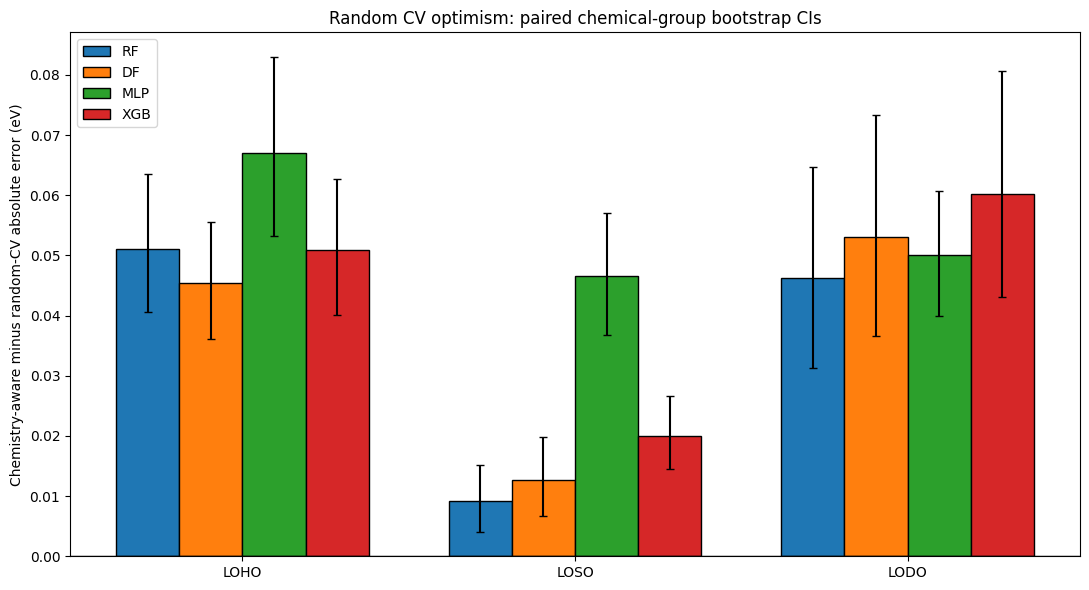

Positive differences indicate that random CV is more optimistic than the chemistry-aware protocol.


In [ ]:
print('=' * 55); print('STEP 17 — XGBOOST ALL PROTOCOLS + FORMAL RANDOM-vs-CHEMISTRY COMPARISON'); print('=' * 55)
from sklearn.model_selection import KFold
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
_p = f'{SAVE_DIR}/Database.csv'
_db = pd.read_csv(_p)
doped_labels = _db['Doped'].astype(str).values
VERSION = 'fold_fitted_fixed_hp_v3_5'
N = len(y_barrier)

def _new_xgb():
    return {'version': VERSION, 'hyperparameter_policy': 'prespecified fixed; no inner-CV tuning',
            '_complete': False,
            **{p: {'rows': [], '_done': [], '_complete': False,
                   'oof_pred': np.full(N, np.nan), 'oof_group': np.full(N, '', dtype=object)}
               for p in ['5fold','LOHO','LOSO','LODO']}}

def _valid_xgb(obj):
    if not isinstance(obj, dict) or obj.get('version') != VERSION:
        return False
    for p in ['5fold','LOHO','LOSO','LODO']:
        s = obj.get(p, {})
        if len(np.asarray(s.get('oof_pred', []))) != N or len(np.asarray(s.get('oof_group', []))) != N:
            return False
    return True

results_xgb = load_checkpoint('results_xgb_fully_nested_safe')
if not _valid_xgb(results_xgb):
    if results_xgb is not None:
        print('  Existing XGBoost checkpoint lacks aligned OOF predictions; rebuilding.')
    results_xgb = _new_xgb()

def _xgb_row(protocol, group, seed, fold, tr, te, pred, nfeat):
    ytr, yte = y_barrier[tr], y_barrier[te]
    gm = compute_group_metrics(yte, pred, group, float(ytr.mean()))
    return {'protocol': protocol, 'group': str(group), 'seed': int(seed), 'fold': int(fold),
            'n_train': int(np.sum(tr) if getattr(tr, 'dtype', None) == bool else len(tr)),
            'n_test': int(len(yte)), 'target_variance': gm['target_var'],
            'selected_feature_count': int(nfeat), 'R2': gm['R2'], 'MAE': gm['MAE'],
            'RMSE': gm['RMSE'], 'baseline_MAE': gm.get('baseline_MAE'),
            'baseline_RMSE': gm.get('baseline_RMSE'), 'MAE_skill': gm.get('MAE_skill'),
            'RMSE_skill': gm.get('RMSE_skill'), 'hyperparameter_policy': 'prespecified fixed'}

sect = results_xgb['5fold']
for fold, (tr, te) in enumerate(KFold(5, shuffle=True, random_state=SEED).split(X_pre_df)):
    key = str(fold)
    if key in sect['_done']:
        continue
    prep = LeakageSafePreprocessor(numeric_names, cat_names, original_feature_set).fit(
        X_pre_df.iloc[tr], y_barrier[tr])
    Xtr = prep.transform(X_pre_df.iloc[tr]); Xte = prep.transform(X_pre_df.iloc[te])
    pred = make_xgb(SEED).fit(Xtr, y_barrier[tr]).predict(Xte)
    sect['rows'].append(_xgb_row('5fold', f'fold{fold+1}', SEED, fold, tr, te, pred, Xtr.shape[1]))
    sect['oof_pred'][te] = pred; sect['oof_group'][te] = f'fold{fold+1}'
    sect['_done'].append(key); save_checkpoint(results_xgb, 'results_xgb_fully_nested_safe')
sect['_complete'] = bool(
    set(sect['_done']) == {str(i) for i in range(5)}
    and len(sect['rows']) == 5
    and np.isfinite(np.asarray(sect['oof_pred'], dtype=float)).all()
)

def run_xgb_group(tag, labels):
    labels = np.asarray(labels).astype(str)
    sect = results_xgb[tag]; groups = list(np.unique(labels))
    for i, g in enumerate(groups):
        sg = str(g)
        if sg in sect['_done']:
            continue
        tr = labels != g; te = labels == g
        prep = LeakageSafePreprocessor(numeric_names, cat_names, original_feature_set).fit(
            X_pre_df.loc[tr], y_barrier[tr])
        Xtr = prep.transform(X_pre_df.loc[tr]); Xte = prep.transform(X_pre_df.loc[te])
        pred = make_xgb(SEED).fit(Xtr, y_barrier[tr]).predict(Xte)
        sect['rows'].append(_xgb_row(tag, sg, SEED, -1, tr, te, pred, Xtr.shape[1]))
        sect['oof_pred'][te] = pred; sect['oof_group'][te] = sg
        sect['_done'].append(sg); save_checkpoint(results_xgb, 'results_xgb_fully_nested_safe')
        rr = sect['rows'][-1]['R2']
        print(f'  {tag}[{i+1}/{len(groups)}] {sg:>8} R2={"undef(NaN)" if pd.isna(rr) else f"{rr:.3f}"}')
    sect['_complete'] = bool(
        set(sect['_done']) == {str(g) for g in groups}
        and len(sect['rows']) == len(groups)
        and np.isfinite(np.asarray(sect['oof_pred'], dtype=float)).all()
    )

run_xgb_group('LOHO', host_labels)
run_xgb_group('LOSO', surface_labels)
run_xgb_group('LODO', doped_labels)
results_xgb['_complete'] = all(results_xgb[p]['_complete'] for p in ['5fold','LOHO','LOSO','LODO'])
save_checkpoint(results_xgb, 'results_xgb_fully_nested_safe')
if not results_xgb['_complete']:
    raise RuntimeError('XGBoost protocol checkpoint incomplete.')

# Formal comparison of random five-fold OOF error against chemistry-aware OOF error.
# The same labelled sample is compared under both protocols. Inference resamples/sign-flips
# whole held-out chemical groups, never unrelated fold means.
parity = require_checkpoint('parity_5f_fully_nested_safe')
loho = require_checkpoint('results_loho_fully_nested_safe')
loso = require_checkpoint('results_loso_fully_nested_safe')
lodo = require_checkpoint('results_lodo_fully_nested_safe')
model_random = {
    'RF': np.asarray(parity['RF']['pred'], float),
    'DF': np.asarray(parity['DF']['pred'], float),
    'MLP': np.asarray(parity['MLP']['pred'], float),
    'XGB': np.asarray(results_xgb['5fold']['oof_pred'], float),
}
group_sources = {'LOHO': (loho, np.asarray(host_labels).astype(str)),
                 'LOSO': (loso, np.asarray(surface_labels).astype(str)),
                 'LODO': (lodo, np.asarray(doped_labels).astype(str))}
model_group = {}
for proto, (obj, labels) in group_sources.items():
    model_group[proto] = {
        'RF': np.asarray(obj['oof']['RF']['pred'], float),
        'DF': np.asarray(obj['oof']['DF']['pred'], float),
        'MLP': np.asarray(obj['oof']['MLP']['pred'], float),
        'XGB': np.asarray(results_xgb[proto]['oof_pred'], float),
    }

def _cluster_test(random_pred, group_pred, labels, model, protocol, metric, n_boot=10000):
    valid = np.isfinite(random_pred) & np.isfinite(group_pred) & np.isfinite(y_barrier)
    yt = np.asarray(y_barrier, float)[valid]; rp = random_pred[valid]; gp = group_pred[valid]
    lab = np.asarray(labels)[valid].astype(str)
    if metric == 'absolute_error':
        random_error = np.abs(rp - yt); chemistry_error = np.abs(gp - yt); unit = 'eV'
    else:
        random_error = (rp - yt) ** 2; chemistry_error = (gp - yt) ** 2; unit = 'eV^2'
    delta = chemistry_error - random_error
    cdf = pd.DataFrame({'cluster': lab, 'delta': delta}).groupby('cluster', as_index=False)['delta'].mean()
    vals = cdf['delta'].to_numpy(float); n_cluster = len(vals)
    if n_cluster < 2:
        return None, pd.DataFrame()
    rng = np.random.RandomState(SEED + sum(map(ord, model + protocol + metric)))
    idx = rng.randint(0, n_cluster, size=(n_boot, n_cluster))
    boot = vals[idx].mean(axis=1)
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
    effect = float(vals.mean())
    if n_cluster <= 15:
        # Exact cluster-level sign-flip distribution for small group counts (e.g. LOSO).
        grids = np.arange(2 ** n_cluster, dtype=np.uint64)[:, None]
        bits = ((grids >> np.arange(n_cluster, dtype=np.uint64)) & 1).astype(float)
        signs = 2.0 * bits - 1.0
        perm = (signs * vals).mean(axis=1)
        p = float(np.mean(np.abs(perm) >= abs(effect)))
        test_method = f'exact cluster sign-flip permutation; {2 ** n_cluster} sign patterns'
    else:
        signs = rng.choice([-1.0, 1.0], size=(n_boot, n_cluster))
        perm = (signs * vals).mean(axis=1)
        p = float((1 + np.sum(np.abs(perm) >= abs(effect))) / (n_boot + 1))
        test_method = f'Monte Carlo cluster sign-flip permutation; {n_boot} draws'
    summary = {'model': model, 'protocol': protocol, 'metric': metric, 'unit': unit,
        'n_samples': int(valid.sum()), 'n_clusters': int(n_cluster),
        'mean_sample_paired_difference': float(np.mean(delta)),
        'mean_cluster_paired_difference': effect,
        'median_cluster_paired_difference': float(np.median(vals)),
        'CI_low': float(ci_low), 'CI_high': float(ci_high),
        'raw_p_value': p,
        'test_method': test_method,
        'CI_method': f'paired cluster bootstrap; {n_boot} resamples',
        'positive_difference_means': 'chemistry-aware error exceeds random-CV error'}
    sample = pd.DataFrame({'model': model, 'protocol': protocol, 'cluster': lab,
                           'sample_index': np.flatnonzero(valid), 'metric': metric, 'unit': unit,
                           'paired_error_difference': delta,
                           'random_error': random_error, 'chemistry_aware_error': chemistry_error})
    return summary, sample

test_rows = []; sample_frames = []
for model in ['RF','DF','MLP','XGB']:
    for proto, (_, labels) in group_sources.items():
        for metric in ['absolute_error','squared_error']:
            row, sdf = _cluster_test(model_random[model], model_group[proto][model], labels,
                                     model, proto, metric)
            if row is not None:
                test_rows.append(row); sample_frames.append(sdf)
tests = pd.DataFrame(test_rows)
tests['adjusted_p_value'] = np.nan
for metric, idxs in tests.groupby('metric').groups.items():
    # Family-wise Holm correction across all 4 models x 3 chemistry-aware protocols
    # within the same error metric.
    order = tests.loc[list(idxs)].sort_values('raw_p_value'); m = len(order); prev = 0.0
    for rank, (idx_row, rr) in enumerate(order.iterrows()):
        adj = max(prev, min(1.0, (m-rank) * rr['raw_p_value'])); prev = adj
        tests.loc[idx_row, 'adjusted_p_value'] = adj
tests['multiplicity_correction'] = 'Holm within metric across all model-protocol comparisons'
sample_errors = pd.concat(sample_frames, ignore_index=True)
comparison = {'version': VERSION, '_complete': True, 'rows': tests,
              'n_samples': int(N), 'models': ['RF','DF','MLP','XGB'],
              'protocols': ['LOHO','LOSO','LODO']}
save_checkpoint(comparison, 'random_vs_chemistry_protocol_comparison_safe')
save_csv(tests, 'random_vs_chemistry_protocol_tests_safe')
save_csv(sample_errors, 'random_vs_chemistry_sample_errors_safe')
print('\nFORMAL RANDOM-vs-CHEMISTRY-AWARE OOF COMPARISON:')
print(tests[['model','protocol','metric','mean_cluster_paired_difference','CI_low','CI_high',
             'raw_p_value','adjusted_p_value']].to_string(index=False))

plot = tests[tests['metric']=='absolute_error'].copy()
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(3); width = 0.19
for j, model in enumerate(['RF','DF','MLP','XGB']):
    p = plot[plot.model==model].set_index('protocol').loc[['LOHO','LOSO','LODO']]
    y = p['mean_cluster_paired_difference'].to_numpy()
    yerr = np.vstack([y-p['CI_low'].to_numpy(), p['CI_high'].to_numpy()-y])
    ax.bar(x+(j-1.5)*width, y, width, yerr=yerr, capsize=3, label=model, edgecolor='k')
ax.axhline(0, color='k', linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(['LOHO','LOSO','LODO'])
ax.set_ylabel('Chemistry-aware minus random-CV absolute error (eV)')
ax.set_title('Random CV optimism: paired chemical-group bootstrap CIs')
ax.legend(); plt.tight_layout()
save_figure(fig, 'random_vs_chemistry_protocol_gap_safe'); plt.show()
print('Positive differences indicate that random CV is more optimistic than the chemistry-aware protocol.')


## Step 18 — Leave-one-family-out with strict versioned completeness  [REVISED]


STEP 18 — LEAVE-ONE-CHEMICAL-FAMILY-OUT (STRICT VERSIONED COMPLETENESS)
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: family_out_results_fully_nested_safe
  ✓ Checkpoint saved: family_out_results_fully_nested_safe
  ✓ CSV + fingerprint sidecar saved: family_out_results_fully_nested_safe.csv
  ✓ CSV + fingerprint sidecar saved: family_out_skipped_units_safe.csv

FAMILY-OUT (fold-fitted / held-out-isolated):
family_type                  family                            key  seed  n_train  n_test  target_variance  selected_feature_count   RF_R2  RF_MAE  RF_RMSE  RF_MAE_skill   DF_R2  DF_MAE  DF_RMSE  DF_MAE_skill  baseline_MAE  baseline_RMSE
     Dopant Early transition metals Dopant|Early transition metals    42     7665    3285         0.046707                     142 0.61149 0.09666  0.13471       0.46341 0.69255 0.08545  0.11983       0.52564       0.18014        0.22551
     Dopant  Late transition metals  Dopant|Late transition metals    42     7300    3650

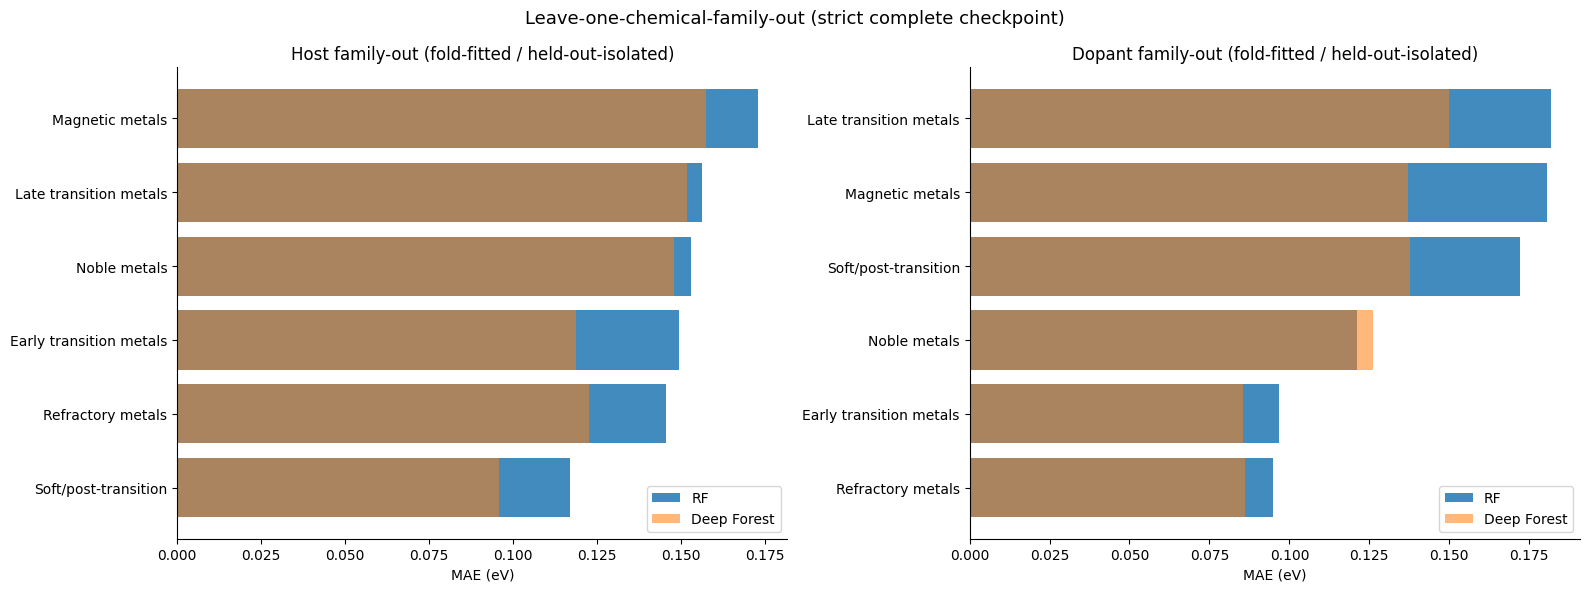

In [ ]:
print('=' * 55); print('STEP 18 — LEAVE-ONE-CHEMICAL-FAMILY-OUT (STRICT VERSIONED COMPLETENESS)'); print('=' * 55)
from sklearn.metrics import mean_absolute_error, mean_squared_error
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
_p = f'{SAVE_DIR}/Database.csv'
doped_labels = pd.read_csv(_p)['Doped'].astype(str).values if os.path.exists(_p) else None
host_family_labels = np.asarray(host_labels).astype(str)
VERSION = 'family_out_strict_v3_8'
families = {
    'Early transition metals': ['Sc','Ti','V','Cr','Y','Zr','Nb','Hf','Ta'],
    'Late transition metals':  ['Co','Ni','Cu','Zn','Rh','Pd','Ag','Ir','Pt','Au'],
    'Noble metals':            ['Ru','Rh','Pd','Ag','Os','Ir','Pt','Au'],
    'Refractory metals':       ['Mo','W','Re','Ta','Nb','Hf','Zr','Ti','V','Cr'],
    'Magnetic metals':         ['Fe','Co','Ni','Mn'],
    'Soft/post-transition':    ['Cd','Hg','Zn','In','Sn'],
}
sources = [('Host', host_family_labels)] + ([('Dopant', doped_labels)] if doped_labels is not None else [])

unit_specs = []
skipped_units = []
for family_type, label_arr in sources:
    label_arr = np.asarray(label_arr).astype(str)
    for fname, members in families.items():
        key = f'{family_type}|{fname}'
        in_fam = np.isin(label_arr, members)
        if in_fam.sum() == 0 or (~in_fam).sum() == 0:
            skipped_units.append({
                'key': key, 'family_type': family_type, 'family': fname,
                'reason': 'empty test or empty training partition',
                'n_test': int(in_fam.sum()), 'n_train': int((~in_fam).sum())
            })
        else:
            unit_specs.append((key, family_type, fname, ~in_fam, in_fam))

expected_keys = {u[0] for u in unit_specs}

def _new_family_checkpoint():
    return {
        'version': VERSION,
        'expected_keys': sorted(expected_keys),
        'skipped_units': skipped_units,
        'rows': [],
        '_done': [],
        '_complete': False,
    }

fam = load_checkpoint('family_out_results_fully_nested_safe')
if (
    not isinstance(fam, dict)
    or fam.get('version') != VERSION
    or set(fam.get('expected_keys', [])) != expected_keys
):
    fam = _new_family_checkpoint()

# Keep only complete, unique units. A stale/partial row is rerun.
rows = fam.get('rows', []) if isinstance(fam.get('rows'), list) else []
done = fam.get('_done', []) if isinstance(fam.get('_done'), list) else []
clean_rows, clean_done = [], []
for key in sorted(set(done) & expected_keys):
    family_type, fname = key.split('|', 1)
    rr = [
        r for r in rows if isinstance(r, dict)
        and r.get('family_type') == family_type and r.get('family') == fname
    ]
    valid = (
        len(rr) == 1
        and int(rr[0].get('n_train', 0)) > 0
        and int(rr[0].get('n_test', 0)) > 0
        and int(rr[0].get('seed', -1)) == int(SEED)
        and all(k in rr[0] for k in [
            'RF_R2','RF_MAE','RF_RMSE','DF_R2','DF_MAE','DF_RMSE',
            'baseline_MAE','baseline_RMSE','selected_feature_count'
        ])
    )
    if valid:
        clean_rows.extend(rr)
        clean_done.append(key)
    else:
        print(f'  Family-out unit {key} is partial/incompatible and will be recomputed.')
fam['rows'] = clean_rows
fam['_done'] = clean_done
fam['_complete'] = False

spec_by_key = {u[0]: u for u in unit_specs}
for key in sorted(expected_keys):
    if key in fam['_done']:
        continue
    _, family_type, fname, tr, te = spec_by_key[key]
    prep = LeakageSafePreprocessor(
        numeric_names, cat_names, original_feature_set
    ).fit(X_pre_df.loc[tr], y_barrier[tr])
    Xtr = prep.transform(X_pre_df.loc[tr])
    Xte = prep.transform(X_pre_df.loc[te])
    ytr, yte = y_barrier[tr], y_barrier[te]
    base = float(ytr.mean())
    var = float(np.var(yte))

    rf_model = make_rf(SEED).fit(Xtr, ytr)
    rf_m = compute_group_metrics(yte, rf_model.predict(Xte), fname, base)

    df_model = make_df(SEED)
    df_model.fit(Xtr, ytr, verbose=False)
    df_m = compute_group_metrics(yte, df_model.predict(Xte), fname, base)

    fam['rows'].append({
        'family_type': family_type,
        'family': fname,
        'key': key,
        'seed': int(SEED),
        'n_train': int(tr.sum()),
        'n_test': int(te.sum()),
        'target_variance': round(var, 6),
        'selected_feature_count': int(Xtr.shape[1]),
        'RF_R2': rf_m['R2'], 'RF_MAE': rf_m['MAE'], 'RF_RMSE': rf_m['RMSE'],
        'RF_MAE_skill': rf_m.get('MAE_skill'),
        'DF_R2': df_m['R2'], 'DF_MAE': df_m['MAE'], 'DF_RMSE': df_m['RMSE'],
        'DF_MAE_skill': df_m.get('MAE_skill'),
        'baseline_MAE': rf_m.get('baseline_MAE'),
        'baseline_RMSE': rf_m.get('baseline_RMSE'),
    })
    fam['_done'].append(key)
    save_checkpoint(fam, 'family_out_results_fully_nested_safe')
    _r2 = (
        'undef(NaN)' if rf_m['R2'] is None
        or (isinstance(rf_m['R2'], float) and np.isnan(rf_m['R2']))
        else f"{rf_m['R2']:.3f}"
    )
    print(
        f'  {family_type:8s} {fname:26s} n_test={te.sum():5d} '
        f'RF R2={_r2} MAE={rf_m["MAE"]:.4f}'
    )

family_df = pd.DataFrame(fam['rows'])
fam['_complete'] = (
    set(fam['_done']) == expected_keys
    and len(fam['_done']) == len(expected_keys)
    and len(family_df) == len(expected_keys)
    and family_df.duplicated(['family_type', 'family']).sum() == 0
    and set(family_df['key']) == expected_keys
)
save_checkpoint(fam, 'family_out_results_fully_nested_safe')
if not fam['_complete']:
    raise RuntimeError('Family-out checkpoint incomplete or internally inconsistent.')

save_csv(family_df, 'family_out_results_fully_nested_safe')
save_csv(pd.DataFrame(skipped_units), 'family_out_skipped_units_safe')
print('\nFAMILY-OUT (fold-fitted / held-out-isolated):')
print(family_df.to_string(index=False))

fig, axes = plt.subplots(1, len(sources), figsize=(8 * len(sources), 6), squeeze=False)
for ax, (ftype, _) in zip(axes[0], sources):
    sub = family_df[family_df['family_type'] == ftype].sort_values('RF_MAE')
    ax.barh(sub['family'], sub['RF_MAE'], alpha=0.85, label='RF')
    ax.barh(sub['family'], sub['DF_MAE'], alpha=0.55, label='Deep Forest')
    ax.set_xlabel('MAE (eV)')
    ax.set_title(f'{ftype} family-out (fold-fitted / held-out-isolated)')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.suptitle('Leave-one-chemical-family-out (strict complete checkpoint)', fontsize=13)
plt.tight_layout()
save_figure(fig, 'family_out_results_fully_nested_safe')
plt.show()


## Step 19 — Host–dopant pair group-out validation  [NEW]
Stricter structural split: `GroupKFold` over `Host__Doped` pairs with fold-fitted preprocessing and an explicit zero-overlap assertion (reviewer request 10).


In [ ]:
print('=' * 55); print('STEP 19 — HOST-DOPANT PAIR GROUP-OUT VALIDATION (FOLD-FITTED / HELD-OUT-ISOLATED, RESUMABLE)'); print('=' * 55)
# v3_2 item 4: resumable per fold-model. Loads existing checkpoint, validates version/folds/
# models/group-definition/row-schema; runs only the model-fold combinations not yet in _done;
# never recreates an empty checkpoint or duplicates rows on resume. Zero pair overlap asserted.
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
PAIR_VERSION = 'fully_nested_raw_safe_v3_2'
N_SPLITS = 5; PAIR_MODELS = ['Random Forest', 'XGBoost']; GROUP_DEF = 'Host__Doped'
ROW_KEYS = {'fold', 'model', 'seed', 'n_train', 'n_test', 'pair_overlap', 'R2', 'MAE', 'RMSE'}
_p = f'{SAVE_DIR}/Database.csv'
if not os.path.exists(_p):
    raise FileNotFoundError('Database.csv required to build host-dopant pair groups.')
_dbf = pd.read_csv(_p)
host_arr = _dbf['Host'].astype(str).values; doped_arr = _dbf['Doped'].astype(str).values
pair_group = np.array([f'{h}__{d}' for h, d in zip(host_arr, doped_arr)])
print(f'  unique host-dopant pairs: {len(np.unique(pair_group))}')
def _fresh_pair():
    return {'version': PAIR_VERSION, 'n_splits': N_SPLITS, 'models': list(PAIR_MODELS),
            'group_definition': GROUP_DEF, 'rows': [], '_done': [], '_complete': False}
def _compatible(ck):
    if not isinstance(ck, dict): return False
    if ck.get('version') != PAIR_VERSION: return False
    if ck.get('n_splits') != N_SPLITS: return False
    if list(ck.get('models', [])) != PAIR_MODELS: return False
    if ck.get('group_definition') != GROUP_DEF: return False
    for r in ck.get('rows', []):
        if not ROW_KEYS.issubset(set(r)): return False
    return True
pair = load_checkpoint('pair_groupkfold_fully_nested_safe')
if not _compatible(pair):
    if pair is not None:
        print('  Existing pair checkpoint incompatible with v3_2 — reinitializing (not merged).')
    pair = _fresh_pair()
_factory = {'Random Forest': lambda: make_rf(SEED), 'XGBoost': lambda: make_xgb(SEED)}
gkf = GroupKFold(n_splits=N_SPLITS)
splits = list(gkf.split(X_pre_df, y_barrier, groups=pair_group))
expected_combos = {f'fold{f}|{m}' for f in range(N_SPLITS) for m in PAIR_MODELS}

# Repair resumable state: retain a key only when it has exactly one compatible row.
_existing_done = set(pair.get('_done', []))
_rows_by_key = {}
for _row in pair.get('rows', []):
    if not isinstance(_row, dict) or not ROW_KEYS.issubset(set(_row)):
        continue
    try:
        _key = f"fold{int(_row['fold'])}|{_row['model']}"
        _valid_row = (
            _key in expected_combos
            and int(_row.get('seed', -1)) == int(SEED)
            and int(_row.get('pair_overlap', -1)) == 0
        )
    except (TypeError, ValueError):
        _valid_row = False
        _key = None
    if _valid_row:
        _rows_by_key.setdefault(_key, []).append(_row)

_clean_rows, _clean_done = [], []
for _key in sorted(expected_combos):
    _matches = _rows_by_key.get(_key, [])
    if _key in _existing_done and len(_matches) == 1:
        _clean_rows.append(_matches[0])
        _clean_done.append(_key)
    elif _key in _existing_done:
        print(f'  Pair checkpoint entry {_key} is incomplete/duplicated and will be recomputed.')

pair['rows'] = _clean_rows
pair['_done'] = _clean_done
pair['_complete'] = False

for f, (tr, te) in enumerate(splits):
    train_pairs = set(pair_group[tr]); test_pairs = set(pair_group[te]); overlap = train_pairs & test_pairs
    assert len(overlap) == 0, f'pair leakage in fold {f}: {overlap}'
    prep = None
    for model in PAIR_MODELS:
        key = f'fold{f}|{model}'
        if key in pair['_done']: continue
        if prep is None:
            prep = LeakageSafePreprocessor(numeric_names, cat_names, original_feature_set).fit(X_pre_df.iloc[tr], y_barrier[tr])
            Xtr, Xte = prep.transform(X_pre_df.iloc[tr]), prep.transform(X_pre_df.iloc[te])
            ytr, yte = y_barrier[tr], y_barrier[te]; base = float(ytr.mean())
        m = compute_group_metrics(yte, _factory[model]().fit(Xtr, ytr).predict(Xte), f'fold{f+1}', base)
        pair['rows'].append({'fold': int(f), 'model': model, 'seed': int(SEED), 'n_train': int(len(tr)),
            'n_test': int(len(te)), 'n_train_pairs': len(train_pairs), 'n_test_pairs': len(test_pairs),
            'pair_overlap': len(overlap), 'target_variance': m['target_var'],
            'selected_feature_count': int(Xtr.shape[1]), 'R2': m['R2'], 'MAE': m['MAE'], 'RMSE': m['RMSE'],
            'baseline_MAE': m.get('baseline_MAE'), 'baseline_RMSE': m.get('baseline_RMSE'),
            'MAE_skill': m.get('MAE_skill'), 'RMSE_skill': m.get('RMSE_skill')})
        pair['_done'].append(key); save_checkpoint(pair, 'pair_groupkfold_fully_nested_safe')
        print(f'  {key}: train_pairs={len(train_pairs)} test_pairs={len(test_pairs)} overlap={len(overlap)}')
pair_df = pd.DataFrame(pair['rows']).sort_values(['fold', 'model']).reset_index(drop=True)
observed_combos = {
    f"fold{int(row['fold'])}|{row['model']}"
    for _, row in pair_df.iterrows()
}
pair['_complete'] = bool(
    set(pair['_done']) == expected_combos
    and len(pair['_done']) == len(expected_combos)
    and len(pair_df) == len(expected_combos)
    and observed_combos == expected_combos
    and pair_df.duplicated(['fold', 'model']).sum() == 0
    and (pair_df['pair_overlap'].astype(int) == 0).all()
)
save_checkpoint(pair, 'pair_groupkfold_fully_nested_safe')
if not pair['_complete']:
    raise RuntimeError('Host-dopant pair checkpoint is incomplete or inconsistent.')
save_csv(pair_df, 'pair_groupkfold_safe')
print('\nHOST-DOPANT PAIR GROUP-OUT (10/10 combos, zero-overlap, no duplicates):')
print(pair_df.groupby('model')[['R2', 'MAE', 'RMSE', 'MAE_skill']].mean().round(4).to_string())


STEP 19 — HOST-DOPANT PAIR GROUP-OUT VALIDATION (FOLD-FITTED / HELD-OUT-ISOLATED, RESUMABLE)
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  unique host-dopant pairs: 900
  ✓ Checkpoint loaded: pair_groupkfold_fully_nested_safe
  ✓ Checkpoint saved: pair_groupkfold_fully_nested_safe
  ✓ CSV + fingerprint sidecar saved: pair_groupkfold_safe.csv

HOST-DOPANT PAIR GROUP-OUT (10/10 combos, zero-overlap, no duplicates):
                   R2     MAE    RMSE  MAE_skill
model                                           
Random Forest  0.9424  0.0592  0.0840     0.7890
XGBoost        0.9801  0.0349  0.0495     0.8756


## Step 20 — Physics-guided baselines with strict versioned completeness  [REVISED]


In [ ]:
print('=' * 55); print('STEP 20 — PHYSICS-INSPIRED BASELINES (STRICT VERSIONED COMPLETENESS)'); print('=' * 55)
# Four methods (empirical auxiliary linear prior / Random Forest / BEP-inspired Delta-ML /
# Conventional MLP) under identical 5-fold/LOHO/LOSO/LODO outer partitions.
# Everything, including preprocessing and the empirical prior, is fitted on outer training only.
# PGNN is added in Step 22; the complete five-method summary is built in Step 23.
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
_p = f'{SAVE_DIR}/Database.csv'
doped_labels = pd.read_csv(_p)['Doped'].astype(str).values if os.path.exists(_p) else None
VERSION = 'physics_groupout_strict_v3_8'
BEP_CANDS = [
    'delta_d_band', 'delta_cohesive', 'delta_surface_energy',
    'delta_electroneg', 'doped_weighted_surface_energy', 'doped_d-band_center'
]
PHYS_MODELS = [
    'Empirical auxiliary linear prior',
    'Random Forest',
    'BEP-inspired Delta-ML',
    'Conventional MLP',
]

def _eval_split(tr, te, group, protocol):
    Xtr_df = X_pre_df.loc[tr] if getattr(tr, 'dtype', None) == bool else X_pre_df.iloc[tr]
    Xte_df = X_pre_df.loc[te] if getattr(te, 'dtype', None) == bool else X_pre_df.iloc[te]
    ytr = y_barrier[tr]
    yte = y_barrier[te]

    prep = LeakageSafePreprocessor(
        numeric_names, cat_names, original_feature_set
    ).fit(Xtr_df, ytr)
    Xtr = prep.transform(Xtr_df)
    Xte = prep.transform(Xte_df)
    base = float(ytr.mean())

    bep_idx = [prep.kept_cols.index(f) for f in BEP_CANDS if f in prep.kept_cols] or [0]
    out = []

    def rec(model, pred):
        gm = compute_group_metrics(yte, pred, group, base)
        out.append({
            'model': model,
            'protocol': protocol,
            'group': str(group),
            'key': f'{protocol}|{group}',
            'seed': int(SEED),
            'n_train': int(len(ytr)),
            'n_test': int(len(yte)),
            'target_variance': gm['target_var'],
            'selected_feature_count': int(Xtr.shape[1]),
            'R2': gm['R2'], 'MAE': gm['MAE'], 'RMSE': gm['RMSE'],
            'baseline_MAE': gm.get('baseline_MAE'),
            'baseline_RMSE': gm.get('baseline_RMSE'),
            'MAE_skill': gm.get('MAE_skill'),
            'RMSE_skill': gm.get('RMSE_skill'),
        })

    sc = StandardScaler().fit(Xtr[:, bep_idx])
    prior = Ridge(alpha=1.0).fit(sc.transform(Xtr[:, bep_idx]), ytr)
    prior_tr = prior.predict(sc.transform(Xtr[:, bep_idx]))
    prior_te = prior.predict(sc.transform(Xte[:, bep_idx]))

    rec('Empirical auxiliary linear prior', prior_te)
    rec('Random Forest', make_rf(SEED).fit(Xtr, ytr).predict(Xte))
    rf_delta = make_rf(SEED).fit(Xtr, ytr - prior_tr)
    rec('BEP-inspired Delta-ML', prior_te + rf_delta.predict(Xte))
    rec('Conventional MLP', make_mlp(SEED).fit(Xtr, ytr).predict(Xte))
    return out

# Build exact protocol/group units independently of any checkpoint.
protocol_units = []
kf_pairs = list(KFold(5, shuffle=True, random_state=SEED).split(X_pre_df))
for i, (tr, te) in enumerate(kf_pairs):
    protocol_units.append(('5fold', f'fold{i + 1}', tr, te))
for g in np.unique(np.asarray(host_labels).astype(str)):
    lab = np.asarray(host_labels).astype(str)
    protocol_units.append(('LOHO', str(g), lab != g, lab == g))
for g in np.unique(np.asarray(surface_labels).astype(str)):
    lab = np.asarray(surface_labels).astype(str)
    protocol_units.append(('LOSO', str(g), lab != g, lab == g))
if doped_labels is not None:
    for g in np.unique(doped_labels):
        protocol_units.append(('LODO', str(g), doped_labels != g, doped_labels == g))

expected_keys = {f'{p}|{g}' for p, g, _, _ in protocol_units}
expected_groups = {}
for p, g, _, _ in protocol_units:
    expected_groups.setdefault(p, []).append(str(g))

def _new_phys_checkpoint():
    return {
        'version': VERSION,
        'models': list(PHYS_MODELS),
        'expected_keys': sorted(expected_keys),
        'expected_groups': {k: sorted(v) for k, v in expected_groups.items()},
        'rows': [],
        '_done': [],
        '_complete': False,
    }

phys = load_checkpoint('physics_baselines_groupout_fully_safe')
if (
    not isinstance(phys, dict)
    or phys.get('version') != VERSION
    or set(phys.get('expected_keys', [])) != expected_keys
    or set(phys.get('models', [])) != set(PHYS_MODELS)
):
    phys = _new_phys_checkpoint()

# Repair at the protocol-group unit. A reusable unit must contain exactly four unique model rows.
rows = phys.get('rows', []) if isinstance(phys.get('rows'), list) else []
done = phys.get('_done', []) if isinstance(phys.get('_done'), list) else []
clean_rows, clean_done = [], []
for key in sorted(set(done) & expected_keys):
    p, g = key.split('|', 1)
    rr = [
        r for r in rows if isinstance(r, dict)
        and r.get('protocol') == p and str(r.get('group')) == g
    ]
    valid = (
        len(rr) == len(PHYS_MODELS)
        and set(r.get('model') for r in rr) == set(PHYS_MODELS)
        and len({r.get('model') for r in rr}) == len(PHYS_MODELS)
        and all(int(r.get('n_train', 0)) > 0 and int(r.get('n_test', 0)) > 0 for r in rr)
    )
    if valid:
        clean_done.append(key)
        clean_rows.extend(rr)
    else:
        print(f'  Physics unit {key} is partial/incompatible and will be recomputed.')
phys['rows'] = clean_rows
phys['_done'] = clean_done
phys['_complete'] = False

for protocol, group, tr, te in protocol_units:
    key = f'{protocol}|{group}'
    if key in phys['_done']:
        continue
    unit_rows = _eval_split(tr, te, group, protocol)
    if len(unit_rows) != len(PHYS_MODELS):
        raise RuntimeError(f'Physics unit {key} did not produce all expected models.')
    phys['rows'].extend(unit_rows)
    phys['_done'].append(key)
    save_checkpoint(phys, 'physics_baselines_groupout_fully_safe')
    print(f'  {key} done')

phys_df = pd.DataFrame(phys['rows'])
phys['_complete'] = (
    set(phys['_done']) == expected_keys
    and len(phys['_done']) == len(expected_keys)
    and len(phys_df) == len(expected_keys) * len(PHYS_MODELS)
    and phys_df.duplicated(['protocol', 'group', 'model']).sum() == 0
    and set(phys_df['model']) == set(PHYS_MODELS)
)
save_checkpoint(phys, 'physics_baselines_groupout_fully_safe')
if not phys['_complete']:
    raise RuntimeError('Physics-baseline checkpoint incomplete or internally inconsistent.')

save_csv(phys_df, 'physics_baselines_groupout_safe')
_prov = (
    phys_df.assign(R2n=phys_df['R2'].astype(float))
    .groupby(['protocol', 'model'])['R2n']
    .apply(lambda s: round(np.nanmean(s), 4))
    .reset_index()
    .rename(columns={'R2n': 'mean_R2'})
)
print('\nFOUR-METHOD comparison (mean R2 by protocol; PGNN added after Step 22):')
print(_prov.pivot(index='protocol', columns='model', values='mean_R2').to_string())


STEP 20 — PHYSICS-INSPIRED BASELINES (STRICT VERSIONED COMPLETENESS)
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: physics_baselines_groupout_fully_safe
  ✓ Checkpoint saved: physics_baselines_groupout_fully_safe
  ✓ CSV + fingerprint sidecar saved: physics_baselines_groupout_safe.csv

FOUR-METHOD comparison (mean R2 by protocol; PGNN added after Step 22):
model     BEP-inspired Delta-ML  Conventional MLP  Empirical auxiliary linear prior  Random Forest
protocol                                                                                          
5fold                    0.9616            0.9802                            0.5499         0.9644
LODO                     0.7047            0.7363                           -0.0641         0.6740
LOHO                     0.6860            0.7916                            0.3018         0.7728
LOSO                     0.9415            0.9088                            0.5473         0.9470


## Step 21 — Active learning: multi-acquisition × multi-seed  [REVISED]


In [ ]:
print('=' * 55); print('STEP 21 — PRELIMINARY RETROSPECTIVE ACTIVE-LEARNING SIMULATION (LABELLED-ONLY PREPROCESSING, MULTI-SEED)'); print('=' * 55)
# Target-dependent preprocessing/feature-selection refit at EVERY iteration using ONLY the
# currently labeled samples (raw pool in). No unlabeled-pool label ever used. PRELIMINARY
# retrospective simulation; no universal acquisition claim. v3_2: versioned, fully resumable
# and auditable checkpoint keyed per acquisition-seed pair.
from sklearn.ensemble import RandomForestRegressor
from scipy import stats
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
N_INIT, N_QUERY, N_ITER = 100, 5, 20
SEEDS = [SEED + i for i in range(5)]
ACQ = ['exploit', 'uncertainty', 'balanced', 'ucb', 'random']
AL_VERSION = 'fully_nested_raw_safe_v3_2'
def _nrm(x):
    x = np.asarray(x, float)
    return (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else np.zeros_like(x)
def _acq_score(mean, std, kind, alpha=0.5, beta=1.0, rng=None):
    exploit = 1 - _nrm(mean); uncert = _nrm(std)
    if kind == 'exploit':     return exploit
    if kind == 'uncertainty': return uncert
    if kind == 'balanced':    return alpha * uncert + (1 - alpha) * exploit
    if kind == 'ucb':         return exploit + beta * uncert
    if kind == 'random':      return rng.random(len(mean))
    raise KeyError(kind)
def _fit_labeled(labeled_idx, seed):
    prep = LeakageSafePreprocessor(numeric_names, cat_names, original_feature_set).fit(
        X_pre_df.iloc[labeled_idx], y_barrier[labeled_idx])
    X_all = prep.transform(X_pre_df)
    rf = RandomForestRegressor(n_estimators=150, max_features='sqrt', min_samples_leaf=2,
        n_jobs=-1, random_state=seed).fit(X_all[labeled_idx], y_barrier[labeled_idx])
    return X_all, rf
def _fresh_al():
    return {'version': AL_VERSION, 'analysis': 'preliminary_retrospective_active_learning',
        'expected_seeds': list(SEEDS), 'expected_acquisitions': list(ACQ), 'n_init': int(N_INIT),
        'n_query': int(N_QUERY), 'n_iter': int(N_ITER), 'curves': {}, 'acquired_indices': {},
        'init_labeled': {}, '_done': [], '_complete': False}
al = load_checkpoint('active_learning_multi_fully_nested_safe')
def _compatible(ck):
    if not isinstance(ck, dict): return False
    if ck.get('version') != AL_VERSION: return False
    if list(ck.get('expected_seeds', [])) != list(SEEDS): return False
    if list(ck.get('expected_acquisitions', [])) != list(ACQ): return False
    if (ck.get('n_init'), ck.get('n_query'), ck.get('n_iter')) != (N_INIT, N_QUERY, N_ITER): return False
    for c in ck.get('curves', {}).values():           # curve schema: list of (n_labeled, best) with N_ITER+1 pts
        if not (isinstance(c, list) and len(c) == N_ITER + 1 and all(len(pt) == 2 for pt in c)): return False
    return True
if al is None or not _compatible(al):
    if al is not None:
        print('  Existing AL checkpoint incompatible with v3_2 schema — NOT merged; initializing corrected checkpoint.')
    al = _fresh_al()
n = len(y_barrier)
for s in SEEDS:
    rng0 = np.random.RandomState(s)
    init = rng0.choice(n, N_INIT, replace=False)
    al['init_labeled'][str(s)] = [int(i) for i in init]       # same initial set for every acq within this seed
    for acq in ACQ:
        key = f'{acq}|{s}'
        if key in al['_done']: continue
        rng = np.random.RandomState(1000 + s); labeled = list(init.copy()); curve = []
        for it in range(N_ITER + 1):
            X_all, rf = _fit_labeled(labeled, s)
            curve.append((N_INIT + it * N_QUERY, float(y_barrier[labeled].min())))
            if it < N_ITER:
                pool = np.setdiff1d(np.arange(n), labeled)
                tree_pred = np.array([t.predict(X_all[pool]) for t in rf.estimators_])
                score = _acq_score(tree_pred.mean(0), tree_pred.std(0), acq, rng=rng)
                pick = pool[np.argsort(score)[::-1][:N_QUERY]]
                labeled += pick.tolist()
                assert len(labeled) == len(set(labeled)), 'duplicate acquisition detected'
        al['curves'][key] = curve; al['acquired_indices'][key] = [int(i) for i in labeled]
        al['_done'].append(key); save_checkpoint(al, 'active_learning_multi_fully_nested_safe')
    print(f'  seed {s} done ({len(ACQ)} acquisition functions)')
expected_keys = {f'{acq}|{s}' for acq in ACQ for s in SEEDS}
al['_complete'] = set(al['_done']) == expected_keys
save_checkpoint(al, 'active_learning_multi_fully_nested_safe')
# ---- audit assertions ----
assert set(al['_done']) == expected_keys, f'missing AL pairs: {expected_keys - set(al["_done"])}'
for key in expected_keys:
    assert len(al['curves'][key]) == N_ITER + 1, f'{key}: curve length != N_ITER+1'
    li = al['acquired_indices'][key]
    assert len(li) == len(set(li)), f'{key}: duplicate acquisition in stored indices'
    s = int(key.split('|')[1])
    assert li[:N_INIT] == al['init_labeled'][str(s)], f'{key}: initial labelled set differs within seed'
for s in SEEDS:                                  # random baseline shares the seed's initial set
    assert al['acquired_indices'][f'random|{s}'][:N_INIT] == al['init_labeled'][str(s)], 'random baseline not paired'
print('  AL audit: all acquisition-seed pairs present, curves complete, initial sets shared, no duplicates.')
iters = [N_INIT + i * N_QUERY for i in range(N_ITER + 1)]
curve_rows = []
for acq in ACQ:
    mat = np.array([[p[1] for p in al['curves'][f'{acq}|{s}']] for s in SEEDS])
    mean_c = mat.mean(0); std_c = mat.std(0); ci = 1.96 * std_c / np.sqrt(len(SEEDS))
    for j, nlab in enumerate(iters):
        curve_rows.append({'acquisition': acq, 'n_labeled': nlab,
            'mean_best_barrier': round(float(mean_c[j]), 5), 'std_best_barrier': round(float(std_c[j]), 5),
            'ci95_halfwidth': round(float(ci[j]), 5)})
save_csv(pd.DataFrame(curve_rows), 'active_learning_curves_safe')
seed_rows = []
for acq in ACQ:
    for s in SEEDS:
        seed_rows.append({'acquisition': acq, 'seed': int(s),
            'final_best_barrier': round(float(al['curves'][f'{acq}|{s}'][-1][1]), 5)})
save_csv(pd.DataFrame(seed_rows), 'active_learning_seed_results_safe')
summary_rows = []
rand_final = {s: al['curves'][f'random|{s}'][-1][1] for s in SEEDS}
for acq in ['exploit', 'uncertainty', 'balanced', 'ucb']:
    diffs = np.array([rand_final[s] - al['curves'][f'{acq}|{s}'][-1][1] for s in SEEDS])
    try:
        _, pw = stats.wilcoxon(diffs) if np.any(diffs != 0) else (np.nan, np.nan)
    except Exception:
        pw = np.nan
    rng = np.random.RandomState(SEED)
    bs = [rng.choice(diffs, len(diffs), replace=True).mean() for _ in range(5000)]
    summary_rows.append({'acquisition': acq, 'n_seeds': len(SEEDS), 'init_labeled': N_INIT,
        'query_batch': N_QUERY, 'budget': N_INIT + N_ITER * N_QUERY,
        'mean_final_diff_vs_random': round(float(diffs.mean()), 5),
        'std_final_diff': round(float(diffs.std(ddof=1)), 5),
        'paired_CI_low': round(float(np.percentile(bs, 2.5)), 5),
        'paired_CI_high': round(float(np.percentile(bs, 97.5)), 5),
        'wilcoxon_p': round(float(pw), 5) if np.isfinite(pw) else np.nan})
al_summary = pd.DataFrame(summary_rows)
save_csv(al_summary, 'active_learning_summary_safe')
print('\nFinal advantage over random (eV; >0 = informed acquisition reached lower barrier):')
print(al_summary[['acquisition', 'mean_final_diff_vs_random', 'std_final_diff',
                  'paired_CI_low', 'paired_CI_high', 'wilcoxon_p']].to_string(index=False))
print('\nInterpretation limited to this specific retrospective design; not a core claim.')


STEP 21 — PRELIMINARY RETROSPECTIVE ACTIVE-LEARNING SIMULATION (LABELLED-ONLY PREPROCESSING, MULTI-SEED)
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: active_learning_multi_fully_nested_safe
  seed 42 done (5 acquisition functions)
  seed 43 done (5 acquisition functions)
  seed 44 done (5 acquisition functions)
  seed 45 done (5 acquisition functions)
  seed 46 done (5 acquisition functions)
  ✓ Checkpoint saved: active_learning_multi_fully_nested_safe
  AL audit: all acquisition-seed pairs present, curves complete, initial sets shared, no duplicates.
  ✓ CSV + fingerprint sidecar saved: active_learning_curves_safe.csv
  ✓ CSV + fingerprint sidecar saved: active_learning_seed_results_safe.csv
  ✓ CSV + fingerprint sidecar saved: active_learning_summary_safe.csv

Final advantage over random (eV; >0 = informed acquisition reached lower barrier):
acquisition  mean_final_diff_vs_random  std_final_diff  paired_CI_low  paired_CI_high  wilcoxon_p
    exploit         

## Step 22 — Strictly nested PGNN under all protocols — BEP-inspired auxiliary penalty  [REVISED]


### Terminology note — PGNN, not PINN
The network is a **physics-guided neural network (PGNN)** with a **BEP-inspired auxiliary linear-prior branch**. The auxiliary branch is descriptor-based and empirical: it does **not** use an independently calculated reaction energy, is **not** a validated BEP relationship, and must **not** be read as proof of a physical BEP mechanism. The full loss is: main supervised prediction loss + auxiliary consistency penalty + non-negative-barrier penalty + auxiliary linear-prior supervised loss.

In [ ]:
print('=' * 55); print('STEP 22 — STRICTLY NESTED PGNN UNDER ALL PROTOCOLS'); print('=' * 55)
# Strict nesting sequence for every outer split:
# 1) split RAW outer-training rows into inner-train/inner-validation;
# 2) fit preprocessing only on raw inner-train and select the epoch on inner-validation;
# 3) refit preprocessing on all raw outer-training rows;
# 4) train a fresh PGNN for the selected number of epochs on all outer-training rows;
# 5) evaluate the untouched outer test exactly once.
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GroupShuffleSplit

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
VERSION = 'pgnn_strict_nested_v3_8'

def _set_all_seeds(seed):
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed(int(seed))
        torch.cuda.manual_seed_all(int(seed))
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
_p = f'{SAVE_DIR}/Database.csv'
doped_labels = pd.read_csv(_p)['Doped'].astype(str).values if os.path.exists(_p) else None
host_pgnn_labels = np.asarray(host_labels).astype(str)
surface_pgnn_labels = np.asarray(surface_labels).astype(str)
N = len(y_barrier)
BEP_CANDS = [
    'delta_d_band', 'delta_cohesive', 'delta_surface_energy',
    'delta_electroneg', 'doped_weighted_surface_energy', 'doped_d-band_center'
]

class PGNN(nn.Module):
    def __init__(self, n_feat, n_bep, hidden=(512, 256, 128)):
        super().__init__()
        layers = []
        d = int(n_feat)
        for u in hidden:
            layers.extend([nn.Linear(d, int(u)), nn.ReLU(), nn.Dropout(0.1)])
            d = int(u)
        layers.append(nn.Linear(d, 1))
        self.main = nn.Sequential(*layers)
        self.prior = nn.Linear(int(n_bep), 1)

    def forward(self, x, x_bep):
        return self.main(x).squeeze(-1), self.prior(x_bep).squeeze(-1)

def pgnn_loss(pred, prior, y, lam_pc, lam_nn, lam_ps):
    mse = nn.MSELoss()
    return (
        mse(pred, y)
        + lam_pc * mse(pred, prior.detach())
        + lam_nn * torch.mean(torch.clamp(-pred, min=0) ** 2)
        + lam_ps * mse(prior, y)
    )

def _raw_inner_split(n_rows, seed, groups=None, val_frac=0.2):
    idx = np.arange(int(n_rows))
    if groups is not None:
        groups = np.asarray(groups).astype(str)
        if len(groups) == len(idx) and len(np.unique(groups)) >= 2:
            splitter = GroupShuffleSplit(
                n_splits=1, test_size=float(val_frac), random_state=int(seed))
            itr, iva = next(splitter.split(idx, groups=groups))
            if len(itr) > 0 and len(iva) > 0:
                return np.asarray(itr), np.asarray(iva), 'group-disjoint inner validation'
    rng = np.random.RandomState(int(seed))
    rng.shuffle(idx)
    n_val = max(1, int(round(float(val_frac) * len(idx))))
    n_val = min(n_val, len(idx) - 1)
    return idx[n_val:], idx[:n_val], 'deterministic random inner validation'

def _tensor(a):
    return torch.tensor(a, dtype=torch.float32, device=device)

def select_pgnn_epoch_from_raw_outer_train(
    X_outer_df, y_outer, seed, inner_groups=None,
    lam_prior_consistency=0.05, lam_nonneg=0.5, lam_prior_sup=1.0,
    max_epochs=300, patience=25
):
    """Select epoch without exposing inner-validation rows to preprocessing fit."""
    _set_all_seeds(seed)
    X_outer_df = X_outer_df.reset_index(drop=True)
    y_outer = np.asarray(y_outer, float)
    itr, iva, split_method = _raw_inner_split(
        len(X_outer_df), seed=seed, groups=inner_groups, val_frac=0.2)

    inner_prep = LeakageSafePreprocessor(
        numeric_names, cat_names, original_feature_set
    ).fit(X_outer_df.iloc[itr], y_outer[itr])
    Xi_tr_raw = inner_prep.transform(X_outer_df.iloc[itr])
    Xi_val_raw = inner_prep.transform(X_outer_df.iloc[iva])

    scaler = StandardScaler().fit(Xi_tr_raw)
    Xi_tr = scaler.transform(Xi_tr_raw)
    Xi_val = scaler.transform(Xi_val_raw)
    bep_idx = [inner_prep.kept_cols.index(f) for f in BEP_CANDS if f in inner_prep.kept_cols] or [0]

    Xi_tr_t = _tensor(Xi_tr)
    Xi_val_t = _tensor(Xi_val)
    yi_tr_t = _tensor(y_outer[itr])
    yi_val_t = _tensor(y_outer[iva])

    loader = DataLoader(
        TensorDataset(Xi_tr_t, Xi_tr_t[:, bep_idx], yi_tr_t),
        batch_size=256,
        shuffle=True,
        generator=torch.Generator().manual_seed(int(seed)),
    )
    net = PGNN(Xi_tr.shape[1], len(bep_idx)).to(device)
    optimizer = optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)

    best_val = np.inf
    best_epoch = -1
    since = 0
    for epoch in range(int(max_epochs)):
        net.train()
        for xb, xbep, yb in loader:
            optimizer.zero_grad()
            pred, prior = net(xb, xbep)
            loss = pgnn_loss(
                pred, prior, yb,
                lam_prior_consistency, lam_nonneg, lam_prior_sup)
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()

        net.eval()
        with torch.no_grad():
            pv, bv = net(Xi_val_t, Xi_val_t[:, bep_idx])
            val_loss = pgnn_loss(
                pv, bv, yi_val_t,
                lam_prior_consistency, lam_nonneg, lam_prior_sup).item()

        if val_loss < best_val - 1e-6:
            best_val = float(val_loss)
            best_epoch = int(epoch)
            since = 0
        else:
            since += 1
            if since >= int(patience):
                break

    if best_epoch < 0:
        best_epoch = 0
    return {
        'selected_epoch': int(best_epoch),
        'epochs_to_refit': int(best_epoch + 1),
        'n_inner_train': int(len(itr)),
        'n_inner_validation': int(len(iva)),
        'inner_selected_feature_count': int(Xi_tr.shape[1]),
        'inner_split_method': split_method,
        'best_inner_validation_loss': float(best_val),
    }

def fit_pgnn_on_full_outer_train(
    X_outer_df, y_outer, X_outer_test_df, epochs, seed,
    lam_prior_consistency=0.05, lam_nonneg=0.5, lam_prior_sup=1.0
):
    """Fresh full-outer-training refit for the epoch count selected above."""
    _set_all_seeds(seed)
    X_outer_df = X_outer_df.reset_index(drop=True)
    X_outer_test_df = X_outer_test_df.reset_index(drop=True)
    y_outer = np.asarray(y_outer, float)

    outer_prep = LeakageSafePreprocessor(
        numeric_names, cat_names, original_feature_set
    ).fit(X_outer_df, y_outer)
    Xtr_raw = outer_prep.transform(X_outer_df)
    Xte_raw = outer_prep.transform(X_outer_test_df)

    scaler = StandardScaler().fit(Xtr_raw)
    Xtr = scaler.transform(Xtr_raw)
    Xte = scaler.transform(Xte_raw)
    bep_idx = [outer_prep.kept_cols.index(f) for f in BEP_CANDS if f in outer_prep.kept_cols] or [0]

    Xtr_t = _tensor(Xtr)
    Xte_t = _tensor(Xte)
    ytr_t = _tensor(y_outer)
    loader = DataLoader(
        TensorDataset(Xtr_t, Xtr_t[:, bep_idx], ytr_t),
        batch_size=256,
        shuffle=True,
        generator=torch.Generator().manual_seed(int(seed)),
    )

    net = PGNN(Xtr.shape[1], len(bep_idx)).to(device)
    optimizer = optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
    for _ in range(max(1, int(epochs))):
        net.train()
        for xb, xbep, yb in loader:
            optimizer.zero_grad()
            pred, prior = net(xb, xbep)
            loss = pgnn_loss(
                pred, prior, yb,
                lam_prior_consistency, lam_nonneg, lam_prior_sup)
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()

    net.eval()
    with torch.no_grad():
        pred, _ = net(Xte_t, Xte_t[:, bep_idx])
    return pred.detach().cpu().numpy(), int(Xtr.shape[1])

# Exact outer protocol units and the inner grouping policy for epoch selection.
protocol_specs = {}
kf_pairs = list(KFold(5, shuffle=True, random_state=SEED).split(X_pre_df))
protocol_specs['5fold'] = [
    (f'fold{i + 1}', tr, te, None) for i, (tr, te) in enumerate(kf_pairs)
]
protocol_specs['LOHO'] = [
    (str(g), host_pgnn_labels != g, host_pgnn_labels == g,
     host_pgnn_labels[host_pgnn_labels != g])
    for g in np.unique(host_pgnn_labels)
]
protocol_specs['LOSO'] = [
    (str(g), surface_pgnn_labels != g, surface_pgnn_labels == g,
     surface_pgnn_labels[surface_pgnn_labels != g])
    for g in np.unique(surface_pgnn_labels)
]
if doped_labels is not None:
    protocol_specs['LODO'] = [
        (str(g), doped_labels != g, doped_labels == g, doped_labels[doped_labels != g])
        for g in np.unique(doped_labels)
    ]

expected_groups = {
    protocol: [unit[0] for unit in units]
    for protocol, units in protocol_specs.items()
}

def _new_pgnn_checkpoint():
    return {
        'version': VERSION,
        'protocols': list(protocol_specs),
        'expected_groups': {k: list(v) for k, v in expected_groups.items()},
        'nesting': (
            'raw outer-train split first; inner-train-only preprocessing for epoch selection; '
            'fresh full-outer-train preprocessing/model refit; outer test evaluated once'
        ),
        '_complete': False,
        **{
            p: {
                'rows': [],
                '_done': [],
                '_complete': False,
                'oof_pred': np.full(N, np.nan),
            }
            for p in protocol_specs
        },
    }

pgnn = load_checkpoint('pgnn_groupout_nested_fully_safe')
if (
    not isinstance(pgnn, dict)
    or pgnn.get('version') != VERSION
    or pgnn.get('expected_groups') != expected_groups
):
    pgnn = _new_pgnn_checkpoint()

def _repair_protocol(protocol):
    block = pgnn.get(protocol)
    if not isinstance(block, dict):
        pgnn[protocol] = _new_pgnn_checkpoint()[protocol]
        return
    rows = block.get('rows', []) if isinstance(block.get('rows'), list) else []
    done = block.get('_done', []) if isinstance(block.get('_done'), list) else []
    pred = np.asarray(block.get('oof_pred', np.full(N, np.nan)), float)
    if pred.shape != (N,):
        pred = np.full(N, np.nan)

    clean_rows, clean_done = [], []
    unit_map = {g: (tr, te, inner_groups) for g, tr, te, inner_groups in protocol_specs[protocol]}
    for group in expected_groups[protocol]:
        tr, te, _ = unit_map[group]
        rr = [
            r for r in rows if isinstance(r, dict)
            and str(r.get('group')) == str(group)
        ]
        valid = (
            group in done
            and len(rr) == 1
            and int(rr[0].get('seed', -1)) == int(SEED)
            and int(rr[0].get('n_test', -1)) == int(np.sum(te) if getattr(te, 'dtype', None) == bool else len(te))
            and int(rr[0].get('epochs_to_refit', 0)) >= 1
            and rr[0].get('inner_preprocessing_scope') == 'inner-train only'
            and rr[0].get('outer_refit_scope') == 'all outer-training rows'
            and np.isfinite(pred[te]).all()
        )
        if valid:
            clean_rows.extend(rr)
            clean_done.append(group)
        else:
            pred[te] = np.nan
            if group in done:
                print(f'  PGNN {protocol}|{group} is partial/incompatible and will be recomputed.')

    pgnn[protocol] = {
        'rows': clean_rows,
        '_done': clean_done,
        '_complete': False,
        'oof_pred': pred,
    }

for protocol in protocol_specs:
    _repair_protocol(protocol)

for protocol, units in protocol_specs.items():
    for group, tr, te, inner_groups in units:
        if group in pgnn[protocol]['_done']:
            continue

        X_outer_train_df = (
            X_pre_df.loc[tr] if getattr(tr, 'dtype', None) == bool
            else X_pre_df.iloc[tr]
        )
        X_outer_test_df = (
            X_pre_df.loc[te] if getattr(te, 'dtype', None) == bool
            else X_pre_df.iloc[te]
        )
        y_outer_train = np.asarray(y_barrier[tr], float)

        selection = select_pgnn_epoch_from_raw_outer_train(
            X_outer_train_df, y_outer_train,
            seed=SEED, inner_groups=inner_groups)

        pred, outer_feature_count = fit_pgnn_on_full_outer_train(
            X_outer_train_df, y_outer_train, X_outer_test_df,
            epochs=selection['epochs_to_refit'], seed=SEED)

        yte = np.asarray(y_barrier[te], float)
        base = float(y_outer_train.mean())
        gm = compute_group_metrics(yte, pred, group, base)

        pgnn[protocol]['oof_pred'][te] = pred
        pgnn[protocol]['rows'].append({
            'protocol': protocol,
            'group': str(group),
            'seed': int(SEED),
            'n_train': int(len(y_outer_train)),
            'n_inner_train': int(selection['n_inner_train']),
            'n_inner_validation': int(selection['n_inner_validation']),
            'n_test': int(len(yte)),
            'selected_epoch': int(selection['selected_epoch']),
            'epochs_to_refit': int(selection['epochs_to_refit']),
            'inner_selected_feature_count': int(selection['inner_selected_feature_count']),
            'selected_feature_count': int(outer_feature_count),
            'inner_split_method': selection['inner_split_method'],
            'inner_preprocessing_scope': 'inner-train only',
            'outer_refit_scope': 'all outer-training rows',
            'outer_test_usage': 'evaluated exactly once after epoch selection and full outer-train refit',
            'target_variance': gm['target_var'],
            'R2': gm['R2'], 'MAE': gm['MAE'], 'RMSE': gm['RMSE'],
            'baseline_MAE': gm.get('baseline_MAE'),
            'baseline_RMSE': gm.get('baseline_RMSE'),
            'MAE_skill': gm.get('MAE_skill'),
            'RMSE_skill': gm.get('RMSE_skill'),
        })
        pgnn[protocol]['_done'].append(group)
        save_checkpoint(pgnn, 'pgnn_groupout_nested_fully_safe')

        r2_text = (
            'undef(NaN)' if gm['R2'] is None
            or (isinstance(gm['R2'], float) and np.isnan(gm['R2']))
            else f"{gm['R2']:.3f}"
        )
        print(
            f'  {protocol} group={group:>8} n_test={len(yte):5d} '
            f'R2={r2_text} selected_epoch={selection["selected_epoch"]}'
        )

    block_df = pd.DataFrame(pgnn[protocol]['rows'])
    pgnn[protocol]['_complete'] = bool(
        set(pgnn[protocol]['_done']) == set(expected_groups[protocol])
        and len(pgnn[protocol]['_done']) == len(expected_groups[protocol])
        and len(block_df) == len(expected_groups[protocol])
        and block_df.duplicated(['group']).sum() == 0
        and np.isfinite(
            np.asarray(pgnn[protocol]['oof_pred'], dtype=float)
        ).all()
    )
    if not pgnn[protocol]['_complete']:
        raise RuntimeError(f'PGNN {protocol} checkpoint is incomplete.')

pgnn['_complete'] = all(pgnn[p]['_complete'] for p in protocol_specs)
save_checkpoint(pgnn, 'pgnn_groupout_nested_fully_safe')
if not pgnn['_complete']:
    raise RuntimeError('PGNN top-level checkpoint is incomplete.')

_csv_map = {
    '5fold': 'pgnn_5fold_pergroup_safe',
    'LOHO': 'pgnn_LOHO_pergroup_safe',
    'LOSO': 'pgnn_LOSO_pergroup_safe',
    'LODO': 'pgnn_LODO_pergroup_safe',
}
for protocol, fname in _csv_map.items():
    if protocol in pgnn:
        save_csv(pd.DataFrame(pgnn[protocol]['rows']), fname)

for protocol in protocol_specs:
    r2 = pd.DataFrame(pgnn[protocol]['rows'])['R2'].dropna()
    print(
        f'  PGNN {protocol}: mean R2={r2.mean():.4f} '
        f'over {len(r2)} defined group(s)'
    )


STEP 22 — STRICTLY NESTED PGNN UNDER ALL PROTOCOLS
device: cpu
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: pgnn_groupout_nested_fully_safe
  ✓ Checkpoint saved: pgnn_groupout_nested_fully_safe
  ✓ CSV + fingerprint sidecar saved: pgnn_5fold_pergroup_safe.csv
  ✓ CSV + fingerprint sidecar saved: pgnn_LOHO_pergroup_safe.csv
  ✓ CSV + fingerprint sidecar saved: pgnn_LOSO_pergroup_safe.csv
  ✓ CSV + fingerprint sidecar saved: pgnn_LODO_pergroup_safe.csv
  PGNN 5fold: mean R2=0.9756 over 5 defined group(s)
  PGNN LOHO: mean R2=0.8122 over 27 defined group(s)
  PGNN LOSO: mean R2=0.9174 over 19 defined group(s)
  PGNN LODO: mean R2=0.7137 over 30 defined group(s)


## Step 23 — Strict complete five-method physics summary (after PGNN)  [REVISED]


STEP 23 — STRICT COMPLETE FIVE-METHOD PHYSICS SUMMARY
  ✓ Checkpoint loaded: physics_baselines_groupout_fully_safe
  ✓ Checkpoint loaded: pgnn_groupout_nested_fully_safe
  ✓ Checkpoint saved: physics_baselines_summary_safe
  ✓ CSV + fingerprint sidecar saved: physics_baselines_summary_safe.csv
Complete five-method summary (mean R2 by protocol):
model     BEP-inspired Delta-ML  Conventional MLP  Empirical auxiliary linear prior    PGNN  Random Forest
protocol                                                                                                  
5fold                    0.9616            0.9802                            0.5499  0.9756         0.9644
LODO                     0.7047            0.7363                           -0.0641  0.7137         0.6740
LOHO                     0.6860            0.7916                            0.3018  0.8122         0.7728
LOSO                     0.9415            0.9088                            0.5473  0.9174         0.9470
  ✓ Figure 

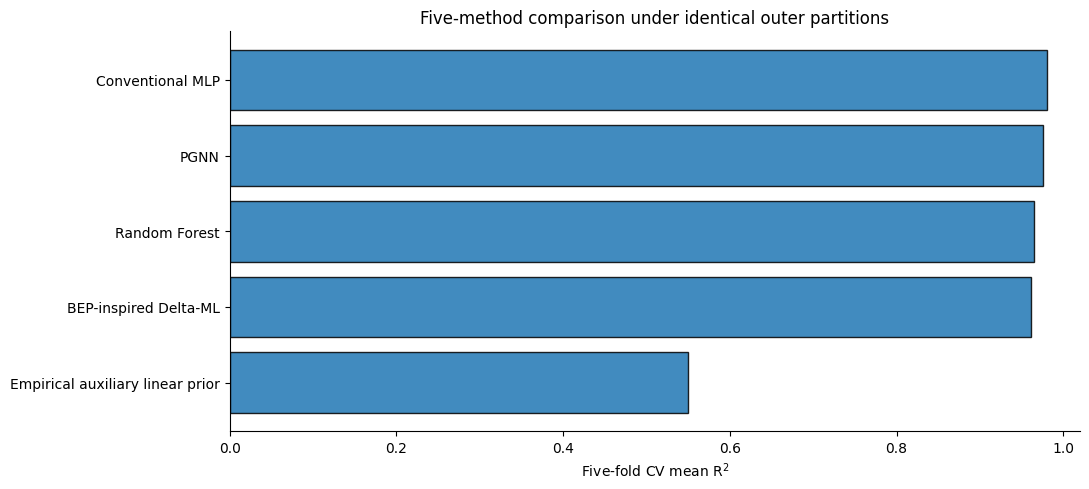

In [ ]:
print('=' * 55); print('STEP 23 — STRICT COMPLETE FIVE-METHOD PHYSICS SUMMARY'); print('=' * 55)
import numpy as np
import pandas as pd
SUMMARY_VERSION = 'physics_summary_strict_v3_8'
REQUIRED_PROTOCOLS = ['5fold', 'LOHO', 'LOSO', 'LODO']
REQUIRED_METHODS = [
    'Empirical auxiliary linear prior',
    'Random Forest',
    'BEP-inspired Delta-ML',
    'Conventional MLP',
    'PGNN',
]

phys_ck = require_checkpoint('physics_baselines_groupout_fully_safe')
if (
    phys_ck.get('version') != 'physics_groupout_strict_v3_8'
    or phys_ck.get('_complete') is not True
):
    raise RuntimeError('Strict complete physics-baseline checkpoint is required.')
phys_df = pd.DataFrame(phys_ck['rows'])

pgnn_ck = require_checkpoint('pgnn_groupout_nested_fully_safe')
if (
    pgnn_ck.get('version') != 'pgnn_strict_nested_v3_8'
    or pgnn_ck.get('_complete') is not True
):
    raise RuntimeError('Strict complete PGNN checkpoint is required.')

summary = (
    phys_df.assign(R2n=phys_df['R2'].astype(float))
    .groupby(['protocol', 'model'])['R2n']
    .apply(lambda s: round(np.nanmean(s), 4))
    .reset_index()
    .rename(columns={'R2n': 'mean_R2'})
)

pgnn_rows = []
for protocol in REQUIRED_PROTOCOLS:
    if protocol not in pgnn_ck or pgnn_ck[protocol].get('_complete') is not True:
        raise RuntimeError(f'PGNN {protocol} protocol incomplete.')
    r2 = pd.DataFrame(pgnn_ck[protocol]['rows'])['R2'].astype(float)
    pgnn_rows.append({
        'protocol': protocol,
        'model': 'PGNN',
        'mean_R2': round(np.nanmean(r2), 4),
    })
summary = pd.concat([summary, pd.DataFrame(pgnn_rows)], ignore_index=True)

expected_pairs = {
    (protocol, model)
    for protocol in REQUIRED_PROTOCOLS
    for model in REQUIRED_METHODS
}
observed_pairs = set(zip(summary['protocol'], summary['model']))
if observed_pairs != expected_pairs or len(summary) != len(expected_pairs):
    raise RuntimeError(
        f'Five-method summary mismatch. Missing={expected_pairs - observed_pairs}; '
        f'extra={observed_pairs - expected_pairs}'
    )
if summary.duplicated(['protocol', 'model']).sum() != 0:
    raise RuntimeError('Duplicate protocol-model rows in five-method summary.')

summary_ck = {
    'version': SUMMARY_VERSION,
    'expected_protocols': REQUIRED_PROTOCOLS,
    'expected_methods': REQUIRED_METHODS,
    'summary': summary,
    '_complete': True,
}
save_checkpoint(summary_ck, 'physics_baselines_summary_safe')
save_csv(summary, 'physics_baselines_summary_safe')

print('Complete five-method summary (mean R2 by protocol):')
print(summary.pivot(index='protocol', columns='model', values='mean_R2').to_string())

fig, ax = plt.subplots(figsize=(11, 5))
piv = summary[summary.protocol == '5fold'].sort_values('mean_R2')
ax.barh(piv['model'], piv['mean_R2'], alpha=0.85, edgecolor='k')
ax.set_xlabel('Five-fold CV mean R$^2$')
ax.set_xlim(0, 1.02)
ax.set_title('Five-method comparison under identical outer partitions')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
save_figure(fig, 'physics_baseline_comparison_safe')
plt.show()


## Step 24 — Matched full-data refits for descriptive interpretation  [REVISED]

In [ ]:
print('=' * 55); print('STEP 24 — DEPLOYED FULL-DATA PREPROCESSOR + MODELS (matched fixed configurations)'); print('=' * 55)
# Corrected deployed models are full-data refits used for descriptive interpretation and deployment
# diagnostics only. Their hyperparameters exactly match the prespecified configurations evaluated
# in held-out CV. Evaluation metrics still come only from the held-out protocols.
import time as _time
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
deployed_preprocessor = LeakageSafePreprocessor(
    numeric_names, cat_names, original_feature_set).fit(X_pre_df, y_barrier)
X_arr = deployed_preprocessor.transform(X_pre_df)
feature_names = list(deployed_preprocessor.kept_cols)
X = pd.DataFrame(X_arr, columns=feature_names)
save_checkpoint({'X_arr': X_arr, 'feature_names': feature_names}, 'deployed_matrix_raw_safe')

DEPLOYED_MODEL_VERSION = 'deployed_fixed_hp_v3_7'
joblib.dump(deployed_preprocessor, f'{SAVE_DIR}/models/deployed_preprocessor_raw_safe.joblib')
_PREP_META = {
    'feature_count': int(X_arr.shape[1]),
    'feature_names': feature_names,
    'training_sample_count': int(X_arr.shape[0]),
    'dataset_fingerprint': dict(DATASET_FINGERPRINT),
    'raw_feature_checkpoint': 'preclean_matrix_raw_safe',
    'runtime_environment': dict(RUNTIME_ENVIRONMENT),
    'preprocessor_scope': 'full-data refit for descriptive interpretation/deployment diagnostics',
}
joblib.dump(_PREP_META, f'{SAVE_DIR}/models/deployed_preprocessor_raw_safe_metadata.joblib')
print('Deployed matrix (raw-based):', X_arr.shape, '| preprocessor + fingerprint metadata saved.')

EXPECTED_DEPLOYED_CONFIG = {
    'rf_barrier_final_raw_safe': MODEL_HYPERPARAMETER_POLICY['RF']['configuration'],
    'df_barrier_final_raw_safe': MODEL_HYPERPARAMETER_POLICY['DF']['configuration'],
    'mlp_barrier_final_raw_safe': MODEL_HYPERPARAMETER_POLICY['MLP']['configuration'],
}
DEPLOY_META = {
    'deployed_model_version': DEPLOYED_MODEL_VERSION,
    'feature_count': int(X_arr.shape[1]),
    'feature_names': feature_names,
    'training_sample_count': int(X_arr.shape[0]),
    'preprocessor_checkpoint': 'deployed_preprocessor_raw_safe',
    'random_seed': int(SEED),
    'raw_feature_checkpoint': 'preclean_matrix_raw_safe',
    'dataset_fingerprint': dict(DATASET_FINGERPRINT),
    'runtime_environment': dict(RUNTIME_ENVIRONMENT),
    'fit_scope': 'full-data refit for descriptive interpretation/deployment diagnostics only',
    'evaluation_source': 'held-out CV checkpoints; never this full-data refit',
}
def _save_deployed(model, model_name, filename):
    joblib.dump(model, f'{SAVE_DIR}/models/{filename}.joblib')
    meta = dict(DEPLOY_META)
    meta.update({
        'model_name': model_name,
        'model_filename': f'{filename}.joblib',
        'model_configuration': EXPECTED_DEPLOYED_CONFIG[filename],
        'training_timestamp': _time.strftime('%Y-%m-%d %H:%M:%S'),
    })
    joblib.dump(meta, f'{SAVE_DIR}/models/{filename}_metadata.joblib')
    print('  saved', filename)

def load_validated_model(filename):
    """Load only a corrected full-data refit matching the evaluated fixed configuration."""
    mp = f'{SAVE_DIR}/models/{filename}.joblib'
    xp = f'{SAVE_DIR}/models/{filename}_metadata.joblib'
    if not (os.path.exists(mp) and os.path.exists(xp)):
        return None
    try:
        meta = joblib.load(xp)
    except Exception:
        return None
    if not isinstance(meta, dict):
        return None
    if meta.get('deployed_model_version') != DEPLOYED_MODEL_VERSION:
        print(f'  {filename}: old deployed-model version; retraining.')
        return None
    if meta.get('model_configuration') != EXPECTED_DEPLOYED_CONFIG.get(filename):
        print(f'  {filename}: evaluated/deployed configuration mismatch; retraining.')
        return None
    if meta.get('feature_count') != len(feature_names):
        return None
    if list(meta.get('feature_names', [])) != feature_names:
        return None
    if meta.get('preprocessor_checkpoint') != 'deployed_preprocessor_raw_safe':
        return None
    env_meta = meta.get('runtime_environment', {})
    if not isinstance(env_meta, dict) or not {
        'torch_version', 'torch_cuda_build', 'cuda_available'
    }.issubset(env_meta):
        print(f'  {filename}: runtime-environment metadata missing; retraining.')
        return None
    stored_fp = meta.get('dataset_fingerprint', {})
    if any(stored_fp.get(k) != DATASET_FINGERPRINT.get(k) for k in _fingerprint_keys()):
        print(f'  {filename}: dataset fingerprint mismatch; retraining.')
        return None
    try:
        model = joblib.load(mp)
    except Exception:
        return None
    nfi = getattr(model, 'n_features_in_', None)
    if nfi is not None and int(nfi) != len(feature_names):
        return None
    if filename == 'rf_barrier_final_raw_safe':
        params = model.get_params()
        if not (int(params.get('n_estimators', -1)) == 300
                and params.get('max_features') == 'sqrt'
                and int(params.get('min_samples_leaf', -1)) == 2
                and int(params.get('random_state', -1)) == int(SEED)):
            print('  RF deployed refit does not match evaluated 300-tree configuration; retraining.')
            return None
    return model

rf_final_barrier = load_validated_model('rf_barrier_final_raw_safe')
if rf_final_barrier is None:
    rf_final_barrier = make_rf(SEED).fit(X_arr, y_barrier)
    _save_deployed(rf_final_barrier, 'Random Forest (matched full-data refit)',
                   'rf_barrier_final_raw_safe')

final_df_barrier = load_validated_model('df_barrier_final_raw_safe')
if final_df_barrier is None:
    final_df_barrier = make_df(SEED)
    final_df_barrier.fit(X_arr, y_barrier, verbose=True)
    _save_deployed(final_df_barrier, 'Deep Forest (matched full-data refit)',
                   'df_barrier_final_raw_safe')

final_mlp_barrier = load_validated_model('mlp_barrier_final_raw_safe')
if final_mlp_barrier is None:
    final_mlp_barrier = make_mlp(SEED).fit(X_arr, y_barrier)
    _save_deployed(final_mlp_barrier, 'MLP (matched full-data refit)',
                   'mlp_barrier_final_raw_safe')

print('OK matched full-data refits ready (validated on load).')
_tree_preds = np.array([tree.predict(X_arr) for tree in rf_final_barrier.estimators_])
deployed_in_sample_pred_mean = _tree_preds.mean(axis=0)
deployed_in_sample_pred_std = _tree_preds.std(axis=0)
print('In-sample refit predictions are deployment diagnostics only; they are NOT evaluation or ranking results.')
feature_matrix_compat = {
    'X_arr': X_arr,
    'feature_names': feature_names,
    'y_barrier': y_barrier,
    'y_rate': (y_rate if 'y_rate' in globals() else None),
    'host_labels': host_labels,
    'surface_labels': surface_labels,
}
uncertainty_compat = {
    'pred_mean': deployed_in_sample_pred_mean,
    'pred_std': deployed_in_sample_pred_std,
    'scope': 'in_sample_deployment_diagnostic_only',
}


STEP 24 — DEPLOYED FULL-DATA PREPROCESSOR + MODELS (matched fixed configurations)
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint saved: deployed_matrix_raw_safe
Deployed matrix (raw-based): (10950, 141) | preprocessor + fingerprint metadata saved.
OK matched full-data refits ready (validated on load).
In-sample refit predictions are deployment diagnostics only; they are NOT evaluation or ranking results.


## Step 25 — Compatibility aliases for figure/summary cells  [NEW]

In [ ]:
# In-memory aliases only — corrected fold-fitted / held-out-isolated results exposed under short names for
# downstream summary/figure cells. No obsolete checkpoint is written or read.
results_5f = require_checkpoint('results_5f_fully_nested_safe')
results_loho = load_checkpoint('results_loho_fully_nested_safe')
results_loso = load_checkpoint('results_loso_fully_nested_safe')
results_lodo = load_checkpoint('results_lodo_fully_nested_safe')
print('OK in-memory aliases set from *_fully_nested_safe checkpoints.')


  ✓ Checkpoint loaded: results_5f_fully_nested_safe
  ✓ Checkpoint loaded: results_loho_fully_nested_safe
  ✓ Checkpoint loaded: results_loso_fully_nested_safe
  ✓ Checkpoint loaded: results_lodo_fully_nested_safe
OK in-memory aliases set from *_fully_nested_safe checkpoints.


## Step 26 — Descriptive full-data-refit feature importance  [REVISED]

STEP 26 — DESCRIPTIVE FULL-DATA-REFIT FEATURE IMPORTANCE
  ✓ Checkpoint loaded: feature_importance_raw_safe
✓ Matched descriptive feature-importance checkpoint loaded.

TOP 20 — Random Forest descriptive MDI:
doped_weighted_surface_energy    0.0637
doped_mendeleev_no               0.0354
doped_efermi                     0.0338
doped_cohesive_energy            0.0324
doped_melting_point              0.0320
doped_out_e_number               0.0311
doped_anerage_ionic_radius       0.0292
doped_d_e_number                 0.0285
site1                            0.0230
doped_molar_volume               0.0228
doped_d-band_center              0.0214
doped_ionization_energies_3      0.0193
com_top_d-band                   0.0185
host_d_e_number                  0.0181
host_molar_volume                0.0167
doped_weighted_work_function     0.0159
doped_atomic_radius              0.0154
com_top_electronegativity        0.0151
doped_boiling_point              0.0149
host_surface_energy            

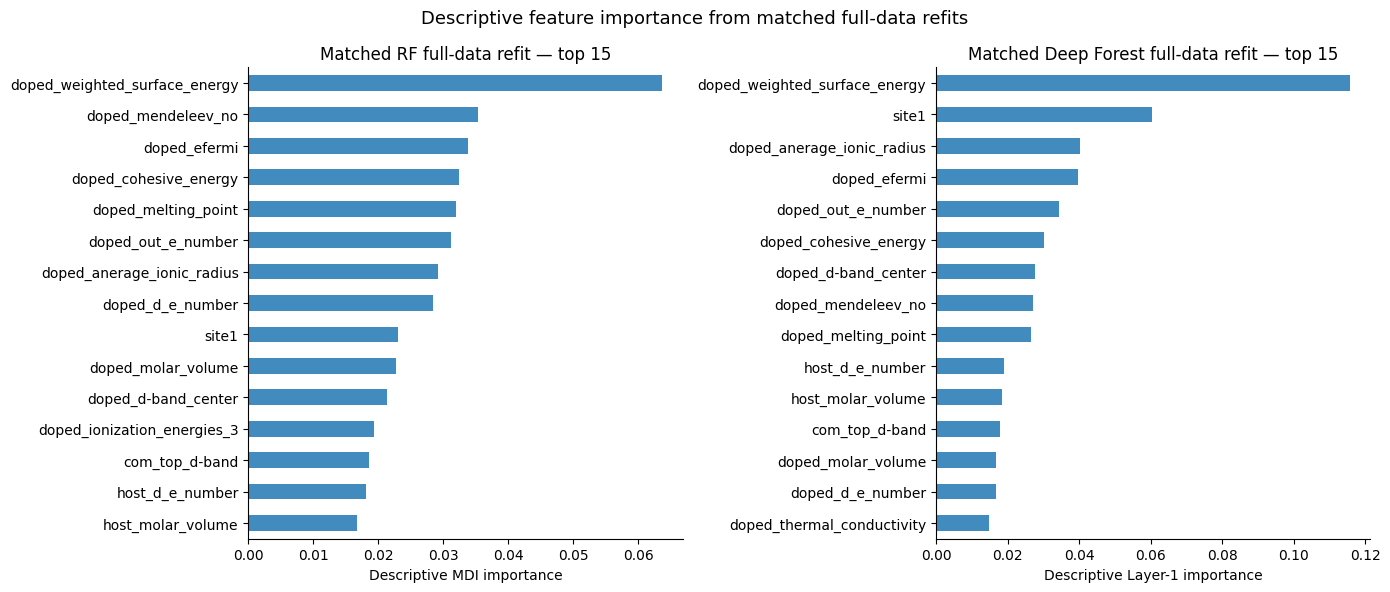

  ✓ CSV + fingerprint sidecar saved: feature_importance_rf.csv
  ✓ CSV + fingerprint sidecar saved: feature_importance_df.csv
Interpretation note: these full-data-refit importances are descriptive; held-out permutation importance is in Step 38.


In [ ]:
print('=' * 55)
print('STEP 26 — DESCRIPTIVE FULL-DATA-REFIT FEATURE IMPORTANCE')
print('=' * 55)

FEATURE_IMPORTANCE_VERSION = 'descriptive_refit_v3_7'

def _feature_importance_checkpoint_valid(obj):
    if not isinstance(obj, dict):
        return False
    fi_rf_obj = obj.get('fi_rf')
    fi_df_obj = obj.get('fi_df')
    return (
        obj.get('version') == FEATURE_IMPORTANCE_VERSION
        and obj.get('_complete') is True
        and obj.get('deployed_model_version') == DEPLOYED_MODEL_VERSION
        and isinstance(fi_rf_obj, pd.Series)
        and len(fi_rf_obj) == len(feature_names)
        and set(map(str, fi_rf_obj.index)) == set(map(str, feature_names))
        and isinstance(fi_df_obj, pd.Series)
        and len(fi_df_obj) == len(feature_names)
        and set(map(str, fi_df_obj.index)) == set(map(str, feature_names))
    )

fi_ckpt = load_checkpoint('feature_importance_raw_safe')
if _feature_importance_checkpoint_valid(fi_ckpt):
    fi_rf = fi_ckpt['fi_rf']
    fi_df = fi_ckpt['fi_df']
    print('✓ Matched descriptive feature-importance checkpoint loaded.')
else:
    try:
        rf_final_barrier
    except NameError:
        rf_final_barrier = load_validated_model('rf_barrier_final_raw_safe')
        if rf_final_barrier is None:
            raise RuntimeError('Matched RF full-data refit unavailable. Run Step 24 first.')
    try:
        final_df_barrier
    except NameError:
        final_df_barrier = load_validated_model('df_barrier_final_raw_safe')
        if final_df_barrier is None:
            raise RuntimeError('Matched Deep Forest full-data refit unavailable. Run Step 24 first.')

    fi_rf = pd.Series(
        rf_final_barrier.feature_importances_,
        index=feature_names,
        name='importance',
    ).sort_values(ascending=False)
    fi_df = final_df_barrier.feature_importances_from_layer(
        layer_idx=0, feature_names=feature_names)
    if isinstance(fi_df, pd.DataFrame):
        if fi_df.shape[1] != 1:
            raise RuntimeError('Deep Forest importance output has more than one column.')
        fi_df = fi_df.iloc[:, 0]
    elif not isinstance(fi_df, pd.Series):
        fi_df = pd.Series(np.asarray(fi_df).reshape(-1), index=feature_names)
    fi_df = fi_df.rename('importance').sort_values(ascending=False)
    if len(fi_df) != len(feature_names):
        raise RuntimeError('Deep Forest importance length does not match deployed features.')

    save_checkpoint({
        'version': FEATURE_IMPORTANCE_VERSION,
        'deployed_model_version': DEPLOYED_MODEL_VERSION,
        'scope': 'descriptive full-data refit; not held-out validation or causal mechanism',
        'fi_rf': fi_rf,
        'fi_df': fi_df,
        '_complete': True,
    }, 'feature_importance_raw_safe')
    print('✓ Matched descriptive feature importances saved.')

print('\nTOP 20 — Random Forest descriptive MDI:')
print(fi_rf.head(20).round(4).to_string())
print('\nTOP 20 — Deep Forest descriptive Layer-1 importance:')
print(fi_df.head(20).round(4).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fi_rf.head(15).sort_values().plot(
    kind='barh', ax=ax1, alpha=0.85)
ax1.set_xlabel('Descriptive MDI importance')
ax1.set_title('Matched RF full-data refit — top 15')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

fi_df.head(15).sort_values().plot(
    kind='barh', ax=ax2, alpha=0.85)
ax2.set_xlabel('Descriptive Layer-1 importance')
ax2.set_title('Matched Deep Forest full-data refit — top 15')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Descriptive feature importance from matched full-data refits',
             fontsize=13)
plt.tight_layout()
save_figure(fig, 'feature_importance_global')
plt.show()

fi_rf_export = fi_rf.rename('importance').reset_index()
fi_rf_export = fi_rf_export.rename(columns={fi_rf_export.columns[0]: 'feature'})
fi_df_series = fi_df if isinstance(fi_df, pd.Series) else pd.Series(fi_df)
fi_df_export = fi_df_series.rename('importance').reset_index()
fi_df_export = fi_df_export.rename(columns={fi_df_export.columns[0]: 'feature'})
save_csv(fi_rf_export, 'feature_importance_rf')
save_csv(fi_df_export, 'feature_importance_df')
print('Interpretation note: these full-data-refit importances are descriptive; held-out permutation importance is in Step 38.')


## Step 27 — Descriptive surface-specific feature importance  [REVISED]

STEP 27 — DESCRIPTIVE SURFACE-SPECIFIC FEATURE IMPORTANCE
  ✓ Checkpoint loaded: fi_per_surface_raw_safe
✓ Matched descriptive per-surface importance checkpoint loaded.

_100 — descriptive top 5 (n=870):
doped_weighted_surface_energy    0.0486
doped_melting_point              0.0318
doped_anerage_ionic_radius       0.0291
doped_out_e_number               0.0281
doped_efermi                     0.0280

_110 — descriptive top 5 (n=900):
doped_weighted_surface_energy    0.0459
doped_melting_point              0.0383
doped_efermi                     0.0325
doped_anerage_ionic_radius       0.0307
doped_out_e_number               0.0298

_111 — descriptive top 5 (n=900):
doped_weighted_surface_energy    0.0542
doped_anerage_ionic_radius       0.0448
doped_melting_point              0.0400
doped_out_e_number               0.0378
doped_molar_volume               0.0355

_211 — descriptive top 5 (n=870):
doped_weighted_surface_energy    0.0524
doped_melting_point              0.0458
doped_anera

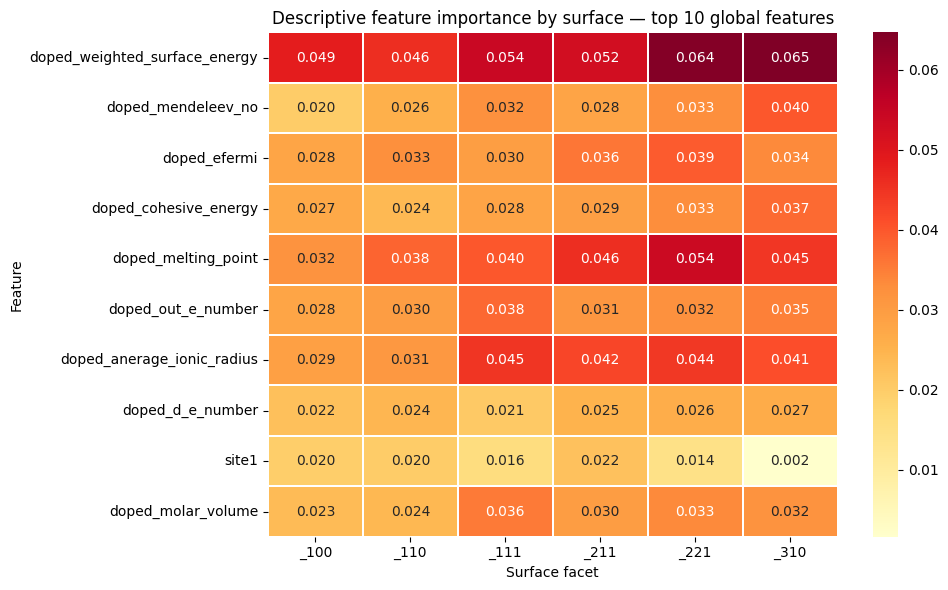

Interpretation note: these are descriptive subset refits, not held-out surface-generalization results.


In [ ]:
print('=' * 55)
print('STEP 27 — DESCRIPTIVE SURFACE-SPECIFIC FEATURE IMPORTANCE')
print('=' * 55)

SURFACE_FI_VERSION = 'descriptive_surface_refit_v3_7'
target_surfaces = ['_100', '_110', '_111', '_211', '_221', '_310']

try:
    X_arr
    surface_labels
except NameError:
    ckpt = feature_matrix_compat
    if ckpt is None:
        raise RuntimeError('Feature matrix unavailable. Run Step 24 first.')
    X_arr = ckpt['X_arr']
    y_barrier = ckpt['y_barrier']
    feature_names = ckpt['feature_names']
    surface_labels = ckpt['surface_labels']
    X = pd.DataFrame(X_arr, columns=feature_names)

def _surface_fi_checkpoint_valid(obj):
    if not isinstance(obj, dict):
        return False
    per = obj.get('fi_per_surface')
    return (
        obj.get('version') == SURFACE_FI_VERSION
        and obj.get('_complete') is True
        and obj.get('deployed_model_version') == DEPLOYED_MODEL_VERSION
        and obj.get('model_configuration') == MODEL_HYPERPARAMETER_POLICY['RF']['configuration']
        and isinstance(per, dict)
        and set(per) == set(target_surfaces)
        and all(isinstance(per[s], pd.Series)
                and set(map(str, per[s].index)) == set(map(str, feature_names))
                for s in target_surfaces)
    )

surface_fi_ckpt = load_checkpoint('fi_per_surface_raw_safe')
if _surface_fi_checkpoint_valid(surface_fi_ckpt):
    fi_per_surface = surface_fi_ckpt['fi_per_surface']
    surface_sample_counts = surface_fi_ckpt['surface_sample_counts']
    print('✓ Matched descriptive per-surface importance checkpoint loaded.')
else:
    fi_per_surface = {}
    surface_sample_counts = {}
    surface_arr = np.asarray(surface_labels).astype(str)
    for surf in target_surfaces:
        mask = surface_arr == surf
        surface_sample_counts[surf] = int(mask.sum())
        if mask.sum() < 2:
            raise RuntimeError(f'Insufficient rows for descriptive surface refit: {surf}')
        rf_s = make_rf(SEED).fit(X_arr[mask], y_barrier[mask])
        fi_s = pd.Series(
            rf_s.feature_importances_, index=feature_names, name='importance')
        fi_per_surface[surf] = fi_s.sort_values(ascending=False)
        print(f'  ✓ {surf}: n={mask.sum()}')
    save_checkpoint({
        'version': SURFACE_FI_VERSION,
        'deployed_model_version': DEPLOYED_MODEL_VERSION,
        'model_configuration': MODEL_HYPERPARAMETER_POLICY['RF']['configuration'],
        'scope': 'descriptive within-surface full-subset refits; not held-out validation',
        'surface_sample_counts': surface_sample_counts,
        'fi_per_surface': fi_per_surface,
        '_complete': True,
    }, 'fi_per_surface_raw_safe')
    print('✓ Matched descriptive per-surface importances saved.')

for surf in target_surfaces:
    print(f'\n{surf} — descriptive top 5 (n={surface_sample_counts[surf]}):')
    print(fi_per_surface[surf].head(5).round(4).to_string())

try:
    fi_rf
except NameError:
    fi_ckpt = load_checkpoint('feature_importance_raw_safe')
    if fi_ckpt is None:
        raise RuntimeError('Descriptive global feature importance unavailable. Run Step 26 first.')
    fi_rf = fi_ckpt['fi_rf']

top10_global = fi_rf.head(10).index.tolist()
heatmap_data = pd.DataFrame({
    surf: fi_per_surface[surf].reindex(top10_global)
    for surf in target_surfaces
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.3f',
            cmap='YlOrRd', linewidths=0.3, ax=ax)
ax.set_title('Descriptive feature importance by surface — top 10 global features')
ax.set_xlabel('Surface facet')
ax.set_ylabel('Feature')
plt.tight_layout()
save_figure(fig, 'feature_importance_per_surface')
plt.show()
print('Interpretation note: these are descriptive subset refits, not held-out surface-generalization results.')


## Step 28 — Deterministic SHAP interpretation  [REVISED]

STEP 28 — SHAP ANALYSIS (deterministic descriptive full-data refits)
  ✓ Checkpoint loaded: shap_values_rf_raw_safe
✓ Deterministic RF SHAP checkpoint loaded.
  ✓ Figure + fingerprint sidecars saved: shap_rf_dot.pdf / .png


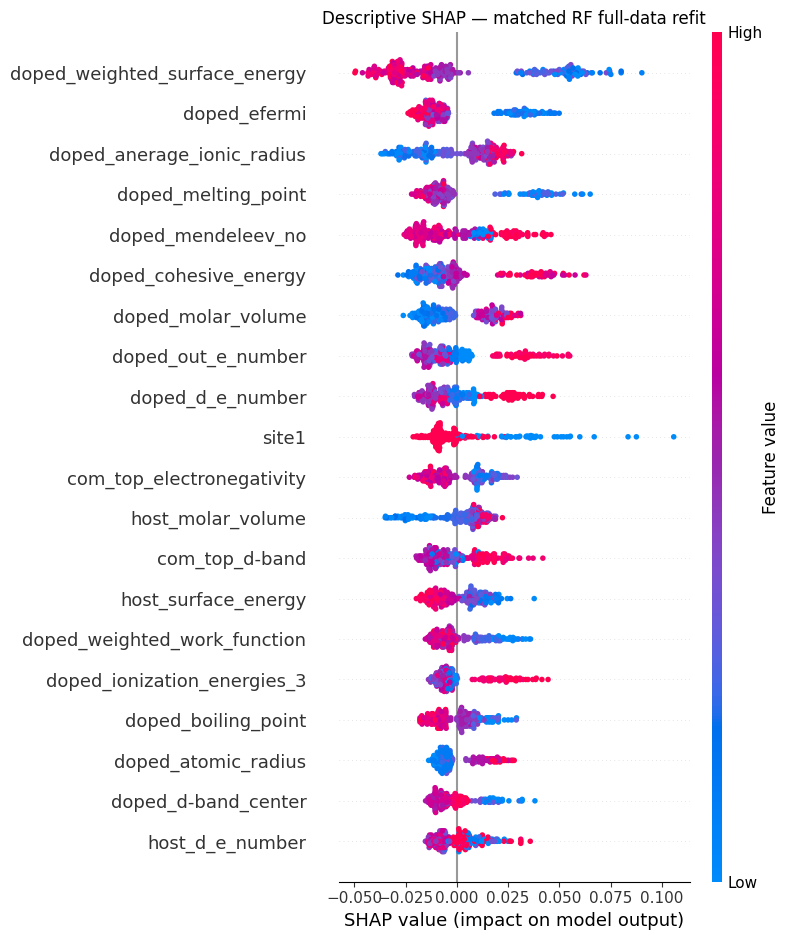

  ✓ Figure + fingerprint sidecars saved: shap_rf_bar.pdf / .png


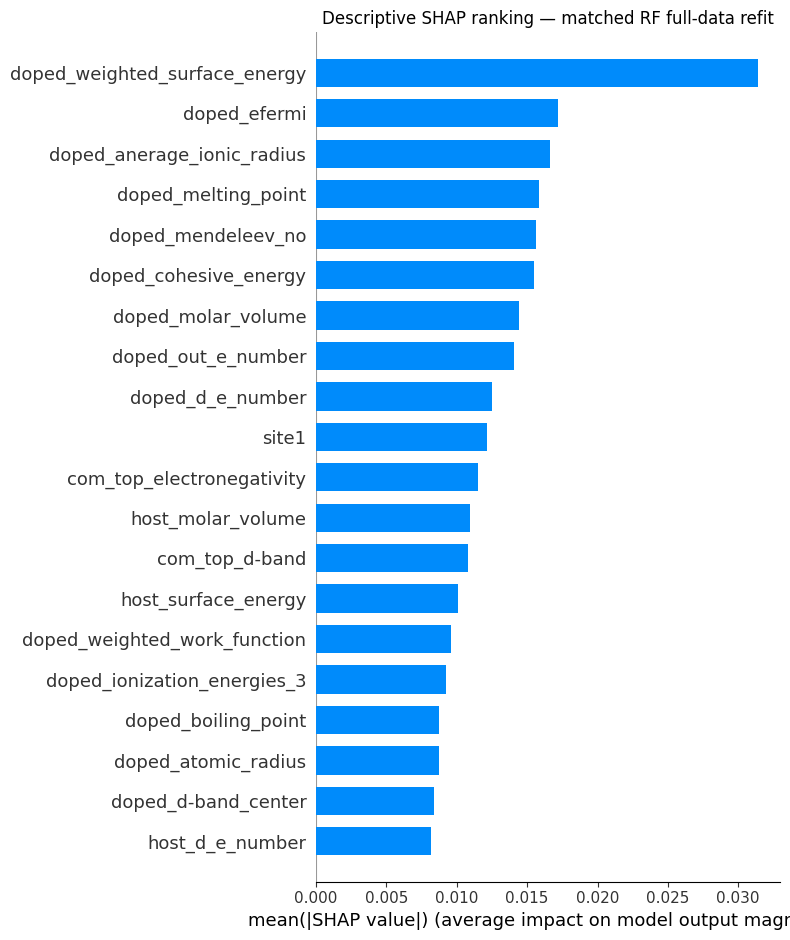

  ✓ Checkpoint loaded: shap_values_mlp_raw_safe
✓ Deterministic MLP SHAP checkpoint loaded.
  ✓ Figure + fingerprint sidecars saved: shap_mlp_dot.pdf / .png


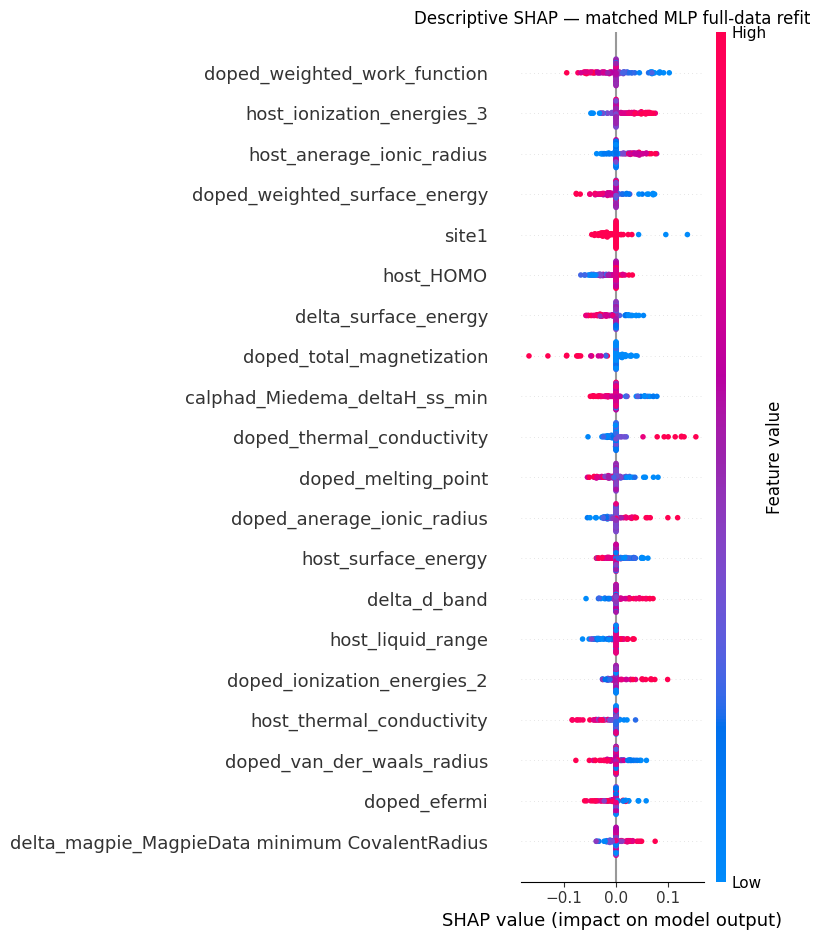

Interpretation note: SHAP describes matched full-data refits; predictive claims use held-out CV only.


In [ ]:
print('=' * 55)
print('STEP 28 — SHAP ANALYSIS (deterministic descriptive full-data refits)')
print('=' * 55)

import shap
INTERPRETATION_VERSION = 'interpretation_rng_v3_7'
RF_SHAP_SEED = int(SEED + 28)
MLP_SHAP_SEED = int(SEED + 281)
RF_SAMPLE_N = min(300, len(X_arr))

def _rf_shap_checkpoint_valid(obj):
    if not isinstance(obj, dict):
        return False
    try:
        vals = np.asarray(obj['shap_values_rf_raw_safe'])
        xs = obj['X_sample']
        idx = np.asarray(obj['sample_idx'], int)
    except Exception:
        return False
    return (
        obj.get('version') == INTERPRETATION_VERSION
        and obj.get('_complete') is True
        and int(obj.get('sample_seed', -1)) == RF_SHAP_SEED
        and obj.get('deployed_model_version') == DEPLOYED_MODEL_VERSION
        and isinstance(xs, pd.DataFrame)
        and len(xs) == RF_SAMPLE_N
        and len(idx) == RF_SAMPLE_N
        and vals.shape[0] == RF_SAMPLE_N
        and list(xs.columns) == list(feature_names)
    )

shap_ckpt_rf = load_checkpoint('shap_values_rf_raw_safe')
if _rf_shap_checkpoint_valid(shap_ckpt_rf):
    shap_values_rf = shap_ckpt_rf['shap_values_rf_raw_safe']
    X_sample = shap_ckpt_rf['X_sample']
    sample_idx = np.asarray(shap_ckpt_rf['sample_idx'], int)
    print('✓ Deterministic RF SHAP checkpoint loaded.')
else:
    if 'rf_final_barrier' not in dir():
        rf_final_barrier = load_validated_model('rf_barrier_final_raw_safe')
        if rf_final_barrier is None:
            raise RuntimeError('Matched RF full-data refit is unavailable. Run Step 24 first.')
    rng_rf_shap = np.random.RandomState(RF_SHAP_SEED)
    sample_idx = np.sort(rng_rf_shap.choice(len(X_arr), RF_SAMPLE_N, replace=False))
    X_sample = X.iloc[sample_idx].copy()
    print('Computing deterministic descriptive SHAP for matched RF full-data refit...')
    explainer_rf = shap.TreeExplainer(rf_final_barrier)
    shap_values_rf = explainer_rf.shap_values(X_sample)
    save_checkpoint({
        'version': INTERPRETATION_VERSION,
        'deployed_model_version': DEPLOYED_MODEL_VERSION,
        'scope': 'descriptive full-data refit; not held-out validation or causal mechanism',
        'sample_seed': RF_SHAP_SEED,
        'sample_idx': sample_idx,
        'shap_values_rf_raw_safe': shap_values_rf,
        'X_sample': X_sample,
        '_complete': True,
    }, 'shap_values_rf_raw_safe')
    print('✓ Deterministic RF SHAP saved.')

shap.summary_plot(shap_values_rf, X_sample, max_display=20,
                  show=False, plot_type='dot')
plt.title('Descriptive SHAP — matched RF full-data refit')
plt.tight_layout()
save_figure(plt.gcf(), 'shap_rf_dot')
plt.show()

shap.summary_plot(shap_values_rf, X_sample, max_display=20,
                  show=False, plot_type='bar')
plt.title('Descriptive SHAP ranking — matched RF full-data refit')
plt.tight_layout()
save_figure(plt.gcf(), 'shap_rf_bar')
plt.show()

def _mlp_shap_checkpoint_valid(obj):
    if not isinstance(obj, dict):
        return False
    try:
        vals = np.asarray(obj['shap_values_mlp_raw_safe'])
        xs = obj['X_sample_mlp']
    except Exception:
        return False
    return (
        obj.get('version') == INTERPRETATION_VERSION
        and obj.get('_complete') is True
        and int(obj.get('sample_seed', -1)) == MLP_SHAP_SEED
        and obj.get('deployed_model_version') == DEPLOYED_MODEL_VERSION
        and isinstance(xs, pd.DataFrame)
        and len(xs) == min(100, RF_SAMPLE_N)
        and vals.shape[0] == len(xs)
        and list(xs.columns) == list(feature_names)
    )

shap_ckpt_mlp = load_checkpoint('shap_values_mlp_raw_safe')
if _mlp_shap_checkpoint_valid(shap_ckpt_mlp):
    shap_values_mlp = shap_ckpt_mlp['shap_values_mlp_raw_safe']
    X_sample_mlp = shap_ckpt_mlp['X_sample_mlp']
    print('✓ Deterministic MLP SHAP checkpoint loaded.')
else:
    if 'final_mlp_barrier' not in dir():
        final_mlp_barrier = load_validated_model('mlp_barrier_final_raw_safe')
        if final_mlp_barrier is None:
            raise RuntimeError('Matched MLP full-data refit is unavailable. Run Step 24 first.')
    rng_mlp_shap = np.random.RandomState(MLP_SHAP_SEED)
    background_n = min(100, len(X_sample))
    background_pos = np.sort(
        rng_mlp_shap.choice(len(X_sample), background_n, replace=False))
    background = X_sample.iloc[background_pos].copy()
    X_sample_mlp = X_sample.iloc[:min(100, len(X_sample))].copy()
    print('Computing deterministic descriptive SHAP for matched MLP full-data refit...')
    explainer_mlp = shap.KernelExplainer(final_mlp_barrier.predict, background)
    _np_state = np.random.get_state()
    np.random.seed(MLP_SHAP_SEED)
    try:
        shap_values_mlp = explainer_mlp.shap_values(X_sample_mlp, nsamples=200)
    finally:
        np.random.set_state(_np_state)
    save_checkpoint({
        'version': INTERPRETATION_VERSION,
        'deployed_model_version': DEPLOYED_MODEL_VERSION,
        'scope': 'descriptive full-data refit; not held-out validation or causal mechanism',
        'sample_seed': MLP_SHAP_SEED,
        'background_positions': background_pos,
        'shap_values_mlp_raw_safe': shap_values_mlp,
        'X_sample_mlp': X_sample_mlp,
        '_complete': True,
    }, 'shap_values_mlp_raw_safe')
    print('✓ Deterministic MLP SHAP saved.')

shap.summary_plot(shap_values_mlp, X_sample_mlp,
                  max_display=20, show=False, plot_type='dot',
                  feature_names=feature_names)
plt.title('Descriptive SHAP — matched MLP full-data refit')
plt.tight_layout()
save_figure(plt.gcf(), 'shap_mlp_dot')
plt.show()

print('Interpretation note: SHAP describes matched full-data refits; predictive claims use held-out CV only.')


## Step 29 — SHAP dependence  [NOT CHANGED]

STEP 29 — SHAP DEPENDENCE ANALYSIS
  ✓ Checkpoint loaded: shap_values_rf_raw_safe
  ✓ Checkpoint loaded: shap_dependence_raw_safe
✓ Dependence plots already computed.
  ✓ Figure + fingerprint sidecars saved: shap_dependence_doped_weighted_surface_energy.pdf / .png


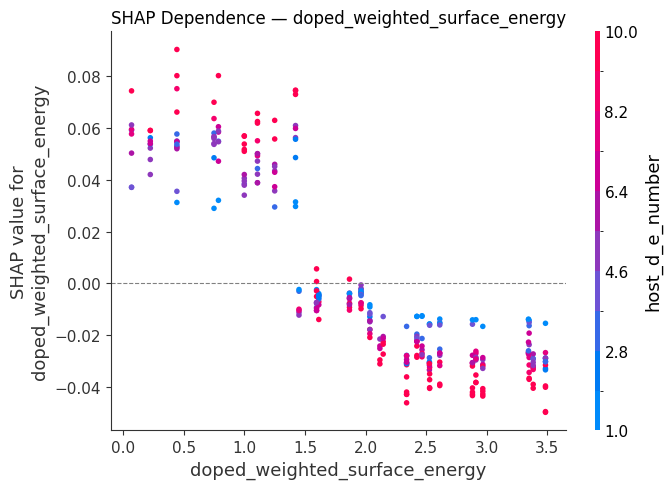

  ✓ Figure + fingerprint sidecars saved: shap_dependence_doped_d_band_center.pdf / .png


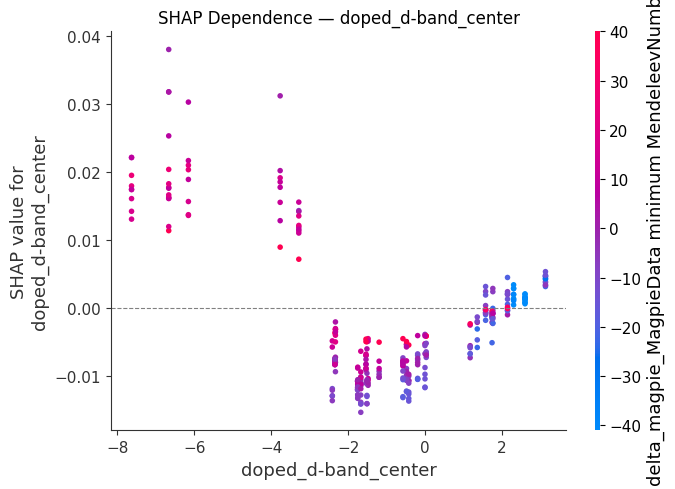

  ✓ Figure + fingerprint sidecars saved: shap_dependence_delta_d_band.pdf / .png


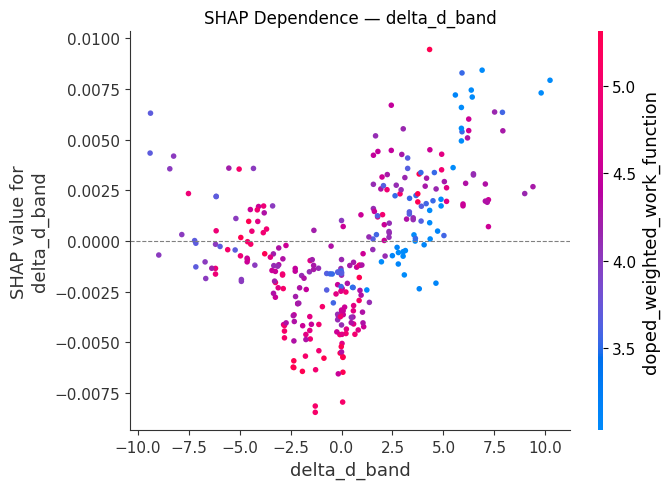

  ✓ Figure + fingerprint sidecars saved: shap_dependence_delta_electroneg.pdf / .png


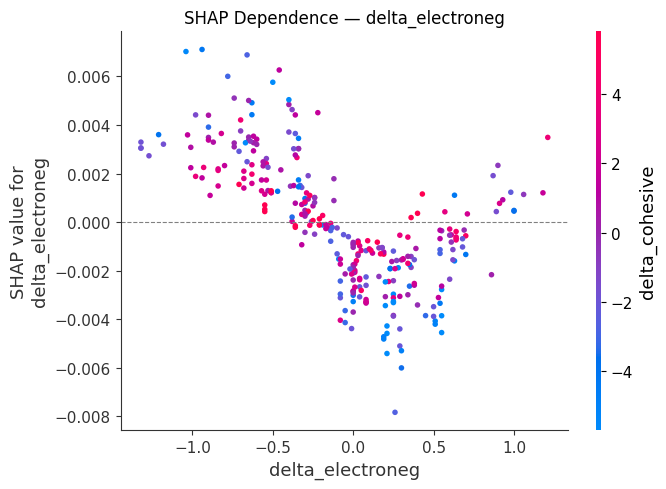

Skipping host_d-electron — not in feature list
  ✓ Figure + fingerprint sidecars saved: shap_dependence_host_molar_volume.pdf / .png


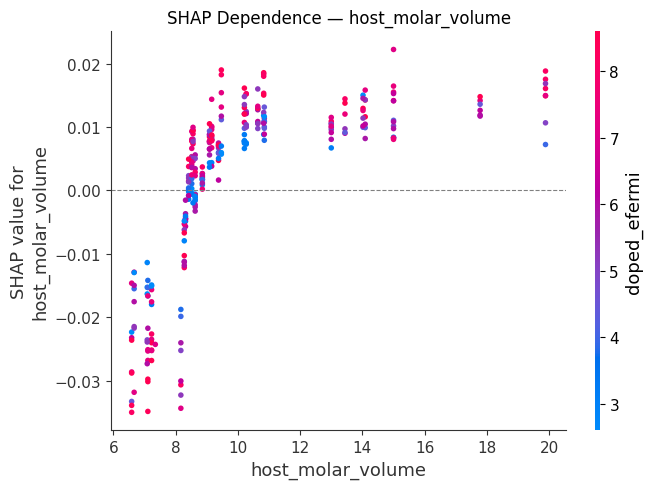

In [ ]:
print('=' * 55)
print('STEP 29 — SHAP DEPENDENCE ANALYSIS')
print('=' * 55)

import shap

shap_ckpt_rf = load_checkpoint('shap_values_rf_raw_safe')
if shap_ckpt_rf is None:
    print('ERROR: Step 14 এর SHAP data নেই। আগে Step 14 run করুন.')
else:
    shap_values_rf = shap_ckpt_rf['shap_values_rf_raw_safe']
    X_sample       = shap_ckpt_rf['X_sample']

    dep_done = load_checkpoint('shap_dependence_raw_safe')
    if dep_done is not None:
        print('✓ Dependence plots already computed.')
    else:
        print('Computing dependence plots...')

    # ── Always plot ───────────────────────────────────────────────────────────
    key_descriptors = [
        'doped_weighted_surface_energy',
        'doped_d-band_center',
        'delta_d_band',
        'delta_electroneg',
        'host_d-electron',
        'host_molar_volume'
    ]
    for feat in key_descriptors:
        if feat not in feature_names:
            print(f'Skipping {feat} — not in feature list')
            continue
        fig, ax = plt.subplots(figsize=(7, 5))
        shap.dependence_plot(feat, shap_values_rf, X_sample,
                             interaction_index='auto',
                             show=False, ax=ax)
        ax.set_title(f'SHAP Dependence — {feat}')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        plt.tight_layout()
        fname = feat.replace('/', '_').replace('-', '_')
        save_figure(fig, f'shap_dependence_{fname}')
        plt.show()

    if dep_done is None:
        save_checkpoint('done', 'shap_dependence_raw_safe')
        print('✓ Dependence plots saved to Drive.')

## Step 30 — Deterministic SHAP interactions  [REVISED]

STEP 30 — SHAP INTERACTION ANALYSIS (deterministic descriptive refit)
  ✓ Checkpoint loaded: shap_interaction_raw_safe
✓ Deterministic SHAP interaction checkpoint loaded.

TOP 10 DESCRIPTIVE SHAP INTERACTION PAIRS:
                    Feature_A                    Feature_B  interaction_strength
   doped_anerage_ionic_radius           host_d-band_center              0.000905
   doped_anerage_ionic_radius doped_electrical_resistivity              0.000881
          doped_boiling_point          doped_melting_point              0.000865
              host_d_e_number                        site1              0.000849
doped_weighted_surface_energy                        site1              0.000790
   doped_anerage_ionic_radius              host_d_e_number              0.000779
                        site1                        site2              0.000754
                 doped_efermi                        site1              0.000735
               com_top_d-band          doped_boiling_poi

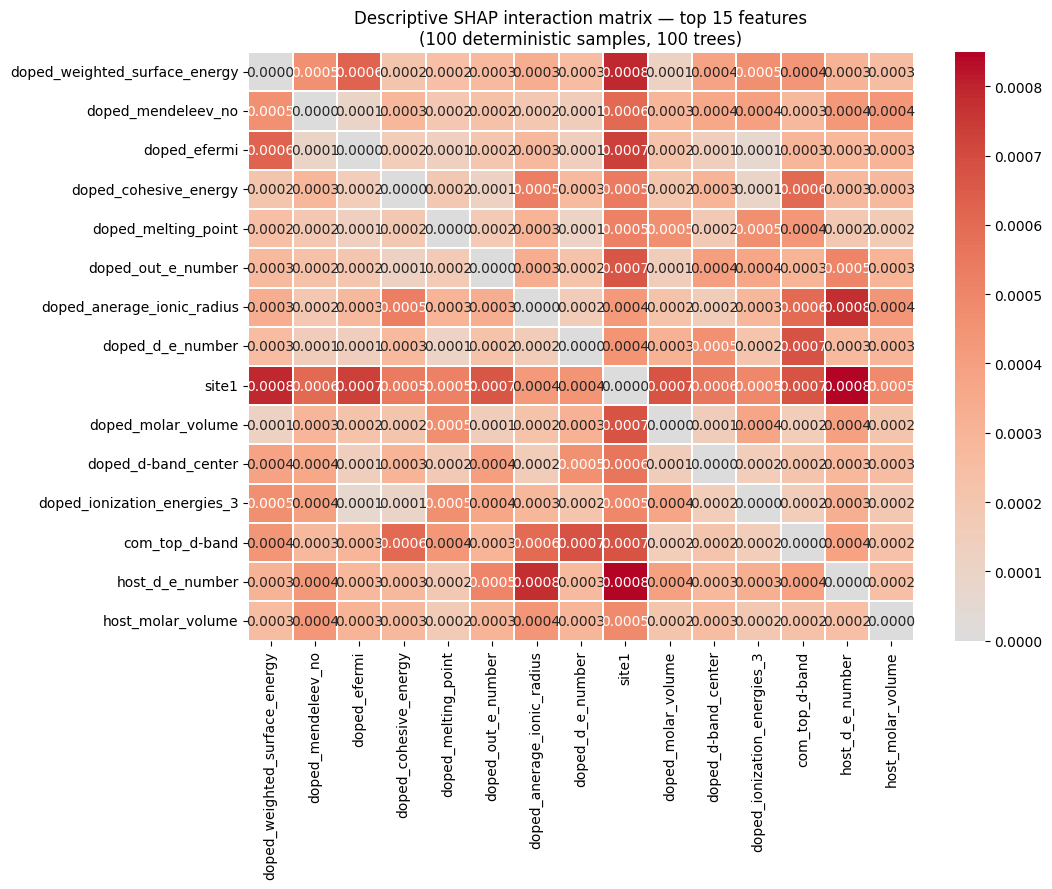

Interpretation note: interactions describe the matched full-data RF refit only.


In [ ]:
print('=' * 55)
print('STEP 30 — SHAP INTERACTION ANALYSIS (deterministic descriptive refit)')
print('=' * 55)

import shap
import math
import time
import copy
from tqdm.notebook import tqdm

INTERACTION_VERSION = 'interpretation_rng_v3_7'
INTERACTION_SEED = int(SEED + 30)
N_TREES_FOR_INTERACTION = min(100, len(rf_final_barrier.estimators_))
N_SAMPLES = min(100, len(X_arr))

def _interaction_checkpoint_valid(obj):
    if not isinstance(obj, dict):
        return False
    try:
        pairs = obj['interact_pairs']
        matrix = obj['interact_df']
        idx = np.asarray(obj['sample_idx_small'], int)
    except Exception:
        return False
    return (
        obj.get('version') == INTERACTION_VERSION
        and obj.get('_complete') is True
        and obj.get('deployed_model_version') == DEPLOYED_MODEL_VERSION
        and int(obj.get('sample_seed', -1)) == INTERACTION_SEED
        and int(obj.get('n_trees', -1)) == N_TREES_FOR_INTERACTION
        and len(idx) == N_SAMPLES
        and isinstance(pairs, pd.DataFrame)
        and isinstance(matrix, pd.DataFrame)
        and list(matrix.index) == list(feature_names)
        and list(matrix.columns) == list(feature_names)
    )

interact_ckpt = load_checkpoint('shap_interaction_raw_safe')
if _interaction_checkpoint_valid(interact_ckpt):
    interact_pairs = interact_ckpt['interact_pairs']
    interact_df = interact_ckpt['interact_df']
    sample_idx_small = np.asarray(interact_ckpt['sample_idx_small'], int)
    print('✓ Deterministic SHAP interaction checkpoint loaded.')
else:
    try:
        rf_final_barrier
    except NameError:
        rf_final_barrier = load_validated_model('rf_barrier_final_raw_safe')
        if rf_final_barrier is None:
            raise RuntimeError('Matched RF full-data refit is unavailable. Run Step 24 first.')
    try:
        X_arr
    except NameError:
        ckpt = feature_matrix_compat
        if ckpt is None:
            raise RuntimeError('Feature matrix unavailable. Run Step 24 first.')
        X_arr = ckpt['X_arr']
        feature_names = ckpt['feature_names']
        X = pd.DataFrame(X_arr, columns=feature_names)

    rf_light = copy.copy(rf_final_barrier)
    rf_light.estimators_ = rf_final_barrier.estimators_[:N_TREES_FOR_INTERACTION]
    rf_light.n_estimators = N_TREES_FOR_INTERACTION

    rng_interaction = np.random.RandomState(INTERACTION_SEED)
    sample_idx_small = np.sort(
        rng_interaction.choice(len(X_arr), N_SAMPLES, replace=False))
    X_small = X.iloc[sample_idx_small].copy()

    print(f'Building TreeExplainer ({N_TREES_FOR_INTERACTION} trees)...')
    t0 = time.time()
    explainer_interact = shap.TreeExplainer(rf_light)
    print(f'✓ Built in {time.time() - t0:.2f}s')

    print(f'Computing deterministic SHAP interactions '
          f'({N_SAMPLES} samples, {N_TREES_FOR_INTERACTION} trees)...')
    shap_chunks = []
    start_time = time.time()
    for i in tqdm(range(N_SAMPLES), desc='SHAP Interactions',
                  unit='sample', ncols=80):
        shap_chunks.append(
            explainer_interact.shap_interaction_values(X_small.iloc[[i]]))
    elapsed = time.time() - start_time
    print(f'✓ Done in {int(elapsed//60)}m{int(elapsed%60):02d}s')

    shap_interact = np.vstack(shap_chunks)
    interact_matrix = np.abs(shap_interact).mean(axis=0)
    interact_df = pd.DataFrame(
        interact_matrix, index=feature_names, columns=feature_names)
    np.fill_diagonal(interact_df.values, 0)

    interact_pairs = (
        interact_df.stack()
        .reset_index()
        .rename(columns={
            'level_0': 'Feature_A',
            'level_1': 'Feature_B',
            0: 'interaction_strength',
        })
        .query('Feature_A < Feature_B')
        .sort_values('interaction_strength', ascending=False)
    )

    save_checkpoint({
        'version': INTERACTION_VERSION,
        'deployed_model_version': DEPLOYED_MODEL_VERSION,
        'scope': 'descriptive full-data refit interactions; not held-out validation or causal mechanism',
        'sample_seed': INTERACTION_SEED,
        'sample_idx_small': sample_idx_small,
        'n_trees': N_TREES_FOR_INTERACTION,
        'n_samples': N_SAMPLES,
        'interact_pairs': interact_pairs,
        'interact_df': interact_df,
        '_complete': True,
    }, 'shap_interaction_raw_safe')
    print('✓ Deterministic SHAP interaction values saved.')

try:
    fi_rf
except NameError:
    fi_ckpt = load_checkpoint('feature_importance_raw_safe')
    if fi_ckpt is None:
        raise RuntimeError('Feature-importance checkpoint unavailable. Run Step 26 first.')
    fi_rf = fi_ckpt['fi_rf']

print('\nTOP 10 DESCRIPTIVE SHAP INTERACTION PAIRS:')
print(interact_pairs.head(10).to_string(index=False))
save_csv(interact_pairs.head(20), 'shap_interaction_pairs')

top15 = fi_rf.head(15).index.tolist()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(interact_df.loc[top15, top15],
            cmap='coolwarm', center=0, annot=True, fmt='.4f',
            linewidths=0.3, ax=ax)
ax.set_title('Descriptive SHAP interaction matrix — top 15 features\n'
             f'({N_SAMPLES} deterministic samples, {N_TREES_FOR_INTERACTION} trees)')
plt.tight_layout()
save_figure(fig, 'shap_interaction_heatmap')
plt.show()
print('Interpretation note: interactions describe the matched full-data RF refit only.')


## Step 31 — Best vs worst catalysts  [NOT CHANGED]

STEP 31 — BEST vs WORST CATALYST ANALYSIS
  ✓ Checkpoint loaded: best_vs_worst_raw_safe
✓ Best vs worst data loaded from Drive.

Top 1% most active (109 configs):
  Barrier : 0.281 – 0.686 eV
  Hosts   : {'Fe': 42, 'Ni': 22, 'Cu': 13, 'Cr': 10, 'Ru': 8}
  Surfaces: {'_100': 42, '_110': 15, '_211': 8, '_310': 5, '_322': 5}

Bottom 1% least active (109 configs):
  Barrier : 2.382 – 2.840 eV
  Hosts   : {'Au': 32, 'Cd': 26, 'Zn': 25, 'Ag': 8, 'Hg': 5}
  Surfaces: {'_111': 18, '_001': 14, '_100': 13, '_210': 10, '_221': 7}

DESCRIPTOR COMPARISON:
                   Descriptor  Top 1% mean  Bottom 1% mean  Difference
doped_weighted_surface_energy       2.8147          0.3982      2.4165
          doped_d-band_center      -1.2963         -5.7330      4.4367
             delta_electroneg       0.2043         -0.1101      0.3144
                 delta_d_band      -0.0398         -0.7310      0.6912
            host_molar_volume       7.2188         10.7164     -3.4976
  ✓ CSV + fingerprint sid

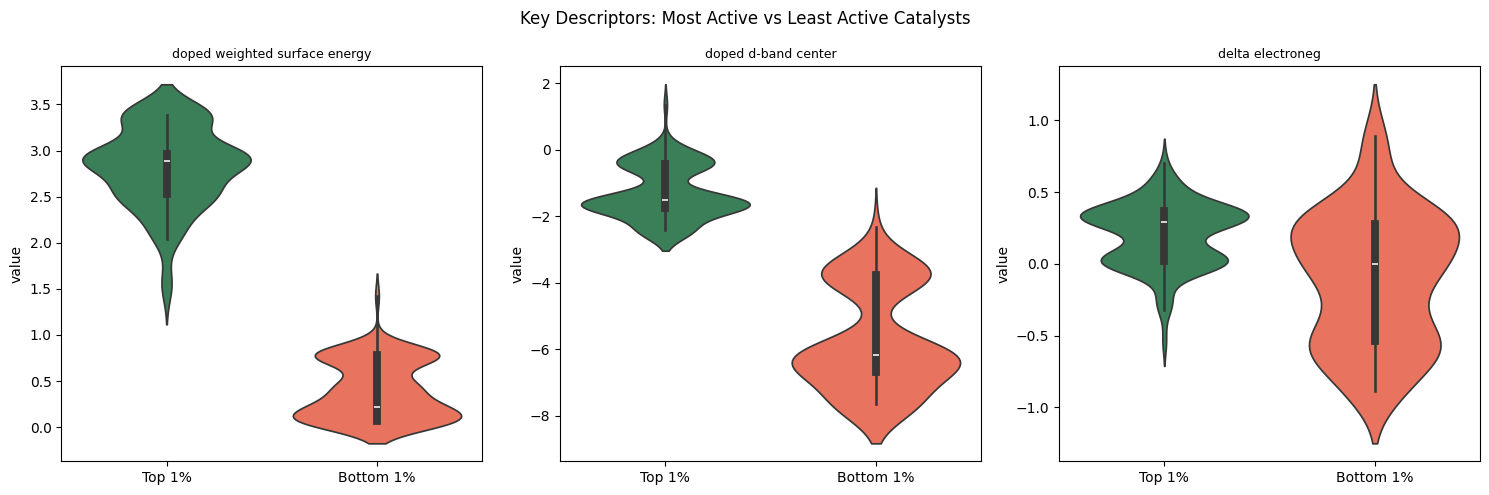

In [ ]:
print('=' * 55)
print('STEP 31 — BEST vs WORST CATALYST ANALYSIS')
print('=' * 55)

bvw_ckpt = load_checkpoint('best_vs_worst_raw_safe')

if bvw_ckpt is not None:
    compare_table = bvw_ckpt['compare_table']
    top_active    = bvw_ckpt['top_active']
    bottom_active = bvw_ckpt['bottom_active']
    df_full       = bvw_ckpt['df_full']
    n_pct         = bvw_ckpt['n_pct']
    print('✓ Best vs worst data loaded from Drive.')
else:
    df_full = X.copy()
    df_full['Barrier']  = y_barrier
    df_full['log_rate'] = y_rate
    df_full['Host']     = host_labels
    df_full['Surface']  = surface_labels

    n_pct         = int(len(df_full) * 0.01)
    top_active    = df_full.nsmallest(n_pct, 'Barrier')
    bottom_active = df_full.nlargest(n_pct,  'Barrier')

    compare_feats = [
        'doped_weighted_surface_energy', 'doped_d-band_center',
        'delta_electroneg', 'delta_d_band',
        'host_d-electron',  'host_molar_volume'
    ]
    compare_rows = []
    for feat in compare_feats:
        if feat not in df_full.columns:
            continue
        compare_rows.append({
            'Descriptor':     feat,
            'Top 1% mean':    round(top_active[feat].mean(), 4),
            'Bottom 1% mean': round(bottom_active[feat].mean(), 4),
            'Difference':     round(
                top_active[feat].mean() - bottom_active[feat].mean(), 4)
        })
    compare_table = pd.DataFrame(compare_rows)

    save_checkpoint({
        'compare_table': compare_table,
        'top_active':    top_active,
        'bottom_active': bottom_active,
        'df_full':       df_full,
        'n_pct':         n_pct,
    }, 'best_vs_worst_raw_safe')
    print('✓ Best vs worst saved to Drive.')

# ── Always show results ───────────────────────────────────────────────────────
print(f'\nTop 1% most active ({n_pct} configs):')
print(f'  Barrier : {top_active["Barrier"].min():.3f} – '
      f'{top_active["Barrier"].max():.3f} eV')
print(f'  Hosts   : {top_active["Host"].value_counts().head(5).to_dict()}')
print(f'  Surfaces: {top_active["Surface"].value_counts().head(5).to_dict()}')

print(f'\nBottom 1% least active ({n_pct} configs):')
print(f'  Barrier : {bottom_active["Barrier"].min():.3f} – '
      f'{bottom_active["Barrier"].max():.3f} eV')
print(f'  Hosts   : {bottom_active["Host"].value_counts().head(5).to_dict()}')
print(f'  Surfaces: {bottom_active["Surface"].value_counts().head(5).to_dict()}')

print('\nDESCRIPTOR COMPARISON:')
print(compare_table.to_string(index=False))
save_csv(compare_table, 'best_vs_worst_comparison')

compare_feats_plot = [
    'doped_weighted_surface_energy',
    'doped_d-band_center',
    'delta_electroneg'
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, compare_feats_plot):
    if feat not in df_full.columns:
        continue
    plot_data = pd.DataFrame({
        'value': pd.concat([top_active[feat], bottom_active[feat]],
                           ignore_index=True),
        'group': ['Top 1%'] * n_pct + ['Bottom 1%'] * n_pct
    })
    sns.violinplot(data=plot_data, x='group', y='value', ax=ax,
                   palette=['seagreen', 'tomato'])
    ax.set_title(feat.replace('_', ' '), fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Key Descriptors: Most Active vs Least Active Catalysts')
plt.tight_layout()
save_figure(fig, 'best_vs_worst_violin')
plt.show()

## Step 32 — HDII nested validation  [REVISED]
The HDII feature definition, SHAP feature selection, weighting, scaling, and regression are fitted independently inside each outer training fold. No full-data SHAP ranking or full-data scaling is used for cross-validation.


STEP 32 — HDII (FOLD-SPECIFIC FEATURE CONSTRUCTION + OOF VALIDATION)
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: hdii_nested_safe
  ✓ Checkpoint saved: hdii_nested_safe
  ✓ CSV + fingerprint sidecar saved: hdii_nested_folds_safe.csv

Fold-isolated HDII OOF metrics: {'R2': 0.17335, 'MAE': 0.25166, 'RMSE': np.float64(0.32336)}
Fold-specific feature definitions are retained; no universal top-three claim is made.
  ✓ Figure + fingerprint sidecars saved: hdii_nested_oof_safe.pdf / .png


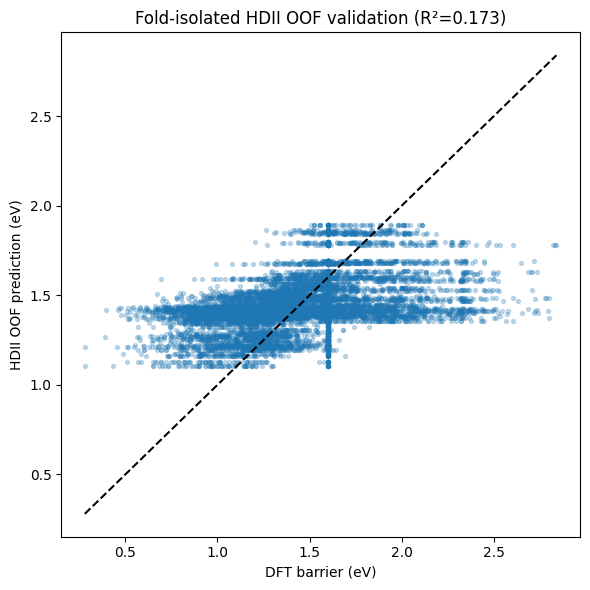

In [ ]:
print('=' * 55); print('STEP 32 — HDII (FOLD-SPECIFIC FEATURE CONSTRUCTION + OOF VALIDATION)'); print('=' * 55)
import shap
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
HDII_VERSION = 'fully_nested_raw_safe_v3_4'
hdii = load_checkpoint('hdii_nested_safe')
if hdii is None or hdii.get('version') != HDII_VERSION:
    hdii = {'version': HDII_VERSION, '_complete': False, '_done': [], 'rows': [],
            'oof_true': np.full(len(y_barrier), np.nan),
            'oof_pred': np.full(len(y_barrier), np.nan),
            'oof_hdii': np.full(len(y_barrier), np.nan)}
splits = list(KFold(5, shuffle=True, random_state=SEED).split(X_pre_df))
for fold, (tr, te) in enumerate(splits):
    if fold in hdii['_done']:
        continue
    prep = LeakageSafePreprocessor(numeric_names, cat_names, original_feature_set).fit(
        X_pre_df.iloc[tr], y_barrier[tr])
    Xtr = prep.transform(X_pre_df.iloc[tr]); Xte = prep.transform(X_pre_df.iloc[te])
    rf = make_rf(SEED + fold).fit(Xtr, y_barrier[tr])
    rng = np.random.RandomState(SEED + fold)
    sample_n = min(1000, len(tr)); sample_idx = rng.choice(len(tr), sample_n, replace=False)
    sv = shap.TreeExplainer(rf).shap_values(Xtr[sample_idx])
    if isinstance(sv, list): sv = sv[0]
    mean_abs = np.abs(np.asarray(sv)).mean(axis=0)
    top_idx = np.argsort(mean_abs)[-3:][::-1]
    top_features = [prep.kept_cols[i] for i in top_idx]
    raw_weights = mean_abs[top_idx]
    weights = raw_weights / raw_weights.sum() if raw_weights.sum() > 0 else np.repeat(1/3, 3)
    scaler = MinMaxScaler().fit(Xtr[:, top_idx])
    hdii_tr = scaler.transform(Xtr[:, top_idx]) @ weights
    hdii_te = scaler.transform(Xte[:, top_idx]) @ weights
    reg = LinearRegression().fit(hdii_tr.reshape(-1, 1), y_barrier[tr])
    pred = reg.predict(hdii_te.reshape(-1, 1))
    m = compute_metrics(y_barrier[te], pred)
    corr = np.corrcoef(hdii_te, y_barrier[te])[0, 1] if np.std(hdii_te) > 0 else np.nan
    hdii['rows'].append({'fold': int(fold), 'seed': int(SEED + fold), 'n_train': int(len(tr)),
        'n_test': int(len(te)), 'selected_feature_count': int(Xtr.shape[1]),
        'top_features': '|'.join(top_features), 'weights': '|'.join(f'{w:.8f}' for w in weights),
        'test_HDII_barrier_r': float(corr) if np.isfinite(corr) else np.nan,
        'R2': m['R2'], 'MAE': m['MAE'], 'RMSE': m['RMSE']})
    hdii['oof_true'][te] = y_barrier[te]; hdii['oof_pred'][te] = pred; hdii['oof_hdii'][te] = hdii_te
    hdii['_done'].append(fold)
    save_checkpoint(hdii, 'hdii_nested_safe')
    print(f'  fold {fold+1}/5 | top={top_features} | R2={m["R2"]:.4f}')
hdii['_complete'] = bool(
    set(hdii['_done']) == set(range(5))
    and np.isfinite(np.asarray(hdii['oof_pred'], dtype=float)).all()
)
save_checkpoint(hdii, 'hdii_nested_safe')
hdii_df = pd.DataFrame(hdii['rows']).sort_values('fold')
save_csv(hdii_df, 'hdii_nested_folds_safe')
oof_m = compute_metrics(np.asarray(hdii['oof_true']), np.asarray(hdii['oof_pred']))
print('\nFold-isolated HDII OOF metrics:', oof_m)
print('Fold-specific feature definitions are retained; no universal top-three claim is made.')
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(hdii['oof_true'], hdii['oof_pred'], s=8, alpha=0.25, rasterized=True)
lo = float(np.nanmin(hdii['oof_true'])); hi = float(np.nanmax(hdii['oof_true']))
ax.plot([lo, hi], [lo, hi], 'k--'); ax.set_xlabel('DFT barrier (eV)'); ax.set_ylabel('HDII OOF prediction (eV)')
ax.set_title(f'Fold-isolated HDII OOF validation (R²={oof_m["R2"]:.3f})')
plt.tight_layout(); save_figure(fig, 'hdii_nested_oof_safe'); plt.show()


## Step 33 — Retrospective OOF ranking of already-labelled configurations  [REVISED]


### Scope and terminology

This is a **retrospective out-of-fold ranking of rows that already have DFT labels**. It is not virtual screening, prospective discovery, experimental validation, or proof of thermodynamic stability. Two clearly separated models are reported:

1. a retrospective full-descriptor OOF benchmark; and
2. a retrospective prospective-availability-constrained OOF model using only exact-provenance descriptors verified as available before the target calculation.


STEP 33 — RETROSPECTIVE OOF RANKING OF LABELLED CONFIGURATIONS
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: parity_5f_fully_nested_safe
  ✓ Checkpoint loaded: feature_matrix_raw_safe
  ✓ Checkpoint loaded: matminer_features_raw_safe
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: retrospective_oof_ranking_safe
  ✓ Checkpoint saved: retrospective_oof_ranking_safe
  ✓ Checkpoint saved: retrospective_oof_ranking_safe
  ✓ CSV + fingerprint sidecar saved: retrospective_oof_all_labelled_safe.csv
  ✓ CSV + fingerprint sidecar saved: retrospective_oof_full_descriptor_top20_safe.csv
  ✓ CSV + fingerprint sidecar saved: retrospective_oof_constrained_top20_safe.csv
  ✓ CSV + fingerprint sidecar saved: retrospective_oof_constrained_folds_safe.csv

TOP 20 RETROSPECTIVELY RANKED LABELLED CONFIGURATIONS (availability-constrained OOF model):
Host Doped Surface  DFT_Barrier  Constrained_OOF_Pred_Barrier  Constrained_OOF_Uncertainty
  Fe    Os    _331    

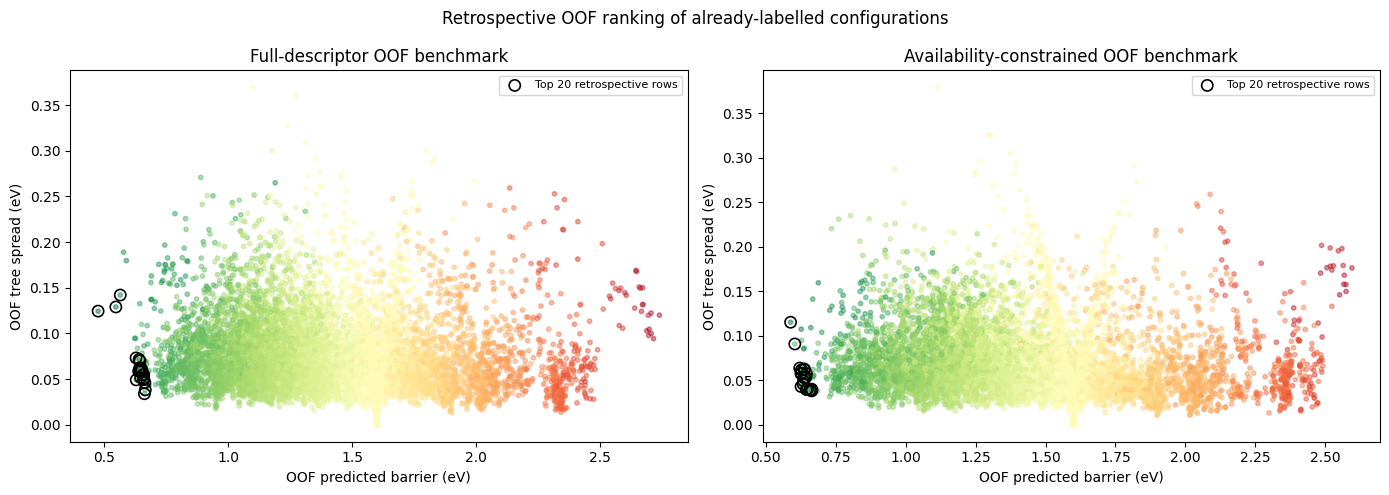

In [ ]:
print('=' * 55)
print('STEP 33 — RETROSPECTIVE OOF RANKING OF LABELLED CONFIGURATIONS')
print('=' * 55)
from sklearn.model_selection import KFold
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
RANK_VERSION = 'retrospective_oof_v3_6'
N = len(y_barrier)
parity = require_checkpoint('parity_5f_fully_nested_safe')
if not parity.get('_complete'):
    raise RuntimeError('Step 14 indexed OOF parity checkpoint is incomplete.')
full_pred = np.asarray(parity['RF']['pred'], float)
full_std = np.asarray(parity['RF']['std'], float)
full_fold = np.asarray(parity['RF']['fold'], int)
if not (len(full_pred)==N and np.isfinite(full_pred).all() and np.isfinite(full_std).all()):
    raise RuntimeError('Full-descriptor RF OOF predictions/uncertainty are incomplete.')

audit_df = build_exact_descriptor_provenance()
safe_mask = ((audit_df['classification_status'] == 'curated_exact')
             & (audit_df['allowed_for_prospective_screening'] == True)
             & (audit_df['available_before_barrier_calculation'] == True)
             & (audit_df['target_comparable_DFT_risk'] == False))
safe_descriptor_names = set(audit_df.loc[safe_mask, 'descriptor_name'].astype(str))
safe_numeric = [c for c in numeric_names if c in safe_descriptor_names]
surface_safe = 'Surface (one-hot categories)' in safe_descriptor_names
safe_cat = ['Surface'] if surface_safe else []
safe_orig = [c for c in original_feature_set if c in safe_numeric]
if len(safe_numeric) < 2:
    raise RuntimeError('Exact-provenance constrained descriptor pool is too small. Complete the manual provenance table first.')

splits = list(KFold(5, shuffle=True, random_state=SEED).split(X_pre_df))
rank = load_checkpoint('retrospective_oof_ranking_safe')
valid_rank = (isinstance(rank, dict) and rank.get('version') == RANK_VERSION
              and rank.get('safe_numeric') == safe_numeric and rank.get('safe_cat') == safe_cat
              and rank.get('model_seed') == int(SEED)
              and len(np.asarray(rank.get('safe_oof_pred', []))) == N
              and len(np.asarray(rank.get('safe_oof_std', []))) == N)
if not valid_rank:
    rank = {'version': RANK_VERSION, '_done': [], '_complete': False,
            'safe_numeric': safe_numeric, 'safe_cat': safe_cat, 'model_seed': int(SEED),
            'safe_oof_pred': np.full(N, np.nan), 'safe_oof_std': np.full(N, np.nan),
            'safe_oof_fold': np.full(N, -1, dtype=int), 'fold_rows': []}
else:
    # Repair partial resume state at the fold unit: a fold is reusable only when its row,
    # predictions, uncertainty and fold-index assignments are all complete and consistent.
    done = rank.get('_done', [])
    fold_rows = rank.get('fold_rows', [])
    if not isinstance(done, list) or not isinstance(fold_rows, list):
        done, fold_rows = [], []
    pred_arr = np.asarray(rank['safe_oof_pred'], float)
    std_arr = np.asarray(rank['safe_oof_std'], float)
    fold_arr = np.asarray(rank['safe_oof_fold'], int)
    clean_done, clean_rows = [], []
    for fold in range(5):
        te = splits[fold][1]
        rr = [r for r in fold_rows if isinstance(r, dict) and int(r.get('fold', -1)) == fold]
        valid_fold = (fold in done and len(rr) == 1 and int(rr[0].get('seed', -1)) == int(SEED)
                      and np.isfinite(pred_arr[te]).all() and np.isfinite(std_arr[te]).all()
                      and (std_arr[te] >= 0).all() and np.all(fold_arr[te] == fold))
        if valid_fold:
            clean_done.append(fold); clean_rows.extend(rr)
        else:
            pred_arr[te] = np.nan; std_arr[te] = np.nan; fold_arr[te] = -1
            if fold in done:
                print(f'  Constrained OOF fold {fold} is partial/inconsistent and will be recomputed.')
    rank['safe_oof_pred'] = pred_arr
    rank['safe_oof_std'] = std_arr
    rank['safe_oof_fold'] = fold_arr
    rank['_done'] = clean_done
    rank['fold_rows'] = clean_rows
    rank['_complete'] = False
for fold, (tr, te) in enumerate(splits):
    if fold in rank['_done']:
        continue
    prep = LeakageSafePreprocessor(safe_numeric, safe_cat, safe_orig).fit(
        X_pre_df.iloc[tr], y_barrier[tr])
    Xtr = prep.transform(X_pre_df.iloc[tr]); Xte = prep.transform(X_pre_df.iloc[te])
    rf = make_rf(SEED).fit(Xtr, y_barrier[tr])
    tree_pred = np.array([tree.predict(Xte) for tree in rf.estimators_])
    pred = tree_pred.mean(axis=0); std = tree_pred.std(axis=0)
    rank['safe_oof_pred'][te] = pred; rank['safe_oof_std'][te] = std; rank['safe_oof_fold'][te] = fold
    m = compute_metrics(y_barrier[te], pred)
    rank['fold_rows'].append({'fold': int(fold), 'seed': int(SEED), 'n_train': int(len(tr)),
        'n_test': int(len(te)), 'raw_safe_numeric_count': int(len(safe_numeric)),
        'raw_safe_categorical_count': int(len(safe_cat)),
        'selected_feature_count': int(Xtr.shape[1]), 'R2': m['R2'], 'MAE': m['MAE'], 'RMSE': m['RMSE']})
    rank['_done'].append(fold); save_checkpoint(rank, 'retrospective_oof_ranking_safe')
rank['_complete'] = (set(rank['_done']) == set(range(5))
                     and len(rank.get('fold_rows', [])) == 5
                     and len({int(r['fold']) for r in rank.get('fold_rows', [])}) == 5
                     and all(int(r.get('seed', -1)) == int(SEED) for r in rank.get('fold_rows', []))
                     and np.isfinite(np.asarray(rank['safe_oof_pred'], float)).all()
                     and np.isfinite(np.asarray(rank['safe_oof_std'], float)).all()
                     and (np.asarray(rank['safe_oof_std'], float) >= 0).all()
                     and set(np.asarray(rank['safe_oof_fold'], int)) == set(range(5)))
save_checkpoint(rank, 'retrospective_oof_ranking_safe')
if not rank['_complete']:
    raise RuntimeError('Availability-constrained OOF ranking checkpoint incomplete.')
if any(int(r.get('seed', -1)) != int(SEED) for r in rank.get('fold_rows', [])):
    raise RuntimeError('Constrained RF OOF folds must use the same RF seed as the full-descriptor Step 14 RF.')

df_orig = pd.read_csv(f'{SAVE_DIR}/Database.csv')
safe_pred = np.asarray(rank['safe_oof_pred'], float); safe_std = np.asarray(rank['safe_oof_std'], float)
screen_df = pd.DataFrame({
    'Host': np.asarray(host_labels).astype(str),
    'Doped': df_orig['Doped'].astype(str).values,
    'Surface': np.asarray(surface_labels).astype(str),
    'DFT_Barrier': np.asarray(y_barrier, float),
    'Full_OOF_Pred_Barrier': full_pred,
    'Full_OOF_Uncertainty': full_std,
    'Constrained_OOF_Pred_Barrier': safe_pred,
    'Constrained_OOF_Uncertainty': safe_std,
    'log_rate': np.asarray(y_rate, float),
    'OOF_fold': full_fold,
})
screen_df['Full_OOF_Score'] = screen_df['Full_OOF_Pred_Barrier'] + screen_df['Full_OOF_Uncertainty']
screen_df['Constrained_OOF_Score'] = (screen_df['Constrained_OOF_Pred_Barrier']
                                      + screen_df['Constrained_OOF_Uncertainty'])
screen_df['Pred_Barrier'] = screen_df['Constrained_OOF_Pred_Barrier']
screen_df['Uncertainty'] = screen_df['Constrained_OOF_Uncertainty']
screen_df['Ranking_scope'] = 'retrospective labelled-data OOF; prospective-availability-constrained descriptors'
top20_full = screen_df.nsmallest(20, 'Full_OOF_Score').copy()
top20_constrained = screen_df.nsmallest(20, 'Constrained_OOF_Score').copy()
pred_mean = safe_pred; pred_std = safe_std; top20 = top20_constrained
rank.update({'screen_df': screen_df, 'top20_full': top20_full,
             'top20_constrained': top20_constrained,
             'disclaimer': 'All rows are already labelled; rankings are retrospective OOF diagnostics.'})
save_checkpoint(rank, 'retrospective_oof_ranking_safe')
save_csv(screen_df, 'retrospective_oof_all_labelled_safe')
save_csv(top20_full, 'retrospective_oof_full_descriptor_top20_safe')
save_csv(top20_constrained, 'retrospective_oof_constrained_top20_safe')
save_csv(pd.DataFrame(rank['fold_rows']), 'retrospective_oof_constrained_folds_safe')
print('\nTOP 20 RETROSPECTIVELY RANKED LABELLED CONFIGURATIONS (availability-constrained OOF model):')
print(top20_constrained[['Host','Doped','Surface','DFT_Barrier',
                         'Constrained_OOF_Pred_Barrier','Constrained_OOF_Uncertainty']].to_string(index=False))
print('\nThese are already-labelled rows, not newly discovered candidates.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred_col, std_col, score_col, title in [
    (axes[0], 'Full_OOF_Pred_Barrier', 'Full_OOF_Uncertainty', 'Full_OOF_Score',
     'Full-descriptor OOF benchmark'),
    (axes[1], 'Constrained_OOF_Pred_Barrier', 'Constrained_OOF_Uncertainty', 'Constrained_OOF_Score',
     'Availability-constrained OOF benchmark')]:
    ax.scatter(screen_df[pred_col], screen_df[std_col], c=screen_df['DFT_Barrier'],
               cmap='RdYlGn_r', alpha=0.45, s=10, rasterized=True)
    tt = screen_df.nsmallest(20, score_col)
    ax.scatter(tt[pred_col], tt[std_col], s=65, facecolors='none', edgecolors='black',
               linewidths=1.2, label='Top 20 retrospective rows')
    ax.set_xlabel('OOF predicted barrier (eV)'); ax.set_ylabel('OOF tree spread (eV)')
    ax.set_title(title); ax.legend(fontsize=8)
plt.suptitle('Retrospective OOF ranking of already-labelled configurations')
plt.tight_layout(); save_figure(fig, 'retrospective_oof_ranking_map_safe'); plt.show()


## Step 34 — Same-element filter  [NOT CHANGED]

STEP 34 — HETEROGENEOUS-CONFIGURATION RETROSPECTIVE PRIORITIZATION
  ✓ Checkpoint loaded: matminer_features_raw_safe
Bulk-mixing-enthalpy proxy columns available: ['calphad_Miedema_deltaH_inter', 'calphad_Miedema_deltaH_amor', 'calphad_Miedema_deltaH_ss_min']

Total configurations             : 10,950
Same-element (host==dopant) removed: 365
Heterogeneous configurations     : 10,585
After bulk-mixing-enthalpy proxy filter (dH_mix < 0.5 eV/atom): 10,508
CAVEAT: Miedema bulk mixing enthalpy cannot establish surface resistance to segregation, aggregation, reconstruction, or experimental synthesizability.

TOP 20 RETROSPECTIVELY PRIORITIZED LABELLED HETEROGENEOUS CONFIGURATIONS:
Host Doped Surface  DFT_Barrier  Pred_Barrier  Uncertainty  mixing_enthalpy
  Fe    Os    _331     0.621213      0.626432     0.043009        -0.062309
  Fe    Os    _322     0.627571      0.633726     0.045643        -0.062309
  Fe    Ru    _310     0.566726      0.625959     0.057413        -0.071247
  Fe    Os  

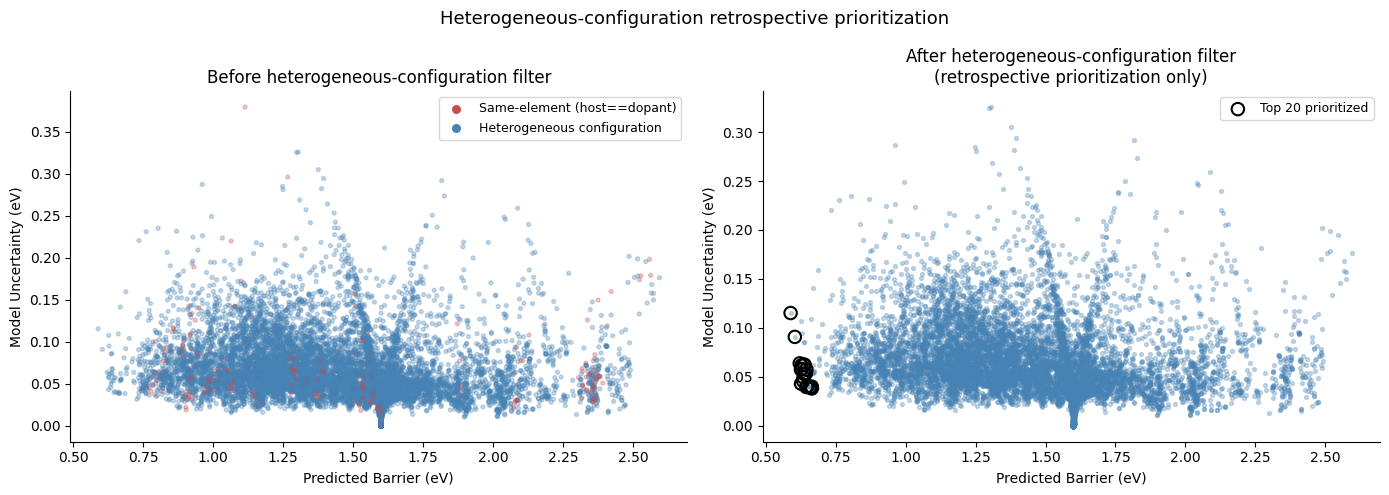


Unverified retrospective prioritization; not a screening or stability claim.


In [ ]:
print('=' * 55); print('STEP 34 — HETEROGENEOUS-CONFIGURATION RETROSPECTIVE PRIORITIZATION'); print('=' * 55)
# Reviewer item 5: cautious retrospective language only. No claim of experimental validity,
# thermodynamic stability, or synthesizability. The Miedema mixing enthalpy is a bulk-phase
# proxy that CANNOT establish surface resistance to segregation, aggregation, reconstruction,
# or experimental synthesizability. Deliverables renamed to cautious _safe names; obsolete
# screening outputs are NOT recreated.
try:
    screen_df
except NameError:
    sc_ckpt = load_checkpoint('retrospective_oof_ranking_safe'); screen_df = sc_ckpt['screen_df']
drive_csv = f'{SAVE_DIR}/Database.csv'
try:
    df_orig = pd.read_csv(io.BytesIO(uploaded[filename]))
except Exception:
    df_orig = pd.read_csv(drive_csv)
mm_ck = require_checkpoint('matminer_features_raw_safe')
X_matminer = pd.DataFrame(mm_ck['X_matminer_raw'], columns=mm_ck['matminer_names'])
calphad_cols = [c for c in X_matminer.columns if c.startswith('calphad_')]
has_calphad = len(calphad_cols) > 0
if has_calphad:
    print(f'Bulk-mixing-enthalpy proxy columns available: {calphad_cols}')
screen_df = screen_df.copy(); screen_df['Doped'] = df_orig['Doped'].values

# Filter 1: retain only heterogeneous host-dopant configurations (host != dopant)
same_element_mask = screen_df['Host'] == screen_df['Doped']
screen_filtered = screen_df[~same_element_mask].copy()
print(f'\nTotal configurations             : {len(screen_df):,}')
print(f'Same-element (host==dopant) removed: {same_element_mask.sum():,}')
print(f'Heterogeneous configurations     : {len(screen_filtered):,}')

# Filter 2: bulk-mixing-enthalpy proxy filter (NOT a stability guarantee)
if has_calphad:
    miedema_col = calphad_cols[0]
    screen_filtered['mixing_enthalpy'] = X_matminer.loc[screen_filtered.index, miedema_col].values
    # bulk-mixing-enthalpy proxy filter: exclude strongly positive bulk mixing enthalpy
    # (immiscible in the bulk). This is a BULK proxy only — see caveat below.
    proxy_mask = screen_filtered['mixing_enthalpy'] < 0.5
    screen_filtered = screen_filtered[proxy_mask].copy()
    print(f'After bulk-mixing-enthalpy proxy filter (dH_mix < 0.5 eV/atom): {len(screen_filtered):,}')
    print('CAVEAT: Miedema bulk mixing enthalpy cannot establish surface resistance to '
          'segregation, aggregation, reconstruction, or experimental synthesizability.')
else:
    print('Bulk-mixing-enthalpy proxy unavailable — proxy filter skipped.')

screen_filtered['Score'] = screen_filtered['Pred_Barrier'] + screen_filtered['Uncertainty']
top20_prioritized = screen_filtered.sort_values('Score').head(20)
print('\nTOP 20 RETROSPECTIVELY PRIORITIZED LABELLED HETEROGENEOUS CONFIGURATIONS:')
display_cols = ['Host', 'Doped', 'Surface', 'DFT_Barrier', 'Pred_Barrier', 'Uncertainty']
if has_calphad: display_cols.append('mixing_enthalpy')
print(top20_prioritized[display_cols].to_string(index=False))
save_csv(top20_prioritized, 'retrospective_heterogeneous_prioritization_safe')

top_after = top20_prioritized.iloc[0]
print('\nTop retrospectively prioritized heterogeneous configuration:')
print(f'  Host={top_after["Host"]}  Doped={top_after["Doped"]}  Surface={top_after["Surface"]}  '
      f'Pred Ea={top_after["Pred_Barrier"]:.4f} eV')
print('  Heterogeneous host-dopant configuration retrospectively prioritized for future')
print('  independent validation; synthesis feasibility and surface stability remain unverified.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.scatter(screen_df['Pred_Barrier'], screen_df['Uncertainty'],
           c=['#C44E52' if h == d else 'steelblue' for h, d in zip(screen_df['Host'], screen_df['Doped'])],
           alpha=0.3, s=8, rasterized=True)
ax.scatter([], [], c='#C44E52', label='Same-element (host==dopant)', s=30)
ax.scatter([], [], c='steelblue', label='Heterogeneous configuration', s=30)
ax.set_xlabel('Predicted Barrier (eV)'); ax.set_ylabel('Model Uncertainty (eV)')
ax.set_title('Before heterogeneous-configuration filter'); ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax = axes[1]
ax.scatter(screen_filtered['Pred_Barrier'], screen_filtered['Uncertainty'], alpha=0.3, s=8, c='steelblue', rasterized=True)
ax.scatter(top20_prioritized['Pred_Barrier'], top20_prioritized['Uncertainty'], s=80,
           facecolors='none', edgecolors='black', linewidths=1.5, label='Top 20 prioritized')
ax.set_xlabel('Predicted Barrier (eV)'); ax.set_ylabel('Model Uncertainty (eV)')
ax.set_title('After heterogeneous-configuration filter\n(retrospective prioritization only)')
ax.legend(fontsize=9); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.suptitle('Heterogeneous-configuration retrospective prioritization', fontsize=13)
plt.tight_layout(); save_figure(fig, 'heterogeneous_configuration_filter_safe'); plt.show()
print('\nUnverified retrospective prioritization; not a screening or stability claim.')


## Step 35 — Retrospective OOF host–dopant ranking map  [REVISED]


STEP 35 — RETROSPECTIVE OOF HOST–DOPANT RANKING MAP
  ✓ Checkpoint loaded: retrospective_oof_host_dopant_map_safe

TOP 10 RETROSPECTIVELY RANKED HOST–DOPANT PAIRS (mean OOF prediction across labelled surfaces):
Host  Doped
Fe    Os       0.6410
      Ru       0.6463
      Re       0.6794
Cu    Ru       0.7362
Fe    Ir       0.7455
      Tc       0.7475
Co    Os       0.7739
Ru    Os       0.7762
Co    Ru       0.7802
Ni    Os       0.7840
  ✓ Figure + fingerprint sidecars saved: retrospective_oof_host_dopant_map_safe.pdf / .png


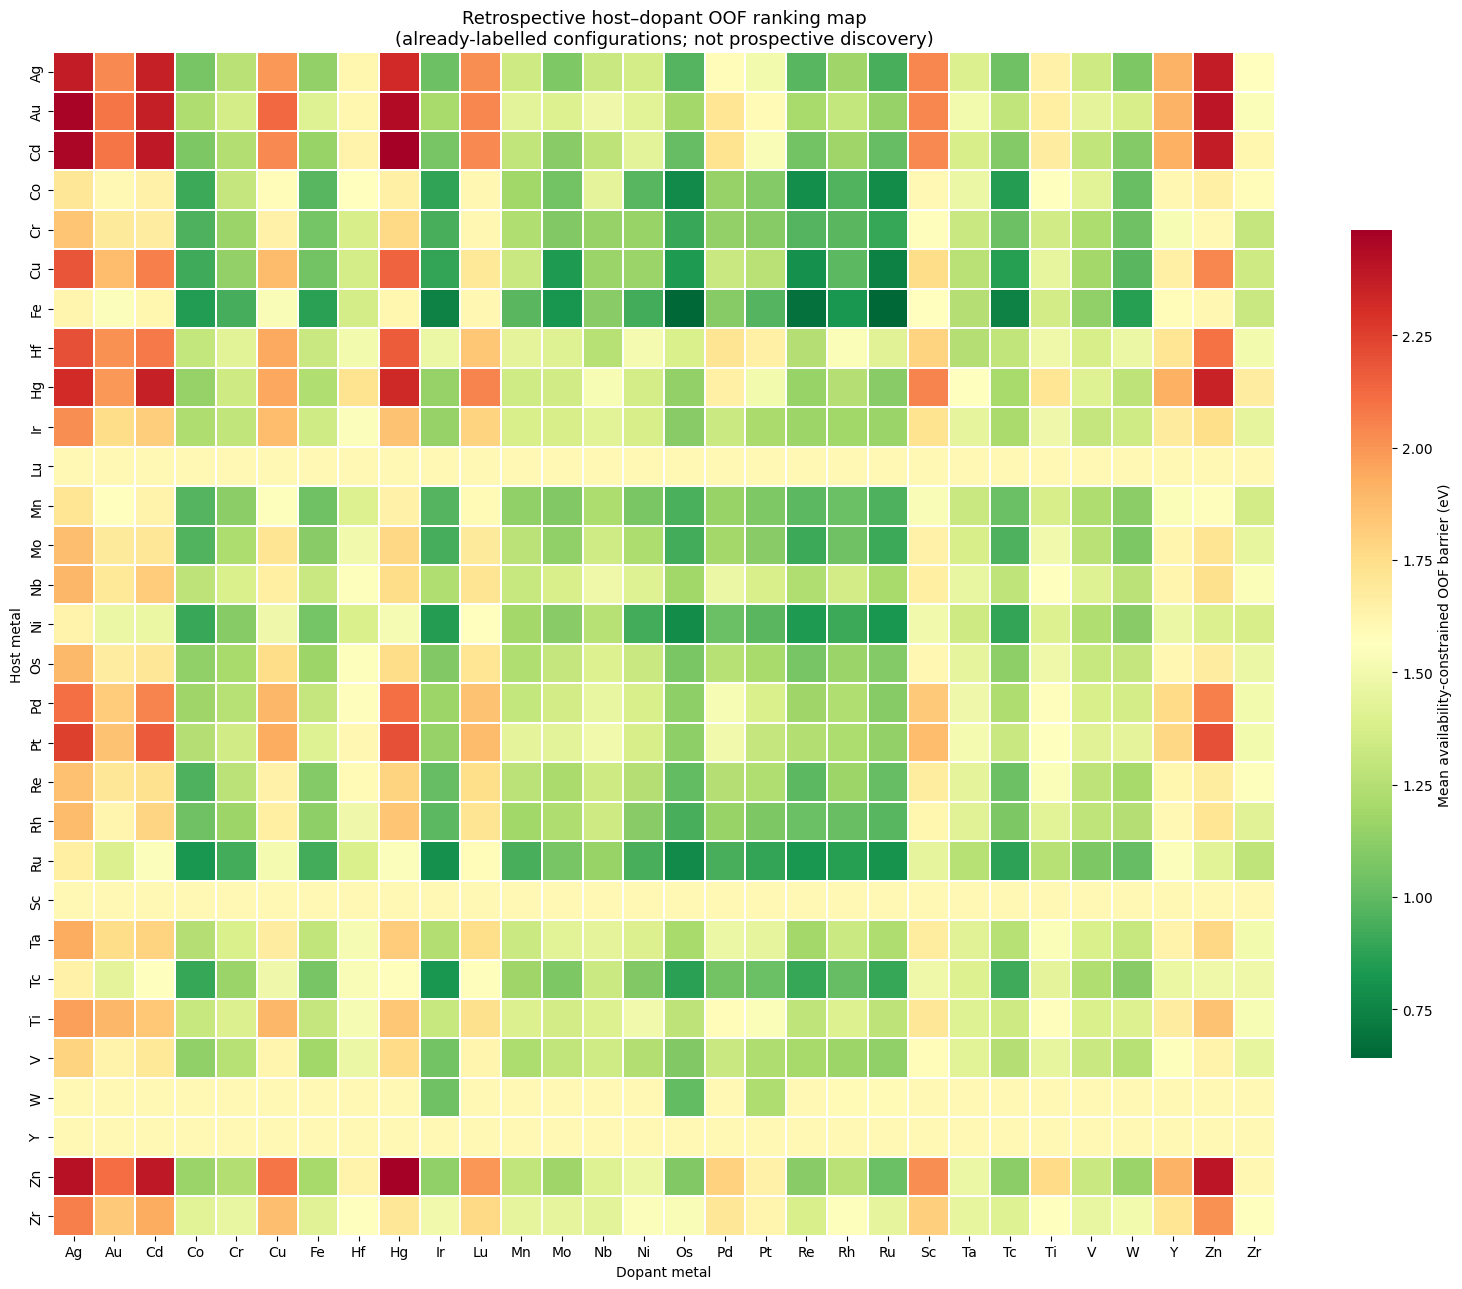

In [ ]:
print('=' * 55)
print('STEP 35 — RETROSPECTIVE OOF HOST–DOPANT RANKING MAP')
print('=' * 55)
MAP_VERSION = 'retrospective_map_v3_6'
map_ckpt = load_checkpoint('retrospective_oof_host_dopant_map_safe')
if (isinstance(map_ckpt, dict) and map_ckpt.get('version') == MAP_VERSION
        and map_ckpt.get('_complete') is True):
    pivot = map_ckpt['pivot']; best_pairs = map_ckpt['best_pairs']
else:
    screen_df = require_checkpoint('retrospective_oof_ranking_safe')['screen_df']
    pivot = screen_df.groupby(['Host', 'Doped'])['Pred_Barrier'].mean().unstack()
    best_pairs = screen_df.groupby(['Host', 'Doped'])['Pred_Barrier'].mean().sort_values().head(10)
    save_checkpoint({'version': MAP_VERSION, '_complete': True, 'pivot': pivot, 'best_pairs': best_pairs,
                     'scope': 'retrospective availability-constrained OOF predictions on labelled rows'},
                    'retrospective_oof_host_dopant_map_safe')
print('\nTOP 10 RETROSPECTIVELY RANKED HOST–DOPANT PAIRS (mean OOF prediction across labelled surfaces):')
print(best_pairs.round(4).to_string())
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(pivot, cmap='RdYlGn_r', annot=False, linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Mean availability-constrained OOF barrier (eV)', 'shrink': 0.7}, ax=ax)
ax.set_title('Retrospective host–dopant OOF ranking map\n'
             '(already-labelled configurations; not prospective discovery)', fontsize=13)
ax.set_xlabel('Dopant metal'); ax.set_ylabel('Host metal')
plt.tight_layout(); save_figure(fig, 'retrospective_oof_host_dopant_map_safe'); plt.show()


## Step 36 — Quantitative design rules  [NOT CHANGED]

In [ ]:
print('=' * 55)
print('STEP 36 — QUANTITATIVE DESIGN RULES')
print('=' * 55)

rules_ckpt = load_checkpoint('design_rules_raw_safe')

if rules_ckpt is not None:
    rules_table = rules_ckpt['rules_table']
    print('✓ Design rules loaded from Drive.')

else:
    # df_full is needed
    try:
        df_full
    except NameError:
        bvw_ckpt = load_checkpoint('best_vs_worst_raw_safe')
        if bvw_ckpt is None:
            print('ERROR: No data from Step 17. First run Step 17.')
            raise SystemExit
        df_full = bvw_ckpt['df_full']

    rules_rows = []

    wse_col = 'doped_weighted_surface_energy'
    if wse_col in df_full.columns:
        low_wse  = df_full[df_full[wse_col] <  2.5]['Barrier'].mean()
        high_wse = df_full[df_full[wse_col] >= 2.5]['Barrier'].mean()
        rules_rows.append({'Rule': 1,
            'Descriptor': 'Dopant surface energy',
            'Threshold':  'γ_w < 2.5 J/m²',
            'Effect':     f'{high_wse - low_wse:.3f} eV'})

    de_col = 'host_d-electron'
    if de_col in df_full.columns:
        low_de  = df_full[df_full[de_col] <= 6]['Barrier'].mean()
        high_de = df_full[df_full[de_col] >  6]['Barrier'].mean()
        rules_rows.append({'Rule': 2,
            'Descriptor': 'Host d-electron count',
            'Threshold':  'd-e > 6',
            'Effect':     f'{high_de - low_de:.3f} eV'})

    stepped  = ['_211', '_221', '_310', '_311', '_321', '_332']
    compact  = ['_100', '_110', '_111']
    step_bar = df_full[df_full['Surface'].isin(stepped)]['Barrier'].mean()
    comp_bar = df_full[df_full['Surface'].isin(compact)]['Barrier'].mean()
    rules_rows.append({'Rule': 3,
        'Descriptor': 'Surface type',
        'Threshold':  'Stepped over compact',
        'Effect':     f'{comp_bar - step_bar:.3f} eV'})

    if 'site1' in df_full.columns:
        hollow_bar = df_full[df_full['site1'] == 1]['Barrier'].mean()
        top_bar    = df_full[df_full['site1'] == 0]['Barrier'].mean()
        rules_rows.append({'Rule': 4,
            'Descriptor': 'Adsorption site',
            'Threshold':  'Hollow site preferred',
            'Effect':     f'{top_bar - hollow_bar:.3f} eV'})

    if 'delta_d_band' in df_full.columns:
        q1, q3  = df_full['delta_d_band'].quantile([0.25, 0.75])
        mid_bar = df_full[
            df_full['delta_d_band'].between(q1, q3)]['Barrier'].mean()
        ext_bar = df_full[
            ~df_full['delta_d_band'].between(q1, q3)]['Barrier'].mean()
        rules_rows.append({'Rule': 5,
            'Descriptor': 'd-band mismatch',
            'Threshold':  f'{q1:.2f}–{q3:.2f} eV optimal',
            'Effect':     'Avoid extremes'})

    if 'rd/rh' in df_full.columns:
        low_size  = df_full[df_full['rd/rh'] <  1.1]['Barrier'].mean()
        high_size = df_full[df_full['rd/rh'] >= 1.3]['Barrier'].mean()
        rules_rows.append({'Rule': 6,
            'Descriptor': 'Size mismatch',
            'Threshold':  'rd/rh < 1.3',
            'Effect':     'Avoid large mismatch'})

    rules_table = pd.DataFrame(rules_rows)
    save_checkpoint({'rules_table': rules_table}, 'design_rules_raw_safe')
    print('✓ Design rules saved to Drive.')

# ── df_full ensure───────────────────────────────────────────────────────
try:
    df_full
except NameError:
    bvw_ckpt = load_checkpoint('best_vs_worst_raw_safe')
    df_full  = bvw_ckpt['df_full']

# ── Always show results ───────────────────────────────────────────────────────
print('\nFINAL DESIGN RULES:')
print(rules_table.to_string(index=False))
save_csv(rules_table, 'design_rules_raw_safe')

STEP 36 — QUANTITATIVE DESIGN RULES
  ✓ Checkpoint loaded: design_rules_raw_safe
✓ Design rules loaded from Drive.

FINAL DESIGN RULES:
 Rule            Descriptor             Threshold               Effect
    1 Dopant surface energy        γ_w < 2.5 J/m²            -0.366 eV
    3          Surface type  Stepped over compact             0.018 eV
    4       Adsorption site Hollow site preferred             0.197 eV
    5       d-band mismatch -2.34–2.37 eV optimal       Avoid extremes
    6         Size mismatch           rd/rh < 1.3 Avoid large mismatch
  ✓ CSV + fingerprint sidecar saved: design_rules_raw_safe.csv


## Step 37 — Descriptor group ablation  [REVISED — now fold-fitted / held-out-isolated]


STEP 37 — DESCRIPTOR GROUP ABLATION (FOLD-FITTED / HELD-OUT-ISOLATED, LEAKAGE-SAFE)
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
Raw descriptor groups:
  Host descriptors          : 36 numeric + 0 categorical
  Dopant descriptors        : 32 numeric + 0 categorical
  Combined descriptors      : 10 numeric + 0 categorical
  Coordination (CN)         : 5 numeric + 0 categorical
  Site indicators           : 4 numeric + 0 categorical
  Engineered descriptors    : 6 numeric + 0 categorical
  Surface (categorical)     : 0 numeric + 1 categorical
  Size mismatch             : 4 numeric + 0 categorical
  Magpie host               : 132 numeric + 0 categorical
  Magpie dopant             : 132 numeric + 0 categorical
  Delta Magpie              : 132 numeric + 0 categorical
  CALPHAD Miedema           : 3 numeric + 0 categorical
  ✓ Checkpoint loaded: ablation_results_raw_safe
Valid completed leakage-safe ablation checkpoint loaded.
  ✓ CSV + fingerprint sidecar saved: ablation_results_raw_

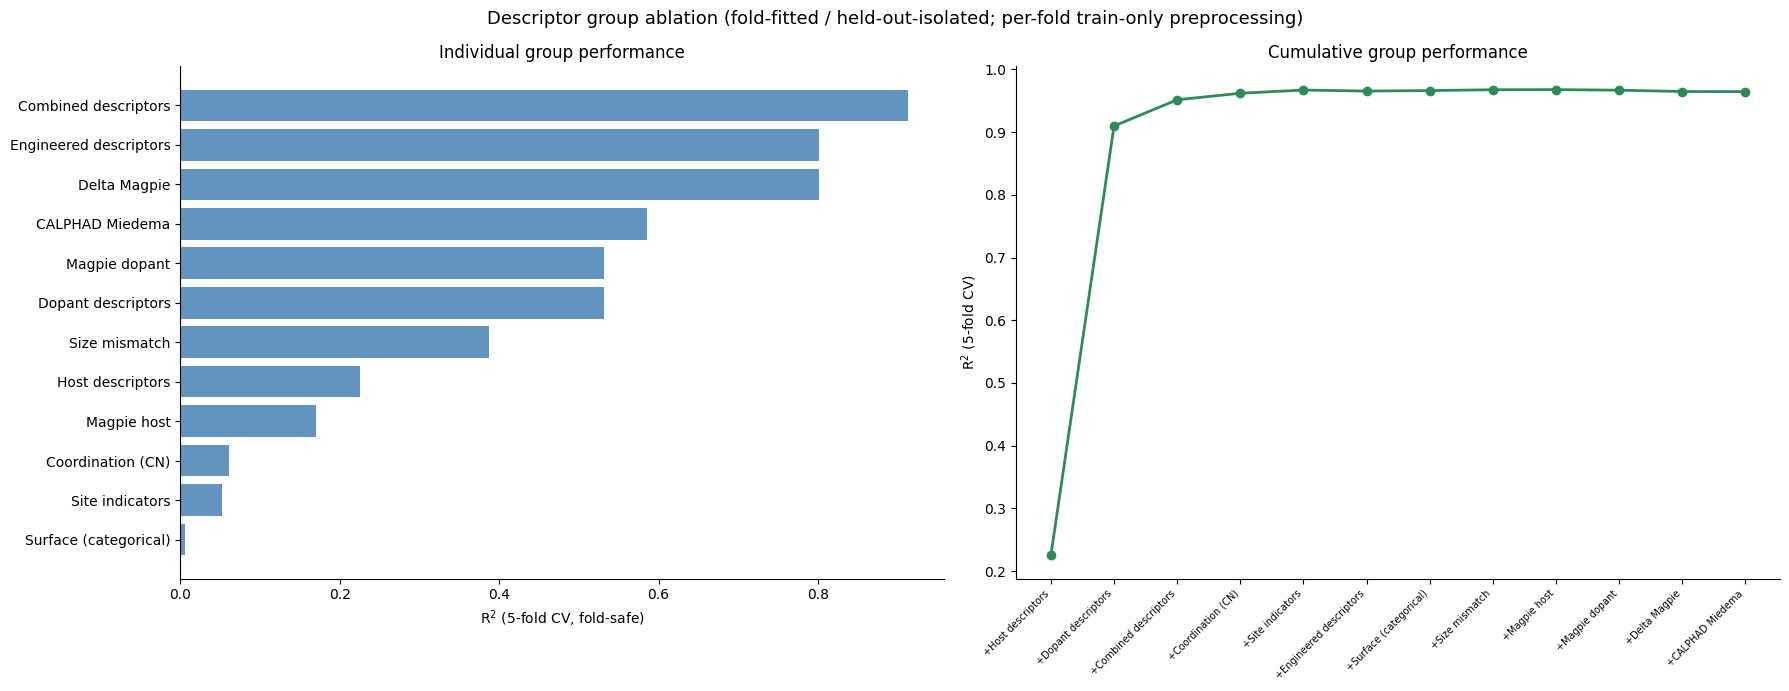

In [ ]:
print('=' * 55); print('STEP 37 — DESCRIPTOR GROUP ABLATION (FOLD-FITTED / HELD-OUT-ISOLATED, LEAKAGE-SAFE)'); print('=' * 55)
# Reviewer leakage fix: groups are defined over the RAW pool and every 5-fold split fits its
# own LeakageSafePreprocessor on TRAINING DATA ONLY (impute/clip/log/variance/correlation/
# target-correlation selection + OHE). No globally-selected X_arr is sliced here, so no
# target-selected feature or full-data statistic leaks across the CV split.
from sklearn.model_selection import KFold
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
def _num_group(pred): return [f for f in numeric_names if pred(f)]
raw_groups = {
    'Host descriptors':       (_num_group(lambda f: f.startswith('host_') and not f.startswith('host_magpie_')), []),
    'Dopant descriptors':     (_num_group(lambda f: f.startswith('doped_') and not f.startswith('doped_magpie_')), []),
    'Combined descriptors':   (_num_group(lambda f: f.startswith('com_')), []),
    'Coordination (CN)':      (_num_group(lambda f: f.startswith('CN')), []),
    'Site indicators':        (_num_group(lambda f: f.startswith('site')), []),
    'Engineered descriptors': (_num_group(lambda f: f in ['delta_d_band', 'delta_electroneg', 'delta_efermi',
                                                          'delta_cohesive', 'delta_surface_energy', 'rd_rh_sq']), []),
    'Surface (categorical)':  ([], [c for c in cat_names if c == 'Surface']),
    'Size mismatch':          (_num_group(lambda f: f in ['area_fraction', 'rd-rh', 'rd/rh', 'rd_rh_sq']), []),
    'Magpie host':            (_num_group(lambda f: f.startswith('host_magpie_')), []),
    'Magpie dopant':          (_num_group(lambda f: f.startswith('doped_magpie_')), []),
    'Delta Magpie':           (_num_group(lambda f: f.startswith('delta_magpie_')), []),
    'CALPHAD Miedema':        (_num_group(lambda f: f.startswith('calphad_')), []),
}
raw_groups = {k: v for k, v in raw_groups.items() if (v[0] or v[1])}
print('Raw descriptor groups:')
for k, (gn, gc) in raw_groups.items():
    print(f'  {k:26s}: {len(gn)} numeric + {len(gc)} categorical')
def _cv_eval(group_numeric, group_cat):
    """5-fold CV; preprocessor fit on TRAIN ONLY, restricted to the group's raw columns."""
    r2s, maes, rmses, nsel = [], [], [], []
    for tr, te in KFold(5, shuffle=True, random_state=SEED).split(X_pre_df):
        prep = LeakageSafePreprocessor(group_numeric, group_cat, original_feature_set).fit(
            X_pre_df.iloc[tr], y_barrier[tr])
        Xtr = prep.transform(X_pre_df.iloc[tr]); Xte = prep.transform(X_pre_df.iloc[te])
        if Xtr.shape[1] == 0:
            return None
        m = compute_metrics(y_barrier[te], make_rf(SEED).fit(Xtr, y_barrier[tr]).predict(Xte))
        r2s.append(m['R2']); maes.append(m['MAE']); rmses.append(m['RMSE']); nsel.append(Xtr.shape[1])
    return {'R2': round(float(np.mean(r2s)), 4), 'MAE': round(float(np.mean(maes)), 4),
            'RMSE': round(float(np.mean(rmses)), 4), 'mean_selected': int(np.mean(nsel))}
ablation_ckpt = load_checkpoint('ablation_results_raw_safe')
if (
    isinstance(ablation_ckpt, dict)
    and ablation_ckpt.get('version') == 'fold_fitted_fixed_hp_v3_5'
    and ablation_ckpt.get('_complete') is True
    and isinstance(ablation_ckpt.get('ablation_df'), pd.DataFrame)
    and not ablation_ckpt['ablation_df'].empty
    and {'Individual', 'Cumulative'}.issubset(set(ablation_ckpt['ablation_df']['Type']))
):
    ablation_df = ablation_ckpt['ablation_df']
    print('Valid completed leakage-safe ablation checkpoint loaded.')
else:
    results = []
    print('\nIndividual group ablation (fold-safe):')
    for gname, (gn, gc) in raw_groups.items():
        r = _cv_eval(gn, gc)
        if r is None: continue
        results.append({'Group': gname, 'Type': 'Individual', 'N_feats': len(gn) + len(gc),
                        'mean_selected': r['mean_selected'], 'R2': r['R2'], 'MAE': r['MAE'], 'RMSE': r['RMSE']})
        print(f'  {gname:26s}: R2={r["R2"]:.4f}  MAE={r["MAE"]:.4f} eV  (raw {len(gn)+len(gc)}, sel~{r["mean_selected"]})')
    print('\nCumulative group ablation (fold-safe):')
    cum_num, cum_cat, cum_names = [], [], []
    for gname, (gn, gc) in raw_groups.items():
        cum_num = list(dict.fromkeys(cum_num + gn)); cum_cat = list(dict.fromkeys(cum_cat + gc)); cum_names.append(gname)
        r = _cv_eval(cum_num, cum_cat)
        if r is None: continue
        results.append({'Group': ' + '.join(cum_names), 'Type': 'Cumulative', 'N_feats': len(cum_num) + len(cum_cat),
                        'mean_selected': r['mean_selected'], 'R2': r['R2'], 'MAE': r['MAE'], 'RMSE': r['RMSE']})
    ablation_df = pd.DataFrame(results)
    save_checkpoint({'ablation_df': ablation_df, 'version': 'fold_fitted_fixed_hp_v3_5', '_complete': True},
                    'ablation_results_raw_safe')
save_csv(ablation_df, 'ablation_results_raw_safe')
indiv = ablation_df[ablation_df['Type'] == 'Individual'].sort_values('R2', ascending=False)
cumul = ablation_df[ablation_df['Type'] == 'Cumulative']
print('\nABLATION — INDIVIDUAL GROUPS (fold-safe):'); print(indiv[['Group', 'N_feats', 'R2', 'MAE']].to_string(index=False))
print('\nABLATION — CUMULATIVE (fold-safe):'); print(cumul[['Group', 'N_feats', 'R2', 'MAE']].to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
iv = indiv.sort_values('R2')
axes[0].barh(iv['Group'], iv['R2'], color='steelblue', alpha=0.85)
axes[0].set_xlabel('R$^2$ (5-fold CV, fold-safe)'); axes[0].set_title('Individual group performance')
axes[0].axvline(0, color='gray', ls='--', lw=0.8)
axes[1].plot(range(len(cumul)), cumul['R2'], marker='o', color='seagreen', lw=2)
axes[1].set_xticks(range(len(cumul))); axes[1].set_xticklabels([f'+{g.split(" + ")[-1]}' for g in cumul['Group']],
    rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('R$^2$ (5-fold CV)'); axes[1].set_title('Cumulative group performance')
for sp in ['top', 'right']:
    axes[0].spines[sp].set_visible(False); axes[1].spines[sp].set_visible(False)
plt.suptitle('Descriptor group ablation (fold-fitted / held-out-isolated; per-fold train-only preprocessing)', fontsize=13)
plt.tight_layout(); save_figure(fig, 'ablation_feature_groups'); plt.show()


## Step 38 — Held-out fold permutation importance  [REVISED]

STEP 38 — HELD-OUT FOLD PERMUTATION IMPORTANCE
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: permutation_importance_raw_safe
  ✓ Checkpoint loaded: feature_importance_raw_safe
  ✓ Checkpoint loaded: shap_values_rf_raw_safe
  ✓ Checkpoint saved: permutation_importance_raw_safe
  ✓ CSV + fingerprint sidecar saved: permutation_importance_fold_level_safe.csv
  ✓ CSV + fingerprint sidecar saved: permutation_importance_raw_safe.csv
  ✓ CSV + fingerprint sidecar saved: descriptor_consensus_ranking.csv

TOP 20 — held-out fold permutation importance:
                                       feature  perm_importance_mean  perm_importance_std  n_folds_observed
                                         site1              0.019520             0.002236                 5
                 doped_weighted_surface_energy              0.019271             0.003133                 5
                         doped_cohesive_energy              0.009878             0.001581              

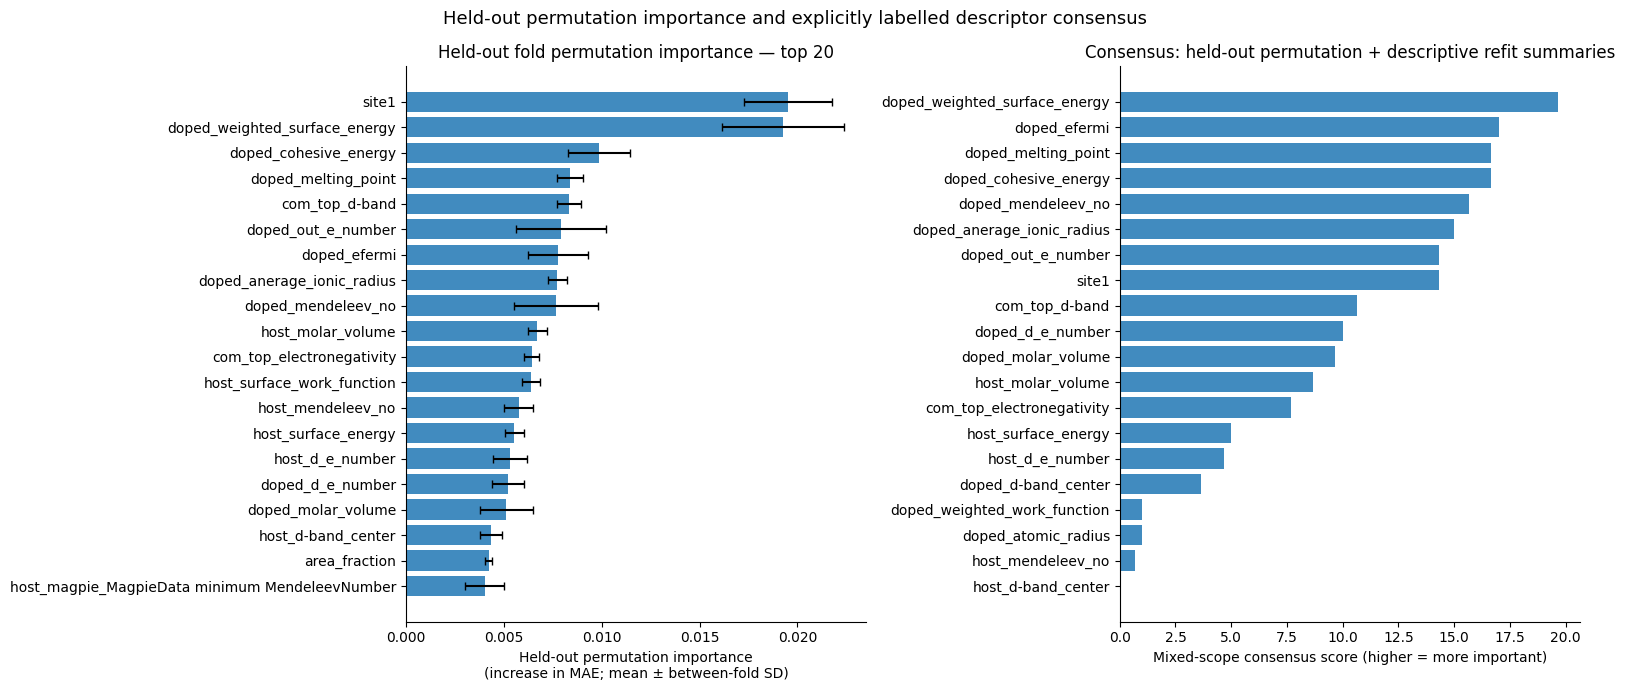

Physical-mechanism note: importance rankings are associative model interpretations, not causal proof.


In [ ]:
print('=' * 55)
print('STEP 38 — HELD-OUT FOLD PERMUTATION IMPORTANCE')
print('=' * 55)

from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold
import time

PERM_VERSION = 'heldout_fold_perm_v3_7'
PERM_REPEATS = 5
MAX_TEST_SAMPLES_PER_FOLD = 1000
PERM_SCORING = 'neg_mean_absolute_error'
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
perm_splits = list(KFold(5, shuffle=True, random_state=SEED).split(X_pre_df))

def _new_perm_checkpoint():
    return {
        'version': PERM_VERSION,
        'scope': 'outer-test-fold permutation importance; preprocessing and RF fitted on outer training fold only',
        'model_configuration': MODEL_HYPERPARAMETER_POLICY['RF']['configuration'],
        'scoring': PERM_SCORING,
        'n_repeats': PERM_REPEATS,
        'max_test_samples_per_fold': MAX_TEST_SAMPLES_PER_FOLD,
        'fold_rows': [],
        'fold_summaries': [],
        '_done_folds': [],
        '_complete': False,
    }

def _repair_perm_checkpoint(obj):
    if not isinstance(obj, dict) or obj.get('version') != PERM_VERSION:
        return _new_perm_checkpoint()
    rows = obj.get('fold_rows', [])
    summaries = obj.get('fold_summaries', [])
    done = obj.get('_done_folds', [])
    if not isinstance(rows, list) or not isinstance(summaries, list) or not isinstance(done, list):
        return _new_perm_checkpoint()
    clean_rows, clean_summaries, clean_done = [], [], []
    for fold in sorted(set(done) & set(range(5))):
        fr = [r for r in rows if isinstance(r, dict) and int(r.get('fold', -1)) == fold]
        fs = [r for r in summaries if isinstance(r, dict) and int(r.get('fold', -1)) == fold]
        if len(fr) > 0 and len(fs) == 1:
            clean_rows.extend(fr)
            clean_summaries.extend(fs)
            clean_done.append(fold)
    obj['fold_rows'] = clean_rows
    obj['fold_summaries'] = clean_summaries
    obj['_done_folds'] = clean_done
    obj['_complete'] = False
    return obj

perm_ckpt = _repair_perm_checkpoint(
    load_checkpoint('permutation_importance_raw_safe'))

for fold, (tr, te) in enumerate(perm_splits):
    if fold in perm_ckpt['_done_folds']:
        continue
    prep = LeakageSafePreprocessor(
        numeric_names, cat_names, original_feature_set).fit(
            X_pre_df.iloc[tr], y_barrier[tr])
    Xtr = prep.transform(X_pre_df.iloc[tr])
    Xte = prep.transform(X_pre_df.iloc[te])
    fold_feature_names = list(prep.kept_cols)
    if Xtr.shape[1] != len(fold_feature_names):
        raise RuntimeError(f'Fold {fold}: transformed feature-name mismatch.')

    rng_perm = np.random.RandomState(SEED + 3800 + fold)
    if len(te) > MAX_TEST_SAMPLES_PER_FOLD:
        pos = np.sort(rng_perm.choice(
            len(te), MAX_TEST_SAMPLES_PER_FOLD, replace=False))
        Xte_eval = Xte[pos]
        yte_eval = np.asarray(y_barrier[te])[pos]
    else:
        Xte_eval = Xte
        yte_eval = np.asarray(y_barrier[te])

    rf_fold = make_rf(SEED).fit(Xtr, y_barrier[tr])
    print(f'Fold {fold + 1}/5: held-out permutation importance on '
          f'{len(yte_eval)} test samples and {Xte_eval.shape[1]} selected features...')
    t0 = time.time()
    result = permutation_importance(
        rf_fold, Xte_eval, yte_eval,
        scoring=PERM_SCORING,
        n_repeats=PERM_REPEATS,
        random_state=SEED + 3800 + fold,
        n_jobs=-1,
    )
    for feature, mean_imp, std_imp in zip(
            fold_feature_names,
            result.importances_mean,
            result.importances_std):
        perm_ckpt['fold_rows'].append({
            'fold': int(fold),
            'seed': int(SEED),
            'feature': str(feature),
            'perm_importance_mean': float(mean_imp),
            'perm_importance_repeat_std': float(std_imp),
            'n_train': int(len(tr)),
            'n_test_full': int(len(te)),
            'n_test_evaluated': int(len(yte_eval)),
            'selected_feature_count': int(Xtr.shape[1]),
            'scoring': PERM_SCORING,
        })
    perm_ckpt['fold_summaries'].append({
        'fold': int(fold),
        'seed': int(SEED),
        'n_train': int(len(tr)),
        'n_test_full': int(len(te)),
        'n_test_evaluated': int(len(yte_eval)),
        'selected_feature_count': int(Xtr.shape[1]),
        'elapsed_seconds': float(time.time() - t0),
    })
    perm_ckpt['_done_folds'].append(fold)
    save_checkpoint(perm_ckpt, 'permutation_importance_raw_safe')

perm_ckpt['_complete'] = (
    set(perm_ckpt['_done_folds']) == set(range(5))
    and len(perm_ckpt['fold_summaries']) == 5
    and len(perm_ckpt['fold_rows']) > 0
)
if not perm_ckpt['_complete']:
    save_checkpoint(perm_ckpt, 'permutation_importance_raw_safe')
    raise RuntimeError('Held-out permutation-importance checkpoint is incomplete.')

fold_perm_df = pd.DataFrame(perm_ckpt['fold_rows'])
if fold_perm_df.duplicated(['fold', 'feature']).any():
    raise RuntimeError('Duplicate fold-feature rows in permutation-importance checkpoint.')

perm_df = (
    fold_perm_df.groupby('feature', as_index=False)
    .agg(
        perm_importance_mean=('perm_importance_mean', 'mean'),
        perm_importance_std=('perm_importance_mean', 'std'),
        within_fold_repeat_std_mean=('perm_importance_repeat_std', 'mean'),
        n_folds_observed=('fold', 'nunique'),
        total_test_samples_evaluated=('n_test_evaluated', 'sum'),
    )
)
perm_df['perm_importance_std'] = perm_df['perm_importance_std'].fillna(0.0)
perm_df['scoring'] = PERM_SCORING
perm_df['interpretation_scope'] = (
    'held-out outer-test folds; positive value means permutation increased MAE')
perm_df = perm_df.sort_values(
    ['perm_importance_mean', 'n_folds_observed'],
    ascending=[False, False]).reset_index(drop=True)

fi_ckpt = load_checkpoint('feature_importance_raw_safe')
if fi_ckpt is not None:
    fi_rf = fi_ckpt['fi_rf']
    mdi_df = fi_rf.reset_index()
    mdi_df.columns = ['feature', 'mdi_importance']
else:
    mdi_df = pd.DataFrame({
        'feature': feature_names,
        'mdi_importance': rf_final_barrier.feature_importances_,
    })

shap_ckpt_rf = load_checkpoint('shap_values_rf_raw_safe')
if (isinstance(shap_ckpt_rf, dict)
        and shap_ckpt_rf.get('version') == 'interpretation_rng_v3_7'
        and shap_ckpt_rf.get('_complete') is True):
    shap_values_rf = np.asarray(shap_ckpt_rf['shap_values_rf_raw_safe'])
    shap_df = pd.DataFrame({
        'feature': list(shap_ckpt_rf['X_sample'].columns),
        'shap_importance': np.abs(shap_values_rf).mean(axis=0),
    })
else:
    shap_df = pd.DataFrame(columns=['feature', 'shap_importance'])

mdi_rank = mdi_df.set_index('feature')['mdi_importance'].rank(
    ascending=False, method='average')
perm_rank = perm_df.set_index('feature')['perm_importance_mean'].rank(
    ascending=False, method='average')
consensus = pd.concat([
    mdi_rank.rename('MDI_rank_descriptive_refit'),
    perm_rank.rename('Permutation_rank_heldout'),
], axis=1)
if not shap_df.empty:
    shap_rank = shap_df.set_index('feature')['shap_importance'].rank(
        ascending=False, method='average')
    consensus = consensus.join(
        shap_rank.rename('SHAP_rank_descriptive_refit'), how='outer')
consensus['n_methods_available'] = consensus.notna().sum(axis=1)
rank_cols = [c for c in consensus.columns
             if c.endswith('rank_heldout') or c.endswith('rank_descriptive_refit')]
consensus['Mean_rank'] = consensus[rank_cols].mean(axis=1, skipna=True)
consensus['scope_warning'] = (
    'Permutation component is held-out; MDI/SHAP components are descriptive full-data-refit summaries.')
consensus_df = (
    consensus.sort_values(
        ['Mean_rank', 'n_methods_available'],
        ascending=[True, False])
    .reset_index()
    .rename(columns={'index': 'feature'})
)
consensus_df.insert(0, 'Consensus_rank', range(1, len(consensus_df) + 1))

perm_ckpt.update({
    'perm_df': perm_df,
    'fold_perm_df': fold_perm_df,
    'consensus_df': consensus_df,
    '_complete': True,
})
save_checkpoint(perm_ckpt, 'permutation_importance_raw_safe')
save_csv(fold_perm_df, 'permutation_importance_fold_level_safe')
save_csv(perm_df, 'permutation_importance_raw_safe')
save_csv(consensus_df, 'descriptor_consensus_ranking')

print('\nTOP 20 — held-out fold permutation importance:')
print(perm_df.head(20)[[
    'feature', 'perm_importance_mean', 'perm_importance_std',
    'n_folds_observed'
]].to_string(index=False))
print('\nTOP 20 — mixed-scope consensus descriptor ranking:')
print(consensus_df.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top20_perm = perm_df.head(20).sort_values('perm_importance_mean')
axes[0].barh(
    top20_perm['feature'],
    top20_perm['perm_importance_mean'],
    xerr=top20_perm['perm_importance_std'],
    alpha=0.85,
    capsize=3,
)
axes[0].set_xlabel('Held-out permutation importance\n(increase in MAE; mean ± between-fold SD)')
axes[0].set_title('Held-out fold permutation importance — top 20')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

top20_cons = consensus_df.head(20).sort_values(
    'Mean_rank', ascending=False)
axes[1].barh(
    top20_cons['feature'],
    top20_cons['Mean_rank'].max() - top20_cons['Mean_rank'],
    alpha=0.85,
)
axes[1].set_xlabel('Mixed-scope consensus score (higher = more important)')
axes[1].set_title('Consensus: held-out permutation + descriptive refit summaries')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Held-out permutation importance and explicitly labelled descriptor consensus',
             fontsize=13)
plt.tight_layout()
save_figure(fig, 'permutation_importance_consensus')
plt.show()
print('Physical-mechanism note: importance rankings are associative model interpretations, not causal proof.')


## Step 39 — Proxy-based stability prioritization (retrospective)  [REVISED]

STEP 39 — PROXY-BASED RETROSPECTIVE PRIORITIZATION (NOT STABILITY)
All configurations already carry labels in the Sun et al. dataset. This is a retrospective ranking exercise; no new DFT or experimental validation was performed. Bulk mixing enthalpy and descriptor-based proxy scores are prioritization proxies only and do not establish resistance to segregation, aggregation, reconstruction, or synthesis feasibility.
  ✓ Checkpoint loaded: retrospective_oof_ranking_safe
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint saved: stability_proxy_ranking_oof_safe
  ✓ CSV + fingerprint sidecar saved: stability_proxy_prioritized_rows_safe.csv

TOP 20 RETROSPECTIVELY PRIORITIZED LABELLED CONFIGURATIONS (PROXY):
Host Doped Surface  DFT_Barrier  Pred_Barrier  Uncertainty  prioritization_score
  Ru    Ru    _212     0.802875      0.790808     0.037351              0.199125
  Ru    Ru    _211     0.782735      0.777972     0.041325              0.203209
  Tc    Tc    _212     0.921044  

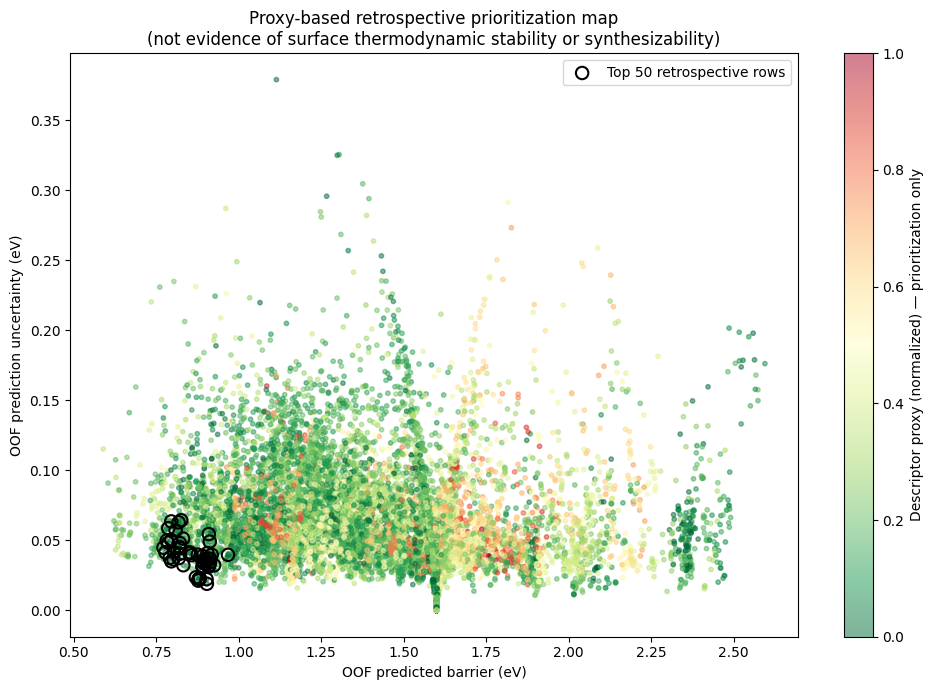

In [ ]:
print('=' * 55); print('STEP 39 — PROXY-BASED RETROSPECTIVE PRIORITIZATION (NOT STABILITY)'); print('=' * 55)
# Retrospective ranking of already-labelled configurations, not discovery and not a
# stability claim. Fixed proxy descriptors are read directly from the raw pool; no
# full-data target-selected deployed matrix is used.
DISCLAIMER = (
    "All configurations already carry labels in the Sun et al. dataset. This is a retrospective "
    "ranking exercise; no new DFT or experimental validation was performed. Bulk mixing enthalpy "
    "and descriptor-based proxy scores are prioritization proxies only and do not establish "
    "resistance to segregation, aggregation, reconstruction, or synthesis feasibility.")
print(DISCLAIMER)
from sklearn.preprocessing import MinMaxScaler
PROXY_VERSION = 'retrospective_proxy_v3_6'
screen_df = require_checkpoint('retrospective_oof_ranking_safe')['screen_df'].copy()
X_raw_proxy, raw_numeric_names, _, _ = load_raw_pool()

# Fixed, target-independent proxy definitions. Missing values are filled only for this
# descriptive ranking using the raw-column median; this is not a predictive validation step.
proxy_defs = {
    'abs_delta_cohesive': ('delta_cohesive', 'absolute'),
    'abs_delta_surf_energy': ('delta_surface_energy', 'absolute'),
    'abs_rd_rh': ('rd-rh', 'absolute'),
    'rd_rh_dev': ('rd/rh', 'distance_from_one'),
}
screen_full = screen_df.copy()
used_proxy_columns = []
for out_col, (raw_col, operation) in proxy_defs.items():
    if raw_col not in X_raw_proxy.columns:
        continue
    vals = pd.to_numeric(X_raw_proxy[raw_col], errors='coerce').replace([np.inf, -np.inf], np.nan)
    med = float(vals.median()) if vals.notna().any() else 0.0
    vals = vals.fillna(med).to_numpy(float)
    screen_full[out_col] = np.abs(vals - 1.0) if operation == 'distance_from_one' else np.abs(vals)
    used_proxy_columns.append(out_col)

screen_full['proxy_raw'] = screen_full[used_proxy_columns].mean(axis=1) if used_proxy_columns else 0.0
scaler = MinMaxScaler()
for src, dst in [('Pred_Barrier', 'norm_barrier'), ('Uncertainty', 'norm_uncertainty'),
                 ('proxy_raw', 'norm_proxy')]:
    screen_full[dst] = scaler.fit_transform(screen_full[[src]]).ravel()
screen_full['prioritization_score'] = (
    screen_full['norm_barrier'] + screen_full['norm_uncertainty'] + screen_full['norm_proxy'])
top50 = screen_full.sort_values('prioritization_score').head(50).copy()
top50['status'] = (
    'Already-labelled heterogeneous configuration retrospectively prioritized for independent '
    'follow-up; synthesis feasibility and surface stability remain unverified.')
proxy_ckpt = {
    'version': PROXY_VERSION, '_complete': True, 'top50': top50,
    'screen_full': screen_full, 'used_proxy_columns': used_proxy_columns,
    'disclaimer': DISCLAIMER,
}
save_checkpoint(proxy_ckpt, 'stability_proxy_ranking_oof_safe')
save_csv(top50, 'stability_proxy_prioritized_rows_safe')
print('\nTOP 20 RETROSPECTIVELY PRIORITIZED LABELLED CONFIGURATIONS (PROXY):')
cols = [c for c in ['Host', 'Doped', 'Surface', 'DFT_Barrier', 'Pred_Barrier',
                    'Uncertainty', 'prioritization_score'] if c in top50.columns]
print(top50[cols].head(20).to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(screen_full['Pred_Barrier'], screen_full['Uncertainty'],
    c=screen_full['norm_proxy'], cmap='RdYlGn_r', alpha=0.5, s=10, rasterized=True)
plt.colorbar(sc, ax=ax, label='Descriptor proxy (normalized) — prioritization only')
ax.scatter(top50['Pred_Barrier'], top50['Uncertainty'], s=80, facecolors='none',
           edgecolors='black', linewidths=1.5, label='Top 50 retrospective rows')
ax.set_xlabel('OOF predicted barrier (eV)'); ax.set_ylabel('OOF prediction uncertainty (eV)')
ax.set_title('Proxy-based retrospective prioritization map\n'
             '(not evidence of surface thermodynamic stability or synthesizability)')
ax.legend(); plt.tight_layout(); save_figure(fig, 'stability_proxy_prioritization_map_safe'); plt.show()


## Step 40 — Out-of-fold uncertainty + calibration  [REVISED]


STEP 40 — OUT-OF-FOLD UNCERTAINTY + CALIBRATION (FOLD-FITTED, RESUMABLE)
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: uncertainty_oof_fully_nested_safe
  5fold: already complete and validated, skipping.
  LOHO: already complete and validated, skipping.
  LOSO: already complete and validated, skipping.
  LODO: already complete and validated, skipping.
  ✓ Checkpoint saved: uncertainty_oof_fully_nested_safe
  ✓ CSV + fingerprint sidecar saved: uncertainty_calibration_summary_safe.csv
  ✓ CSV + fingerprint sidecar saved: uncertainty_reliability_bins_safe.csv

Calibration summary:
protocol  n_samples  r_sigma_err  coverage_1sigma  coverage_2sigma     ECE  n_bins  min_bin_n                    binning_method
   5fold      10950       0.6175           0.7879           0.9738 0.01071      10       1095 rank-quantile, mutually exclusive
    LOHO      10950       0.3933           0.8144           0.9787 0.03143      10       1095 rank-quantile, mutually exclusive
    LO

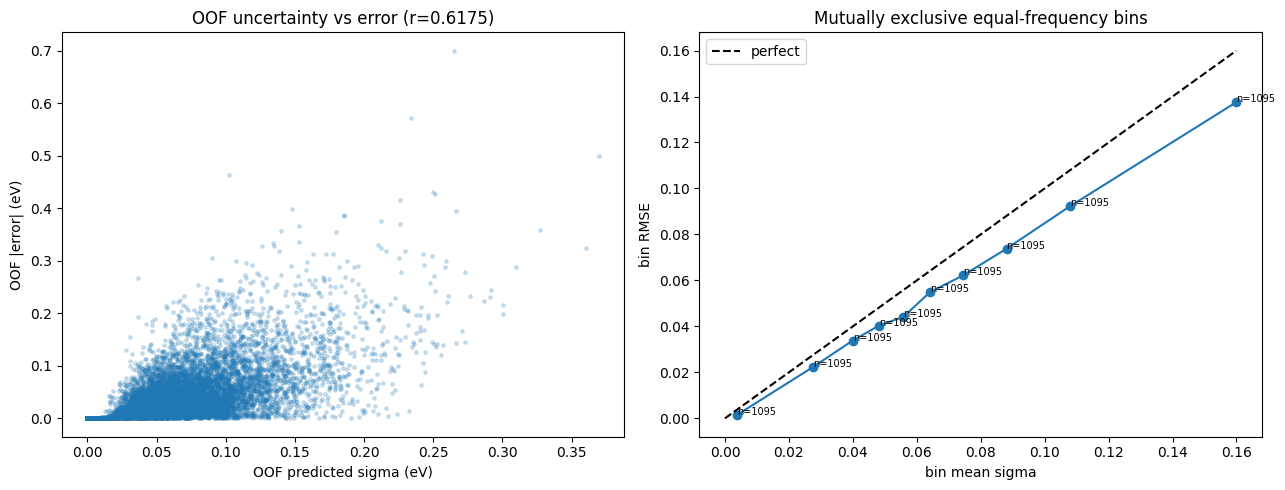

In [ ]:
print('=' * 55); print('STEP 40 — OUT-OF-FOLD UNCERTAINTY + CALIBRATION (FOLD-FITTED, RESUMABLE)'); print('=' * 55)
from sklearn.model_selection import KFold
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
_p = f'{SAVE_DIR}/Database.csv'; doped_labels = pd.read_csv(_p)['Doped'].values if os.path.exists(_p) else None
UNC_VERSION = 'fully_nested_raw_safe_v3_4'
EXPECTED_PROTOCOLS = ['5fold', 'LOHO', 'LOSO', 'LODO']
MIN_BIN_SIZE = 30
if doped_labels is None:
    raise FileNotFoundError('Database.csv with the Doped column is required for LODO uncertainty calibration.')
def oof_rf(split_iter):
    P = np.full(len(y_barrier), np.nan); S = np.full(len(y_barrier), np.nan)
    for tr, te in split_iter:
        Xtr_df = X_pre_df[tr] if getattr(tr, 'dtype', None) == bool else X_pre_df.iloc[tr]
        Xte_df = X_pre_df[te] if getattr(te, 'dtype', None) == bool else X_pre_df.iloc[te]
        ytr = y_barrier[tr]
        prep = LeakageSafePreprocessor(numeric_names, cat_names, original_feature_set).fit(Xtr_df, ytr)
        Xtr = prep.transform(Xtr_df)
        Xte = prep.transform(Xte_df)  # transform once, then reuse for all trees
        rf = make_rf(SEED).fit(Xtr, ytr)
        tp = np.array([t.predict(Xte) for t in rf.estimators_])
        P[te] = tp.mean(0); S[te] = tp.std(0)
    if not (np.isfinite(P).all() and np.isfinite(S).all()):
        raise RuntimeError('OOF uncertainty arrays do not cover every sample exactly once.')
    return np.asarray(y_barrier, float).copy(), P, S
def kfold_splits():
    for tr, te in KFold(5, shuffle=True, random_state=SEED).split(X_pre_df): yield tr, te
def group_splits(labels):
    for g in np.unique(labels): yield (labels != g), (labels == g)
def calib_report(true, pred, std, tag):
    true, pred, std = map(lambda x: np.asarray(x, float), (true, pred, std))
    N = len(std)
    if N < 2 or np.std(std) == 0:
        return {'tag': tag, 'n_samples': N, 'r': np.nan, 'cov1': np.nan, 'cov2': np.nan,
                'ECE': np.nan, 'n_bins': 0, 'min_bin_n': 0, 'reliability': []}
    err = np.abs(pred - true); r = np.corrcoef(std, err)[0, 1]
    cov1 = float((err <= std).mean()); cov2 = float((err <= 2 * std).mean())
    n_bins = max(2, min(10, N // MIN_BIN_SIZE))
    # Rank-qcut assigns every sample to exactly one equal-frequency bin, including tied sigmas.
    ranks = pd.Series(std).rank(method='first')
    bin_id = pd.qcut(ranks, q=n_bins, labels=False, duplicates='drop').to_numpy()
    rows = []; ece = 0.0
    for j in sorted(np.unique(bin_id)):
        m = bin_id == j; n = int(m.sum())
        bs = float(std[m].mean()); brmse = float(np.sqrt(np.mean((pred[m] - true[m]) ** 2)))
        bmae = float(np.mean(err[m]))
        rows.append({'protocol': tag, 'bin_id': int(j), 'n': n, 'sigma_min': float(std[m].min()),
            'sigma_max': float(std[m].max()), 'mean_sigma': bs, 'bin_RMSE': brmse,
            'bin_MAE': bmae})
        ece += n / N * abs(brmse - bs)
    assert sum(x['n'] for x in rows) == N, 'uncertainty bins must partition samples exactly once'
    min_bin_n = min(x['n'] for x in rows) if rows else 0
    ms = np.average([x['mean_sigma'] for x in rows], weights=[x['n'] for x in rows])
    mr = np.average([x['bin_RMSE'] for x in rows], weights=[x['n'] for x in rows])
    direction = 'sigma UNDER-predicts error (overconfident)' if mr > ms else 'sigma OVER-predicts error (underconfident)'
    print(f'[{tag}] N={N} bins={len(rows)} min_bin={min_bin_n} r={r:.3f} ECE={ece:.4f} | {direction}')
    return {'tag': tag, 'n_samples': N, 'r': round(float(r), 4), 'cov1': round(cov1, 4),
            'cov2': round(cov2, 4), 'ECE': round(float(ece), 5), 'n_bins': int(len(rows)),
            'min_bin_n': int(min_bin_n), 'binning_method': 'rank-quantile, mutually exclusive',
            'reliability': rows}
calib = load_checkpoint('uncertainty_oof_fully_nested_safe')
def _protocol_payload_valid(ck, proto):
    arrays = ck.get(f'{proto}_arrays'); metrics = ck.get(proto)
    if not isinstance(metrics, dict) or not isinstance(arrays, dict):
        return False
    if not {'true', 'pred', 'std'}.issubset(arrays):
        return False
    try:
        arrays_np = {k: np.asarray(arrays[k], float) for k in ('true', 'pred', 'std')}
    except Exception:
        return False
    rel = metrics.get('reliability', [])
    if not isinstance(rel, list):
        return False
    if not all(v.ndim == 1 and len(v) == len(y_barrier) for v in arrays_np.values()):
        return False
    if not all(np.isfinite(v).all() for v in arrays_np.values()):
        return False
    if not (arrays_np['std'] >= 0).all():
        return False
    if not np.allclose(arrays_np['true'], np.asarray(y_barrier, float), equal_nan=False):
        return False
    if int(metrics.get('n_samples', -1)) != len(y_barrier):
        return False
    if sum(int(x.get('n', 0)) for x in rel) != len(y_barrier):
        return False
    if int(metrics.get('n_bins', -1)) != len(rel):
        return False
    if rel and int(metrics.get('min_bin_n', -1)) != min(int(x.get('n', 0)) for x in rel):
        return False
    required_bin_keys = {'protocol','bin_id','n','sigma_min','sigma_max','mean_sigma','bin_RMSE','bin_MAE'}
    return all(isinstance(x, dict) and required_bin_keys.issubset(x) and int(x['n']) > 0 for x in rel)
def _valid_uncertainty_checkpoint(ck):
    if not isinstance(ck, dict) or ck.get('version') != UNC_VERSION: return False
    if ck.get('expected_protocols') != EXPECTED_PROTOCOLS: return False
    if not isinstance(ck.get('_done'), list) or not isinstance(ck.get('_complete'), bool): return False
    done = ck.get('_done', [])
    if len(done) != len(set(done)) or not set(done).issubset(EXPECTED_PROTOCOLS): return False
    if any(not _protocol_payload_valid(ck, p) for p in done): return False
    if ck.get('_complete') and (set(done) != set(EXPECTED_PROTOCOLS) or
                                any(not _protocol_payload_valid(ck, p) for p in EXPECTED_PROTOCOLS)): return False
    return True
if not _valid_uncertainty_checkpoint(calib):
    if calib is not None: print('  Existing uncertainty checkpoint incompatible — reinitializing.')
    calib = {'version': UNC_VERSION, 'expected_protocols': list(EXPECTED_PROTOCOLS),
             'min_bin_size': MIN_BIN_SIZE, 'runtime_environment': dict(RUNTIME_ENVIRONMENT),
             '_done': [], '_complete': False}
_label_map = {'5fold': None, 'LOHO': host_labels, 'LOSO': surface_labels, 'LODO': doped_labels}
for proto in EXPECTED_PROTOCOLS:
    if proto in calib['_done'] and _protocol_payload_valid(calib, proto):
        print(f'  {proto}: already complete and validated, skipping.'); continue
    T, P, S = oof_rf(kfold_splits()) if proto == '5fold' else oof_rf(group_splits(_label_map[proto]))
    calib[proto] = calib_report(T, P, S, proto)
    calib[f'{proto}_arrays'] = {'true': T, 'pred': P, 'std': S}
    if proto not in calib['_done']: calib['_done'].append(proto)
    save_checkpoint(calib, 'uncertainty_oof_fully_nested_safe')
calib['_complete'] = (set(calib['_done']) == set(EXPECTED_PROTOCOLS)
                      and all(_protocol_payload_valid(calib, p) for p in EXPECTED_PROTOCOLS))
save_checkpoint(calib, 'uncertainty_oof_fully_nested_safe')
if not calib['_complete']:
    raise RuntimeError('Uncertainty checkpoint is incomplete or failed strict array/bin validation.')
summary_rows = []; reliability_rows = []
for proto in EXPECTED_PROTOCOLS:
    c = calib.get(proto, {}); reliability_rows.extend(c.get('reliability', []))
    summary_rows.append({'protocol': proto, 'n_samples': c.get('n_samples', 0),
        'r_sigma_err': c.get('r', np.nan), 'coverage_1sigma': c.get('cov1', np.nan),
        'coverage_2sigma': c.get('cov2', np.nan), 'ECE': c.get('ECE', np.nan),
        'n_bins': c.get('n_bins', 0), 'min_bin_n': c.get('min_bin_n', 0),
        'binning_method': c.get('binning_method', '')})
summary_df = pd.DataFrame(summary_rows); reliability_df = pd.DataFrame(reliability_rows)
save_csv(summary_df, 'uncertainty_calibration_summary_safe')
save_csv(reliability_df, 'uncertainty_reliability_bins_safe')
print('\nCalibration summary:'); print(summary_df.to_string(index=False))
A = calib['5fold_arrays']; err = np.abs(A['pred'] - A['true']); rel = pd.DataFrame(calib['5fold']['reliability'])
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(A['std'], err, s=6, alpha=0.2, rasterized=True)
ax[0].set_xlabel('OOF predicted sigma (eV)'); ax[0].set_ylabel('OOF |error| (eV)')
ax[0].set_title(f"OOF uncertainty vs error (r={calib['5fold']['r']})")
if len(rel):
    mx = max(rel['mean_sigma'].max(), rel['bin_RMSE'].max())
    ax[1].plot(rel['mean_sigma'], rel['bin_RMSE'], 'o-'); ax[1].plot([0, mx], [0, mx], 'k--', label='perfect')
    for _, rr in rel.iterrows(): ax[1].annotate(f"n={int(rr['n'])}", (rr['mean_sigma'], rr['bin_RMSE']), fontsize=7)
ax[1].set_xlabel('bin mean sigma'); ax[1].set_ylabel('bin RMSE')
ax[1].set_title('Mutually exclusive equal-frequency bins'); ax[1].legend()
plt.tight_layout(); save_figure(fig, 'uncertainty_calibration_oof'); plt.show()


## Step 41 — Master comparison table  [REVISED]

In [ ]:
print('=' * 55); print('STEP 41 — MASTER COMPARISON TABLE (all models, all protocols)'); print('=' * 55)
# Reviewer item 11: RF/DeepForest/MLP/XGBoost/PGNN across 5-fold/LOHO/LOSO/LODO. XGBoost
# chemistry-aware entries are computed (not NaN). Per protocol/model: mean/std of R2/MAE/RMSE,
# and defined vs total group counts. Undefined group R2 stays NaN but summaries use defined only.
import numpy as np, pandas as pd
r5 = require_checkpoint('results_5f_fully_nested_safe')
lo = load_checkpoint('results_loho_fully_nested_safe'); ls = load_checkpoint('results_loso_fully_nested_safe')
ld = load_checkpoint('results_lodo_fully_nested_safe'); rx = require_checkpoint('results_xgb_fully_nested_safe')
pg = require_checkpoint('pgnn_groupout_nested_fully_safe')
def _stat(rows):
    df = pd.DataFrame(rows) if rows else pd.DataFrame(columns=['R2', 'MAE', 'RMSE'])
    r2 = df['R2'].dropna() if 'R2' in df else pd.Series(dtype=float)
    mae = df['MAE'].dropna() if 'MAE' in df else pd.Series(dtype=float)
    rmse = df['RMSE'].dropna() if 'RMSE' in df else pd.Series(dtype=float)
    return {'mean_R2': round(r2.mean(), 4) if len(r2) else np.nan, 'std_R2': round(r2.std(), 4) if len(r2) else np.nan,
            'mean_MAE': round(mae.mean(), 4) if len(mae) else np.nan, 'std_MAE': round(mae.std(), 4) if len(mae) else np.nan,
            'mean_RMSE': round(rmse.mean(), 4) if len(rmse) else np.nan, 'std_RMSE': round(rmse.std(), 4) if len(rmse) else np.nan,
            'defined_groups': int(len(r2)), 'total_groups': int(len(df))}
def _xgb_rows(tag): return rx[tag]['rows'] if (tag in rx and isinstance(rx[tag], dict)) else []
def _pgnn_rows(tag): return pg[tag]['rows'] if (tag in pg and isinstance(pg[tag], dict)) else []
proto_sources = {
    '5-Fold': {'Random Forest': r5['RF']['barrier'], 'Deep Forest': r5['DF']['barrier'], 'MLP': r5['MLP']['barrier'],
               'XGBoost': _xgb_rows('5fold'), 'PGNN': _pgnn_rows('5fold')},
}
for label, res, xt, pt in [('LOHO', lo, 'LOHO', 'LOHO'), ('LOSO', ls, 'LOSO', 'LOSO'), ('LODO', ld, 'LODO', 'LODO')]:
    if res is None: continue
    proto_sources[label] = {'Random Forest': res['RF'], 'Deep Forest': res['DF'], 'MLP': res['MLP'],
                            'XGBoost': _xgb_rows(xt), 'PGNN': _pgnn_rows(pt)}
rows = []
for proto, models in proto_sources.items():
    for model, rws in models.items():
        st = _stat(rws)
        rows.append({'Protocol': proto, 'Model': model, **st})
master = pd.DataFrame(rows)
for m in ['Random Forest', 'Deep Forest', 'MLP', 'XGBoost', 'PGNN']:
    if m not in set(master['Model']): print('  WARNING: model missing from master table:', m)
_xgb_grp_nan = master[(master.Model == 'XGBoost') & (master.Protocol != '5-Fold')]['mean_R2'].isna().all()
print('  XGBoost chemistry-aware entries computed:', not _xgb_grp_nan)
save_csv(master, 'master_comparison_table_safe')
print(master.to_string(index=False))


STEP 41 — MASTER COMPARISON TABLE (all models, all protocols)
  ✓ Checkpoint loaded: results_5f_fully_nested_safe
  ✓ Checkpoint loaded: results_loho_fully_nested_safe
  ✓ Checkpoint loaded: results_loso_fully_nested_safe
  ✓ Checkpoint loaded: results_lodo_fully_nested_safe
  ✓ Checkpoint loaded: results_xgb_fully_nested_safe
  ✓ Checkpoint loaded: pgnn_groupout_nested_fully_safe
  XGBoost chemistry-aware entries computed: True
  ✓ CSV + fingerprint sidecar saved: master_comparison_table_safe.csv
Protocol         Model  mean_R2  std_R2  mean_MAE  std_MAE  mean_RMSE  std_RMSE  defined_groups  total_groups
  5-Fold Random Forest   0.9644  0.0026    0.0431   0.0016     0.0670    0.0027               5             5
  5-Fold   Deep Forest   0.9832  0.0011    0.0284   0.0010     0.0461    0.0015               5             5
  5-Fold           MLP   0.9802  0.0075    0.0367   0.0079     0.0493    0.0099               5             5
  5-Fold       XGBoost   0.9928  0.0005    0.0203   0.000

## Step 42 — Figures regenerated from corrected `_safe` checkpoints  [REVISED]

FIGURE 4/5/6 — REPEATED NESTED FIVE-FOLD CV + PARITY
  ✓ Checkpoint loaded: repeated_cv_5seed_fully_nested_safe
  ✓ Checkpoint loaded: parity_5f_fully_nested_safe
  ✓ CSV + fingerprint sidecar saved: repeated_cv_seed_cluster_bootstrap_safe.csv
  ✓ Figure + fingerprint sidecars saved: cv_r2_barchart_ci.pdf / .png


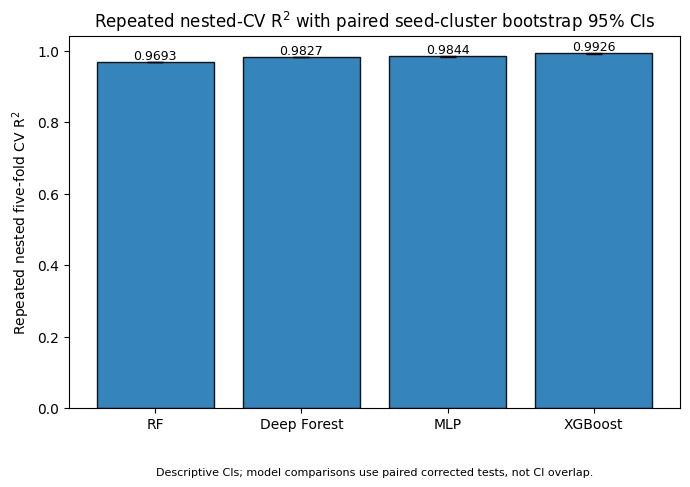

  ✓ Figure + fingerprint sidecars saved: parity_rf_df_mlp.pdf / .png


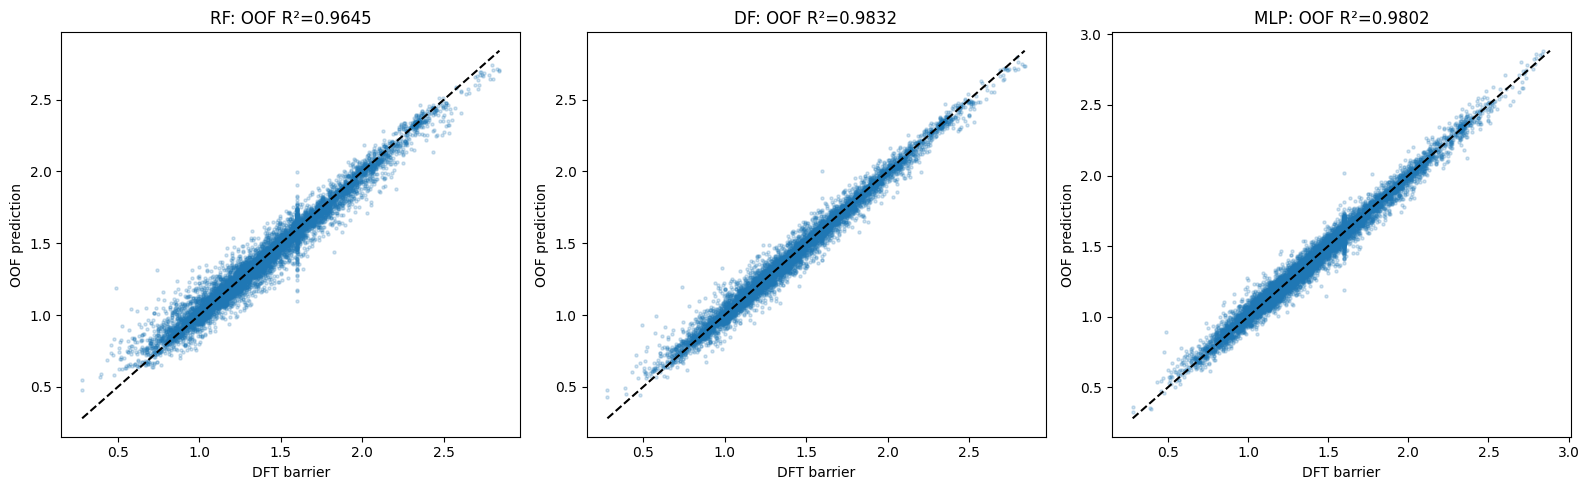

In [ ]:
# ===== Fig 4/5/6: repeated 5x5 CV R2 with seed-cluster bootstrap CIs + parity =====
print('=' * 55); print('FIGURE 4/5/6 — REPEATED NESTED FIVE-FOLD CV + PARITY'); print('=' * 55)
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import r2_score
rep = require_checkpoint('repeated_cv_5seed_fully_nested_safe')
par = require_checkpoint('parity_5f_fully_nested_safe')
rep_df = pd.DataFrame(rep['rows'])
seed_model = rep_df.pivot_table(index='seed', columns='model', values='R2', aggfunc='mean').dropna()
model_order = ['RF', 'DF', 'MLP', 'XGB']
assert set(model_order).issubset(seed_model.columns) and len(seed_model) >= 5
# One bootstrap draw samples whole seeds; all four models share the same sampled seeds.
rng = np.random.RandomState(SEED); B = 10000
idx = rng.randint(0, len(seed_model), size=(B, len(seed_model)))
vals = seed_model[model_order].to_numpy()
boot = vals[idx, :].mean(axis=1)
summary = []
for j, model in enumerate(model_order):
    mu = float(vals[:, j].mean()); lo, hi = np.percentile(boot[:, j], [2.5, 97.5])
    summary.append({'model': model, 'mean_R2': mu, 'CI_low': float(lo), 'CI_high': float(hi),
                    'n_seed_clusters': int(len(seed_model)), 'n_folds_per_seed': 5,
                    'method': 'paired seed-cluster bootstrap; 10000 resamples'})
boot_df = pd.DataFrame(summary)
save_csv(boot_df, 'repeated_cv_seed_cluster_bootstrap_safe')
fig, ax = plt.subplots(figsize=(7, 5))
mu = boot_df['mean_R2'].to_numpy(); lo = mu - boot_df['CI_low'].to_numpy(); hi = boot_df['CI_high'].to_numpy() - mu
labels = ['RF', 'Deep Forest', 'MLP', 'XGBoost']
bars = ax.bar(labels, mu, yerr=[lo, hi], capsize=6, edgecolor='k', alpha=0.9)
ax.set_ylabel('Repeated nested five-fold CV R$^2$')
ax.set_title('Repeated nested-CV R$^2$ with paired seed-cluster bootstrap 95% CIs')
for b, v in zip(bars, mu): ax.text(b.get_x()+b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
ax.text(0.5, -0.18, 'Descriptive CIs; model comparisons use paired corrected tests, not CI overlap.',
        transform=ax.transAxes, ha='center', fontsize=8)
plt.tight_layout(); save_figure(fig, 'cv_r2_barchart_ci'); plt.show()
# Existing leakage-safe OOF parity for RF/DF/MLP.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, m in zip(axes, ['RF', 'DF', 'MLP']):
    yt = np.asarray(par[m]['true']); yp = np.asarray(par[m]['pred'])
    ax.scatter(yt, yp, s=5, alpha=0.2, rasterized=True)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]; ax.plot(lim, lim, 'k--')
    ax.set_title(f'{m}: OOF R²={r2_score(yt, yp):.4f}'); ax.set_xlabel('DFT barrier'); ax.set_ylabel('OOF prediction')
plt.tight_layout(); save_figure(fig, 'parity_rf_df_mlp'); plt.show()


FIGURE 7/8/9 — per-group generalisation
  ✓ Checkpoint loaded: results_loho_fully_nested_safe
  ✓ Figure + fingerprint sidecars saved: loho_per_host.pdf / .png


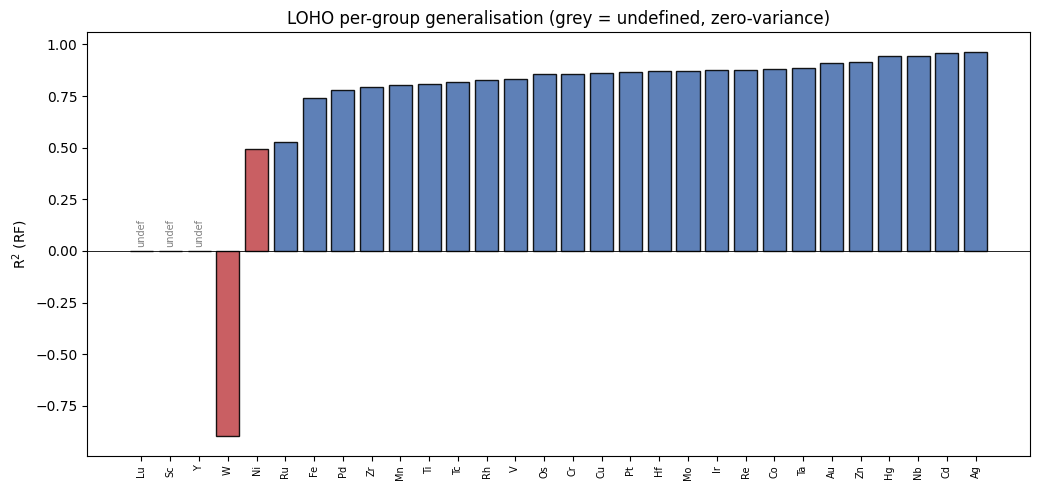

  ✓ Checkpoint loaded: results_loso_fully_nested_safe
  ✓ Figure + fingerprint sidecars saved: loso_per_surface.pdf / .png


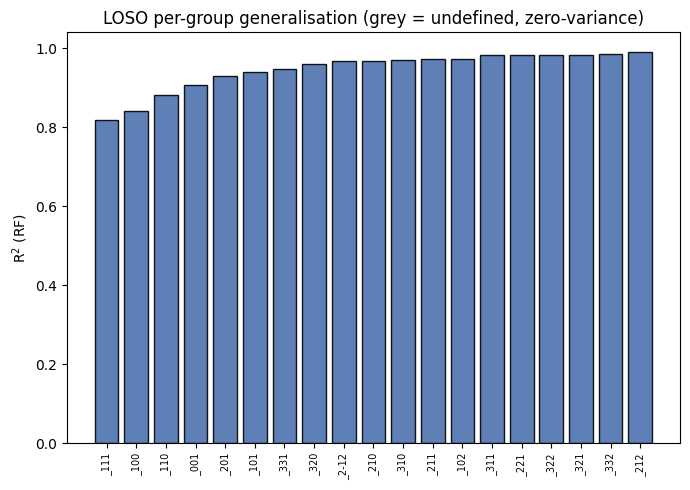

  ✓ Checkpoint loaded: results_lodo_fully_nested_safe
  ✓ Figure + fingerprint sidecars saved: lodo_per_dopant.pdf / .png


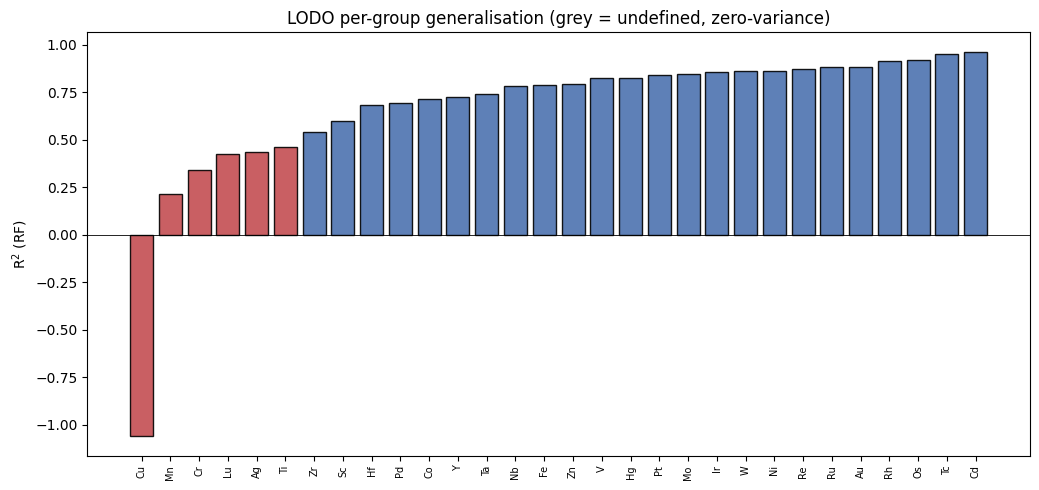

In [ ]:
# ===== Fig 7/8/9: per-group R2 (LOHO / LOSO / LODO), undefined shown as gap =====
print('=' * 55); print('FIGURE 7/8/9 — per-group generalisation'); print('=' * 55)
import numpy as np, matplotlib.pyplot as plt
def per_group_fig(ckpt, label, fname):
    res = load_checkpoint(ckpt)
    if res is None: print('missing', ckpt); return
    rows = res['RF']; groups = [str(r['group']) for r in rows]
    r2 = [np.nan if (r['R2'] is None or (isinstance(r['R2'], float) and np.isnan(r['R2']))) else r['R2'] for r in rows]
    order = np.argsort([(-99 if np.isnan(v) else v) for v in r2])
    groups = [groups[i] for i in order]; r2 = [r2[i] for i in order]
    fig, ax = plt.subplots(figsize=(max(7, len(groups) * 0.35), 5))
    colors = ['#BBBBBB' if np.isnan(v) else ('#C44E52' if v < 0.5 else '#4C72B0') for v in r2]
    vals = [0 if np.isnan(v) else v for v in r2]
    ax.bar(range(len(groups)), vals, color=colors, edgecolor='k', alpha=0.9)
    for i, v in enumerate(r2):
        if np.isnan(v): ax.text(i, 0.02, 'undef', ha='center', va='bottom', rotation=90, fontsize=7, color='gray')
    ax.set_xticks(range(len(groups))); ax.set_xticklabels(groups, rotation=90, fontsize=7)
    ax.axhline(0, color='k', lw=0.6); ax.set_ylabel('R$^2$ (RF)')
    ax.set_title(f'{label} per-group generalisation (grey = undefined, zero-variance)')
    plt.tight_layout(); save_figure(fig, fname); plt.show()
per_group_fig('results_loho_fully_nested_safe', 'LOHO', 'loho_per_host')
per_group_fig('results_loso_fully_nested_safe', 'LOSO', 'loso_per_surface')
per_group_fig('results_lodo_fully_nested_safe', 'LODO', 'lodo_per_dopant')


FIGURE 25 — uncertainty distribution
  ✓ Checkpoint loaded: uncertainty_oof_fully_nested_safe
  ✓ Figure + fingerprint sidecars saved: uncertainty_distribution.pdf / .png


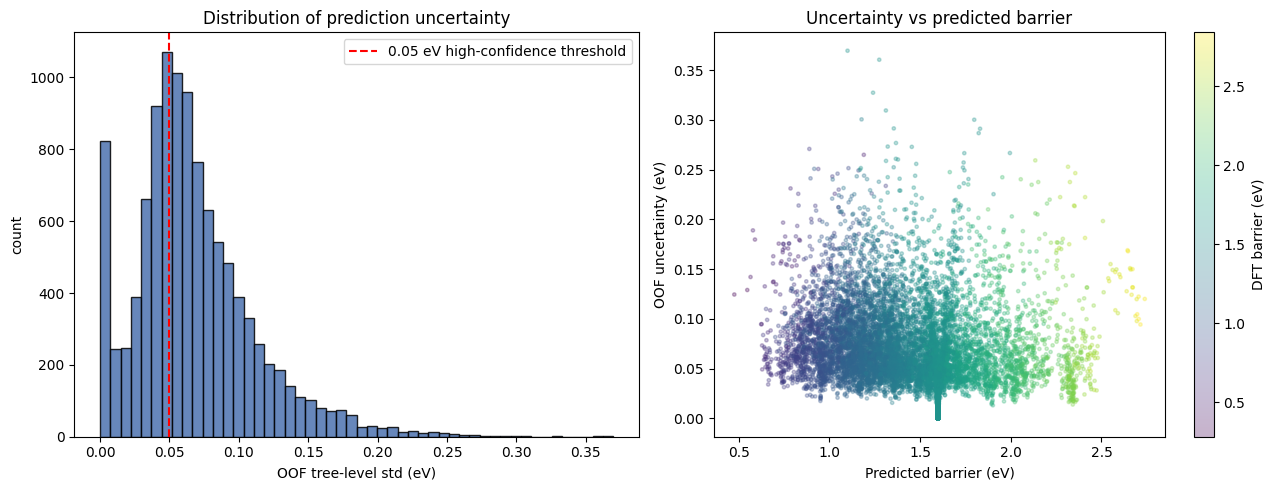

In [ ]:
# ===== Fig 25: uncertainty distribution + uncertainty vs predicted barrier =====
print('=' * 55); print('FIGURE 25 — uncertainty distribution'); print('=' * 55)
import numpy as np, matplotlib.pyplot as plt
cal = load_checkpoint('uncertainty_oof_fully_nested_safe'); A = cal['5fold_arrays']
std = np.array(A['std']); pred = np.array(A['pred'])
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].hist(std, bins=50, color='#4C72B0', edgecolor='k', alpha=0.85)
ax[0].axvline(0.05, color='r', ls='--', label='0.05 eV high-confidence threshold')
ax[0].set_xlabel('OOF tree-level std (eV)'); ax[0].set_ylabel('count'); ax[0].legend()
ax[0].set_title('Distribution of prediction uncertainty')
sc = ax[1].scatter(pred, std, s=6, alpha=0.3, c=A['true'], cmap='viridis', rasterized=True)
ax[1].set_xlabel('Predicted barrier (eV)'); ax[1].set_ylabel('OOF uncertainty (eV)')
plt.colorbar(sc, ax=ax[1], label='DFT barrier (eV)'); ax[1].set_title('Uncertainty vs predicted barrier')
plt.tight_layout(); save_figure(fig, 'uncertainty_distribution'); plt.show()


FIGURE — FULL MODEL COMPARISON (dynamic, fixed hyperparameters)
  ✓ Checkpoint loaded: results_5f_fully_nested_safe
  ✓ Checkpoint loaded: results_xgb_fully_nested_safe
  ✓ Checkpoint loaded: physics_baselines_summary_safe
  ✓ Checkpoint loaded: pgnn_groupout_nested_fully_safe
  ✓ Figure + fingerprint sidecars saved: full_model_comparison_safe.pdf / .png


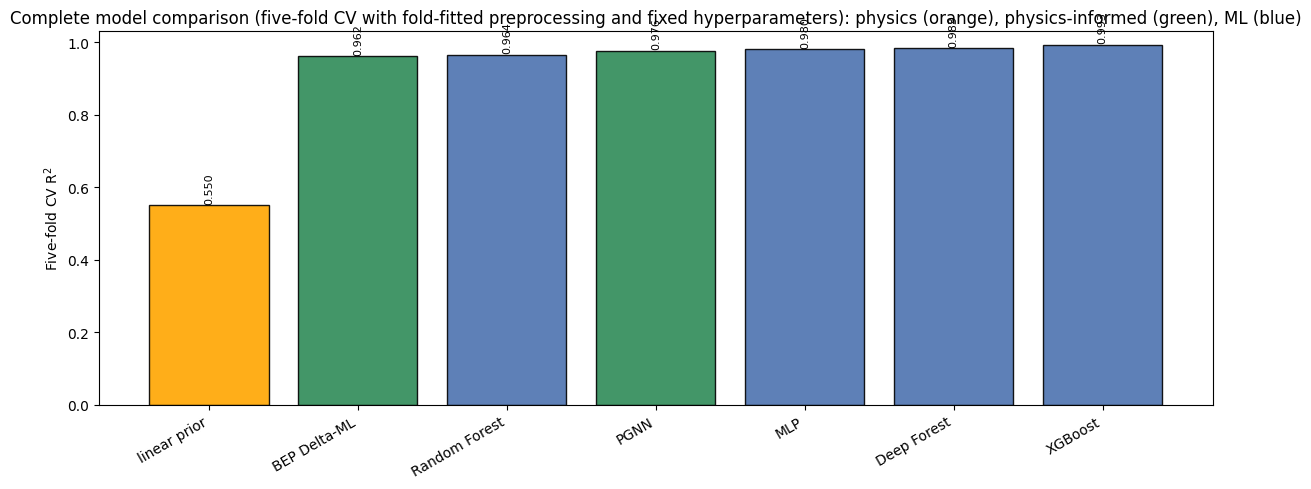

Figure regenerated dynamically from corrected held-out-isolated checkpoints.


In [ ]:
# ===== Full model comparison (dynamic; no hard-coded values) =====
print('=' * 55); print('FIGURE — FULL MODEL COMPARISON (dynamic, fixed hyperparameters)'); print('=' * 55)
# All metric values load dynamically from corrected checkpoints. No hard-coded numbers.
import numpy as np, matplotlib.pyplot as plt
def _mean_r2_list(lst):
    v = [x['R2'] for x in lst if x['R2'] is not None and not (isinstance(x['R2'], float) and np.isnan(x['R2']))]
    return float(np.mean(v)) if v else np.nan
r5 = require_checkpoint('results_5f_fully_nested_safe')
rx = require_checkpoint('results_xgb_fully_nested_safe')
_pc = load_checkpoint('physics_baselines_summary_safe')
phys_sum = (_pc['summary'] if isinstance(_pc, dict) and 'summary' in _pc else _pc)
pgnn_ck = load_checkpoint('pgnn_groupout_nested_fully_safe')
entries = []
entries.append(('Random Forest', _mean_r2_list(r5['RF']['barrier']), 'ml'))
entries.append(('Deep Forest', _mean_r2_list(r5['DF']['barrier']), 'ml'))
entries.append(('MLP', _mean_r2_list(r5['MLP']['barrier']), 'ml'))
entries.append(('XGBoost', _mean_r2_list(rx['5fold']['rows']), 'ml'))
if phys_sum is not None:
    p5 = phys_sum[phys_sum.protocol == '5fold']
    for _, row in p5.iterrows():
        if row['model'] in ('Empirical auxiliary linear prior', 'BEP-inspired Delta-ML'):
            tag = 'physics' if 'linear prior' in row['model'] else 'piml'
            entries.append((row['model'].replace('Empirical auxiliary ', '').replace('BEP-inspired ', 'BEP '),
                            float(row['mean_R2']), tag))
if pgnn_ck is not None and '5fold' in pgnn_ck:
    r2 = pd.DataFrame(pgnn_ck['5fold']['rows'])['R2'].astype(float)
    entries.append(('PGNN', float(np.nanmean(r2)), 'piml'))
entries = [e for e in entries if np.isfinite(e[1])]
entries.sort(key=lambda e: e[1])
names = [e[0] for e in entries]; vals = [e[1] for e in entries]
cmap = {'physics': 'orange', 'piml': 'seagreen', 'ml': '#4C72B0'}; cols = [cmap[e[2]] for e in entries]
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(names, vals, color=cols, edgecolor='k', alpha=0.9)
ax.set_ylabel('Five-fold CV R$^2$'); ax.set_ylim(0, 1.03)
ax.set_title('Complete model comparison (five-fold CV with fold-fitted preprocessing and fixed hyperparameters): '
             'physics (orange), physics-informed (green), ML (blue)')
for i, v in enumerate(vals): ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8, rotation=90)
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
save_figure(fig, 'full_model_comparison_safe'); plt.show()
print('Figure regenerated dynamically from corrected held-out-isolated checkpoints.')


## Step 43 — Summary tables & figures  [REVISED]


In [ ]:
print('=' * 55); print('STEP 43 — SUMMARY TABLES (held-out-isolated conventional models; PGNN present)'); print('=' * 55)
import numpy as np, pandas as pd
r5 = require_checkpoint('results_5f_fully_nested_safe')
lo = load_checkpoint('results_loho_fully_nested_safe'); ls = load_checkpoint('results_loso_fully_nested_safe')
ld = load_checkpoint('results_lodo_fully_nested_safe')
def _fmt(vals, metric):
    v = [r[metric] for r in vals if isinstance(r, dict) and r.get(metric) is not None
         and not (isinstance(r.get(metric), float) and np.isnan(r.get(metric)))]
    return f'{np.mean(v):.4f} ± {np.std(v):.4f}' if v else 'n/a'
rows_a = []
for proto, res, key in [('5-Fold CV', r5, 'barrier'), ('LOHO-CV', lo, None),
                        ('LOSO-CV', ls, None), ('LODO-CV', ld, None)]:
    if res is None: continue
    for name, lab in [('RF', 'Random Forest'), ('DF', 'Deep Forest'), ('MLP', 'Neural Network')]:
        vals = res[name][key] if key else res[name]
        if not vals: continue
        rows_a.append({'Protocol': proto, 'Model': lab, 'R2': _fmt(vals, 'R2'),
                       'MAE': _fmt(vals, 'MAE'), 'RMSE': _fmt(vals, 'RMSE')})
table_a = pd.DataFrame(rows_a)
save_csv(table_a, 'table_A_model_performance_safe')
print('TABLE A — MODEL PERFORMANCE ACROSS PROTOCOLS (corrected):')
print(table_a.to_string(index=False))
ab = load_checkpoint('ablation_results_raw_safe')
if ab is not None:
    save_csv(ab['ablation_df'], 'table_B_ablation_safe')
_pc = load_checkpoint('physics_baselines_summary_safe')
if _pc is not None:
    phys_sum = _pc['summary'] if isinstance(_pc, dict) and 'summary' in _pc else _pc
    save_csv(phys_sum, 'table_C_physics_baseline_safe')
    # PGNN is guaranteed present (summary built after the PGNN step); safe to title with PGNN.
    print('\nTABLE C — FAIR PHYSICS/DELTA-ML/PGNN (mean R2 by protocol):')
    print(phys_sum.pivot(index='protocol', columns='model', values='mean_R2').to_string())
cons = load_checkpoint('permutation_importance_raw_safe')
if cons is not None:
    save_csv(cons['consensus_df'].head(20), 'table_D_consensus_descriptors_safe')
stab = load_checkpoint('stability_proxy_ranking_oof_safe')
if stab is not None:
    save_csv(stab['top50'], 'table_E_retrospective_prioritized_rows_safe')
print('\nOK corrected summary tables saved (all *_safe).')


STEP 43 — SUMMARY TABLES (held-out-isolated conventional models; PGNN present)
  ✓ Checkpoint loaded: results_5f_fully_nested_safe
  ✓ Checkpoint loaded: results_loho_fully_nested_safe
  ✓ Checkpoint loaded: results_loso_fully_nested_safe
  ✓ Checkpoint loaded: results_lodo_fully_nested_safe
  ✓ CSV + fingerprint sidecar saved: table_A_model_performance_safe.csv
TABLE A — MODEL PERFORMANCE ACROSS PROTOCOLS (corrected):
 Protocol          Model              R2             MAE            RMSE
5-Fold CV  Random Forest 0.9644 ± 0.0024 0.0431 ± 0.0014 0.0670 ± 0.0024
5-Fold CV    Deep Forest 0.9832 ± 0.0010 0.0284 ± 0.0009 0.0461 ± 0.0013
5-Fold CV Neural Network 0.9802 ± 0.0067 0.0367 ± 0.0070 0.0493 ± 0.0089
  LOHO-CV  Random Forest 0.7728 ± 0.3446 0.0944 ± 0.0391 0.1205 ± 0.0462
  LOHO-CV    Deep Forest 0.8709 ± 0.1064 0.0742 ± 0.0392 0.0966 ± 0.0466
  LOHO-CV Neural Network 0.7916 ± 0.1711 0.1043 ± 0.0442 0.1267 ± 0.0486
  LOSO-CV  Random Forest 0.9470 ± 0.0490 0.0505 ± 0.0240 0.0744 ± 

## Step 44 — Export corrected tables (Table 2/3, calibration, active learning)  [REVISED]

In [ ]:
print('=' * 55); print('STEP 44 — EXPORT CORRECTED TABLES (all-protocol, calibration, PGNN)'); print('=' * 55)
# Reviewer items 3/17: Table 3 now carries computed XGBoost LOHO/LOSO/LODO (not NaN). Physics
# summary loaded from checkpoint (built after PGNN). Calibration summary written per protocol.
import numpy as np, pandas as pd
def _dmean(rows, key='R2'):
    v = [r[key] for r in rows if r.get(key) is not None and not (isinstance(r.get(key), float) and np.isnan(r.get(key)))]
    return round(float(np.mean(v)), 4) if v else np.nan
r5 = require_checkpoint('results_5f_fully_nested_safe'); rx = require_checkpoint('results_xgb_fully_nested_safe')
lo = load_checkpoint('results_loho_fully_nested_safe'); ls = load_checkpoint('results_loso_fully_nested_safe')
ld = load_checkpoint('results_lodo_fully_nested_safe'); pg = require_checkpoint('pgnn_groupout_nested_fully_safe')
def _xgb(tag): return _dmean(rx[tag]['rows']) if (tag in rx and isinstance(rx[tag], dict)) else np.nan
def _pg(tag): return _dmean(pg[tag]['rows']) if (tag in pg and isinstance(pg[tag], dict)) else np.nan
t3 = [{'Protocol': '5-Fold', 'RF': _dmean(r5['RF']['barrier']), 'DeepForest': _dmean(r5['DF']['barrier']),
       'MLP': _dmean(r5['MLP']['barrier']), 'XGBoost': _xgb('5fold'), 'PGNN': _pg('5fold')}]
def _grow(name, res, xt, pt):
    return {'Protocol': name, 'RF': _dmean(res['RF']), 'DeepForest': _dmean(res['DF']), 'MLP': _dmean(res['MLP']),
            'XGBoost': _xgb(xt), 'PGNN': _pg(pt)}
if lo: t3.append(_grow('LOHO', lo, 'LOHO', 'LOHO'))
if ls: t3.append(_grow('LOSO', ls, 'LOSO', 'LOSO'))
if ld: t3.append(_grow('LODO', ld, 'LODO', 'LODO'))
t3_df = pd.DataFrame(t3)
save_csv(t3_df, 'table3_all_protocols_safe')
print('TABLE 3 — all protocols x all models (mean R2, corrected; XGBoost chemistry-aware computed):')
print(t3_df.to_string(index=False))
phys_ck = require_checkpoint('physics_baselines_summary_safe'); phys_sum = phys_ck['summary']
print('\nPHYSICS/MODEL SUMMARY (from checkpoint, 5 methods):')
print(phys_sum.pivot(index='protocol', columns='model', values='mean_R2').to_string())
cal = require_checkpoint('uncertainty_oof_fully_nested_safe')
cal_rows = []
for k in ['5fold', 'LOHO', 'LOSO', 'LODO']:
    if k not in cal or not isinstance(cal[k], dict):
        raise RuntimeError(f'Uncertainty checkpoint missing protocol: {k}')
    c = cal[k]
    cal_rows.append({
        'protocol': k,
        'n_samples': int(c['n_samples']),
        'r_sigma_err': c['r'],
        'coverage_1sigma': c['cov1'],
        'coverage_2sigma': c['cov2'],
        'ECE': c['ECE'],
        'n_bins': int(c['n_bins']),
        'min_bin_n': int(c['min_bin_n']),
        'binning_method': c['binning_method'],
    })
cal_summary = pd.DataFrame(cal_rows)
required_cal_cols = {'protocol','n_samples','r_sigma_err','coverage_1sigma','coverage_2sigma',
                     'ECE','n_bins','min_bin_n','binning_method'}
if set(cal_summary.columns) != required_cal_cols or set(cal_summary['protocol']) != {'5fold','LOHO','LOSO','LODO'}:
    raise RuntimeError('Uncertainty calibration summary schema is incomplete.')
save_csv(cal_summary, 'uncertainty_calibration_summary_safe')
print('\nUNCERTAINTY CALIBRATION SUMMARY regenerated without dropping audit-required columns.')
_map = {'5fold': 'pgnn_5fold_pergroup_safe', 'LOHO': 'pgnn_LOHO_pergroup_safe',
        'LOSO': 'pgnn_LOSO_pergroup_safe', 'LODO': 'pgnn_LODO_pergroup_safe'}
for tag, fname in _map.items():
    if isinstance(pg.get(tag), dict): save_csv(pd.DataFrame(pg[tag]['rows']), fname)
print('OK corrected tables exported (only corrected checkpoints read).')


STEP 44 — EXPORT CORRECTED TABLES (all-protocol, calibration, PGNN)
  ✓ Checkpoint loaded: results_5f_fully_nested_safe
  ✓ Checkpoint loaded: results_xgb_fully_nested_safe
  ✓ Checkpoint loaded: results_loho_fully_nested_safe
  ✓ Checkpoint loaded: results_loso_fully_nested_safe
  ✓ Checkpoint loaded: results_lodo_fully_nested_safe
  ✓ Checkpoint loaded: pgnn_groupout_nested_fully_safe
  ✓ CSV + fingerprint sidecar saved: table3_all_protocols_safe.csv
TABLE 3 — all protocols x all models (mean R2, corrected; XGBoost chemistry-aware computed):
Protocol     RF  DeepForest    MLP  XGBoost   PGNN
  5-Fold 0.9644      0.9832 0.9802   0.9928 0.9756
    LOHO 0.7728      0.8709 0.7916   0.8702 0.8122
    LOSO 0.9470      0.9591 0.9088   0.9657 0.9174
    LODO 0.6740      0.7103 0.7363   0.7274 0.7137
  ✓ Checkpoint loaded: physics_baselines_summary_safe

PHYSICS/MODEL SUMMARY (from checkpoint, 5 methods):
model     BEP-inspired Delta-ML  Conventional MLP  Empirical auxiliary linear prior    P

FIGURE — ACTIVE LEARNING (labelled-only, multi-seed)
  ✓ Checkpoint loaded: active_learning_multi_fully_nested_safe
  ✓ Figure + fingerprint sidecars saved: active_learning_multi_safe.pdf / .png


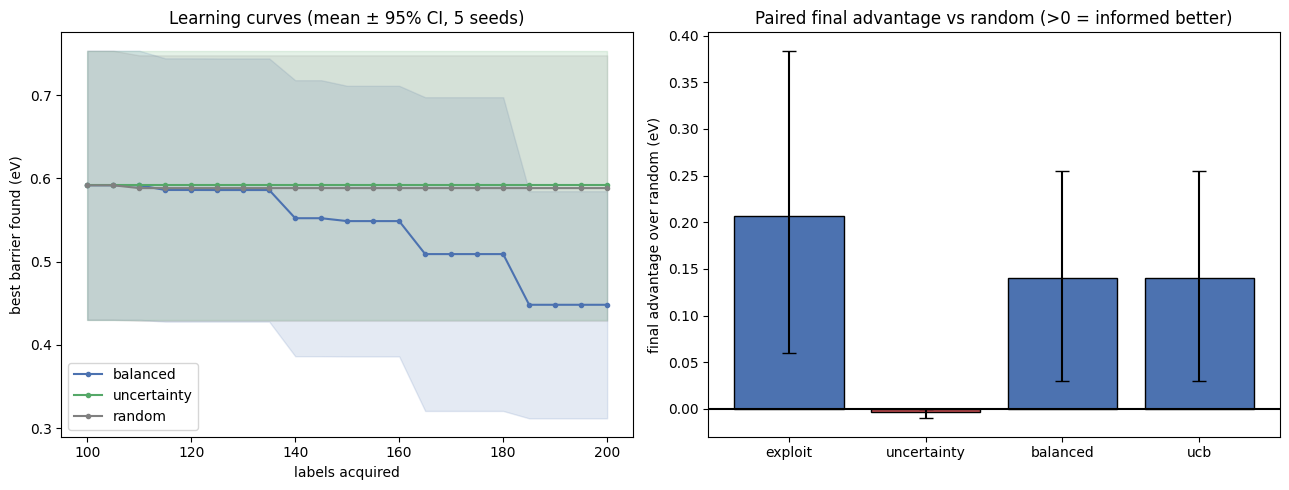

Active-learning figure regenerated from corrected labelled-only, multi-seed checkpoint + CSV summary.


In [ ]:
# ===== Active-learning figure (labelled-only, multi-seed) =====
print('=' * 55); print('FIGURE — ACTIVE LEARNING (labelled-only, multi-seed)'); print('=' * 55)
# Reviewer item 3: active_learning_summary_safe is a CSV, not a joblib checkpoint.
# It is read with pd.read_csv (FileNotFoundError if absent); require_checkpoint is NOT used for it.
import numpy as np, matplotlib.pyplot as plt
al = require_checkpoint('active_learning_multi_fully_nested_safe')
ACQ = ['exploit', 'uncertainty', 'balanced', 'ucb', 'random']
SEEDS = [SEED + i for i in range(5)]
iters = [p[0] for p in al['curves'][f'random|{SEEDS[0]}']]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for acq, c in zip(['balanced', 'uncertainty', 'random'], ['#4C72B0', '#55A868', 'gray']):
    mat = np.array([[p[1] for p in al['curves'][f'{acq}|{s}']] for s in SEEDS])
    mean_c = mat.mean(0); ci = 1.96 * mat.std(0) / np.sqrt(len(SEEDS))
    ax[0].plot(iters, mean_c, '-o', ms=3, c=c, label=acq)
    ax[0].fill_between(iters, mean_c - ci, mean_c + ci, color=c, alpha=0.15)
ax[0].set_xlabel('labels acquired'); ax[0].set_ylabel('best barrier found (eV)')
ax[0].legend(); ax[0].set_title('Learning curves (mean ± 95% CI, 5 seeds)')
summary_path = f'{SAVE_DIR}/results/active_learning_summary_safe.csv'
if not os.path.exists(summary_path):
    raise FileNotFoundError(summary_path)
al_summary = pd.read_csv(summary_path)
ax[1].bar(al_summary['acquisition'], al_summary['mean_final_diff_vs_random'],
    yerr=[al_summary['mean_final_diff_vs_random'] - al_summary['paired_CI_low'],
          al_summary['paired_CI_high'] - al_summary['mean_final_diff_vs_random']],
    capsize=5, color=['#4C72B0' if v > 0 else '#C44E52'
                      for v in al_summary['mean_final_diff_vs_random']], edgecolor='k')
ax[1].axhline(0, color='k'); ax[1].set_ylabel('final advantage over random (eV)')
ax[1].set_title('Paired final advantage vs random (>0 = informed better)')
plt.tight_layout(); save_figure(fig, 'active_learning_multi_safe'); plt.show()
print('Active-learning figure regenerated from corrected labelled-only, multi-seed checkpoint + CSV summary.')


## Step 45 — Supplementary: PGNN auxiliary-penalty sweep (80/20, exploratory)  [REVISED]

STEP 45 — [SUPPLEMENTARY] STRICTLY NESTED PGNN AUXILIARY-PENALTY SWEEP
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: pgnn_lambda_sweep_supp_fully_nested_safe
  ✓ CSV + fingerprint sidecar saved: pgnn_constrained_loss_results_safe.csv

[SUPPLEMENTARY] PGNN auxiliary-penalty sweep (80/20 held-out split, strict nesting):
                                 Model  lambda_consistency     R2    MAE  selected_epoch  epochs_to_refit  n_inner_train  n_inner_validation inner_preprocessing_scope       outer_refit_scope  outer_selected_feature_count
PGNN without prior-consistency penalty                0.00 0.9769 0.0411             160              161           7008                1752          inner-train only all outer-training rows                           142
   PGNN with lambda_consistency = 0.05                0.05 0.9770 0.0399             177              178           7008                1752          inner-train only all outer-training rows                       

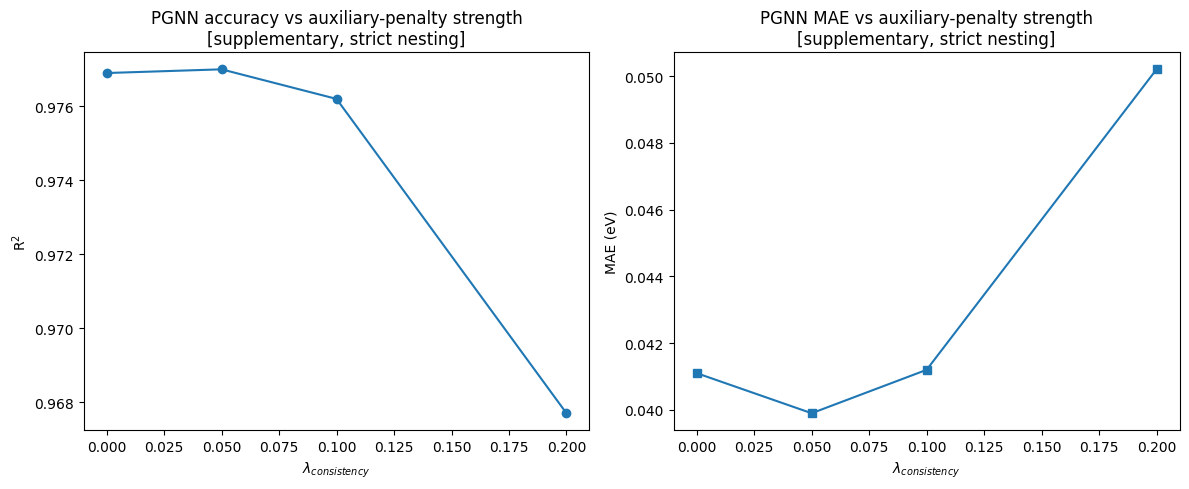

In [ ]:
print('=' * 55); print('STEP 45 — [SUPPLEMENTARY] STRICTLY NESTED PGNN AUXILIARY-PENALTY SWEEP'); print('=' * 55)
# Exploratory only. Raw outer-training rows are split before preprocessing;
# inner-train-only preprocessing selects the epoch; a fresh full-outer-training refit
# is then evaluated once on the held-out test.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

SWEEP_VERSION = 'pgnn_sweep_strict_nested_v3_8'
LAMBDAS = [0.0, 0.05, 0.10, 0.20]
idx = np.arange(len(y_barrier))
tr, te = train_test_split(idx, test_size=0.2, random_state=SEED)
X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()
X_outer_train_df = X_pre_df.iloc[tr]
X_outer_test_df = X_pre_df.iloc[te]
y_outer_train = np.asarray(y_barrier[tr], float)
y_outer_test = np.asarray(y_barrier[te], float)

sweep_ck = load_checkpoint('pgnn_lambda_sweep_supp_fully_nested_safe')
valid = (
    isinstance(sweep_ck, dict)
    and sweep_ck.get('version') == SWEEP_VERSION
    and sweep_ck.get('lambdas') == LAMBDAS
    and int(sweep_ck.get('seed', -1)) == int(SEED)
    and sweep_ck.get('_complete') is True
    and isinstance(sweep_ck.get('rows'), list)
    and len(sweep_ck['rows']) == len(LAMBDAS)
)
if valid:
    sweep = pd.DataFrame(sweep_ck['rows'])
else:
    rows = []
    for lam_c in LAMBDAS:
        selection = select_pgnn_epoch_from_raw_outer_train(
            X_outer_train_df, y_outer_train, seed=SEED,
            inner_groups=None,
            lam_prior_consistency=lam_c,
            lam_nonneg=0.5,
            lam_prior_sup=1.0,
        )
        pred, outer_feature_count = fit_pgnn_on_full_outer_train(
            X_outer_train_df, y_outer_train, X_outer_test_df,
            epochs=selection['epochs_to_refit'],
            seed=SEED,
            lam_prior_consistency=lam_c,
            lam_nonneg=0.5,
            lam_prior_sup=1.0,
        )
        r2 = r2_score(y_outer_test, pred)
        mae = mean_absolute_error(y_outer_test, pred)
        label = (
            'PGNN without prior-consistency penalty'
            if lam_c == 0.0
            else f'PGNN with lambda_consistency = {lam_c}'
        )
        rows.append({
            'Model': label,
            'lambda_consistency': float(lam_c),
            'R2': round(float(r2), 4),
            'MAE': round(float(mae), 4),
            'selected_epoch': int(selection['selected_epoch']),
            'epochs_to_refit': int(selection['epochs_to_refit']),
            'n_inner_train': int(selection['n_inner_train']),
            'n_inner_validation': int(selection['n_inner_validation']),
            'inner_preprocessing_scope': 'inner-train only',
            'outer_refit_scope': 'all outer-training rows',
            'outer_selected_feature_count': int(outer_feature_count),
        })
        print(
            f'  {label}: R2={r2:.4f} MAE={mae:.4f} '
            f'(selected epoch {selection["selected_epoch"]})'
        )
    sweep = pd.DataFrame(rows)
    sweep_ck = {
        'version': SWEEP_VERSION,
        'lambdas': LAMBDAS,
        'seed': int(SEED),
        'rows': rows,
        '_complete': True,
    }
    save_checkpoint(sweep_ck, 'pgnn_lambda_sweep_supp_fully_nested_safe')

save_csv(sweep, 'pgnn_constrained_loss_results_safe')
print('\n[SUPPLEMENTARY] PGNN auxiliary-penalty sweep (80/20 held-out split, strict nesting):')
print(sweep.to_string(index=False))
print(
    '\nNote: this is an exploratory supplementary sensitivity analysis using one held-out '
    'split. The held-out results are not used to select the final reported PGNN configuration, '
    'and the experiment is not interpreted as an independent comparison against a conventional MLP. '
    'The lambda=0 model retains the PGNN architecture, non-negativity penalty, and auxiliary-prior '
    'supervised loss.'
)

lam = sweep['lambda_consistency'].tolist()
r2 = sweep['R2'].tolist()
mae = sweep['MAE'].tolist()
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(lam, r2, 'o-')
ax[0].set_xlabel(r'$\lambda_{consistency}$')
ax[0].set_ylabel('R$^2$')
ax[0].set_title('PGNN accuracy vs auxiliary-penalty strength\n[supplementary, strict nesting]')
ax[1].plot(lam, mae, 's-')
ax[1].set_xlabel(r'$\lambda_{consistency}$')
ax[1].set_ylabel('MAE (eV)')
ax[1].set_title('PGNN MAE vs auxiliary-penalty strength\n[supplementary, strict nesting]')
plt.tight_layout()
save_figure(fig, 'pgnn_auxiliary_penalty_tradeoff_supp_safe')
plt.show()


## Step 46 — Static syntax & dependency validation  [NEW]
Fast self-check (no long checkpoints required): required callables defined, factories accept a seed, guard registers obsolete names, corrected model filenames use `_raw_safe`.

In [ ]:
print('=' * 55); print('STEP 46 — STATIC VALIDATION (fast; no long checkpoints required)'); print('=' * 55)
import inspect
_problems = []
required_callables = ['save_checkpoint','load_checkpoint','require_checkpoint','checkpoint_exists',
    'checkpoint_metadata_valid','artifact_metadata_valid','save_csv','save_figure','load_raw_pool',
    'LeakageSafePreprocessor','build_exact_descriptor_provenance','make_rf','make_df','make_mlp',
    'make_xgb','compute_metrics','compute_group_metrics',
    'make_model_from_params','prepare_inner_preprocessed_folds','tune_model_on_prepared_folds',
    'select_pgnn_epoch_from_raw_outer_train','fit_pgnn_on_full_outer_train']
for name in required_callables:
    if name not in globals() or not callable(globals()[name]):
        _problems.append(f'missing callable: {name}')
for f in ['make_rf','make_df','make_mlp','make_xgb']:
    if f in globals() and 'seed' not in inspect.signature(globals()[f]).parameters:
        _problems.append(f'{f} does not accept seed')
_required_env = {'torch_version','torch_cuda_build','cuda_available','cuda_device_name','global_seed'}
if not isinstance(globals().get('RUNTIME_ENVIRONMENT'), dict) or not _required_env.issubset(RUNTIME_ENVIRONMENT):
    _problems.append('runtime environment metadata (Torch/CUDA) is incomplete')
if not isinstance(globals().get('MODEL_HYPERPARAMETER_POLICY'), dict) or set(MODEL_HYPERPARAMETER_POLICY) != {'RF','DF','MLP','XGB'}:
    _problems.append('prespecified fixed-hyperparameter policy table is incomplete')
if globals().get('REPEATED_NESTED_VERSION') != 'repeated_nested_tuned_v3_8':
    _problems.append('repeated nested-CV version is missing')
if (not isinstance(globals().get('MODEL_TUNING_GRIDS'), dict)
        or set(MODEL_TUNING_GRIDS) != {'RF','DF','MLP','XGB'}
        or any(len(v) != 2 for v in MODEL_TUNING_GRIDS.values())):
    _problems.append('compact repeated nested-tuning grids are incomplete')
if int(globals().get('INNER_CV_SPLITS', -1)) != 2:
    _problems.append('repeated nested inner-CV split count is not 2')
if globals().get('DEPLOYED_MODEL_VERSION') != 'deployed_fixed_hp_v3_7':
    _problems.append('matched deployed-model version is missing')
if 'rf_final_barrier' in globals():
    _rfp = rf_final_barrier.get_params()
    if not (int(_rfp.get('n_estimators',-1))==300
            and _rfp.get('max_features')=='sqrt'
            and int(_rfp.get('min_samples_leaf',-1))==2
            and int(_rfp.get('random_state',-1))==int(SEED)):
        _problems.append('full-data RF refit does not match the evaluated fixed RF configuration')
for _vname,_expected in [
    ('INTERPRETATION_VERSION','interpretation_rng_v3_7'),
    ('INTERACTION_VERSION','interpretation_rng_v3_7'),
    ('PERM_VERSION','heldout_fold_perm_v3_7')]:
    if globals().get(_vname) != _expected:
        _problems.append(f'{_vname} is missing or incompatible')
for stale in ['feature_matrix','results_5f_safe','virtual_screening','virtual_screening_raw_safe',
              'catalyst_map_raw_safe','stability_proxy_ranking_fully_nested_safe','hdii_raw_safe']:
    if stale not in OBSOLETE_CHECKPOINTS:
        _problems.append(f'obsolete name not blocked: {stale}')
for keep in ['retrospective_oof_ranking_safe','random_vs_chemistry_protocol_comparison_safe',
             'descriptor_audit']:
    if keep in OBSOLETE_CHECKPOINTS:
        _problems.append(f'corrected output wrongly blocked: {keep}')
if 'build_exact_descriptor_provenance' not in globals():
    _problems.append('exact descriptor provenance builder missing')
else:
    _audit_preview = build_exact_descriptor_provenance()
    if not set(_audit_preview['classification_status']).issubset({'curated_exact','manual_review_required'}):
        _problems.append('descriptor audit contains a non-exact classification status')
    if ((_audit_preview.classification_status!='curated_exact')
        & (_audit_preview.allowed_for_prospective_screening==True)).any():
        _problems.append('unverified descriptor is prospectively allowed')
    if not {'included_in_retrospective_full_model',
            'included_in_availability_constrained_model'}.issubset(_audit_preview.columns):
        _problems.append('descriptor audit lacks separate full/constrained model inclusion columns')
    elif ((_audit_preview.included_in_availability_constrained_model==True)
          & (_audit_preview.classification_status!='curated_exact')).any():
        _problems.append('manual-review descriptor enters the availability-constrained model')
EXPECTED_CHECKPOINTS = [
    'results_5f_fully_nested_safe','parity_5f_fully_nested_safe',
    'results_xgb_fully_nested_safe','results_loho_fully_nested_safe',
    'results_loso_fully_nested_safe','results_lodo_fully_nested_safe',
    'repeated_cv_5seed_fully_nested_safe','random_vs_chemistry_protocol_comparison_safe',
    'retrospective_oof_ranking_safe','uncertainty_oof_fully_nested_safe',
    'hdii_nested_safe','risky_descriptor_sensitivity_fully_nested_safe',
    'retrospective_oof_host_dopant_map_safe','stability_proxy_ranking_oof_safe',
    'feature_importance_raw_safe','fi_per_surface_raw_safe',
    'shap_values_rf_raw_safe','shap_values_mlp_raw_safe',
    'shap_interaction_raw_safe','permutation_importance_raw_safe']
print('  exact provenance statuses:', sorted(set(_audit_preview.classification_status)) if 'build_exact_descriptor_provenance' in globals() else 'missing')
print('  artifact fingerprint helper:', callable(globals().get('artifact_metadata_valid')))
print('  required checkpoint declarations:', len(EXPECTED_CHECKPOINTS))
print('  protocol-stress policy: fold-fitted preprocessing + prespecified fixed configurations')
print('  repeated model-comparison policy: 5x5 outer CV + 2-fold inner tuning by MAE')
print('  matched RF evaluation/refit configuration:', MODEL_HYPERPARAMETER_POLICY['RF']['configuration'])
print('  interpretation RNG policy: dedicated fixed seeds with versioned checkpoints')
print('  permutation policy: held-out outer-test folds; neg-MAE scoring')
print('  claim scope:', HYPERPARAMETER_CLAIM_SCOPE)
print('  torch/CUDA environment captured:', RUNTIME_ENVIRONMENT['torch_version'], RUNTIME_ENVIRONMENT['torch_cuda_build'])
print('  EDA policy: no global column removal; missingness handled inside training folds')
print('  PGNN policy: raw inner split first; inner-train-only preprocessing; full outer-train refit; outer test once')
if _problems:
    print('\nSTATIC VALIDATION PROBLEMS:')
    for p in _problems: print('  -', p)
    raise AssertionError(f'Static validation failed with {len(_problems)} problem(s).')
print('\nStatic validation passed.')


STEP 46 — STATIC VALIDATION (fast; no long checkpoints required)
  ✓ Checkpoint loaded: feature_matrix_raw_safe
  ✓ Checkpoint loaded: matminer_features_raw_safe
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  exact provenance statuses: ['curated_exact', 'manual_review_required']
  artifact fingerprint helper: True
  required checkpoint declarations: 20
  protocol-stress policy: fold-fitted preprocessing + prespecified fixed configurations
  repeated model-comparison policy: 5x5 outer CV + 2-fold inner tuning by MAE
  matched RF evaluation/refit configuration: n_estimators=300; max_features=sqrt; min_samples_leaf=2
  interpretation RNG policy: dedicated fixed seeds with versioned checkpoints
  permutation policy: held-out outer-test folds; neg-MAE scoring
  claim scope: Results compare prespecified fixed model configurations under identical split and preprocessing rules. They do not establish superiority of optimally tuned model families.
  torch/CUDA environment captured: 2.11.0+cpu

## Step 47 — Exact-name descriptor provenance and structural-leakage audit  [REVISED]


In [ ]:
print('=' * 55); print('STEP 47 — EXACT-NAME DESCRIPTOR PROVENANCE AUDIT'); print('=' * 55)
audit_df = build_exact_descriptor_provenance()
if audit_df['descriptor_name'].duplicated().any():
    raise RuntimeError('Descriptor provenance table contains duplicate exact names.')
if (audit_df['classification_status'] == 'heuristic').any():
    raise RuntimeError('Heuristic descriptor classification is prohibited.')
bad_prospective = ((audit_df['classification_status'] != 'curated_exact')
                   & (audit_df['allowed_for_prospective_screening'] == True))
if bad_prospective.any():
    raise RuntimeError('Unverified descriptors cannot be allowed for prospective use.')
save_checkpoint({'version': 'exact_provenance_v3_5', '_complete': True,
                 'audit_df': audit_df,
                 'manual_review_count': int((audit_df.classification_status=='manual_review_required').sum())},
                'descriptor_audit')
save_csv(audit_df, 'descriptor_audit')
review_df = audit_df[audit_df['classification_status'] == 'manual_review_required'].copy()
save_csv(review_df, 'descriptor_audit_manual_review_safe')
cat_summary = (audit_df.groupby(['descriptor_category','classification_status'])
               .agg(n=('descriptor_name','size'),
                    not_prospective=('allowed_for_prospective_screening', lambda s: int((~s).sum())))
               .reset_index())
print('EXACT PROVENANCE CATEGORY SUMMARY:')
print(cat_summary.to_string(index=False))
print(f"\nExact curated entries: {(audit_df.classification_status=='curated_exact').sum()} / {len(audit_df)}")
print(f"Manual exact-name review required: {len(review_df)}")
if len(review_df):
    print('\nManual-review descriptors are excluded from the availability-constrained model:')
    print(review_df[['descriptor_name','source','reason_for_exclusion']].to_string(index=False))
print('\nNo descriptor is classified as safe by substring heuristics.')


STEP 47 — EXACT-NAME DESCRIPTOR PROVENANCE AUDIT
  ✓ Checkpoint loaded: feature_matrix_raw_safe
  ✓ Checkpoint loaded: matminer_features_raw_safe
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint saved: descriptor_audit
  ✓ CSV + fingerprint sidecar saved: descriptor_audit.csv
  ✓ CSV + fingerprint sidecar saved: descriptor_audit_manual_review_safe.csv
EXACT PROVENANCE CATEGORY SUMMARY:
                    descriptor_category  classification_status   n  not_prospective
                  Adsorption-site label          curated_exact   1                0
                 Atomic-size descriptor          curated_exact   2                0
              Bulk reference descriptor          curated_exact   2                0
              Categorical surface facet          curated_exact   1                0
       Delta Magpie elemental statistic          curated_exact 132                0
      Dopant Magpie elemental statistic          curated_exact 132                0
         

## Step 48 — All-model, all-protocol availability-constrained descriptor sensitivity  [REVISED]


STEP 48 — ALL-MODEL, ALL-PROTOCOL DESCRIPTOR-AVAILABILITY SENSITIVITY
  ✓ Checkpoint loaded: descriptor_audit
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: parity_5f_fully_nested_safe
  ✓ Checkpoint loaded: results_loho_fully_nested_safe
  ✓ Checkpoint loaded: results_loso_fully_nested_safe
  ✓ Checkpoint loaded: results_lodo_fully_nested_safe
  ✓ Checkpoint loaded: results_xgb_fully_nested_safe
  ✓ Checkpoint loaded: risky_descriptor_sensitivity_fully_nested_safe
  RESUME: recovered 322/336 completed model-units from Step 48 checkpoint.
  ✓ Checkpoint saved: risky_descriptor_sensitivity_fully_nested_safe
  ✓ Checkpoint saved: risky_descriptor_sensitivity_fully_nested_safe
  ✓ Checkpoint saved: risky_descriptor_sensitivity_fully_nested_safe
  constrained LODO|W: 2 model(s) completed
  ✓ Checkpoint saved: risky_descriptor_sensitivity_fully_nested_safe
  ✓ Checkpoint saved: risky_descriptor_sensitivity_fully_nested_safe
  ✓ Checkpoint saved: risky_descriptor_sens

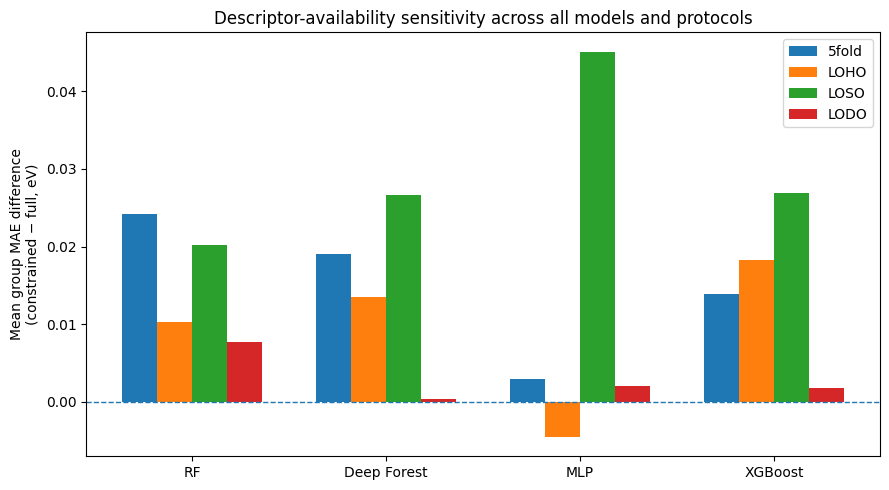

All variants are retrospective held-out benchmarks; none constitutes prospective discovery.


In [ ]:
print('=' * 55)
print('STEP 48 — ALL-MODEL, ALL-PROTOCOL DESCRIPTOR-AVAILABILITY SENSITIVITY')
print('=' * 55)

from sklearn.model_selection import KFold

SENS_VERSION = 'descriptor_sensitivity_all_protocols_v3_8'
MODELS = ['RF', 'DF', 'MLP', 'XGB']
PROTOCOLS = ['5fold', 'LOHO', 'LOSO', 'LODO']
N = len(y_barrier)


# ============================================================
# 1. LOAD DESCRIPTOR AUDIT AND BUILD SAFE DESCRIPTOR POOL
# ============================================================

audit_ck = require_checkpoint('descriptor_audit')
audit_df = audit_ck['audit_df']

safe_mask = (
    (audit_df['classification_status'] == 'curated_exact')
    & (audit_df['allowed_for_prospective_screening'] == True)
    & (audit_df['available_before_barrier_calculation'] == True)
    & (audit_df['target_comparable_DFT_risk'] == False)
)

safe_descriptor_names = set(
    audit_df.loc[safe_mask, 'descriptor_name'].astype(str)
)

X_pre_df, numeric_names, cat_names, original_feature_set = load_raw_pool()

safe_numeric = [
    c for c in numeric_names
    if c in safe_descriptor_names
]

safe_cat = (
    ['Surface']
    if 'Surface (one-hot categories)' in safe_descriptor_names
    else []
)

# IMPORTANT RESUME FIX:
# load_raw_pool() returns original_feature_set as a SET.
# Set iteration order may change after Colab reconnect.
# Sorting makes checkpoint metadata deterministic.
safe_orig = sorted(
    c for c in original_feature_set
    if c in safe_numeric
)

if len(safe_numeric) < 2:
    raise RuntimeError(
        'Availability-constrained descriptor pool is too small. '
        'Complete exact descriptor provenance before running sensitivity analysis.'
    )


# ============================================================
# 2. GROUP LABELS
# ============================================================

db_sens = pd.read_csv(f'{SAVE_DIR}/Database.csv')

host_sens = db_sens['Host'].astype(str).values
doped_sens = db_sens['Doped'].astype(str).values
surface_sens = db_sens['Surface'].astype(str).values


# ============================================================
# 3. LOAD FULL-DESCRIPTOR OOF PREDICTIONS
# ============================================================

parity = require_checkpoint('parity_5f_fully_nested_safe')
loho_ck = require_checkpoint('results_loho_fully_nested_safe')
loso_ck = require_checkpoint('results_loso_fully_nested_safe')
lodo_ck = require_checkpoint('results_lodo_fully_nested_safe')
xgb_ck = require_checkpoint('results_xgb_fully_nested_safe')

full_oof = {
    '5fold': {
        'RF': np.asarray(parity['RF']['pred'], float),
        'DF': np.asarray(parity['DF']['pred'], float),
        'MLP': np.asarray(parity['MLP']['pred'], float),
        'XGB': np.asarray(xgb_ck['5fold']['oof_pred'], float),
    },

    'LOHO': {
        'RF': np.asarray(loho_ck['oof']['RF']['pred'], float),
        'DF': np.asarray(loho_ck['oof']['DF']['pred'], float),
        'MLP': np.asarray(loho_ck['oof']['MLP']['pred'], float),
        'XGB': np.asarray(xgb_ck['LOHO']['oof_pred'], float),
    },

    'LOSO': {
        'RF': np.asarray(loso_ck['oof']['RF']['pred'], float),
        'DF': np.asarray(loso_ck['oof']['DF']['pred'], float),
        'MLP': np.asarray(loso_ck['oof']['MLP']['pred'], float),
        'XGB': np.asarray(xgb_ck['LOSO']['oof_pred'], float),
    },

    'LODO': {
        'RF': np.asarray(lodo_ck['oof']['RF']['pred'], float),
        'DF': np.asarray(lodo_ck['oof']['DF']['pred'], float),
        'MLP': np.asarray(lodo_ck['oof']['MLP']['pred'], float),
        'XGB': np.asarray(xgb_ck['LODO']['oof_pred'], float),
    },
}


# Validate full OOF predictions
for protocol in PROTOCOLS:
    for model in MODELS:

        arr = full_oof[protocol][model]

        if arr.shape != (N,) or not np.isfinite(arr).all():
            raise RuntimeError(
                f'Full-descriptor {protocol}/{model} '
                f'OOF predictions incomplete.'
            )


# ============================================================
# 4. EXACT OUTER SPLITS
# ============================================================

split_specs = {

    '5fold': [
        (f'fold{i + 1}', tr, te)
        for i, (tr, te) in enumerate(
            KFold(
                5,
                shuffle=True,
                random_state=SEED
            ).split(X_pre_df)
        )
    ],

    'LOHO': [
        (
            str(g),
            host_sens != g,
            host_sens == g
        )
        for g in np.unique(host_sens)
    ],

    'LOSO': [
        (
            str(g),
            surface_sens != g,
            surface_sens == g
        )
        for g in np.unique(surface_sens)
    ],

    'LODO': [
        (
            str(g),
            doped_sens != g,
            doped_sens == g
        )
        for g in np.unique(doped_sens)
    ],
}


# Every model inside every outer group gets its own checkpoint key.
expected_keys = {
    f'{protocol}|{group}|{model}'
    for protocol, units in split_specs.items()
    for group, _, _ in units
    for model in MODELS
}


# ============================================================
# 5. NEW CHECKPOINT TEMPLATE
# ============================================================

def _new_sensitivity_checkpoint():

    return {

        'version': SENS_VERSION,

        'models': MODELS,
        'protocols': PROTOCOLS,

        'safe_numeric': safe_numeric,
        'safe_cat': safe_cat,

        # Always deterministic
        'safe_orig': safe_orig,

        'expected_keys': sorted(expected_keys),

        'model_seed': int(SEED),

        'constrained_oof': {
            protocol: {
                model: np.full(N, np.nan)
                for model in MODELS
            }
            for protocol in PROTOCOLS
        },

        'constrained_rows': [],

        'comparison_rows': [],

        'paired_tests': [],

        '_done': [],

        '_complete': False,
    }


# ============================================================
# 6. LOAD EXISTING STEP-48 CHECKPOINT
# ============================================================

sens = load_checkpoint(
    'risky_descriptor_sensitivity_fully_nested_safe'
)


# ============================================================
# 7. CHECK CHECKPOINT COMPATIBILITY
# ============================================================

valid_top = (

    isinstance(sens, dict)

    and sens.get('version') == SENS_VERSION

    and sens.get('models') == MODELS

    and sens.get('protocols') == PROTOCOLS

    and sens.get('safe_numeric') == safe_numeric

    and sens.get('safe_cat') == safe_cat

    # ========================================================
    # CRITICAL RESUME FIX
    #
    # OLD:
    # sens.get('safe_orig') == safe_orig
    #
    # That could fail after reconnect because safe_orig
    # originated from a Python set.
    #
    # NEW:
    # compare descriptor membership rather than list order.
    # ========================================================
    and set(sens.get('safe_orig', [])) == set(safe_orig)

    and int(
        sens.get('model_seed', -1)
    ) == int(SEED)

    and set(
        sens.get('expected_keys', [])
    ) == expected_keys
)


if not valid_top:

    print(
        '  Existing Step-48 checkpoint is absent or '
        'truly incompatible.'
    )

    sens = _new_sensitivity_checkpoint()


# ============================================================
# 8. REPAIR / RECOVER EXISTING CHECKPOINT
# ============================================================

rows = (
    sens.get('constrained_rows', [])
    if isinstance(
        sens.get('constrained_rows'),
        list
    )
    else []
)

done = (
    sens.get('_done', [])
    if isinstance(
        sens.get('_done'),
        list
    )
    else []
)


clean_rows = []
clean_done = []


# Lookup test indices for each protocol/group
unit_lookup = {

    (protocol, group): (tr, te)

    for protocol, units in split_specs.items()

    for group, tr, te in units
}


# Make sure OOF containers exist and have correct shape
for protocol in PROTOCOLS:

    if protocol not in sens.get(
        'constrained_oof', {}
    ):

        sens['constrained_oof'][protocol] = {
            model: np.full(N, np.nan)
            for model in MODELS
        }

    for model in MODELS:

        arr = np.asarray(
            sens['constrained_oof'][protocol].get(
                model,
                np.full(N, np.nan)
            ),
            float
        )

        if arr.shape != (N,):

            arr = np.full(N, np.nan)

        sens['constrained_oof'][protocol][model] = arr


# ============================================================
# Recover only COMPLETE model-units.
#
# Example:
# 5fold|fold1|RF
# 5fold|fold1|DF
# 5fold|fold1|MLP
# 5fold|fold1|XGB
#
# Each one can recover independently.
# ============================================================

for key in sorted(
    set(done) & expected_keys
):

    protocol, group, model = key.split(
        '|',
        2
    )

    _, te = unit_lookup[
        (protocol, group)
    ]

    rr = [

        r for r in rows

        if isinstance(r, dict)

        and r.get('protocol') == protocol

        and str(
            r.get('group')
        ) == group

        and r.get('model') == model
    ]


    pred_arr = sens[
        'constrained_oof'
    ][protocol][model]


    if getattr(
        te,
        'dtype',
        None
    ) == bool:

        expected_n_test = int(
            np.sum(te)
        )

    else:

        expected_n_test = int(
            len(te)
        )


    valid = (

        len(rr) == 1

        and int(
            rr[0].get(
                'seed',
                -1
            )
        ) == int(SEED)

        and int(
            rr[0].get(
                'n_test',
                -1
            )
        ) == expected_n_test

        and np.isfinite(
            pred_arr[te]
        ).all()
    )


    if valid:

        clean_rows.extend(rr)

        clean_done.append(key)

    else:

        # Incomplete model-unit:
        # erase only that test prediction section.
        pred_arr[te] = np.nan

        print(
            f'  Sensitivity unit {key} '
            f'is partial/incompatible '
            f'and will be recomputed.'
        )


# Replace checkpoint with repaired state
sens['constrained_rows'] = clean_rows
sens['_done'] = clean_done
sens['_complete'] = False


# Normalize metadata for all future reconnects
sens['safe_orig'] = list(safe_orig)

sens['expected_keys'] = sorted(
    expected_keys
)


print(
    f'  RESUME: recovered '
    f'{len(clean_done)}/{len(expected_keys)} '
    f'completed model-units '
    f'from Step 48 checkpoint.'
)


# VERY IMPORTANT:
# Immediately persist repaired checkpoint before training anything.
save_checkpoint(
    sens,
    'risky_descriptor_sensitivity_fully_nested_safe'
)


# ============================================================
# 9. MODEL FITTING HELPER
# ============================================================

def _fit_constrained_model(
    model_key,
    Xtr,
    ytr,
    Xte
):

    if model_key == 'RF':

        return (
            make_rf(SEED)
            .fit(Xtr, ytr)
            .predict(Xte)
        )


    if model_key == 'DF':

        model = make_df(SEED)

        model.fit(
            Xtr,
            ytr,
            verbose=False
        )

        return model.predict(Xte)


    if model_key == 'MLP':

        return (
            make_mlp(SEED)
            .fit(Xtr, ytr)
            .predict(Xte)
        )


    if model_key == 'XGB':

        return (
            make_xgb(SEED)
            .fit(Xtr, ytr)
            .predict(Xte)
        )


    raise KeyError(model_key)


# ============================================================
# 10. RUN ONLY MISSING MODEL-UNITS
# ============================================================

for protocol, units in split_specs.items():

    for group, tr, te in units:


        missing_models = [

            model for model in MODELS

            if (
                f'{protocol}|'
                f'{group}|'
                f'{model}'
            )
            not in sens['_done']
        ]


        # ====================================================
        # CRITICAL RESUME BEHAVIOUR:
        #
        # If all four models of this group were already saved,
        # the entire group is skipped immediately.
        # ====================================================

        if not missing_models:
            continue


        if getattr(
            tr,
            'dtype',
            None
        ) == bool:

            Xtr_df = X_pre_df.loc[tr]

        else:

            Xtr_df = X_pre_df.iloc[tr]


        if getattr(
            te,
            'dtype',
            None
        ) == bool:

            Xte_df = X_pre_df.loc[te]

        else:

            Xte_df = X_pre_df.iloc[te]


        ytr = np.asarray(
            y_barrier[tr],
            float
        )

        yte = np.asarray(
            y_barrier[te],
            float
        )


        # ====================================================
        # Preprocessing fitted ONLY on training partition
        # ====================================================

        prep = LeakageSafePreprocessor(

            safe_numeric,

            safe_cat,

            safe_orig

        ).fit(
            Xtr_df,
            ytr
        )


        Xtr = prep.transform(
            Xtr_df
        )

        Xte = prep.transform(
            Xte_df
        )


        # ====================================================
        # Train ONLY models that have not already completed
        # ====================================================

        for model in missing_models:


            pred = _fit_constrained_model(

                model,

                Xtr,

                ytr,

                Xte
            )


            # Store OOF predictions
            sens[
                'constrained_oof'
            ][protocol][model][te] = pred


            m = compute_metrics(
                yte,
                pred
            )


            sens[
                'constrained_rows'
            ].append({

                'protocol': protocol,

                'group': str(group),

                'model': model,

                'seed': int(SEED),

                'n_train': int(
                    len(ytr)
                ),

                'n_test': int(
                    len(yte)
                ),

                'selected_feature_count': int(
                    Xtr.shape[1]
                ),

                'R2': m['R2'],

                'MAE': m['MAE'],

                'RMSE': m['RMSE'],
            })


            # =================================================
            # Mark THIS MODEL individually completed
            # =================================================

            model_key = (
                f'{protocol}|'
                f'{group}|'
                f'{model}'
            )

            sens['_done'].append(
                model_key
            )


            # =================================================
            # CRITICAL:
            # SAVE AFTER EVERY SINGLE MODEL
            #
            # Even if Colab disconnects after RF but before DF,
            # RF will already be recoverable.
            # =================================================

            save_checkpoint(

                sens,

                'risky_descriptor_sensitivity_fully_nested_safe'
            )


        print(
            f'  constrained '
            f'{protocol}|{group}: '
            f'{len(missing_models)} '
            f'model(s) completed'
        )


# ============================================================
# 11. VERIFY FULL COMPLETION
# ============================================================

constrained_df = pd.DataFrame(
    sens['constrained_rows']
)


sens['_complete'] = (

    set(
        sens['_done']
    ) == expected_keys

    and len(
        sens['_done']
    ) == len(expected_keys)

    and len(
        constrained_df
    ) == len(expected_keys)

    and constrained_df.duplicated(
        [
            'protocol',
            'group',
            'model'
        ]
    ).sum() == 0

    and all(

        np.isfinite(

            np.asarray(
                sens[
                    'constrained_oof'
                ][protocol][model],
                float
            )

        ).all()

        for protocol in PROTOCOLS

        for model in MODELS
    )
)


if not sens['_complete']:

    raise RuntimeError(
        'All-model/all-protocol constrained '
        'sensitivity checkpoint incomplete.'
    )


# ============================================================
# 12. BUILD PAIRED FULL-vs-CONSTRAINED COMPARISON
# ============================================================

comparison_rows = []


for protocol, units in split_specs.items():

    for group, tr, te in units:

        yte = np.asarray(
            y_barrier[te],
            float
        )


        for model in MODELS:

            for variant, pred_all in [

                (
                    'full_descriptor_pool',
                    full_oof[protocol][model]
                ),

                (
                    'availability_constrained_pool',
                    sens[
                        'constrained_oof'
                    ][protocol][model]
                ),
            ]:


                pred = np.asarray(
                    pred_all,
                    float
                )[te]


                m = compute_metrics(
                    yte,
                    pred
                )


                comparison_rows.append({

                    'protocol': protocol,

                    'group': str(group),

                    'model': model,

                    'variant': variant,

                    'seed': int(SEED),

                    'n_test': int(
                        len(yte)
                    ),

                    'R2': m['R2'],

                    'MAE': m['MAE'],

                    'RMSE': m['RMSE'],
                })


comparison_df = pd.DataFrame(
    comparison_rows
)


if comparison_df.duplicated(
    [
        'protocol',
        'group',
        'model',
        'variant'
    ]
).sum() != 0:

    raise RuntimeError(
        'Duplicate rows in descriptor '
        'sensitivity comparison.'
    )


# ============================================================
# 13. CLUSTER BOOTSTRAP
# ============================================================

def _cluster_bootstrap_difference(
    diff,
    clusters,
    seed,
    n_boot=10000
):

    diff = np.asarray(
        diff,
        float
    )

    clusters = np.asarray(
        clusters
    ).astype(str)


    unique = np.unique(
        clusters
    )


    if len(unique) < 2:

        return (
            np.nan,
            np.nan,
            int(len(unique))
        )


    members = {

        g: np.where(
            clusters == g
        )[0]

        for g in unique
    }


    rng = np.random.RandomState(
        int(seed)
    )


    boot = []


    for _ in range(
        int(n_boot)
    ):

        sampled = rng.choice(
            unique,
            size=len(unique),
            replace=True
        )


        idx = np.concatenate(
            [
                members[g]
                for g in sampled
            ]
        )


        boot.append(
            float(
                np.mean(
                    diff[idx]
                )
            )
        )


    lo, hi = np.percentile(
        boot,
        [2.5, 97.5]
    )


    return (
        float(lo),
        float(hi),
        int(len(unique))
    )


# ============================================================
# 14. PAIRED ERROR-DIFFERENCE ANALYSIS
# ============================================================

paired_rows = []


for protocol, units in split_specs.items():


    cluster_labels = np.empty(
        N,
        dtype=object
    )


    for group, _, te in units:

        cluster_labels[te] = str(
            group
        )


    for model in MODELS:


        full_pred = np.asarray(
            full_oof[protocol][model],
            float
        )


        constrained_pred = np.asarray(

            sens[
                'constrained_oof'
            ][protocol][model],

            float
        )


        for metric in [

            'absolute_error',

            'squared_error'

        ]:


            if metric == 'absolute_error':

                full_err = np.abs(
                    full_pred
                    - y_barrier
                )

                constrained_err = np.abs(
                    constrained_pred
                    - y_barrier
                )


            else:

                full_err = (
                    full_pred
                    - y_barrier
                ) ** 2

                constrained_err = (
                    constrained_pred
                    - y_barrier
                ) ** 2


            diff = (
                constrained_err
                - full_err
            )


            lo, hi, n_clusters = (
                _cluster_bootstrap_difference(

                    diff,

                    cluster_labels,

                    seed=(
                        SEED
                        + PROTOCOLS.index(
                            protocol
                        ) * 100
                        + MODELS.index(
                            model
                        )
                    )
                )
            )


            paired_rows.append({

                'protocol': protocol,

                'model': model,

                'metric': metric,

                'difference_definition':
                    'constrained error minus '
                    'full-descriptor error',

                'n_samples': int(N),

                'n_outer_clusters': int(
                    n_clusters
                ),

                'mean_paired_difference':
                    float(
                        np.mean(diff)
                    ),

                'median_paired_difference':
                    float(
                        np.median(diff)
                    ),

                'cluster_bootstrap_CI_low':
                    lo,

                'cluster_bootstrap_CI_high':
                    hi,

                'ci_method':
                    'outer-group cluster bootstrap; '
                    '10000 resamples',
            })


paired_df = pd.DataFrame(
    paired_rows
)


# ============================================================
# 15. SUMMARY TABLE
# ============================================================

summary_df = (

    comparison_df

    .groupby(
        [
            'protocol',
            'model',
            'variant'
        ]
    )[
        [
            'R2',
            'MAE',
            'RMSE'
        ]
    ]

    .agg(
        [
            'mean',
            'std'
        ]
    )

    .reset_index()
)


summary_df.columns = [

    '_'.join(
        [
            str(x)
            for x in col
            if str(x)
        ]
    )

    if isinstance(
        col,
        tuple
    )

    else str(col)

    for col in summary_df.columns
]


# ============================================================
# 16. EXCLUDED DESCRIPTOR LIST
# ============================================================

excluded_df = audit_df[
    audit_df[
        'included_in_availability_constrained_model'
    ] != True
].copy()


# ============================================================
# 17. FINAL CHECKPOINT
# ============================================================

sens[
    'comparison_rows'
] = comparison_rows

sens[
    'paired_tests'
] = paired_rows

sens[
    'excluded_exact_names'
] = (
    excluded_df[
        'descriptor_name'
    ]
    .astype(str)
    .tolist()
)

sens['_complete'] = True


save_checkpoint(
    sens,
    'risky_descriptor_sensitivity_fully_nested_safe'
)


# ============================================================
# 18. SAVE CSV OUTPUTS
# ============================================================

save_csv(
    constrained_df,
    'risky_descriptor_constrained_all_protocols_safe'
)


save_csv(
    comparison_df,
    'risky_descriptor_sensitivity_all_protocols_safe'
)


save_csv(

    comparison_df[
        comparison_df[
            'protocol'
        ] == '5fold'
    ],

    'risky_descriptor_sensitivity_folds_safe'
)


save_csv(
    summary_df,
    'risky_descriptor_sensitivity_summary_safe'
)


save_csv(
    paired_df,
    'risky_descriptor_sensitivity_paired_tests_safe'
)


save_csv(
    excluded_df,
    'risky_descriptor_excluded_list_safe'
)


# ============================================================
# 19. PRINT FINAL SUMMARY
# ============================================================

print(
    'Descriptors excluded from '
    'availability-constrained models:',
    len(excluded_df)
)


print(

    comparison_df

    .groupby(
        [
            'protocol',
            'model',
            'variant'
        ]
    )[
        [
            'MAE',
            'RMSE'
        ]
    ]

    .mean()

    .round(5)

    .to_string()
)


# ============================================================
# 20. VISUALIZATION
# ============================================================

plot_rows = []


for protocol in PROTOCOLS:

    for model in MODELS:


        sub = comparison_df[

            (
                comparison_df[
                    'protocol'
                ] == protocol
            )

            &

            (
                comparison_df[
                    'model'
                ] == model
            )

        ].pivot(

            index='group',

            columns='variant',

            values='MAE'
        )


        plot_rows.append({

            'protocol': protocol,

            'model': model,

            'delta_MAE': float(

                (
                    sub[
                        'availability_constrained_pool'
                    ]

                    -

                    sub[
                        'full_descriptor_pool'
                    ]
                ).mean()
            ),
        })


plot_df = pd.DataFrame(
    plot_rows
)


pivot_plot = (

    plot_df

    .pivot(
        index='model',
        columns='protocol',
        values='delta_MAE'
    )

    .loc[
        MODELS,
        PROTOCOLS
    ]
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)


x = np.arange(
    len(MODELS)
)

width = 0.18


for j, protocol in enumerate(
    PROTOCOLS
):

    ax.bar(

        x
        + (j - 1.5)
        * width,

        pivot_plot[
            protocol
        ],

        width=width,

        label=protocol
    )


ax.axhline(
    0,
    linestyle='--',
    linewidth=1
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        'RF',
        'Deep Forest',
        'MLP',
        'XGBoost'
    ]
)


ax.set_ylabel(
    'Mean group MAE difference\n'
    '(constrained − full, eV)'
)


ax.set_title(
    'Descriptor-availability sensitivity '
    'across all models and protocols'
)


ax.legend()

plt.tight_layout()


save_figure(
    fig,
    'risky_descriptor_sensitivity_safe'
)


plt.show()


print(
    'All variants are retrospective held-out benchmarks; '
    'none constitutes prospective discovery.'
)

## Step 49 — Model-summary table & feature-count reconciliation  [NEW]
Single table of feature source/count, preprocessing scope, protocol, folds/seeds, hyperparameter and early-stopping procedures, and corrected checkpoints; reconciles 92/94/96/120/121/315 (reviewer request 14).


In [ ]:
print('=' * 55); print('STEP 49 — MODEL-SUMMARY TABLE & FEATURE-COUNT RECONCILIATION'); print('=' * 55)
# v3_2 items 5 & 8: seed reporting is split into explicit per-experiment columns (the MAIN
# five-fold used 1 seed x 5 folds; the REPEATED NESTED five-fold used 5 seeds x 5 outer folds with 2 inner folds), and every
# historical feature count is tagged VERIFIED / PARTIALLY VERIFIED / UNVERIFIED against actual
# saved feature-name lists rather than described as a verified fact without evidence.
import numpy as np, pandas as pd
fm = require_checkpoint('feature_matrix_raw_safe'); mm = require_checkpoint('matminer_features_raw_safe')
raw = require_checkpoint('preclean_matrix_raw_safe')
n_base = len(fm['num_names'])
n_numeric_pool = len(raw['numeric_names']); n_surface_cats = int(len(np.unique(raw['X_cat_raw'])))
full_pool = n_numeric_pool + n_surface_cats
try:
    deployed = int(X_arr.shape[1])
except Exception:
    _d = load_checkpoint('deployed_matrix_raw_safe'); deployed = int(len(_d['feature_names'])) if _d else None
# ---- feature-name lists actually available now (each is a real, inspectable list) ----
available_lists = {
    'feature_matrix_raw_safe.num_names': (n_base, list(fm['num_names']), 'base numeric, pre-enrichment, no one-hot'),
    'preclean_matrix_raw_safe.numeric_names': (n_numeric_pool, list(raw['numeric_names']), 'full enriched NUMERIC pool, no one-hot'),
    'preclean_matrix_raw_safe.numeric+Surface_onehot': (full_pool, list(raw['numeric_names']) + [f'Surface_{i}' for i in range(n_surface_cats)], 'full enriched pool incl. Surface one-hot'),
}
if deployed is not None:
    _dm = load_checkpoint('deployed_matrix_raw_safe')
    if _dm is not None:
        available_lists['deployed_matrix_raw_safe.feature_names'] = (deployed, list(_dm['feature_names']), 'full-data leakage-safe deployed selection incl. one-hot')
_by_count = {}
for src, (cnt, lst, desc) in available_lists.items():
    _by_count.setdefault(cnt, (src, desc, len(lst) == cnt))
def _reconcile(hc):
    if hc in _by_count:
        src, desc, has_list = _by_count[hc]
        return {'historical_count': hc, 'verification_status': 'VERIFIED', 'supporting_checkpoint_or_source': src,
                'verified_feature_list_available': bool(has_list), 'reconciled_origin': desc,
                'notes': 'Exact-length feature-name list is present in the current checkpoints.'}
    return {'historical_count': hc, 'verification_status': 'UNVERIFIED', 'supporting_checkpoint_or_source': 'none found',
            'verified_feature_list_available': False,
            'reconciled_origin': 'Historical count reported in an earlier notebook; the exact feature composition '
                                 'could not be verified from the currently available feature-name metadata.',
            'notes': 'No saved feature-name list of this exact length exists in the current checkpoints.'}
recon = pd.DataFrame([_reconcile(hc) for hc in [92, 94, 96, 120, 121, full_pool, deployed]])
save_csv(recon, 'feature_count_reconciliation_safe')
print('FEATURE-COUNT RECONCILIATION (verification against actual saved feature-name lists):')
print(recon[['historical_count', 'verification_status', 'supporting_checkpoint_or_source',
             'verified_feature_list_available']].to_string(index=False))
print('\nVerifiable current counts:')
for cnt, (src, desc, _) in sorted(_by_count.items()):
    print(f'  {cnt:4d}  <-  {src}  ({desc})')
# ---- per-experiment seed policy (accurate, one experiment per column) ----
def row(model_name, label, main_seeds, main_folds, rep_seeds, rep_folds, group_policy, pair_seeds,
        early, ck, fn):
    evaluated_config = MODEL_HYPERPARAMETER_POLICY.get(label, {}).get(
        'configuration', 'PGNN configuration documented in its nested-training checkpoint')
    deployed_config = (evaluated_config if fn.endswith('.joblib')
                       else 'not deployed as a conventional full-data refit')
    return {'model_name': model_name, 'model_label': label, 'raw_feature_source': 'preclean_matrix_raw_safe',
        'numeric_raw_feature_count': n_numeric_pool, 'categorical_raw_feature_count': n_surface_cats,
        'deployed_feature_count': deployed, 'fold_selected_feature_count': 'per-fold (varies)',
        'preprocessing_scope': 'outer-train-only preprocessing; evaluation fold isolated',
        'main_cv_seeds': main_seeds, 'main_cv_folds': main_folds, 'repeated_cv_seeds': rep_seeds,
        'repeated_cv_folds': rep_folds, 'group_out_seed_policy': group_policy, 'pair_validation_seeds': pair_seeds,
        'model_random_seed': int(SEED),
        'main_and_group_protocol_hyperparameter_procedure': 'prespecified fixed configuration',
        'repeated_cv_hyperparameter_procedure': 'outer-fold-specific 2-fold inner-CV tuning by MAE',
        'hyperparameter_procedure': 'fixed for direct protocol stress tests; repeated 5x5 uses nested inner-CV tuning',
        'evaluation_configuration': evaluated_config,
        'deployed_full_data_refit_configuration': deployed_config,
        'evaluation_vs_deployed_configuration': (
            'identical fixed configuration; full-data refit used only for descriptive interpretation/deployment diagnostics'
            if fn.endswith('.joblib') else 'not applicable'),
        'interpretation_scope': (
            'evaluation claims use held-out predictions; full-data refits provide descriptive interpretation only'),
        'early_stopping_procedure': early, 'torch_version': RUNTIME_ENVIRONMENT['torch_version'],
        'torch_cuda_build': RUNTIME_ENVIRONMENT['torch_cuda_build'],
        'cuda_device_name': RUNTIME_ENVIRONMENT['cuda_device_name'],
        'checkpoint_name': ck, 'model_filename': fn}
GP = '1 fit per held-out group'
model_summary = pd.DataFrame([
    row('Random Forest', 'RF', 1, 5, 5, 5, f'{GP} (LOHO/LOSO/LODO)', '1 seed x 5 grouped folds',
        'n/a', 'results_5f_fully_nested_safe / results_*_fully_nested_safe / repeated_cv_5seed_fully_nested_safe',
        'rf_barrier_final_raw_safe.joblib'),
    row('Deep Forest', 'DF', 1, 5, 5, 5, f'{GP} (LOHO/LOSO/LODO)', 'not evaluated in pair validation',
        'OOF layer early-stop', 'results_5f_fully_nested_safe / results_*_fully_nested_safe', 'df_barrier_final_raw_safe.joblib'),
    row('MLP (conventional)', 'MLP', 1, 5, 5, 5, f'{GP} (LOHO/LOSO/LODO)', 'not evaluated in pair validation',
        'internal validation_fraction', 'results_5f_fully_nested_safe / results_*_fully_nested_safe', 'mlp_barrier_final_raw_safe.joblib'),
    row('XGBoost', 'XGB', 1, 5, 5, 5, f'{GP} (LOHO/LOSO/LODO)', '1 seed x 5 grouped folds',
        'n/a', 'results_xgb_fully_nested_safe', '(not deployed as final)'),
    row('Physics-guided NN', 'PGNN', 1, 5, 'not evaluated (single nested fit per fold)', 'n/a',
        f'{GP} with nested inner-validation', 'not evaluated in pair validation',
        'inner-validation early stopping (no outer-test leakage)', 'pgnn_groupout_nested_fully_safe', '(not deployed as final)'),
])
model_summary.loc[model_summary['model_label'] == 'PGNN',
                  'main_and_group_protocol_hyperparameter_procedure'] = (
    'fixed architecture/loss; epoch selected by strictly isolated inner validation; '
    'fresh full outer-train refit'
)
model_summary.loc[model_summary['model_label'] == 'PGNN',
                  'repeated_cv_hyperparameter_procedure'] = 'not evaluated in repeated 5x5 conventional-model comparison'
model_summary.loc[model_summary['model_label'] == 'PGNN',
                  'hyperparameter_procedure'] = (
    'strict inner epoch selection within each outer split; no outer-test-based selection'
)
save_csv(model_summary, 'model_summary_table_safe')
hp_rows = []
for model_label, spec in MODEL_HYPERPARAMETER_POLICY.items():
    hp_rows.append({
        'analysis_scope': 'main random/group protocol stress tests',
        'model_label': model_label,
        'configuration_or_grid': spec['configuration'],
        'selection_procedure': spec['selection_procedure'],
        'protocol_scope': spec['scope'],
        'data_dependent_selection': False,
        'outer_test_used_for_selection': False,
        'inner_cv_splits': 0,
        'selection_metric': 'not applicable',
        'claim_scope': HYPERPARAMETER_CLAIM_SCOPE,
        'reviewer_response_statement': (
            'Direct random-versus-chemistry-aware protocol gaps use the same prespecified '
            'configuration so the split effect is not confounded by different searches.'),
    })
for model_label, grid in MODEL_TUNING_GRIDS.items():
    hp_rows.append({
        'analysis_scope': 'repeated 5x5 nested model comparison',
        'model_label': model_label,
        'configuration_or_grid': repr(grid),
        'selection_procedure': (
            'Each outer seed-fold performs inner-CV selection using inner-train-only '
            'preprocessing; minimum mean inner MAE selects one candidate.'),
        'protocol_scope': '5 seeds x 5 outer folds; identical inner splits and selection metric for all models',
        'data_dependent_selection': True,
        'outer_test_used_for_selection': False,
        'inner_cv_splits': int(INNER_CV_SPLITS),
        'selection_metric': INNER_SELECTION_METRIC,
        'claim_scope': REPEATED_NESTED_TUNING_POLICY['claim_scope'],
        'reviewer_response_statement': (
            'The repeated model-comparison analysis is a genuine nested CV: every outer fold '
            'contains an independent inner hyperparameter-selection loop, and the outer test '
            'is evaluated only after selection.'),
    })
hyperparameter_policy_df = pd.DataFrame(hp_rows)
save_csv(hyperparameter_policy_df, 'hyperparameter_policy_safe')
print('\nHYPERPARAMETER POLICY (fixed protocol stress tests + repeated nested model comparison):')
print(hyperparameter_policy_df[
    ['analysis_scope','model_label','selection_procedure','outer_test_used_for_selection']
].to_string(index=False))
print('\nReviewer-response wording:')
for statement in hyperparameter_policy_df['reviewer_response_statement'].drop_duplicates():
    print('-', statement)
print('\nMODEL-SUMMARY TABLE (per-experiment seed policy):')
print(model_summary[['model_name', 'main_cv_seeds', 'main_cv_folds', 'repeated_cv_seeds',
                     'repeated_cv_folds', 'group_out_seed_policy', 'pair_validation_seeds']].to_string(index=False))


STEP 49 — MODEL-SUMMARY TABLE & FEATURE-COUNT RECONCILIATION
  ✓ Checkpoint loaded: feature_matrix_raw_safe
  ✓ Checkpoint loaded: matminer_features_raw_safe
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: deployed_matrix_raw_safe
  ✓ CSV + fingerprint sidecar saved: feature_count_reconciliation_safe.csv
FEATURE-COUNT RECONCILIATION (verification against actual saved feature-name lists):
 historical_count verification_status                 supporting_checkpoint_or_source  verified_feature_list_available
               92          UNVERIFIED                                      none found                            False
               94          UNVERIFIED                                      none found                            False
               96            VERIFIED               feature_matrix_raw_safe.num_names                             True
              120          UNVERIFIED                                      none found                         

## Step 50 — Final validation & revised-vs-retained audit  [NEW]
Verifies every corrected output exists, confirms no obsolete checkpoint is used, and prints the full revised-vs-retained audit (reviewer request 17).


In [ ]:
print('=' * 55); print('STEP 50 — FINAL RUNTIME AUDIT (run after all analyses in Colab)'); print('=' * 55)
import numpy as np, pandas as pd, joblib
V3='fully_nested_raw_safe_v3'; V32='fully_nested_raw_safe_v3_2'
V34='fully_nested_raw_safe_v3_4'; V35='fold_fitted_fixed_hp_v3_5'; V36='retrospective_oof_v3_6'
V37I='interpretation_rng_v3_7'; V37P='heldout_fold_perm_v3_7'; V37D='deployed_fixed_hp_v3_7'
V37F='descriptive_refit_v3_7'; V37S='descriptive_surface_refit_v3_7'
V38R='repeated_nested_tuned_v3_8'
V38FAM='family_out_strict_v3_8'
V38PHYS='physics_groupout_strict_v3_8'
V38PGNN='pgnn_strict_nested_v3_8'
V38SUM='physics_summary_strict_v3_8'
V38SENS='descriptor_sensitivity_all_protocols_v3_8'
FAIL={'INCOMPLETE — MISSING OUTPUTS','INCOMPLETE — PARTIAL CHECKPOINT',
      'INCOMPATIBLE CHECKPOINT VERSION','INCOMPATIBLE DATASET FINGERPRINT',
      'INVALID OUTPUT CONTENT','INCOMPATIBLE MODEL METADATA','INCOMPATIBLE FEATURE COUNT'}

def _ck(name): return os.path.exists(f'{SAVE_DIR}/results/{name}.joblib')
def _csv_path(name): return f'{SAVE_DIR}/results/{name}.csv'
def _fig_paths(name): return [f'{SAVE_DIR}/figures/{name}.pdf', f'{SAVE_DIR}/figures/{name}.png']

ACCEPTED_VERSIONS={
    'results_5f_fully_nested_safe':{V35}, 'parity_5f_fully_nested_safe':{V35},
    'repeated_cv_5seed_fully_nested_safe':{V38R},
    'results_loho_fully_nested_safe':{V35}, 'results_loso_fully_nested_safe':{V35},
    'results_lodo_fully_nested_safe':{V35}, 'results_xgb_fully_nested_safe':{V35},
    'random_vs_chemistry_protocol_comparison_safe':{V35},
    'retrospective_oof_ranking_safe':{V36},
    'retrospective_oof_host_dopant_map_safe':{'retrospective_map_v3_6'},
    'stability_proxy_ranking_oof_safe':{'retrospective_proxy_v3_6'},
    'uncertainty_oof_fully_nested_safe':{V34},
    'hdii_nested_safe':{V34},
    'risky_descriptor_sensitivity_fully_nested_safe':{V38SENS},
    'active_learning_multi_fully_nested_safe':{V32},
    'pair_groupkfold_fully_nested_safe':{V32},
    'ablation_results_raw_safe':{V35},
    'family_out_results_fully_nested_safe':{V38FAM},
    'physics_baselines_groupout_fully_safe':{V38PHYS},
    'pgnn_groupout_nested_fully_safe':{V38PGNN},
    'physics_baselines_summary_safe':{V38SUM},
    'descriptor_audit':{'exact_provenance_v3_5'},
    'feature_importance_raw_safe':{V37F},
    'fi_per_surface_raw_safe':{V37S},
    'shap_values_rf_raw_safe':{V37I},
    'shap_values_mlp_raw_safe':{V37I},
    'shap_interaction_raw_safe':{V37I},
    'permutation_importance_raw_safe':{V37P},
    'runtime_environment_safe':{'runtime_environment_v1'},
}

def _dataset_fingerprint_ok():
    p=f'{SAVE_DIR}/results/dataset_fingerprint_raw_safe.joblib'
    if not os.path.exists(p): return False
    try: stored=joblib.load(p)
    except Exception: return False
    return _fingerprint_matches(stored, DATASET_FINGERPRINT)

def _load_checked(name):
    if not _ck(name): return None, 'INCOMPLETE — MISSING OUTPUTS'
    if not checkpoint_metadata_valid(name, verbose=False):
        return None, 'INCOMPATIBLE DATASET FINGERPRINT'
    obj=load_checkpoint(name)
    if obj is None: return None, 'INCOMPATIBLE DATASET FINGERPRINT'
    if name in ACCEPTED_VERSIONS and (not isinstance(obj,dict) or obj.get('version') not in ACCEPTED_VERSIONS[name]):
        return obj, 'INCOMPATIBLE CHECKPOINT VERSION'
    return obj, None

N=len(y_barrier)
AUDIT_SEEDS=[SEED+i for i in range(5)]
n_host=len(np.unique(np.asarray(host_labels).astype(str)))
n_surface=len(np.unique(np.asarray(surface_labels).astype(str)))
n_doped=len(np.unique(pd.read_csv(f'{SAVE_DIR}/Database.csv')['Doped'].astype(str)))

def checkpoint_content_ok(name,obj):
    if name in {'feature_matrix_raw_safe','matminer_features_raw_safe','preclean_matrix_raw_safe'}:
        return isinstance(obj,dict) and len(obj)>0
    if name=='family_out_results_fully_nested_safe':
        family_map = {
            'Early transition metals': ['Sc','Ti','V','Cr','Y','Zr','Nb','Hf','Ta'],
            'Late transition metals':  ['Co','Ni','Cu','Zn','Rh','Pd','Ag','Ir','Pt','Au'],
            'Noble metals':            ['Ru','Rh','Pd','Ag','Os','Ir','Pt','Au'],
            'Refractory metals':       ['Mo','W','Re','Ta','Nb','Hf','Zr','Ti','V','Cr'],
            'Magnetic metals':         ['Fe','Co','Ni','Mn'],
            'Soft/post-transition':    ['Cd','Hg','Zn','In','Sn'],
        }
        db = pd.read_csv(f'{SAVE_DIR}/Database.csv')
        source_arrays = {
            'Host': db['Host'].astype(str).values,
            'Dopant': db['Doped'].astype(str).values,
        }
        expected = set()
        for source, labels in source_arrays.items():
            for family, members in family_map.items():
                m = np.isin(labels, members)
                if int(m.sum()) > 0 and int((~m).sum()) > 0:
                    expected.add(f'{source}|{family}')
        df = pd.DataFrame(obj.get('rows', []))
        observed = (
            set(df['key'].astype(str)) if 'key' in df.columns else
            set(df['family_type'].astype(str) + '|' + df['family'].astype(str))
            if {'family_type','family'}.issubset(df.columns) else set()
        )
        return (
            obj.get('_complete') is True
            and set(obj.get('expected_keys', [])) == expected
            and set(obj.get('_done', [])) == expected
            and len(df) == len(expected)
            and observed == expected
            and df.duplicated(['family_type','family']).sum() == 0
            and (df['n_train'].astype(int) > 0).all()
            and (df['n_test'].astype(int) > 0).all()
        )
    if name=='physics_baselines_groupout_fully_safe':
        models = {
            'Empirical auxiliary linear prior','Random Forest',
            'BEP-inspired Delta-ML','Conventional MLP'
        }
        expected_units = 5 + n_host + n_surface + n_doped
        df = pd.DataFrame(obj.get('rows', []))
        return (
            obj.get('_complete') is True
            and set(obj.get('models', [])) == models
            and len(obj.get('_done', [])) == expected_units
            and len(set(obj.get('_done', []))) == expected_units
            and len(df) == expected_units * len(models)
            and set(df['model']) == models
            and set(df['protocol']) == {'5fold','LOHO','LOSO','LODO'}
            and df.duplicated(['protocol','group','model']).sum() == 0
        )
    if name=='pgnn_groupout_nested_fully_safe':
        expected_counts = {'5fold':5, 'LOHO':n_host, 'LOSO':n_surface, 'LODO':n_doped}
        if obj.get('_complete') is not True:
            return False
        for protocol, expected in expected_counts.items():
            block = obj.get(protocol, {})
            df = pd.DataFrame(block.get('rows', []))
            pred = np.asarray(block.get('oof_pred', []), float)
            if not (
                block.get('_complete') is True
                and len(block.get('_done', [])) == expected
                and len(set(block.get('_done', []))) == expected
                and len(df) == expected
                and df.duplicated(['group']).sum() == 0
                and pred.shape == (N,)
                and np.isfinite(pred).all()
                and (df['inner_preprocessing_scope'] == 'inner-train only').all()
                and (df['outer_refit_scope'] == 'all outer-training rows').all()
                and (df['epochs_to_refit'].astype(int) >= 1).all()
            ):
                return False
        return True
    if name=='physics_baselines_summary_safe':
        df = obj.get('summary')
        expected_pairs = {
            (p, m)
            for p in ['5fold','LOHO','LOSO','LODO']
            for m in [
                'Empirical auxiliary linear prior','Random Forest',
                'BEP-inspired Delta-ML','Conventional MLP','PGNN'
            ]
        }
        return (
            obj.get('_complete') is True
            and isinstance(df, pd.DataFrame)
            and len(df) == len(expected_pairs)
            and set(zip(df['protocol'], df['model'])) == expected_pairs
            and df.duplicated(['protocol','model']).sum() == 0
        )
    if name=='runtime_environment_safe':
        env = obj.get('environment', {}) if isinstance(obj, dict) else {}
        required_env = {'python_version','numpy_version','pandas_version','scipy_version',
                        'sklearn_version','xgboost_version','torch_version','torch_cuda_build',
                        'cuda_available','cuda_device_name','global_seed'}
        return (obj.get('_complete') is True and required_env.issubset(env)
                and int(env.get('global_seed', -1)) == int(SEED))
    if name=='results_5f_fully_nested_safe':
        return (obj.get('_complete') is True and set(obj.get('_done_folds',[]))==set(range(5))
                and all(len(obj[m]['barrier'])==5 for m in ['RF','DF','MLP']))
    if name=='parity_5f_fully_nested_safe':
        return (obj.get('_complete') is True and set(obj.get('_done_folds',[]))==set(range(5))
                and all(len(np.asarray(obj[m]['pred']))==N and np.isfinite(np.asarray(obj[m]['pred'],float)).all()
                        for m in ['RF','DF','MLP'])
                and len(np.asarray(obj['RF']['std']))==N and np.isfinite(np.asarray(obj['RF']['std'],float)).all())
    if name in {'results_loho_fully_nested_safe','results_loso_fully_nested_safe','results_lodo_fully_nested_safe'}:
        expected={'results_loho_fully_nested_safe':n_host,'results_loso_fully_nested_safe':n_surface,
                  'results_lodo_fully_nested_safe':n_doped}[name]
        return (obj.get('_complete') is True and len(obj.get('_done_groups',[]))==expected
                and all(len(obj[m])==expected and len(np.asarray(obj['oof'][m]['pred']))==N
                        and np.isfinite(np.asarray(obj['oof'][m]['pred'],float)).all()
                        for m in ['RF','DF','MLP']))
    if name=='results_xgb_fully_nested_safe':
        expected={'5fold':5,'LOHO':n_host,'LOSO':n_surface,'LODO':n_doped}
        return (obj.get('_complete') is True and all(obj[p].get('_complete') is True
                and len(obj[p]['rows'])==expected[p] and len(np.asarray(obj[p]['oof_pred']))==N
                and np.isfinite(np.asarray(obj[p]['oof_pred'],float)).all() for p in expected))
    if name=='repeated_cv_5seed_fully_nested_safe':
        rdf = pd.DataFrame(obj.get('rows', []))
        tdf = pd.DataFrame(obj.get('tuning_rows', []))
        odf = pd.DataFrame(obj.get('chemical_overlap_rows', []))
        expected_keys = {f'{s}_{f}' for s in AUDIT_SEEDS for f in range(5)}
        expected_candidates = {
            'RF': 2, 'DF': 2, 'MLP': 2, 'XGB': 2
        }
        tuning_ok = (
            len(tdf) == 25 * sum(expected_candidates.values())
            and {'outer_seed','outer_fold','model','candidate_id','mean_inner_MAE',
                 'inner_cv_splits','selection_metric','selected'}.issubset(tdf.columns)
            and tdf.duplicated(['outer_seed','outer_fold','model','candidate_id']).sum() == 0
            and set(tdf['outer_seed'].astype(int)) == set(AUDIT_SEEDS)
            and set(tdf['outer_fold'].astype(int)) == set(range(5))
            and (tdf['inner_cv_splits'].astype(int) == 2).all()
            and (tdf['selection_metric'] == 'MAE').all()
            and tdf.groupby(['outer_seed','outer_fold','model'])['selected'].sum().eq(1).all()
            and all(
                len(tdf[tdf['model'] == m]) == 25 * n
                for m, n in expected_candidates.items()
            )
        )
        return (
            obj.get('_complete') is True
            and int(obj.get('inner_cv_splits', -1)) == 2
            and obj.get('selection_metric') == 'MAE'
            and set(obj.get('_done', [])) == expected_keys
            and len(rdf) == 100
            and set(rdf['model']) == {'RF','DF','MLP','XGB'}
            and set(rdf['seed'].astype(int)) == set(AUDIT_SEEDS)
            and set(rdf['fold'].astype(int)) == set(range(5))
            and rdf.duplicated(['model','seed','fold']).sum() == 0
            and (rdf['hyperparameter_policy'] == 'outer-fold-specific inner-CV tuning').all()
            and (rdf['inner_cv_splits'].astype(int) == 2).all()
            and (rdf['selection_metric'] == 'MAE').all()
            and rdf['selected_params'].notna().all()
            and np.isfinite(rdf['inner_cv_mean_MAE'].astype(float)).all()
            and len(odf) == 25
            and set(odf['seed'].astype(int)) == set(AUDIT_SEEDS)
            and set(odf['fold'].astype(int)) == set(range(5))
            and odf.duplicated(['seed','fold']).sum() == 0
            and tuning_ok
        )
    if name=='random_vs_chemistry_protocol_comparison_safe':
        t=pd.DataFrame(obj.get('rows',[]))
        return (obj.get('_complete') is True and len(t)==24
                and set(t.model)=={'RF','DF','MLP','XGB'}
                and set(t.protocol)=={'LOHO','LOSO','LODO'}
                and set(t.metric)=={'absolute_error','squared_error'}
                and t[['CI_low','CI_high','raw_p_value','adjusted_p_value']].notna().all().all())
    if name=='retrospective_oof_ranking_safe':
        screen=obj.get('screen_df'); fr=pd.DataFrame(obj.get('fold_rows',[]))
        return (obj.get('_complete') is True and int(obj.get('model_seed',-1))==int(SEED)
                and isinstance(screen,pd.DataFrame) and len(screen)==N
                and {'Full_OOF_Pred_Barrier','Constrained_OOF_Pred_Barrier',
                     'Constrained_OOF_Uncertainty','Ranking_scope'}.issubset(screen.columns)
                and np.isfinite(screen['Constrained_OOF_Pred_Barrier']).all()
                and np.isfinite(screen['Constrained_OOF_Uncertainty']).all()
                and len(fr)==5 and set(fr.fold.astype(int))==set(range(5))
                and (fr.seed.astype(int)==int(SEED)).all())
    if name=='retrospective_oof_host_dopant_map_safe':
        return (obj.get('_complete') is True and isinstance(obj.get('pivot'),pd.DataFrame)
                and len(obj.get('pivot'))>0 and len(obj.get('best_pairs',[]))>0)
    if name=='stability_proxy_ranking_oof_safe':
        top=obj.get('top50'); full=obj.get('screen_full')
        return (obj.get('_complete') is True and isinstance(top,pd.DataFrame)
                and isinstance(full,pd.DataFrame) and len(top)==50 and len(full)==N
                and {'Pred_Barrier','Uncertainty','prioritization_score'}.issubset(full.columns))
    if name=='uncertainty_oof_fully_nested_safe':
        expected=['5fold','LOHO','LOSO','LODO']
        if not (obj.get('_complete') is True and obj.get('expected_protocols')==expected
                and set(obj.get('_done',[]))==set(expected)):
            return False
        for p in expected:
            try:
                arr={k:np.asarray(obj[f'{p}_arrays'][k],float) for k in ('true','pred','std')}
                rel=obj[p]['reliability']
            except Exception:
                return False
            if not (all(v.ndim==1 and len(v)==N and np.isfinite(v).all() for v in arr.values())
                    and (arr['std']>=0).all()
                    and np.allclose(arr['true'],np.asarray(y_barrier,float))
                    and int(obj[p].get('n_samples',-1))==N
                    and isinstance(rel,list) and sum(int(x.get('n',0)) for x in rel)==N
                    and int(obj[p].get('n_bins',-1))==len(rel)):
                return False
        return True
    if name=='model_summary_table_safe':
        required={'model_name','main_and_group_protocol_hyperparameter_procedure',
                  'repeated_cv_hyperparameter_procedure','hyperparameter_procedure'}
        return (len(df)==5 and required.issubset(df.columns)
                and set(df.model_label)=={'RF','DF','MLP','XGB','PGNN'}
                and (df[df.model_label.isin(['RF','DF','MLP','XGB'])]
                     .repeated_cv_hyperparameter_procedure
                     =='outer-fold-specific 2-fold inner-CV tuning by MAE').all())
    if name=='descriptor_audit':
        df=obj.get('audit_df')
        return (obj.get('_complete') is True and isinstance(df,pd.DataFrame) and len(df)>0
                and set(df.classification_status).issubset({'curated_exact','manual_review_required'})
                and {'included_in_retrospective_full_model',
                     'included_in_availability_constrained_model'}.issubset(df.columns)
                and not ((df.classification_status!='curated_exact')
                         & (df.allowed_for_prospective_screening==True)).any()
                and not ((df.included_in_availability_constrained_model==True)
                         & ((df.classification_status!='curated_exact')
                            | (df.allowed_for_prospective_screening!=True))).any())
    if name=='risky_descriptor_sensitivity_fully_nested_safe':
        constrained = pd.DataFrame(obj.get('constrained_rows', []))
        comparison = pd.DataFrame(obj.get('comparison_rows', []))
        paired = pd.DataFrame(obj.get('paired_tests', []))
        expected_units = 5 + n_host + n_surface + n_doped
        expected_keys = expected_units * 4
        return (
            obj.get('_complete') is True
            and int(obj.get('model_seed', -1)) == int(SEED)
            and set(obj.get('models', [])) == {'RF','DF','MLP','XGB'}
            and set(obj.get('protocols', [])) == {'5fold','LOHO','LOSO','LODO'}
            and len(obj.get('_done', [])) == expected_keys
            and len(set(obj.get('_done', []))) == expected_keys
            and len(constrained) == expected_keys
            and constrained.duplicated(['protocol','group','model']).sum() == 0
            and set(constrained['model']) == {'RF','DF','MLP','XGB'}
            and set(constrained['protocol']) == {'5fold','LOHO','LOSO','LODO'}
            and len(comparison) == expected_keys * 2
            and comparison.duplicated(['protocol','group','model','variant']).sum() == 0
            and set(comparison['variant']) == {
                'full_descriptor_pool','availability_constrained_pool'
            }
            and len(paired) == 4 * 4 * 2
            and set(paired['protocol']) == {'5fold','LOHO','LOSO','LODO'}
            and set(paired['model']) == {'RF','DF','MLP','XGB'}
            and set(paired['metric']) == {'absolute_error','squared_error'}
            and paired[['cluster_bootstrap_CI_low','cluster_bootstrap_CI_high']].notna().all().all()
            and all(
                np.asarray(obj['constrained_oof'][p][m], float).shape == (N,)
                and np.isfinite(np.asarray(obj['constrained_oof'][p][m], float)).all()
                for p in ['5fold','LOHO','LOSO','LODO']
                for m in ['RF','DF','MLP','XGB']
            )
        )
    if name=='feature_importance_raw_safe':
        fi_rf_obj=obj.get('fi_rf'); fi_df_obj=obj.get('fi_df')
        return (obj.get('_complete') is True
                and obj.get('deployed_model_version')==V37D
                and isinstance(fi_rf_obj,pd.Series)
                and isinstance(fi_df_obj,pd.Series)
                and len(fi_rf_obj)==len(feature_names)
                and len(fi_df_obj)==len(feature_names)
                and set(map(str,fi_rf_obj.index))==set(map(str,feature_names))
                and set(map(str,fi_df_obj.index))==set(map(str,feature_names)))
    if name=='fi_per_surface_raw_safe':
        per=obj.get('fi_per_surface'); counts=obj.get('surface_sample_counts')
        expected_surfaces={'_100','_110','_111','_211','_221','_310'}
        return (obj.get('_complete') is True
                and obj.get('deployed_model_version')==V37D
                and obj.get('model_configuration')==MODEL_HYPERPARAMETER_POLICY['RF']['configuration']
                and isinstance(per,dict) and set(per)==expected_surfaces
                and isinstance(counts,dict) and set(counts)==expected_surfaces
                and all(int(counts[s])>=2 for s in expected_surfaces))
    if name=='shap_values_rf_raw_safe':
        vals=np.asarray(obj.get('shap_values_rf_raw_safe'))
        xs=obj.get('X_sample'); idx=np.asarray(obj.get('sample_idx',[]))
        return (obj.get('_complete') is True
                and obj.get('deployed_model_version')==V37D
                and int(obj.get('sample_seed',-1))==int(SEED+28)
                and isinstance(xs,pd.DataFrame) and len(xs)==min(300,N)
                and len(idx)==min(300,N) and vals.shape[0]==min(300,N))
    if name=='shap_values_mlp_raw_safe':
        vals=np.asarray(obj.get('shap_values_mlp_raw_safe'))
        xs=obj.get('X_sample_mlp')
        return (obj.get('_complete') is True
                and obj.get('deployed_model_version')==V37D
                and int(obj.get('sample_seed',-1))==int(SEED+281)
                and isinstance(xs,pd.DataFrame) and len(xs)==min(100,min(300,N))
                and vals.shape[0]==len(xs))
    if name=='shap_interaction_raw_safe':
        pairs=obj.get('interact_pairs'); matrix=obj.get('interact_df')
        idx=np.asarray(obj.get('sample_idx_small',[]))
        return (obj.get('_complete') is True
                and obj.get('deployed_model_version')==V37D
                and int(obj.get('sample_seed',-1))==int(SEED+30)
                and len(idx)==min(100,N)
                and isinstance(pairs,pd.DataFrame) and len(pairs)>0
                and isinstance(matrix,pd.DataFrame)
                and matrix.shape==(len(feature_names),len(feature_names)))
    if name=='permutation_importance_raw_safe':
        fdf=pd.DataFrame(obj.get('fold_rows',[]))
        sdf=pd.DataFrame(obj.get('fold_summaries',[]))
        pdf=obj.get('perm_df'); cdf=obj.get('consensus_df')
        return (obj.get('_complete') is True
                and obj.get('model_configuration')==MODEL_HYPERPARAMETER_POLICY['RF']['configuration']
                and obj.get('scoring')=='neg_mean_absolute_error'
                and set(obj.get('_done_folds',[]))==set(range(5))
                and len(sdf)==5 and set(sdf.fold.astype(int))==set(range(5))
                and len(fdf)>0 and fdf.duplicated(['fold','feature']).sum()==0
                and set(fdf.fold.astype(int))==set(range(5))
                and isinstance(pdf,pd.DataFrame) and len(pdf)>0
                and isinstance(cdf,pd.DataFrame) and len(cdf)>0)
    if name=='deployed_matrix_raw_safe':
        Xd=np.asarray(obj.get('X_arr')); names=list(obj.get('feature_names',[]))
        return Xd.ndim==2 and Xd.shape[0]==N and Xd.shape[1]==len(names)>0
    if '_complete' in obj:
        return obj.get('_complete') is True
    return isinstance(obj,dict) and len(obj)>0

REQUIRED_CHECKPOINTS=[
    'dataset_fingerprint_raw_safe','runtime_environment_safe','feature_matrix_raw_safe','matminer_features_raw_safe',
    'preclean_matrix_raw_safe','results_5f_fully_nested_safe','parity_5f_fully_nested_safe',
    'repeated_cv_5seed_fully_nested_safe','results_loho_fully_nested_safe',
    'results_loso_fully_nested_safe','results_lodo_fully_nested_safe',
    'results_xgb_fully_nested_safe','random_vs_chemistry_protocol_comparison_safe',
    'family_out_results_fully_nested_safe','pair_groupkfold_fully_nested_safe',
    'physics_baselines_groupout_fully_safe','pgnn_groupout_nested_fully_safe',
    'active_learning_multi_fully_nested_safe','uncertainty_oof_fully_nested_safe',
    'ablation_results_raw_safe','hdii_nested_safe','retrospective_oof_ranking_safe',
    'retrospective_oof_host_dopant_map_safe','stability_proxy_ranking_oof_safe',
    'risky_descriptor_sensitivity_fully_nested_safe','deployed_matrix_raw_safe',
    'feature_importance_raw_safe','fi_per_surface_raw_safe',
    'shap_values_rf_raw_safe','shap_values_mlp_raw_safe','shap_interaction_raw_safe',
    'permutation_importance_raw_safe',
    'physics_baselines_summary_safe','descriptor_audit']

rows=[]; failures=[]
for name in REQUIRED_CHECKPOINTS:
    if name=='dataset_fingerprint_raw_safe':
        st='REVISED AND RERUN' if _dataset_fingerprint_ok() else 'INCOMPATIBLE DATASET FINGERPRINT'
    else:
        obj,err=_load_checked(name)
        if err:
            st=err
        else:
            try:
                valid=bool(checkpoint_content_ok(name,obj))
            except Exception as exc:
                print(f'{name}: checkpoint validation error: {type(exc).__name__}: {exc}')
                valid=False
            st='REVISED AND RERUN' if valid else 'INVALID OUTPUT CONTENT'
    rows.append({'output':name+'.joblib','kind':'checkpoint','status':st})
    if st in FAIL: failures.append(f'checkpoint::{name}::{st}')

Xd_obj=load_checkpoint('deployed_matrix_raw_safe')
Xd=np.asarray(Xd_obj.get('X_arr')) if isinstance(Xd_obj,dict) and 'X_arr' in Xd_obj else None
names=list(Xd_obj.get('feature_names',[])) if isinstance(Xd_obj,dict) else []
def verify_model_file(name,preprocessor=False):
    if Xd is None or Xd.ndim!=2 or Xd.shape[1]!=len(names) or Xd.shape[0]!=N:
        return 'INCOMPLETE — MISSING OUTPUTS'
    p=f'{SAVE_DIR}/models/{name}.joblib'; mp=f'{SAVE_DIR}/models/{name}_metadata.joblib'
    if not (os.path.exists(p) and os.path.exists(mp)): return 'INCOMPLETE — MISSING OUTPUTS'
    try: model=joblib.load(p); meta=joblib.load(mp)
    except Exception: return 'INCOMPATIBLE MODEL METADATA'
    if not isinstance(meta,dict):
        return 'INCOMPATIBLE MODEL METADATA'
    if not _fingerprint_matches(meta.get('dataset_fingerprint'),DATASET_FINGERPRINT):
        return 'INCOMPATIBLE DATASET FINGERPRINT'
    env_meta = meta.get('runtime_environment', {})
    if not isinstance(env_meta, dict) or not {'torch_version','torch_cuda_build','cuda_available'}.issubset(env_meta):
        return 'INCOMPATIBLE MODEL METADATA'
    stored_feature_names=meta.get('feature_names')
    if not isinstance(stored_feature_names,(list,tuple,np.ndarray,pd.Index)):
        return 'INCOMPATIBLE MODEL METADATA'
    try:
        feature_count=int(meta.get('feature_count',-1))
        stored_feature_names=list(stored_feature_names)
    except Exception:
        return 'INCOMPATIBLE MODEL METADATA'
    if feature_count!=Xd.shape[1] or stored_feature_names!=names:
        return 'INCOMPATIBLE FEATURE COUNT'
    if preprocessor:
        try:
            kept=list(getattr(model,'kept_cols',[]))
        except Exception:
            return 'INCOMPATIBLE MODEL METADATA'
        return 'REVISED AND RERUN' if kept==names else 'INCOMPATIBLE FEATURE COUNT'
    if meta.get('deployed_model_version')!=V37D:
        return 'INCOMPATIBLE MODEL METADATA'
    expected_cfg={
        'rf_barrier_final_raw_safe':MODEL_HYPERPARAMETER_POLICY['RF']['configuration'],
        'df_barrier_final_raw_safe':MODEL_HYPERPARAMETER_POLICY['DF']['configuration'],
        'mlp_barrier_final_raw_safe':MODEL_HYPERPARAMETER_POLICY['MLP']['configuration'],
    }.get(name)
    if meta.get('model_configuration')!=expected_cfg:
        return 'INCOMPATIBLE MODEL METADATA'
    if meta.get('training_sample_count')!=Xd.shape[0] or meta.get('raw_feature_checkpoint')!='preclean_matrix_raw_safe':
        return 'INCOMPATIBLE MODEL METADATA'
    if name=='rf_barrier_final_raw_safe':
        try:
            params=model.get_params()
            if not (int(params.get('n_estimators',-1))==300
                    and params.get('max_features')=='sqrt'
                    and int(params.get('min_samples_leaf',-1))==2
                    and int(params.get('random_state',-1))==int(SEED)):
                return 'INCOMPATIBLE MODEL METADATA'
        except Exception:
            return 'INCOMPATIBLE MODEL METADATA'
    nfi=getattr(model,'n_features_in_',None)
    return ('REVISED AND RERUN' if nfi is None or int(nfi)==Xd.shape[1]
            else 'INCOMPATIBLE FEATURE COUNT')
for name in ['deployed_preprocessor_raw_safe','rf_barrier_final_raw_safe',
             'df_barrier_final_raw_safe','mlp_barrier_final_raw_safe']:
    st=verify_model_file(name,preprocessor=(name=='deployed_preprocessor_raw_safe'))
    rows.append({'output':name+'.joblib','kind':'model','status':st})
    if st in FAIL: failures.append(f'model::{name}::{st}')

REQUIRED_CSVS=[
    'runtime_environment_safe','hyperparameter_policy_safe',
    'repeated_cv_all_folds_safe','repeated_nested_tuning_diagnostics_safe',
    'random_cv_chemical_overlap_audit_safe',
    'repeated_cv_seed_cluster_bootstrap_safe',
    'repeated_cv_paired_tests_safe','repeated_cv_paired_difference_cis_safe',
    'random_vs_chemistry_protocol_tests_safe','random_vs_chemistry_sample_errors_safe',
    'retrospective_oof_all_labelled_safe','retrospective_oof_full_descriptor_top20_safe',
    'retrospective_oof_constrained_top20_safe','retrospective_oof_constrained_folds_safe',
    'stability_proxy_prioritized_rows_safe','table_E_retrospective_prioritized_rows_safe',
    'hdii_nested_folds_safe','risky_descriptor_sensitivity_folds_safe',
    'risky_descriptor_constrained_all_protocols_safe',
    'risky_descriptor_sensitivity_all_protocols_safe',
    'risky_descriptor_sensitivity_summary_safe',
    'risky_descriptor_sensitivity_paired_tests_safe',
    'risky_descriptor_excluded_list_safe',
    'uncertainty_calibration_summary_safe','uncertainty_reliability_bins_safe',
    'pgnn_5fold_pergroup_safe','pgnn_LOHO_pergroup_safe','pgnn_LOSO_pergroup_safe',
    'pgnn_LODO_pergroup_safe','active_learning_curves_safe','active_learning_seed_results_safe',
    'active_learning_summary_safe','physics_baselines_groupout_safe',
    'physics_baselines_summary_safe','pair_groupkfold_safe','descriptor_audit',
    'descriptor_audit_manual_review_safe','table3_all_protocols_safe',
    'master_comparison_table_safe','model_summary_table_safe','ablation_results_raw_safe',
    'feature_importance_rf','feature_importance_df',
    'shap_interaction_pairs','permutation_importance_fold_level_safe',
    'permutation_importance_raw_safe','descriptor_consensus_ranking']
def csv_content_ok(name,df):
    if name=='runtime_environment_safe':
        required = {'python_version','torch_version','torch_cuda_build','cuda_available',
                    'cuda_device_name','global_seed'}
        return len(df)==1 and required.issubset(df.columns) and int(df.iloc[0]['global_seed'])==int(SEED)
    if name=='hyperparameter_policy_safe':
        return (len(df)==8 and set(df.model_label)=={'RF','DF','MLP','XGB'}
                and set(df.analysis_scope)=={
                    'main random/group protocol stress tests',
                    'repeated 5x5 nested model comparison'}
                and (df.outer_test_used_for_selection==False).all()
                and (df[df.analysis_scope=='main random/group protocol stress tests']
                     .data_dependent_selection==False).all()
                and (df[df.analysis_scope=='repeated 5x5 nested model comparison']
                     .data_dependent_selection==True).all()
                and (df.groupby('model_label').size()==2).all()
                and (df[df.analysis_scope=='repeated 5x5 nested model comparison']
                     .inner_cv_splits.astype(int)==2).all()
                and (df[df.analysis_scope=='repeated 5x5 nested model comparison']
                     .selection_metric=='MAE').all())
    if name=='repeated_cv_all_folds_safe':
        return (len(df)==100 and set(df.model)=={'RF','DF','MLP','XGB'}
                and set(df.seed.astype(int))==set(AUDIT_SEEDS)
                and set(df.fold.astype(int))==set(range(5))
                and df.duplicated(['model','seed','fold']).sum()==0
                and (df.hyperparameter_policy=='outer-fold-specific inner-CV tuning').all()
                and (df.inner_cv_splits.astype(int)==2).all()
                and (df.selection_metric=='MAE').all()
                and df.selected_params.notna().all()
                and np.isfinite(df.inner_cv_mean_MAE.astype(float)).all())
    if name=='random_cv_chemical_overlap_audit_safe':
        return len(df)==25 and df.duplicated(['seed','fold']).sum()==0
    if name=='repeated_nested_tuning_diagnostics_safe':
        return (len(df)==200
                and set(df.model)=={'RF','DF','MLP','XGB'}
                and set(df.outer_seed.astype(int))==set(AUDIT_SEEDS)
                and set(df.outer_fold.astype(int))==set(range(5))
                and df.duplicated(['outer_seed','outer_fold','model','candidate_id']).sum()==0
                and df.groupby(['outer_seed','outer_fold','model'])['selected'].sum().eq(1).all()
                and (df.inner_cv_splits.astype(int)==2).all()
                and (df.selection_metric=='MAE').all())
    if name=='repeated_cv_seed_cluster_bootstrap_safe':
        return (len(df)==4 and set(df.model)=={'RF','DF','MLP','XGB'}
                and (df.n_seed_clusters>=5).all())
    if name=='random_vs_chemistry_protocol_tests_safe':
        return len(df)==24 and set(df.protocol)=={'LOHO','LOSO','LODO'}
    if name=='repeated_cv_paired_difference_cis_safe':
        return (len(df)==9 and set(df.metric)=={'R2','MAE','RMSE'}
                and (df.n_seed_clusters>=5).all()
                and (df.ci_method=='paired seed-cluster bootstrap (whole seeds; 10000 resamples)').all())
    if name=='risky_descriptor_sensitivity_folds_safe':
        return (len(df)==40
                and set(df.protocol)=={'5fold'}
                and set(df.model)=={'RF','DF','MLP','XGB'}
                and set(df.variant)=={'full_descriptor_pool','availability_constrained_pool'}
                and df.duplicated(['protocol','group','model','variant']).sum()==0)
    if name=='risky_descriptor_constrained_all_protocols_safe':
        expected_units=5+n_host+n_surface+n_doped
        return (len(df)==expected_units*4
                and set(df.protocol)=={'5fold','LOHO','LOSO','LODO'}
                and set(df.model)=={'RF','DF','MLP','XGB'}
                and df.duplicated(['protocol','group','model']).sum()==0)
    if name=='risky_descriptor_sensitivity_all_protocols_safe':
        expected_units=5+n_host+n_surface+n_doped
        return (len(df)==expected_units*4*2
                and set(df.protocol)=={'5fold','LOHO','LOSO','LODO'}
                and set(df.model)=={'RF','DF','MLP','XGB'}
                and set(df.variant)=={'full_descriptor_pool','availability_constrained_pool'}
                and df.duplicated(['protocol','group','model','variant']).sum()==0)
    if name=='risky_descriptor_sensitivity_paired_tests_safe':
        return (len(df)==32
                and set(df.protocol)=={'5fold','LOHO','LOSO','LODO'}
                and set(df.model)=={'RF','DF','MLP','XGB'}
                and set(df.metric)=={'absolute_error','squared_error'}
                and df[['cluster_bootstrap_CI_low','cluster_bootstrap_CI_high']].notna().all().all())
    if name=='retrospective_oof_all_labelled_safe':
        return len(df)==N and 'Ranking_scope' in df
    if name in {'stability_proxy_prioritized_rows_safe','table_E_retrospective_prioritized_rows_safe'}:
        return len(df)==50 and {'Pred_Barrier','Uncertainty','prioritization_score'}.issubset(df.columns)
    if name=='uncertainty_calibration_summary_safe':
        required={'protocol','n_samples','r_sigma_err','coverage_1sigma','coverage_2sigma',
                  'ECE','n_bins','min_bin_n','binning_method'}
        return (required.issubset(df.columns)
                and set(df.protocol)=={'5fold','LOHO','LOSO','LODO'}
                and (df.n_samples==N).all()
                and (df.n_bins>0).all() and (df.min_bin_n>0).all()
                and (df.binning_method=='rank-quantile, mutually exclusive').all())
    if name in {'pgnn_5fold_pergroup_safe','pgnn_LOHO_pergroup_safe',
                'pgnn_LOSO_pergroup_safe','pgnn_LODO_pergroup_safe'}:
        expected={
            'pgnn_5fold_pergroup_safe':5,
            'pgnn_LOHO_pergroup_safe':n_host,
            'pgnn_LOSO_pergroup_safe':n_surface,
            'pgnn_LODO_pergroup_safe':n_doped,
        }[name]
        return (len(df)==expected and df.duplicated(['group']).sum()==0
                and (df.inner_preprocessing_scope=='inner-train only').all()
                and (df.outer_refit_scope=='all outer-training rows').all()
                and (df.epochs_to_refit.astype(int)>=1).all())
    if name=='physics_baselines_groupout_safe':
        expected_units=5+n_host+n_surface+n_doped
        return (len(df)==expected_units*4
                and set(df.model)=={
                    'Empirical auxiliary linear prior','Random Forest',
                    'BEP-inspired Delta-ML','Conventional MLP'}
                and set(df.protocol)=={'5fold','LOHO','LOSO','LODO'}
                and df.duplicated(['protocol','group','model']).sum()==0)
    if name=='physics_baselines_summary_safe':
        return (len(df)==20
                and set(df.protocol)=={'5fold','LOHO','LOSO','LODO'}
                and set(df.model)=={
                    'Empirical auxiliary linear prior','Random Forest',
                    'BEP-inspired Delta-ML','Conventional MLP','PGNN'}
                and df.duplicated(['protocol','model']).sum()==0)
    if name in {'feature_importance_rf','feature_importance_df'}:
        return len(df)>0 and {'feature','importance'}.issubset(df.columns)
    if name=='permutation_importance_fold_level_safe':
        return (len(df)>0 and {'fold','feature','perm_importance_mean',
                'perm_importance_repeat_std','n_test_evaluated','scoring'}.issubset(df.columns)
                and set(df.fold.astype(int))==set(range(5))
                and df.duplicated(['fold','feature']).sum()==0
                and (df.scoring=='neg_mean_absolute_error').all())
    if name=='permutation_importance_raw_safe':
        return (len(df)>0 and {'feature','perm_importance_mean','perm_importance_std',
                'n_folds_observed','scoring','interpretation_scope'}.issubset(df.columns)
                and (df.scoring=='neg_mean_absolute_error').all()
                and df.n_folds_observed.between(1,5).all())
    if name=='descriptor_consensus_ranking':
        return (len(df)>0 and {'Consensus_rank','feature','Permutation_rank_heldout',
                'Mean_rank','scope_warning'}.issubset(df.columns))
    if name=='shap_interaction_pairs':
        return len(df)>0 and {'Feature_A','Feature_B','interaction_strength'}.issubset(df.columns)
    if name=='descriptor_audit':
        return (len(df)>0 and set(df.classification_status).issubset({'curated_exact','manual_review_required'})
                and {'included_in_retrospective_full_model',
                     'included_in_availability_constrained_model'}.issubset(df.columns)
                and not ((df.included_in_availability_constrained_model==True)
                         & (df.classification_status!='curated_exact')).any())
    return len(df)>0 or name=='descriptor_audit_manual_review_safe'
for name in REQUIRED_CSVS:
    path=_csv_path(name)
    if not os.path.exists(path): st='INCOMPLETE — MISSING OUTPUTS'
    elif not artifact_metadata_valid(path,'csv'): st='INCOMPATIBLE DATASET FINGERPRINT'
    else:
        try:
            dfc=pd.read_csv(path)
            st='REVISED AND RERUN' if csv_content_ok(name,dfc) else 'INVALID OUTPUT CONTENT'
        except Exception:
            st='INVALID OUTPUT CONTENT'
    rows.append({'output':name+'.csv','kind':'csv','status':st})
    if st in FAIL: failures.append(f'csv::{name}::{st}')

REQUIRED_FIGURES=[
    'cv_r2_barchart_ci','parity_rf_df_mlp','random_vs_chemistry_protocol_gap_safe',
    'retrospective_oof_ranking_map_safe','retrospective_oof_host_dopant_map_safe',
    'hdii_nested_oof_safe','risky_descriptor_sensitivity_safe',
    'physics_baseline_comparison_safe','full_model_comparison_safe',
    'active_learning_multi_safe','family_out_results_fully_nested_safe',
    'stability_proxy_prioritization_map_safe','uncertainty_calibration_oof','uncertainty_distribution',
    'feature_importance_global','feature_importance_per_surface',
    'shap_rf_dot','shap_rf_bar','shap_mlp_dot',
    'shap_interaction_heatmap','permutation_importance_consensus']
for name in REQUIRED_FIGURES:
    paths=_fig_paths(name)
    if not all(os.path.exists(p) for p in paths): st='INCOMPLETE — MISSING OUTPUTS'
    elif not all(artifact_metadata_valid(p,'figure_pdf' if p.endswith('.pdf') else 'figure_png') for p in paths):
        st='INCOMPATIBLE DATASET FINGERPRINT'
    else:
        st='REVISED AND RERUN'
    rows.append({'output':name,'kind':'figure','status':st})
    if st in FAIL: failures.append(f'figure::{name}::{st}')

audit_df=pd.DataFrame(rows)
save_csv(audit_df,'final_runtime_audit_safe')
print(audit_df.to_string(index=False))
print('\nStatus counts:\n',audit_df.status.value_counts().to_string())
leaked=[n for n in OBSOLETE_CHECKPOINTS if os.path.exists(f'{SAVE_DIR}/results/{n}.joblib')]
if leaked: failures.append('obsolete_checkpoint_files::'+','.join(leaked))
print('\nFAILURES:',failures if failures else 'NONE')
if failures:
    raise RuntimeError('FINAL RUNTIME AUDIT FAILED:\n  '+'\n  '.join(failures))
print('\nAll required checkpoints, CSVs, figures, and models match the current dataset fingerprint and content contracts.')


STEP 50 — FINAL RUNTIME AUDIT (run after all analyses in Colab)
  ✓ Checkpoint loaded: runtime_environment_safe
  ✓ Checkpoint loaded: feature_matrix_raw_safe
  ✓ Checkpoint loaded: matminer_features_raw_safe
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: results_5f_fully_nested_safe
  ✓ Checkpoint loaded: parity_5f_fully_nested_safe
  ✓ Checkpoint loaded: repeated_cv_5seed_fully_nested_safe
  ✓ Checkpoint loaded: results_loho_fully_nested_safe
  ✓ Checkpoint loaded: results_loso_fully_nested_safe
  ✓ Checkpoint loaded: results_lodo_fully_nested_safe
  ✓ Checkpoint loaded: results_xgb_fully_nested_safe
  ✓ Checkpoint loaded: random_vs_chemistry_protocol_comparison_safe
  ✓ Checkpoint loaded: family_out_results_fully_nested_safe
  ✓ Checkpoint loaded: pair_groupkfold_fully_nested_safe
  ✓ Checkpoint loaded: physics_baselines_groupout_fully_safe
  ✓ Checkpoint loaded: pgnn_groupout_nested_fully_safe
  ✓ Checkpoint loaded: active_learning_multi_fully_nested_safe
  

REVISED MANUSCRIPT FIGURES — MISSING/OBSOLETE OLD FIGURE TYPES
  ✓ Checkpoint loaded: preclean_matrix_raw_safe
  ✓ Checkpoint loaded: repeated_cv_5seed_fully_nested_safe
  ✓ Checkpoint loaded: pgnn_groupout_nested_fully_safe
  ✓ Figure + fingerprint sidecars saved: revised_feature_space_audit_safe.pdf / .png


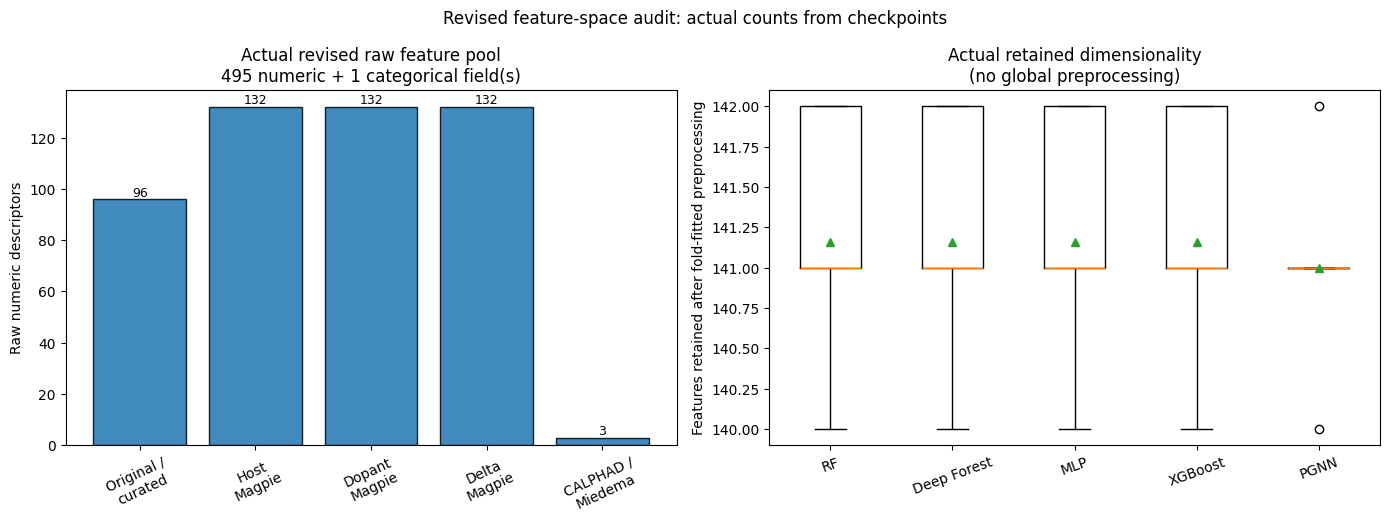

  ✓ Checkpoint loaded: results_xgb_fully_nested_safe
  ✓ Figure + fingerprint sidecars saved: xgboost_oof_parity_revised_safe.pdf / .png


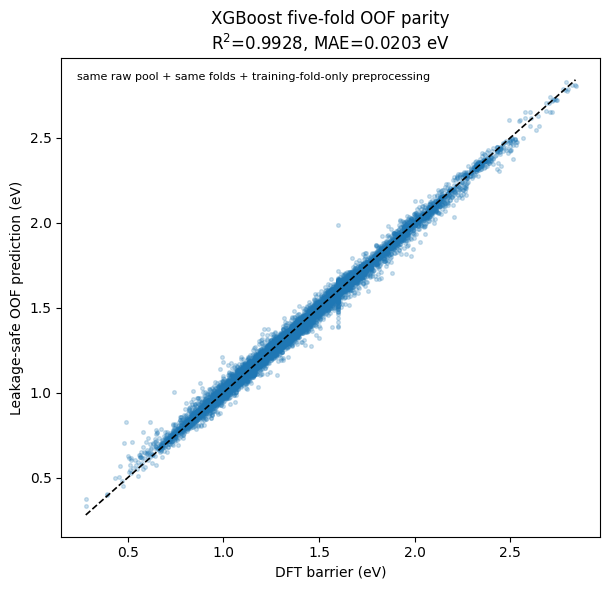

  ✓ Checkpoint loaded: physics_baselines_summary_safe
  ✓ Figure + fingerprint sidecars saved: physics_all_protocol_comparison_revised_safe.pdf / .png


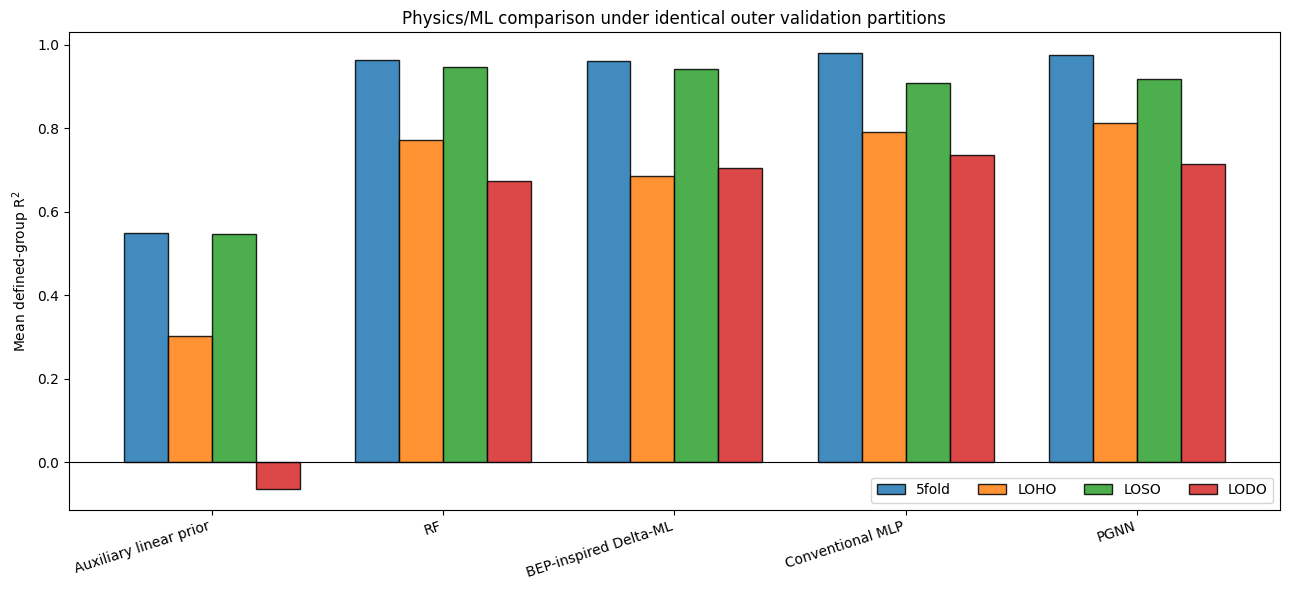

  ✓ Figure + fingerprint sidecars saved: pgnn_all_protocol_oof_parity_revised_safe.pdf / .png


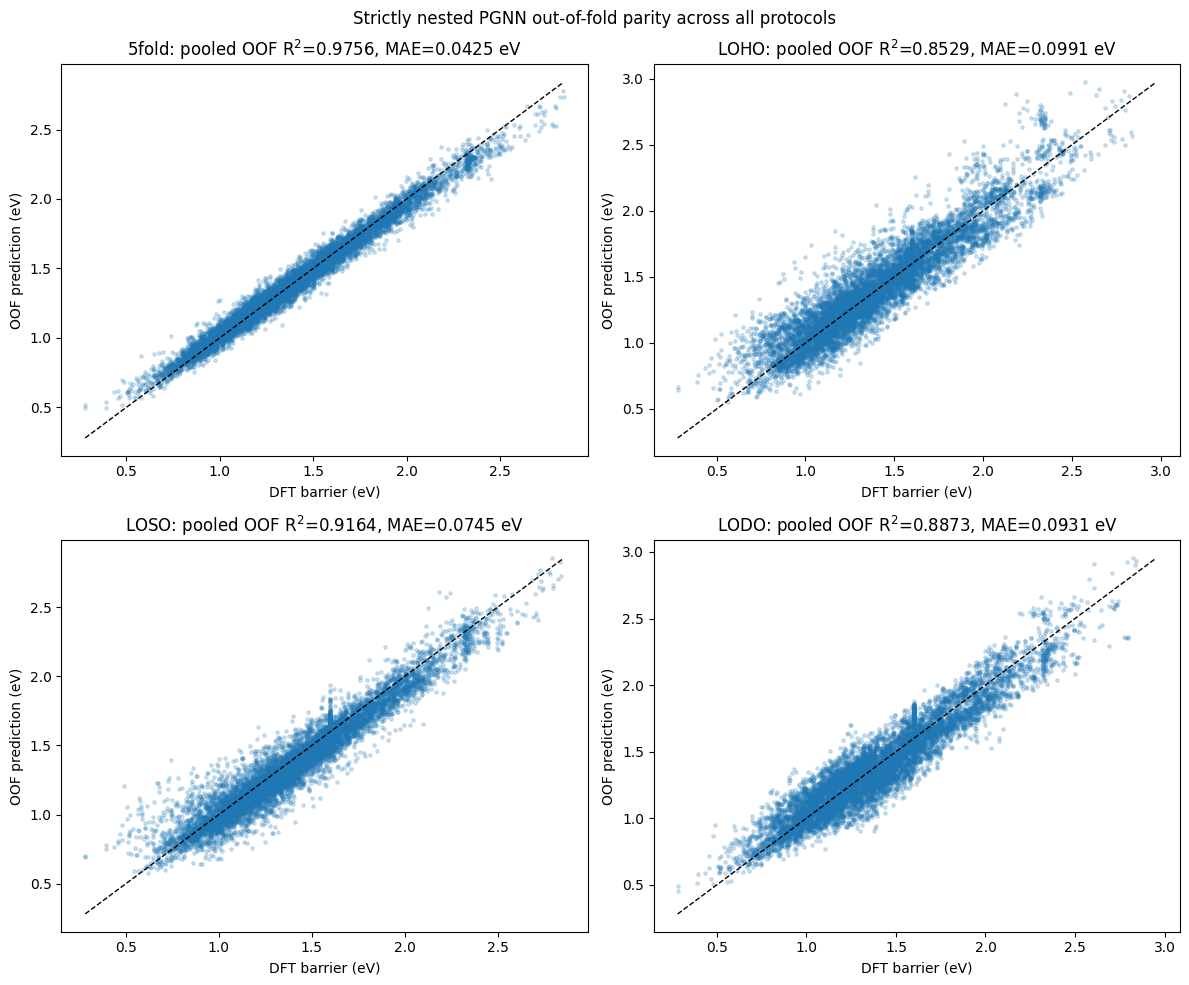

  ✓ Checkpoint loaded: active_learning_multi_fully_nested_safe
  ✓ Checkpoint loaded: retrospective_oof_ranking_safe
  ✓ Figure + fingerprint sidecars saved: active_learning_three_panel_revised_safe.pdf / .png


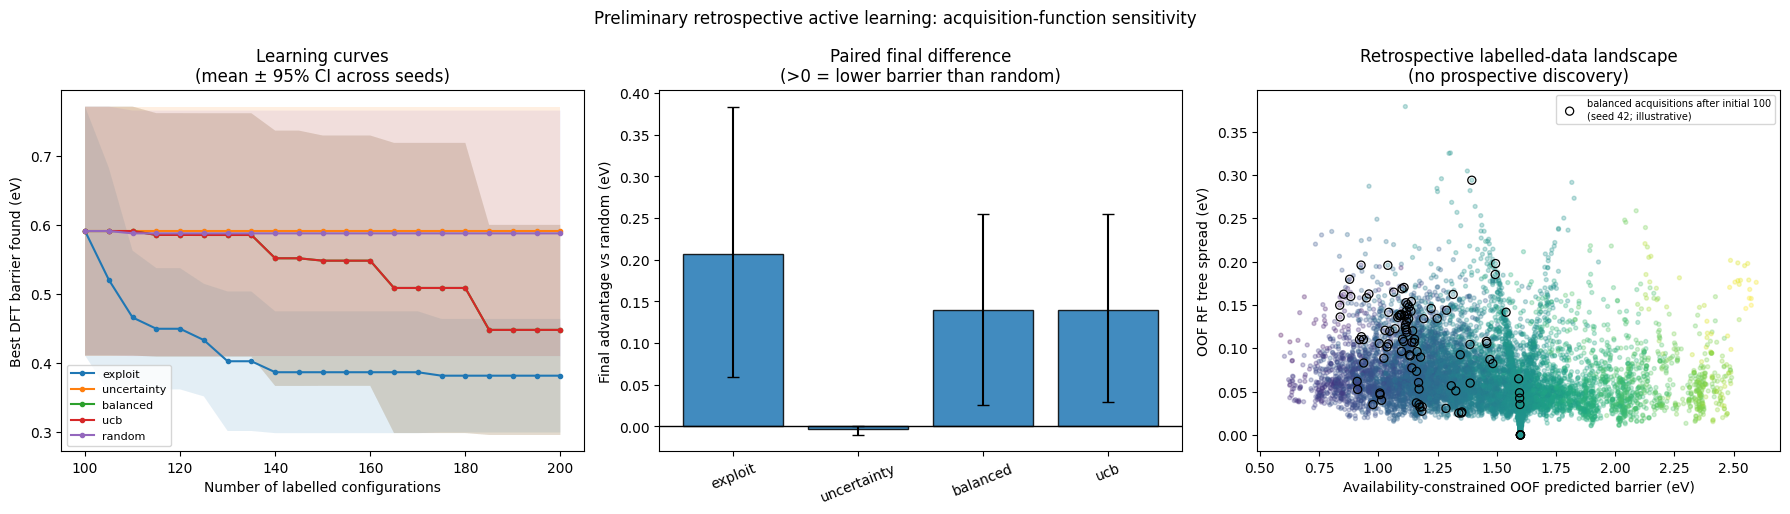

  ✓ Checkpoint loaded: pair_groupkfold_fully_nested_safe
  ✓ Checkpoint loaded: results_5f_fully_nested_safe
  ✓ Figure + fingerprint sidecars saved: host_dopant_pair_holdout_comparison_revised_safe.pdf / .png


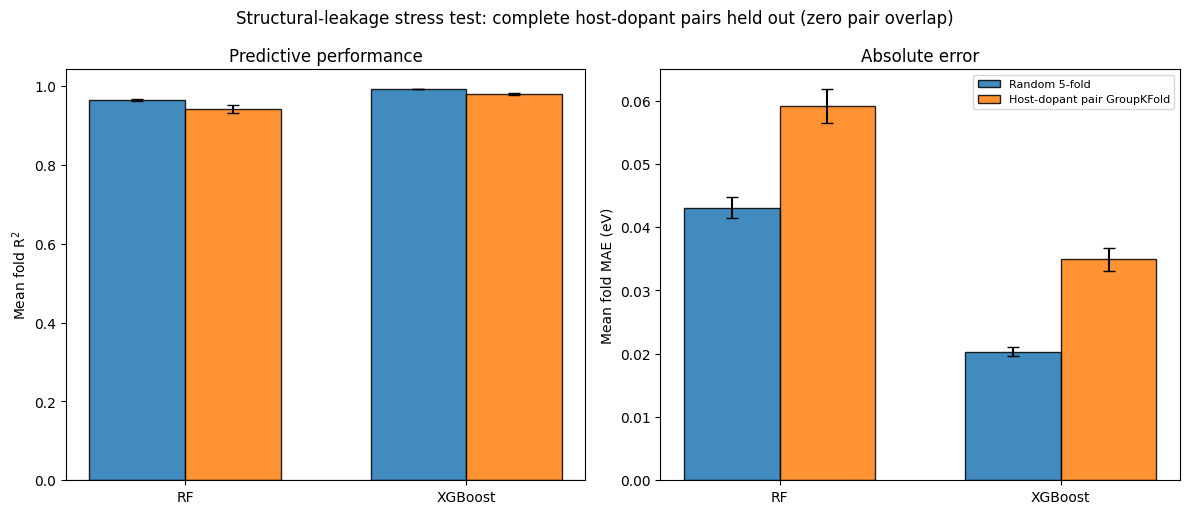


Generated revised manuscript figures (NO retraining):
  - revised_feature_space_audit_safe
  - xgboost_oof_parity_revised_safe
  - physics_all_protocol_comparison_revised_safe
  - pgnn_all_protocol_oof_parity_revised_safe
  - active_learning_three_panel_revised_safe
  - host_dopant_pair_holdout_comparison_revised_safe

Already generated by revised notebook:
  - risky_descriptor_sensitivity_safe (Step 48)
  - uncertainty_calibration_oof (Step 40)
  - random_vs_chemistry_protocol_gap_safe (Step 17)


In [ ]:
# ============================================================
# REVISED MANUSCRIPT FIGURES — checkpoint only, NO retraining
# Run after all revised analysis/checkpoints are complete.
# ============================================================
print('='*72)
print('REVISED MANUSCRIPT FIGURES — MISSING/OBSOLETE OLD FIGURE TYPES')
print('='*72)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

def CK(name):
    x = require_checkpoint(name)
    if not isinstance(x, dict):
        raise RuntimeError(f'Invalid checkpoint: {name}')
    return x

made = []
yt = np.asarray(y_barrier, float)

# ============================================================
# 1. REVISED FEATURE-SPACE FIGURE
# Replaces old hard-coded feature-enrichment/count figure.
# Uses ACTUAL current checkpoint counts.
# ============================================================

raw = CK('preclean_matrix_raw_safe')
rep = CK('repeated_cv_5seed_fully_nested_safe')
pgnn = CK('pgnn_groupout_nested_fully_safe')

names = list(raw['numeric_names'])
orig = set(raw['original_feature_set'])

counts = {
    'Original /\ncurated':
        sum(c in orig for c in names),

    'Host\nMagpie':
        sum(str(c).startswith('host_magpie_') for c in names),

    'Dopant\nMagpie':
        sum(str(c).startswith('doped_magpie_') for c in names),

    'Delta\nMagpie':
        sum(str(c).startswith('delta_magpie_') for c in names),

    'CALPHAD /\nMiedema':
        sum(str(c).startswith('calphad_') for c in names),
}

other = len(names) - sum(counts.values())

if other > 0:
    counts['Other raw\nnumeric'] = other


# actual fold-retained dimensions
rdf = pd.DataFrame(rep['rows'])

box_data = []
box_labels = []

for m, lab in [
    ('RF', 'RF'),
    ('DF', 'Deep Forest'),
    ('MLP', 'MLP'),
    ('XGB', 'XGBoost')
]:
    vals = (
        rdf.loc[
            rdf['model'] == m,
            'selected_feature_count'
        ]
        .astype(float)
        .to_numpy()
    )

    box_data.append(vals)
    box_labels.append(lab)


p5 = pd.DataFrame(
    pgnn['5fold']['rows']
)

box_data.append(
    p5['selected_feature_count']
    .astype(float)
    .to_numpy()
)

box_labels.append('PGNN')


fig, ax = plt.subplots(
    1, 2,
    figsize=(14, 5.3)
)

bars = ax[0].bar(
    list(counts),
    list(counts.values()),
    edgecolor='k',
    alpha=0.85
)

for bar, value in zip(
    bars,
    counts.values()
):
    ax[0].text(
        bar.get_x()
        + bar.get_width()/2,
        value,
        str(int(value)),
        ha='center',
        va='bottom',
        fontsize=9
    )

ax[0].set_ylabel(
    'Raw numeric descriptors'
)

ax[0].set_title(
    f'Actual revised raw feature pool\n'
    f'{len(names)} numeric + '
    f'{len(raw.get("cat_names", []))} categorical field(s)'
)

ax[0].tick_params(
    axis='x',
    rotation=25
)


ax[1].boxplot(
    box_data,
    labels=box_labels,
    showmeans=True
)

ax[1].set_ylabel(
    'Features retained after fold-fitted preprocessing'
)

ax[1].set_title(
    'Actual retained dimensionality\n'
    '(no global preprocessing)'
)

ax[1].tick_params(
    axis='x',
    rotation=20
)

plt.suptitle(
    'Revised feature-space audit: actual counts from checkpoints'
)

plt.tight_layout()

save_figure(
    fig,
    'revised_feature_space_audit_safe'
)

plt.show()

made.append(
    'revised_feature_space_audit_safe'
)


# ============================================================
# 2. REVISED XGBOOST OOF PARITY
# Replaces old XGBoost parity figure.
# ============================================================

xgb = CK(
    'results_xgb_fully_nested_safe'
)

xp = np.asarray(
    xgb['5fold']['oof_pred'],
    float
)

assert (
    xp.shape == yt.shape
    and np.isfinite(xp).all()
)

r2 = r2_score(
    yt,
    xp
)

mae = mean_absolute_error(
    yt,
    xp
)


fig, ax = plt.subplots(
    figsize=(6.2, 6)
)

ax.scatter(
    yt,
    xp,
    s=7,
    alpha=0.22,
    rasterized=True
)

lo = min(
    yt.min(),
    xp.min()
)

hi = max(
    yt.max(),
    xp.max()
)

ax.plot(
    [lo, hi],
    [lo, hi],
    'k--',
    lw=1.2
)

ax.set_xlabel(
    'DFT barrier (eV)'
)

ax.set_ylabel(
    'Leakage-safe OOF prediction (eV)'
)

ax.set_title(
    f'XGBoost five-fold OOF parity\n'
    f'R$^2$={r2:.4f}, MAE={mae:.4f} eV'
)

ax.text(
    0.03,
    0.97,
    'same raw pool + same folds + '
    'training-fold-only preprocessing',
    transform=ax.transAxes,
    va='top',
    fontsize=8
)

plt.tight_layout()

save_figure(
    fig,
    'xgboost_oof_parity_revised_safe'
)

plt.show()

made.append(
    'xgboost_oof_parity_revised_safe'
)


# ============================================================
# 3. REVISED PHYSICS/ML COMPARISON
# Replaces old single-split physics-parity type figure.
# Uses ALL reviewer-requested outer protocols.
# ============================================================

phys_summary = CK(
    'physics_baselines_summary_safe'
)['summary']

if not isinstance(
    phys_summary,
    pd.DataFrame
):
    phys_summary = pd.DataFrame(
        phys_summary
    )


protocols = [
    '5fold',
    'LOHO',
    'LOSO',
    'LODO'
]

models = [
    'Empirical auxiliary linear prior',
    'Random Forest',
    'BEP-inspired Delta-ML',
    'Conventional MLP',
    'PGNN'
]


pivot = (
    phys_summary
    .pivot(
        index='model',
        columns='protocol',
        values='mean_R2'
    )
    .reindex(models)
    [protocols]
)


fig, ax = plt.subplots(
    figsize=(13, 6)
)

x = np.arange(
    len(models)
)

width = 0.19


for j, protocol in enumerate(
    protocols
):

    ax.bar(
        x + (j - 1.5) * width,
        pivot[protocol]
        .to_numpy(float),
        width,
        label=protocol,
        edgecolor='k',
        alpha=0.85
    )


ax.set_xticks(x)

ax.set_xticklabels(
    [
        'Auxiliary linear prior',
        'RF',
        'BEP-inspired Delta-ML',
        'Conventional MLP',
        'PGNN'
    ],
    rotation=18,
    ha='right'
)

ax.set_ylabel(
    'Mean defined-group R$^2$'
)

ax.set_ylim(
    min(
        -0.05,
        np.nanmin(
            pivot.to_numpy()
        ) - 0.05
    ),
    1.03
)

ax.axhline(
    0,
    color='k',
    lw=0.8
)

ax.set_title(
    'Physics/ML comparison under identical '
    'outer validation partitions'
)

ax.legend(
    ncol=4
)

plt.tight_layout()

save_figure(
    fig,
    'physics_all_protocol_comparison_revised_safe'
)

plt.show()

made.append(
    'physics_all_protocol_comparison_revised_safe'
)


# ============================================================
# 4. REVISED PGNN OOF PARITY — ALL PROTOCOLS
# Replaces old 80/20-only PINN parity figure.
#
# IMPORTANT:
# R2 shown here = pooled OOF R2.
# Manuscript table mean-group R2 must come from Step 23/44.
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10)
)


for ax, protocol in zip(
    axes.ravel(),
    protocols
):

    pred = np.asarray(
        pgnn[protocol]['oof_pred'],
        float
    )

    assert (
        pred.shape == yt.shape
        and np.isfinite(pred).all()
    )

    rr = r2_score(
        yt,
        pred
    )

    mm = mean_absolute_error(
        yt,
        pred
    )

    ax.scatter(
        yt,
        pred,
        s=6,
        alpha=0.20,
        rasterized=True
    )

    lo = min(
        yt.min(),
        pred.min()
    )

    hi = max(
        yt.max(),
        pred.max()
    )

    ax.plot(
        [lo, hi],
        [lo, hi],
        'k--',
        lw=1
    )

    ax.set_xlabel(
        'DFT barrier (eV)'
    )

    ax.set_ylabel(
        'OOF prediction (eV)'
    )

    ax.set_title(
        f'{protocol}: '
        f'pooled OOF R$^2$={rr:.4f}, '
        f'MAE={mm:.4f} eV'
    )


plt.suptitle(
    'Strictly nested PGNN out-of-fold parity '
    'across all protocols'
)

plt.tight_layout()

save_figure(
    fig,
    'pgnn_all_protocol_oof_parity_revised_safe'
)

plt.show()

made.append(
    'pgnn_all_protocol_oof_parity_revised_safe'
)


# ============================================================
# 5. REVISED ACTIVE LEARNING — 3 PANELS
# Multi-acquisition + multi-seed + retrospective landscape.
# ============================================================

al = CK(
    'active_learning_multi_fully_nested_safe'
)

rank = CK(
    'retrospective_oof_ranking_safe'
)

screen = rank['screen_df']

if not isinstance(
    screen,
    pd.DataFrame
):
    screen = pd.DataFrame(
        screen
    )


acquisitions = list(
    al['expected_acquisitions']
)

seeds = [
    int(s)
    for s in al['expected_seeds']
]

n_init = int(
    al['n_init']
)


fig, ax = plt.subplots(
    1, 3,
    figsize=(18, 5.2)
)


# Panel A — all acquisition curves
for acquisition in acquisitions:

    matrix = np.array(
        [
            [
                point[1]
                for point
                in al['curves'][
                    f'{acquisition}|{seed}'
                ]
            ]
            for seed in seeds
        ],
        float
    )

    xlabels = np.array(
        [
            point[0]
            for point
            in al['curves'][
                f'{acquisition}|{seeds[0]}'
            ]
        ],
        int
    )

    mean_curve = matrix.mean(
        axis=0
    )

    ci = (
        1.96
        * matrix.std(
            axis=0,
            ddof=1
        )
        / np.sqrt(
            len(seeds)
        )
    )

    ax[0].plot(
        xlabels,
        mean_curve,
        marker='o',
        ms=3,
        label=acquisition
    )

    ax[0].fill_between(
        xlabels,
        mean_curve - ci,
        mean_curve + ci,
        alpha=0.12
    )


ax[0].set_xlabel(
    'Number of labelled configurations'
)

ax[0].set_ylabel(
    'Best DFT barrier found (eV)'
)

ax[0].set_title(
    'Learning curves\n'
    '(mean ± 95% CI across seeds)'
)

ax[0].legend(
    fontsize=8
)


# Panel B — final paired advantage vs random
informed = [
    a
    for a in acquisitions
    if a != 'random'
]

rng = np.random.RandomState(
    SEED + 4800
)

means = []
low = []
high = []


for acquisition in informed:

    differences = np.array(
        [
            al['curves'][
                f'random|{seed}'
            ][-1][1]
            -
            al['curves'][
                f'{acquisition}|{seed}'
            ][-1][1]

            for seed in seeds
        ],
        float
    )

    means.append(
        differences.mean()
    )

    boot_idx = rng.randint(
        0,
        len(differences),
        size=(
            10000,
            len(differences)
        )
    )

    boot = (
        differences[
            boot_idx
        ]
        .mean(axis=1)
    )

    q = np.percentile(
        boot,
        [2.5, 97.5]
    )

    low.append(q[0])
    high.append(q[1])


means = np.asarray(
    means
)

low = np.asarray(
    low
)

high = np.asarray(
    high
)


ax[1].bar(
    informed,
    means,
    yerr=np.vstack(
        [
            means - low,
            high - means
        ]
    ),
    capsize=4,
    edgecolor='k',
    alpha=0.85
)

ax[1].axhline(
    0,
    color='k',
    lw=1
)

ax[1].set_ylabel(
    'Final advantage vs random (eV)'
)

ax[1].set_title(
    'Paired final difference\n'
    '(>0 = lower barrier than random)'
)

ax[1].tick_params(
    axis='x',
    rotation=22
)


# Panel C — retrospective labelled landscape
representative_seed = seeds[0]
strategy = 'balanced'

indices = np.asarray(
    al['acquired_indices'][
        f'{strategy}|'
        f'{representative_seed}'
    ],
    int
)[n_init:]


ax[2].scatter(
    screen[
        'Constrained_OOF_Pred_Barrier'
    ],
    screen[
        'Constrained_OOF_Uncertainty'
    ],
    c=screen[
        'DFT_Barrier'
    ],
    s=8,
    alpha=0.28,
    rasterized=True
)


ax[2].scatter(
    screen.iloc[
        indices
    ][
        'Constrained_OOF_Pred_Barrier'
    ],

    screen.iloc[
        indices
    ][
        'Constrained_OOF_Uncertainty'
    ],

    s=34,
    facecolors='none',
    edgecolors='black',
    linewidths=0.9,

    label=(
        f'{strategy} acquisitions after '
        f'initial {n_init}\n'
        f'(seed {representative_seed}; illustrative)'
    )
)


ax[2].set_xlabel(
    'Availability-constrained OOF '
    'predicted barrier (eV)'
)

ax[2].set_ylabel(
    'OOF RF tree spread (eV)'
)

ax[2].set_title(
    'Retrospective labelled-data landscape\n'
    '(no prospective discovery)'
)

ax[2].legend(
    fontsize=7
)


plt.suptitle(
    'Preliminary retrospective active learning: '
    'acquisition-function sensitivity'
)

plt.tight_layout()

save_figure(
    fig,
    'active_learning_three_panel_revised_safe'
)

plt.show()

made.append(
    'active_learning_three_panel_revised_safe'
)


# ============================================================
# 6. NEW REVIEWER-SPECIFIC STRUCTURAL-LEAKAGE FIGURE
# Random CV vs complete host-dopant pair GroupKFold.
# ============================================================

pair = CK(
    'pair_groupkfold_fully_nested_safe'
)

pair_df = pd.DataFrame(
    pair['rows']
)


main5 = CK(
    'results_5f_fully_nested_safe'
)


rf_random = pd.DataFrame(
    main5['RF']['barrier']
)[
    ['R2', 'MAE']
]

rf_random[
    'model'
] = 'Random Forest'

rf_random[
    'split'
] = 'Random 5-fold'


xgb_random = pd.DataFrame(
    xgb['5fold']['rows']
)[
    ['R2', 'MAE']
]

xgb_random[
    'model'
] = 'XGBoost'

xgb_random[
    'split'
] = 'Random 5-fold'


pair_plot = pair_df[
    [
        'model',
        'R2',
        'MAE'
    ]
].copy()

pair_plot[
    'split'
] = 'Host-dopant pair GroupKFold'


plot_df = pd.concat(
    [
        rf_random,
        xgb_random,
        pair_plot
    ],
    ignore_index=True
)


fig, ax = plt.subplots(
    1, 2,
    figsize=(12, 5.2)
)


models2 = [
    'Random Forest',
    'XGBoost'
]

splits2 = [
    'Random 5-fold',
    'Host-dopant pair GroupKFold'
]

x = np.arange(
    len(models2)
)

width = 0.34


for j, split_name in enumerate(
    splits2
):

    r2_mean = []
    r2_std = []

    mae_mean = []
    mae_std = []


    for model in models2:

        subset = plot_df[
            (
                plot_df[
                    'model'
                ] == model
            )
            &
            (
                plot_df[
                    'split'
                ] == split_name
            )
        ]


        r2_mean.append(
            subset[
                'R2'
            ]
            .astype(float)
            .mean()
        )

        r2_std.append(
            subset[
                'R2'
            ]
            .astype(float)
            .std(ddof=1)
        )


        mae_mean.append(
            subset[
                'MAE'
            ]
            .astype(float)
            .mean()
        )

        mae_std.append(
            subset[
                'MAE'
            ]
            .astype(float)
            .std(ddof=1)
        )


    pos = (
        x
        + (j - 0.5)
        * width
    )


    ax[0].bar(
        pos,
        r2_mean,
        width,
        yerr=r2_std,
        capsize=4,
        edgecolor='k',
        alpha=0.85,
        label=split_name
    )


    ax[1].bar(
        pos,
        mae_mean,
        width,
        yerr=mae_std,
        capsize=4,
        edgecolor='k',
        alpha=0.85,
        label=split_name
    )


for axis in ax:

    axis.set_xticks(x)

    axis.set_xticklabels(
        [
            'RF',
            'XGBoost'
        ]
    )


ax[0].set_ylabel(
    'Mean fold R$^2$'
)

ax[0].set_title(
    'Predictive performance'
)

ax[0].axhline(
    0,
    color='k',
    lw=0.8
)


ax[1].set_ylabel(
    'Mean fold MAE (eV)'
)

ax[1].set_title(
    'Absolute error'
)

ax[1].legend(
    fontsize=8
)


plt.suptitle(
    'Structural-leakage stress test: '
    'complete host-dopant pairs held out '
    '(zero pair overlap)'
)

plt.tight_layout()

save_figure(
    fig,
    'host_dopant_pair_holdout_comparison_revised_safe'
)

plt.show()

made.append(
    'host_dopant_pair_holdout_comparison_revised_safe'
)


# ============================================================
# FINAL REPORT
# ============================================================

print(
    '\nGenerated revised manuscript figures '
    '(NO retraining):'
)

for filename in made:
    print(
        '  -',
        filename
    )


print(
    '\nAlready generated by revised notebook:'
)

print(
    '  - risky_descriptor_sensitivity_safe '
    '(Step 48)'
)

print(
    '  - uncertainty_calibration_oof '
    '(Step 40)'
)

print(
    '  - random_vs_chemistry_protocol_gap_safe '
    '(Step 17)'
)